In [1579]:
import os

import hashlib
import json
import platform
import sys
import tempfile
import copy

import numpy as np
import scipy
import matplotlib.pyplot as plt

from typing import Any, Iterator
from dataclasses import dataclass, field, fields, replace, is_dataclass, asdict
from pathlib import Path
from time import perf_counter
from concurrent.futures import ThreadPoolExecutor

from scipy.spatial import cKDTree

import multiprocessing as mp

from concurrent.futures import ProcessPoolExecutor

# Backbone definition

In [1288]:
@dataclass(frozen=True)
class BackboneConfig:
    length: float = 100.0 # length of the backbone
    sampling_step: float = 0.5 # distance between samples

    initial_position: tuple[float, float, float] = (0.0, 0.0, 0.0) 
    initial_direction: tuple[float, float, float] = (0.0, 0.0, 1.0)

    curvature_std: float = 0.01 # instensity of the desviation
    max_curvature: float = 0.03 # limit of the curvature
    correlation_length: float = 15.0 # distance where the curvatura mantains the direction

    seed: int = 42

@dataclass
class BackboneGeometry:
    arc_length: np.ndarray #(N,) length of the arc for each sample
    positions: np.ndarray # (N, 3) coordinates at the backbone
    tangents: np.ndarray # (N, 3) unitary tangents
    normals: np.ndarray # (N, 3) first normal direction
    binormals: np.ndarray # (N, 3) second normal direction
    curvature_components: np.ndarray # (N, 2) curvature over normal and binormal
    curvature: np.ndarray # (N, ) norm of both components

In [1289]:
def normalize(
    vector: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Returns a normalize copy of a 3D vector

    Parameters
    ----------
    vector
        Array with shape(3,)
    eps
        minimum norm

    Returns
    -------
    np.ndarray
        float64 vector with shape (3,) and norm = 1
    """
    vector = np.asarray(vector, dtype=np.float64)

    if vector.shape != (3,):
        raise ValueError(
            f"vector mush have shape (3,), received {vector.shape}"
        )

    if not np.all(np.isfinite(vector)):
        raise ValueError("vector contains non-finite values")

    norm = np.linalg.norm(vector)

    if norm < eps:
        raise ValueError("cannot normalize a near-zero vector")

    return vector/norm

### Choose perpendicular vector deterministic

In [1290]:
def choose_perpendicular_unit_vector(
    direction: np.ndarray,
) -> np.ndarray:
    """
    Build a unitary normal vector to a 3D direction

    It is deterministic to avid differences between executions
    """

    direction = normalize(direction)

    coordinate_axes = np.eye(3, dtype=np.float64)

    # Choose the less aligned axis with the direction
    reference = coordinate_axes[
        np.argmin(np.abs(coordinate_axes @ direction))
    ]

    perpendicular = reference - np.dot(reference, direction) * direction

    return normalize(perpendicular)

In [1291]:
def validate_backbone_config(config: BackboneConfig) -> None:
    scalar_values = {
        "length": config.length,
        "sampling_step": config.sampling_step,
        "curvature_std": config.curvature_std,
        "max_curvature": config.max_curvature,
        "correlation_length": config.correlation_length,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.length <= 0.0:
        raise ValueError("length must be greater than zero")

    if config.sampling_step <= 0.0:
        raise ValueError("sampling_step must be greater than zero")

    if config.length < 2.0 * config.sampling_step:
        raise ValueError(
            "length must contain at least two sampling intervals"
        )

    if config.curvature_std < 0.0:
        raise ValueError("curvature_std cannot be negative")

    if config.max_curvature < 0.0:
        raise ValueError("max_curvature cannot be negative")

    if config.curvature_std > config.max_curvature:
        raise ValueError(
            "curvature_std cannot be greater than max_curvature"
        )

    if config.correlation_length <= 0.0:
        raise ValueError("correlation_length must be greater than zero")

    if config.correlation_length < config.sampling_step:
        raise ValueError(
            "correlation_length should be at least sampling_step"
        )

    initial_position = np.asarray(
        config.initial_position,
        dtype=np.float64,
    )
    initial_direction = np.asarray(
        config.initial_direction,
        dtype=np.float64,
    )

    if initial_position.shape != (3,):
        raise ValueError("initial_position must contain three values")

    if initial_direction.shape != (3,):
        raise ValueError("initial_direction must contain three values")

    if not np.all(np.isfinite(initial_position)):
        raise ValueError("initial_position contains non-finite values")

    normalize(initial_direction)

### Discretize the length of the arc

In [1292]:
def build_arc_length_grid(
    length: float,
    sampling_step: float,
) -> np.ndarray:
    """
    Create a discretization with length extension

    'sampling_step' is interpreted as the maximum separation, not as the exact separation
    """

    n_segments = int(np.ceil(length / sampling_step))
    n_points = n_segments + 1

    return np.linspace(
        0.0,
        length,
        n_points,
        dtype=np.float64,
    )

### Generate smooth field for the curvature

In [1293]:
def generate_smooth_curvature_field(
    arc_length: np.ndarray,
    curvature_std: float,
    max_curvature: float,
    correlation_length: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate two components correlated of curvature

    Parameters
    ----------
    arc_length
        Length of the arcs, shape (N,)
    curvature_std
        Typical deviation of each component
    max_curvature
        Maximum allowed curvature
    correlation_length
        Correlation charasteristic length
    rng
        Random number generator

    Returns
    -------
    np.ndarray
        Curvature components with shape (N-1, 2)
        Each row corresponds with and interval of the backbone
    """

    arc_length = np.asarray(arc_length, dtype=np.float64)

    if arc_length.ndim != 1 or len(arc_length) < 3:
        raise ValueError(
            "arc_length mus be one-dimensional with at least 3 points"
        )

    segment_lengths = np.diff(arc_length)

    if np.any(segment_lengths <= 0.0):
        raise ValueError("arc_length must be strictly increasing")

    n_segments = len(segment_lengths)
    field = np.zeros((n_segments, 2), dtype=np.float64)

    if curvature_std == 0.0 or max_curvature == 0.0:
        return field

    # Initialization taken form the stationary distribution

    field[0] = rng.normal(
        loc=0.0,
        scale=curvature_std,
        size=2,
    )

    for index in range(1, n_segments):
        step = segment_lengths[index]

        alpha = np.exp(-step / correlation_length)
        innovation_scale = curvature_std * np.sqrt(1.0 - alpha**2)

        field[index] = (
            alpha * field[index - 1]
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
                size=2,
            )
        )

    magnitudes = np.linalg.norm(field, axis=1)
    exceeding = magnitudes > max_curvature

    if np.any(exceeding):
        field[exceeding] *= (
            max_curvature / magnitudes[exceeding]
        )[:, None]

    return field

### Rodrigues rotation

In [1294]:
def rotate_vector(
    vector: np.ndarray,
    rotation_vector: np.ndarray,
    eps: float = 1e-12
) -> np.ndarray:

    """
    Rotate a vector by an axis-angle representation

    The diretion of rotation_vector is the y axis and the norm the angles in radians
    """
    vector = np.asarray(vector, dtype=np.float64)
    rotation_vector = np.asarray(
        rotation_vector,
        dtype=np.float64,
    )

    if vector.shape != (3,):
        raise ValueError("vector must have shape (3,)")

    if rotation_vector.shape != (3,):
        raise ValueError("rotation_vector must have shape (3,)")

    angle = np.linalg.norm(rotation_vector)

    if angle < eps:
        return vector.copy()

    axis = rotation_vector / angle

    return (
        vector * np.cos(angle)
        + np.cross(axis, vector) * np.sin(angle)
        + axis * np.dot(axis, vector) * (1.0 - np.cos(angle))
    )

### Reortonormalization of the frame

In [1295]:
def orthonormalize_frame(
    tangent: np.ndarray,
    normal: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build an orthonormal frame from the tangent and the normal
    """
    tangent = normalize(tangent)

    normal = (
        np.asarray(normal, dtype=np.float64)
        - np.dot(normal, tangent) * tangent
    )

    normal = normalize(normal)

    binormal = normalize(np.cross(tangent, normal))

    normal = normalize(np.cross(binormal, tangent))

    return tangent, normal, binormal

### Integration of the backbone

In [1296]:
def integrate_backbone(
    arc_length: np.ndarray,
    curvature_field: np.ndarray,
    initial_position: np.ndarray,
    initial_direction: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate positions and frams from the curvature field

    Parameters
    ----------
    arc_length
        shape(N,)
    curvature_field
        Shape (N -1, 2) First component rotates to the normal
        and the second to the binormal
    initial_position
        Shape (3,)
    initial_direction
        Shape (3,)

    Returns
    -------
    positions, tangents, normals, binormas
        Four arrays with shape (N, 3)
    """
    arc_length = np.asarray(arc_length, dtype=np.float64)
    curvature_field = np.asarray(
        curvature_field,
        dtype=np.float64,
    )
    initial_position = np.asarray(
        initial_position,
        dtype=np.float64,
    )
    initial_direction = np.asarray(
        initial_direction,
        dtype=np.float64,
    )

    n_points = len(arc_length)

    if curvature_field.shape != (n_points - 1, 2):
        raise ValueError(
            "curvature_field must have shape "
            f"({n_points - 1}, 2), received {curvature_field.shape}"
        )

    if initial_position.shape != (3,):
        raise ValueError("initial_position must have shape (3,)")

    tangent = normalize(initial_direction)
    normal = choose_perpendicular_unit_vector(tangent)
    tangent, normal, binormal = orthonormalize_frame(
        tangent,
        normal,
    )

    positions = np.empty((n_points, 3), dtype=np.float64)
    tangents = np.empty((n_points, 3), dtype=np.float64)
    normals = np.empty((n_points, 3), dtype=np.float64)
    binormals = np.empty((n_points, 3), dtype=np.float64)

    positions[0] = initial_position
    tangents[0] = tangent
    normals[0] = normal
    binormals[0] = binormal

    for index in range(n_points - 1):
        step = arc_length[index + 1] - arc_length[index]

        curvature_normal = curvature_field[index, 0]
        curvature_binormal = curvature_field[index, 1]

        # We want:
        # dt/ds = curvature_normal * normal
        #       + curvature_binormal * binormal
        #
        # Angular vector that produce that derivative is:
        angular_velocity = (
            curvature_normal * binormal
            - curvature_binormal * normal
        )

        half_rotation = 0.5 * step * angular_velocity
        full_rotation = step * angular_velocity

        # Tangent in the middle poiunt for updating the position
        midpoint_tangent = normalize(
            rotate_vector(tangent, half_rotation)
        )

        positions[index + 1] = (
            positions[index] + step * midpoint_tangent
        )

        tangent = rotate_vector(tangent, full_rotation)
        normal = rotate_vector(normal, full_rotation)

        tangent, normal, binormal = orthonormalize_frame(
            tangent,
            normal,
        )

        tangents[index + 1] = tangent
        normals[index + 1] = normal
        binormals[index + 1] = binormal

    return positions, tangents, normals, binormals

# Generate backbone

In [1297]:
def generate_backbone(
    config: BackboneConfig,
) -> BackboneGeometry:
    """
    Generate a full complete and reproducible
    """

    arc_length = build_arc_length_grid(
        length=config.length,
        sampling_step=config.sampling_step,
    )

    rng = np.random.default_rng(config.seed)

    segment_curvature_components = generate_smooth_curvature_field(
        arc_length=arc_length,
        curvature_std=config.curvature_std,
        max_curvature=config.max_curvature,
        correlation_length=config.correlation_length,
        rng=rng,
    )

    positions, tangents, normals, binormals = integrate_backbone(
        arc_length=arc_length,
        curvature_field=segment_curvature_components,
        initial_position=np.asarray(
            config.initial_position,
            dtype=np.float64,
        ),
        initial_direction=np.asarray(
            config.initial_direction,
            dtype=np.float64,
        ),
    )

    # We transform the field per segment into a field per node
    curvature_components = np.empty(
        (len(arc_length), 2),
        dtype=np.float64,
    )
    curvature_components[:-1] = segment_curvature_components
    curvature_components[-1] = segment_curvature_components[-1]

    curvature = np.linalg.norm(
        curvature_components,
        axis=1,
    )

    return BackboneGeometry(
        arc_length=arc_length,
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=curvature_components,
        curvature=curvature,
    )

In [1298]:
def validate_backbone(
    backbone: BackboneGeometry,
    config: BackboneConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Validate shape, values and geometrical properties

    Returns diagnostic metrics and launch ValueError if it finds structural inconsistencies
    """
    arrays_3d = {
        "positions": backbone.positions,
        "tangents": backbone.tangents,
        "normals": backbone.normals,
        "binormals": backbone.binormals,
    }

    n_points = len(backbone.arc_length)

    if backbone.arc_length.shape != (n_points,):
        raise ValueError("invalid arc_length shape")
    
    for name, array in arrays_3d.items():
        if array.shape != (n_points, 3):
            raise ValueError(
                f"{name} must have shape ({n_points}, 3)"
            )

    if backbone.curvature_components.shape != (n_points, 2):
        raise ValueError(
            "curvature_components has an invalidad shape"
        )

    if backbone.curvature.shape != (n_points,):
        raise ValueError("curvature has an invalid shape")

    arrays_to_check = [
        backbone.arc_length,
        backbone.positions,
        backbone.tangents,
        backbone.normals,
        backbone.binormals,
        backbone.curvature_components,
        backbone.curvature,
    ]

    all_finite = all(
        np.all(np.isfinite(array))
        for array in arrays_to_check
    )

    segment_lengths = np.linalg.norm(
        np.diff(backbone.positions, axis=0),
        axis=1,
    )
    expected_segment_lengths = np.diff(backbone.arc_length)

    tangent_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.tangents, axis=1) - 1.0)
    )
    normal_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.normals, axis=1) - 1.0)
    )
    binormal_norm_error = np.max(
        np.abs(np.linalg.norm(backbone.binormals, axis=1) - 1.0)
    )

    tangent_normal_dot = np.sum(
        backbone.tangents * backbone.normals,
        axis=1,
    )
    tangent_binormal_dot = np.sum(
        backbone.tangents * backbone.binormals,
        axis=1,
    )
    normal_binormal_dot = np.sum(
        backbone.normals * backbone.binormals,
        axis=1,
    )

    max_orthogonality_error = max(
        np.max(np.abs(tangent_normal_dot)),
        np.max(np.abs(tangent_binormal_dot)),
        np.max(np.abs(normal_binormal_dot)),
    )

    reconstructed_binormals = np.cross(
        backbone.tangents,
        backbone.normals,
    )
    handedness_error = np.max(
        np.linalg.norm(
            reconstructed_binormals - backbone.binormals,
            axis=1,
        )
    )

    initial_position_error = np.linalg.norm(
        backbone.positions[0]
        - np.asarray(config.initial_position, dtype=np.float64)
    )

    expected_initial_direction = normalize(
        np.asarray(config.initial_direction, dtype=np.float64)
    )
    initial_direction_error = np.linalg.norm(
        backbone.tangents[0] - expected_initial_direction
    )

    max_step_error = np.max(
        np.abs(segment_lengths - expected_segment_lengths)
    )

    maximum_curvature = float(np.max(backbone.curvature))

    checks = {
        "all_finite": bool(all_finite),
        "arc_length_starts_at_zero": bool(
            np.isclose(backbone.arc_length[0], 0.0, atol=atol)
        ),
        "arc_length_ends_at_length": bool(
            np.isclose(
                backbone.arc_length[-1],
                config.length,
                atol=atol,
            )
        ),
        "steps_are_correct": bool(max_step_error <= atol),
        "frame_vectors_are_unitary": bool(
            max(
                tangent_norm_error,
                normal_norm_error,
                binormal_norm_error,
            ) <= atol
        ),
        "frame_is_orthogonal": bool(
            max_orthogonality_error <= atol
        ),
        "frame_is_right_handed": bool(
            handedness_error <= atol
        ),
        "initial_position_is_correct": bool(
            initial_position_error <= atol
        ),
        "initial_direction_is_correct": bool(
            initial_direction_error <= atol
        ),
        "curvature_below_limit": bool(
            maximum_curvature <= config.max_curvature + atol
        ),
    }

    metrics = {
        "n_points": n_points,
        "actual_sampling_step": float(
            expected_segment_lengths[0]
        ),
        "max_step_error": float(max_step_error),
        "max_frame_norm_error": float(
            max(
                tangent_norm_error,
                normal_norm_error,
                binormal_norm_error,
            )
        ),
        "max_orthogonality_error": float(
            max_orthogonality_error
        ),
        "max_handedness_error": float(handedness_error),
        "max_curvature": maximum_curvature,
        "mean_curvature": float(np.mean(backbone.curvature)),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }


## Visualization

In [1299]:
def set_axes_equal_3d(ax) -> None:
    """
    Ajusta los tres ejes a la misma escala visual.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    centers = np.array([
        np.mean(x_limits),
        np.mean(y_limits),
        np.mean(z_limits),
    ])

    radius = 0.5 * max(
        x_limits[1] - x_limits[0],
        y_limits[1] - y_limits[0],
        z_limits[1] - z_limits[0],
    )

    ax.set_xlim3d(centers[0] - radius, centers[0] + radius)
    ax.set_ylim3d(centers[1] - radius, centers[1] + radius)
    ax.set_zlim3d(centers[2] - radius, centers[2] + radius)

def plot_backbone_3d(
    backbone: BackboneGeometry,
    frame_stride: int = 20,
    frame_scale: float = 2.0,
):
    """
    Representa el backbone y una selección de frames locales.
    """
    if frame_stride <= 0:
        raise ValueError("frame_stride must be greater than zero")

    positions = backbone.positions

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        linewidth=2.0,
        color="black",
        label="backbone",
    )

    ax.scatter(
        positions[0, 0],
        positions[0, 1],
        positions[0, 2],
        color="green",
        s=70,
        label="start",
    )

    ax.scatter(
        positions[-1, 0],
        positions[-1, 1],
        positions[-1, 2],
        color="red",
        s=70,
        label="end",
    )

    selected = np.arange(
        0,
        len(positions),
        frame_stride,
    )

    ax.quiver(
        positions[selected, 0],
        positions[selected, 1],
        positions[selected, 2],
        backbone.normals[selected, 0],
        backbone.normals[selected, 1],
        backbone.normals[selected, 2],
        length=frame_scale,
        normalize=True,
        color="tab:blue",
        alpha=0.7,
    )

    ax.quiver(
        positions[selected, 0],
        positions[selected, 1],
        positions[selected, 2],
        backbone.binormals[selected, 0],
        backbone.binormals[selected, 1],
        backbone.binormals[selected, 2],
        length=frame_scale,
        normalize=True,
        color="tab:orange",
        alpha=0.7,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

## Diagnostics

In [1300]:
def plot_backbone_diagnostics(
    backbone: BackboneGeometry,
):
    """
    Representa curvatura, separación y componentes de la tangente.
    """
    segment_lengths = np.linalg.norm(
        np.diff(backbone.positions, axis=0),
        axis=1,
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 9),
        sharex=False,
    )

    axes[0].plot(
        backbone.arc_length,
        backbone.curvature,
        color="tab:purple",
    )
    axes[0].set_ylabel("curvature")
    axes[0].set_title("Backbone curvature")

    axes[1].plot(
        backbone.arc_length[1:],
        segment_lengths,
        color="tab:green",
    )
    axes[1].set_ylabel("segment length")
    axes[1].set_title("Distance between consecutive samples")

    component_names = ["tx", "ty", "tz"]

    for component, name in enumerate(component_names):
        axes[2].plot(
            backbone.arc_length,
            backbone.tangents[:, component],
            label=name,
        )

    axes[2].set_xlabel("arc length")
    axes[2].set_ylabel("tangent component")
    axes[2].set_title("Tangent components")
    axes[2].legend()

    plt.tight_layout()

    return fig, axes

# First execution

In [1301]:
backbone_config = BackboneConfig(
    length=100.0,
    sampling_step=0.5,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.3,
    max_curvature=0.1,
    correlation_length=15.0,
    seed=42,
)

backbone = generate_backbone(backbone_config)

validation = validate_backbone(
    backbone=backbone,
    config=backbone_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'arc_length_starts_at_zero': True,
  'arc_length_ends_at_length': True,
  'steps_are_correct': True,
  'frame_vectors_are_unitary': True,
  'frame_is_orthogonal': True,
  'frame_is_right_handed': True,
  'initial_position_is_correct': True,
  'initial_direction_is_correct': True,
  'curvature_below_limit': True},
 'metrics': {'n_points': 201,
  'actual_sampling_step': 0.5,
  'max_step_error': 3.219646771412954e-15,
  'max_frame_norm_error': 2.220446049250313e-16,
  'max_orthogonality_error': 1.1102230246251565e-16,
  'max_handedness_error': 3.379462171739212e-16,
  'max_curvature': 0.10000000000000003,
  'mean_curvature': 0.09490431859105489}}

(<Figure size 1000x900 with 3 Axes>,
 array([<Axes: title={'center': 'Backbone curvature'}, ylabel='curvature'>,
        <Axes: title={'center': 'Distance between consecutive samples'}, ylabel='segment length'>,
        <Axes: title={'center': 'Tangent components'}, xlabel='arc length', ylabel='tangent component'>],
       dtype=object))

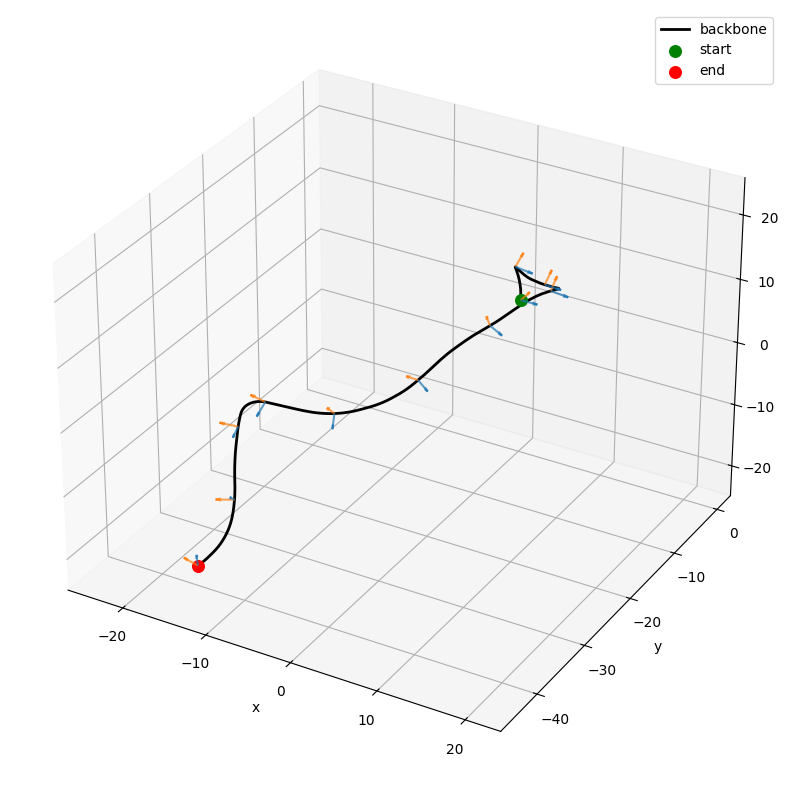

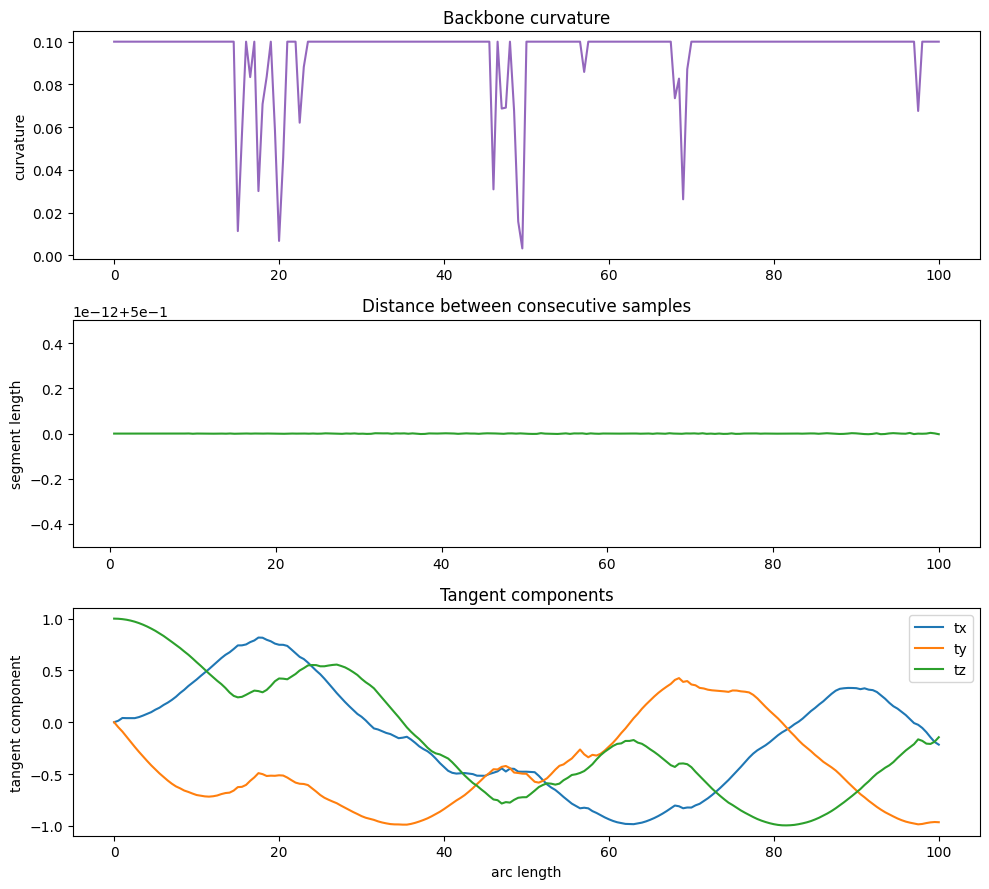

In [1302]:
plot_backbone_3d(
    backbone,
    frame_stride=20,
    frame_scale=2.0,
)

plot_backbone_diagnostics(backbone)

# Straight case

In [1303]:
straight_config = BackboneConfig(
    length=100.0,
    sampling_step=0.5,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.0,
    max_curvature=0.0,
    correlation_length=15.0,
    seed=42,
)

straight_backbone = generate_backbone(straight_config)

straight_validation = validate_backbone(
    backbone=straight_backbone,
    config=straight_config,
)

straight_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'arc_length_starts_at_zero': True,
  'arc_length_ends_at_length': True,
  'steps_are_correct': True,
  'frame_vectors_are_unitary': True,
  'frame_is_orthogonal': True,
  'frame_is_right_handed': True,
  'initial_position_is_correct': True,
  'initial_direction_is_correct': True,
  'curvature_below_limit': True},
 'metrics': {'n_points': 201,
  'actual_sampling_step': 0.5,
  'max_step_error': 0.0,
  'max_frame_norm_error': 0.0,
  'max_orthogonality_error': 0.0,
  'max_handedness_error': 0.0,
  'max_curvature': 0.0,
  'mean_curvature': 0.0}}

In [1304]:
expected_positions = np.column_stack([
    np.zeros_like(straight_backbone.arc_length),
    np.zeros_like(straight_backbone.arc_length),
    straight_backbone.arc_length,
])

np.allclose(
    straight_backbone.positions,
    expected_positions,
    atol=1e-10,
)

True

# Helix configuration

In [1305]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0 # distance between subunits along the backbone arc
    twist_rad: float = np.deg2rad(30.0) # rotation per subunit around the backbone
    radius: float = 2.0 # distance from the backbone to each subunit
    initial_phase_rad: float = 0.0 # angular orientation of the first subunit
    strand_id: int = 0 

### Output structure

In [1306]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    true_edge_index: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    global_rise: float
    global_twist_rad: float
    global_radius: float
    n_strands: int

### Validation of the configuration

In [1307]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Validate the helicoidal configuration respect to the backbone
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    if config.radius <= 0.0:
        raise ValueError("radius must be greater than zero")

    if not isinstance(config.strand_id, (int, np.integer)):
        raise ValueError("strand_id must be an integer")

    total_length = float(backbone.arc_length[-1])

    if config.rise > total_length:
        raise ValueError(
            "rise is greater than the total backbone length"
        )

    n_nodes = int(np.floor(total_length / config.rise)) + 1

    if n_nodes < 3:
        raise ValueError(
            "the backbone must contain at least three helix nodes"
        )


### Subunit axial positions

In [1308]:
def build_helix_arc_length_grid(
    backbone_length: float,
    rise: float,
) -> np.ndarray:
    """
    Calculate the positions of the subunits over the backbone

    The last subunit is included only if it is not over the available length
    """

    if backbone_length <= 0.0:
        raise ValueError(
            "backbone_length must be greater than zero"
        )

    if rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    n_nodes = int(np.floor(backbone_length / rise)) + 1

    return (
        np.arange(n_nodes, dtype=np.float64)
        * np.float64(rise)
    )

### Vectorized interpolation

In [1309]:
def interpolate_vector_field(
    source_arc_length: np.ndarray,
    source_values: np.ndarray,
    target_arc_length: np.ndarray,
) -> np.ndarray:
    """
    Interpolate a vector field defined over the length of the arc

    Parameters
    ----------
    source_arc_length
        Shape (M,)
    source_values
        Shape(M, D)
    target_arc_length
        Shape (N,)

    Returns
    -------
    np.ndarray
        Interpolate field with shape (N, D)
    """
    source_arc_length = np.asarray(
        source_arc_length,
        dtype=np.float64,
    )
    source_values = np.asarray(
        source_values,
        dtype=np.float64,
    )
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if source_arc_length.ndim != 1:
        raise ValueError(
            "source_arc_length must be one-dimensional"
        )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length mus be one-dimensional"
        )
    
    if source_values.ndim != 2:
        raise ValueError("source_values must be two-dimensional")

    if len(source_arc_length) != len(source_values):
        raise ValueError(
            "source_arc_length and source_values must have "
            "the same first dimension"
        )

    if np.any(np.diff(source_arc_length) <= 0.0):
        raise ValueError(
            "source_arc_length must be strictly increasing"
        )

    if target_arc_length[0] < source_arc_length[0]:
        raise ValueError(
            "target_arc_length begins outside the source interval"
        )

    if target_arc_length[-1] > source_arc_length[-1]:
        raise ValueError(
            "target_arc_length ends outside the source interval"
        )

    output = np.empty(
        (len(target_arc_length), source_values.shape[1]),
        dtype=np.float64,
    )

    for component in range(source_values.shape[1]):
        output[:, component] = np.interp(
            target_arc_length,
            source_arc_length,
            source_values[:, component],
        )

    return output

### Scalar field interpolation

In [1310]:
def interpolate_scalar_field(
    source_arc_length: np.ndarray,
    source_values: np.ndarray,
    target_arc_length: np.ndarray,
) -> np.ndarray:
    """
    Interpolate a scalar field over length of the arc
    """
    source_arc_length = np.asarray(
        source_arc_length,
        dtype=np.float64,
    )
    source_values = np.asarray(
        source_values,
        dtype=np.float64,
    )
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if source_arc_length.ndim != 1:
        raise ValueError(
            "source_arc_length must be one-dimensional"
        )

    if source_values.shape != source_arc_length.shape:
        raise ValueError(
            "source_values and source_arc_length must have "
            "the same shape"
        )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length must be one-dimensional"
        )

    if np.any(np.diff(source_arc_length) <= 0.0):
        raise ValueError(
            "source_arc_length must be strictly increasing"
        )

    if (
        target_arc_length[0] < source_arc_length[0]
        or target_arc_length[-1] > source_arc_length[-1]
    ):
        raise ValueError(
            "target_arc_length is outside the source interval"
        )

    return np.interp(
        target_arc_length,
        source_arc_length,
        source_values,
    )

### Transport the frames over the interpolated tangents

In [1311]:
def transport_frame_between_tangents(
    previous_tangent: np.ndarray,
    current_tangent: np.ndarray,
    previous_normal: np.ndarray,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Transport the frame with the minimum rotation between two tangents

    Returns
    -------
    current_tangent, current_normal, current_binormal
        Three vectors with shape (3,)
    """
    previous_tangent = normalize(previous_tangent)
    current_tangent = normalize(current_tangent)
    previous_normal = normalize(previous_normal)

    rotation_axis = np.cross(
        previous_tangent,
        current_tangent,
    )
    axis_norm = np.linalg.norm(rotation_axis)

    tangent_dot = np.clip(
        np.dot(previous_tangent, current_tangent),
        -1.0,
        1.0,
    )

    if axis_norm < eps:
        if tangent_dot > 0.0:
            current_normal = previous_normal.copy()
        else:
            # Exceptional case: tangents closely opposites
            fallback_axis = choose_perpendicular_unit_vector(
                previous_tangent
            )
            current_normal = rotate_vector(
                previous_normal,
                np.pi * fallback_axis,
            )
    else:
        rotation_axis /= axis_norm

        angle = np.arctan2(
            axis_norm,
            tangent_dot,
        )

        current_normal = rotate_vector(
            previous_normal,
            angle * rotation_axis,
        )

    return orthonormalize_frame(
        current_tangent,
        current_normal,
    )

### Reconstruction of the interpolated frame

In [1312]:
def build_transported_frames(
    tangents: np.ndarray,
    initial_normal: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build normals and binormals with discrete parallel transport

    Parameters
    ----------
    tangents
        Tangents with shape (N, 3)
    initial_normal
        Normal with the first point, shape (3,)

    Returns
    -------
    normals, binormals
        Two arrays with shape (N, 3)
    """
    tangents = np.asarray(tangents, dtype=np.float64)
    initial_normal = np.asarray(
        initial_normal,
        dtype=np.float64,
    )

    if tangents.ndim != 2 or tangents.shape[1] != 3:
        raise ValueError("tangents must have shape (N, 3)")

    if len(tangents) < 2:
        raise ValueError("at least two tangents are required")

    normalized_tangents = tangents.copy()
    tangent_norms = np.linalg.norm(
        normalized_tangents,
        axis=1,
    )

    if np.any(tangent_norms < 1e-12):
        raise ValueError("tangents contain a near-zero vector")

    normalized_tangents /= tangent_norms[:, None]

    normals = np.empty_like(normalized_tangents)
    binormals = np.empty_like(normalized_tangents)

    first_tangent, first_normal, first_binormal = (
        orthonormalize_frame(
            normalized_tangents[0],
            initial_normal,
        )
    )

    normalized_tangents[0] = first_tangent
    normals[0] = first_normal
    binormals[0] = first_binormal

    for index in range(1, len(normalized_tangents)):
        (
            normalized_tangents[index],
            normals[index],
            binormals[index],
        ) = transport_frame_between_tangents(
            previous_tangent=normalized_tangents[index - 1],
            current_tangent=normalized_tangents[index],
            previous_normal=normals[index - 1],
        )

    return normals, binormals

### Backbone resampling

In [1313]:
def resample_backbone(
    backbone: BackboneGeometry,
    target_arc_length: np.ndarray,
) -> BackboneGeometry:
    """
    Evaluate the backbone in the new positions over arc length
    """
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if target_arc_length.ndim != 1:
        raise ValueError(
            "target_arc_length must be one-dimensional"
        )

    if len(target_arc_length) < 2:
        raise ValueError(
            "at least two target points are required"
        )

    if np.any(np.diff(target_arc_length) <= 0.0):
        raise ValueError(
            "target_arc_length must be strictly increasing"
        )

    positions = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.positions,
        target_arc_length=target_arc_length,
    )

    tangents = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.tangents,
        target_arc_length=target_arc_length,
    )

    tangent_norms = np.linalg.norm(tangents, axis=1)

    if np.any(tangent_norms < 1e-12):
        raise ValueError(
            "interpolated tangents contain a near-zero vector"
        )

    tangents /= tangent_norms[:, None]

    initial_normal = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.normals,
        target_arc_length=target_arc_length[:1],
    )[0]

    normals, binormals = build_transported_frames(
        tangents=tangents,
        initial_normal=initial_normal,
    )

    curvature_components = interpolate_vector_field(
        source_arc_length=backbone.arc_length,
        source_values=backbone.curvature_components,
        target_arc_length=target_arc_length,
    )

    curvature = np.linalg.norm(
        curvature_components,
        axis=1,
    )

    return BackboneGeometry(
        arc_length=target_arc_length.copy(),
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=curvature_components,
        curvature=curvature,
    )



### Build efficient true edges

In [1314]:
def build_bidirectional_chain_edges(
    n_nodes: int,
) -> np.ndarray:
    """
    Build conections directed between consecutive nodes

    Returns
    -------
    np.ndarray
        edge_index with shape (2, 2 * (n_nodes - 1))
    """
    if not isinstance(n_nodes, (int, np.integer)):
        raise ValueError("n_nodes must be an integer")

    if n_nodes < 2:
        raise ValueError("at least two nodes are required")

    source_forward = np.arange(
        0,
        n_nodes - 1,
        dtype=np.int64,
    )
    target_forward = source_forward + 1

    source = np.concatenate([
        source_forward,
        target_forward,
    ])

    target = np.concatenate([
        target_forward,
        source_forward,
    ])

    return np.stack(
        [source, target],
        axis=0,
    )

### Generate helicoidal strand

In [1315]:
def generate_single_strand_helix(
    backbone: BackboneGeometry,
    config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a unique helicoidal around the backbone

    The input of the future model will be 'position'. The rest of the fields are
    conservated as supervision and metadata
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    helix_arc_length = build_helix_arc_length_grid(
        backbone_length=float(backbone.arc_length[-1]),
        rise=config.rise,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=helix_arc_length,
    )

    n_nodes = len(helix_arc_length)

    sequence_index = np.arange(
        n_nodes,
        dtype=np.int64,
    )

    strand_id = np.full(
        n_nodes,
        config.strand_id,
        dtype=np.int64,
    )

    phase_rad = (
        config.initial_phase_rad
        + sequence_index.astype(np.float64) * config.twist_rad
    )

    radius = np.full(
        n_nodes,
        config.radius,
        dtype=np.float64,
    )

    radial_direction = (
        np.cos(phase_rad)[:, None] * sampled_backbone.normals
        + np.sin(phase_rad[:, None]) * sampled_backbone.binormals
    )

    positions = (
        sampled_backbone.positions
        + radius[:, None] * radial_direction
    )

    true_edge_index = build_bidirectional_chain_edges(
        n_nodes=n_nodes,
    )

    local_rise = np.diff(helix_arc_length)

    local_twist_rad = np.full(
        n_nodes - 1,
        config.twist_rad,
        dtype=np.float64,
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=sampled_backbone.positions,
        tangents=sampled_backbone.tangents,
        normals=sampled_backbone.normals,
        binormals=sampled_backbone.binormals,
        arc_length=helix_arc_length,
        sequence_index=sequence_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        radius=radius,
        backbone_curvature=sampled_backbone.curvature,
        true_edge_index=true_edge_index,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        global_rise=float(config.rise),
        global_twist_rad=float(config.twist_rad),
        global_radius=float(config.radius),
        n_strands=1,
    )

In [1316]:
def validate_single_strand_helix(
        helix: CleanHelixGeometry,
        config: HelixConfig,
        atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Validate shapes, order, radius, phases, rise and connectivity
    """
    n_nodes = len(helix.positions)

    expected_vector_shapes = {
        "positions": (n_nodes, 3),
        "backbone_positions": (n_nodes, 3),
        "tangents": (n_nodes, 3),
        "normals": (n_nodes, 3),
        "binormals": (n_nodes, 3),
    }

    arrays_by_name = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    structural_errors = []

    for name, expected_shape in expected_vector_shapes.items():
        if arrays_by_name[name].shape != expected_shape:
            structural_errors.append(
                f"{name}: expected {expected_shape}, "
                f"received {arrays_by_name[name].shape}"
            )

    expected_node_shape = (n_nodes,)

    node_arrays = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, array in node_arrays.items():
        if array.shape != expected_node_shape:
            structural_errors.append(
                f"{name}: expected {expected_node_shape}, "
                f"received {array.shape}"
            )

    if structural_errors:
        raise ValueError("; ".join(structural_errors))

    expected_edge_shape = (2, 2 * (n_nodes - 1))

    if helix.true_edge_index.shape != expected_edge_shape:
        raise ValueError(
            "true_edge_index has an invalid shape: "
            f"expected {expected_edge_shape}, "
            f"received {helix.true_edge_index.shape}"
        )

    if helix.local_rise.shape != (n_nodes - 1,):
        raise ValueError("local_rise has an invalid shape")

    if helix.local_twist_rad.shape != (n_nodes - 1,):
        raise ValueError("local_twist_rad has an invalid shape")

    arrays_to_check = [
        helix.positions,
        helix.backbone_positions,
        helix.tangents,
        helix.normals,
        helix.binormals,
        helix.arc_length,
        helix.phase_rad,
        helix.radius,
        helix.backbone_curvature,
        helix.local_rise,
        helix.local_twist_rad,
    ]

    all_finite = all(
        np.all(np.isfinite(array))
        for array in arrays_to_check
    )

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    expected_phase = (
        config.initial_phase_rad
        + helix.sequence_index.astype(np.float64)
        * config.twist_rad
    )

    expected_edges = build_bidirectional_chain_edges(
        n_nodes=n_nodes,
    )

    checks = {
        "all_finite": bool(all_finite),
        "sequence_starts_at_zero": bool(
            helix.sequence_index[0] == 0
        ),
        "sequence_is_consecutive": bool(
            np.array_equal(
                helix.sequence_index,
                np.arange(n_nodes, dtype=np.int64),
            )
        ),
        "single_strand": bool(
            np.all(helix.strand_id == config.strand_id)
        ),
        "radius_is_correct": bool(
            np.allclose(
                measured_radius,
                config.radius,
                atol=atol,
            )
        ),
        "stored_radius_is_correct": bool(
            np.allclose(
                helix.radius,
                config.radius,
                atol=atol,
            )
        ),
        "phase_is_correct": bool(
            np.allclose(
                helix.phase_rad,
                expected_phase,
                atol=atol,
            )
        ),
        "rise_is_correct": bool(
            np.allclose(
                helix.local_rise,
                config.rise,
                atol=atol,
            )
        ),
        "twist_is_correct": bool(
            np.allclose(
                helix.local_twist_rad,
                config.twist_rad,
                atol=atol,
            )
        ),
        "edges_are_correct": bool(
            np.array_equal(
                helix.true_edge_index,
                expected_edges,
            )
        ),
        "edge_indices_are_valid": bool(
            np.min(helix.true_edge_index) >= 0
            and np.max(helix.true_edge_index) < n_nodes
        ),
    }

    metrics = {
        "n_nodes": n_nodes,
        "n_directed_edges": helix.true_edge_index.shape[1],
        "max_radius_error": float(
            np.max(np.abs(measured_radius - config.radius))
        ),
        "mean_backbone_curvature": float(
            np.mean(helix.backbone_curvature)
        ),
        "max_backbone_curvature": float(
            np.max(helix.backbone_curvature)
        ),
        "n_turns": float(
            abs(config.twist_rad)
            * (n_nodes - 1)
            / (2.0 * np.pi)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Helix Visualization

In [1317]:
def plot_single_strand_helix(
    helix: CleanHelixGeometry,
    show_connections: bool = True,
):
    """
    Representa el backbone remuestreado y la cadena helicoidal.
    """
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    backbone_positions = helix.backbone_positions
    positions = helix.positions

    ax.plot(
        backbone_positions[:, 0],
        backbone_positions[:, 1],
        backbone_positions[:, 2],
        color="black",
        linewidth=2.0,
        label="backbone",
    )

    if show_connections:
        ax.plot(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            linewidth=1.5,
            alpha=0.8,
            label="strand",
        )

    scatter = ax.scatter(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        c=helix.sequence_index,
        cmap="viridis",
        s=25,
        label="subunits",
    )

    ax.scatter(
        positions[0, 0],
        positions[0, 1],
        positions[0, 2],
        color="green",
        s=80,
        label="start",
    )

    ax.scatter(
        positions[-1, 0],
        positions[-1, 1],
        positions[-1, 2],
        color="red",
        s=80,
        label="end",
    )

    fig.colorbar(
        scatter,
        ax=ax,
        label="sequence index",
        shrink=0.7,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

def plot_helix_diagnostics(
    helix: CleanHelixGeometry,
):
    """
    Representa radio, fase, rise, twist y curvatura.
    """
    fig, axes = plt.subplots(
        4,
        1,
        figsize=(10, 11),
        sharex=False,
    )

    axes[0].plot(
        helix.arc_length,
        helix.radius,
        color="tab:blue",
    )
    axes[0].set_ylabel("radius")
    axes[0].set_title("Helical radius")

    axes[1].plot(
        helix.arc_length,
        np.rad2deg(helix.phase_rad),
        color="tab:orange",
    )
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_title("Accumulated phase")

    axes[2].plot(
        helix.arc_length[1:],
        helix.local_rise,
        label="rise",
        color="tab:green",
    )
    axes[2].set_ylabel("rise")
    axes[2].set_title("Local rise")

    twist_degrees = np.rad2deg(helix.local_twist_rad)

    axes[3].plot(
        helix.arc_length[1:],
        twist_degrees,
        label="twist",
        color="tab:red",
    )
    axes[3].set_xlabel("backbone arc length")
    axes[3].set_ylabel("twist (deg)")
    axes[3].set_title("Local twist")

    plt.tight_layout()

    return fig, axes

In [1318]:
backbone_config = BackboneConfig(
    length=100.0,
    sampling_step=0.25,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.01,
    max_curvature=0.03,
    correlation_length=15.0,
    seed=42,
)

helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,
    initial_phase_rad=0.0,
    strand_id=0,
)

backbone = generate_backbone(backbone_config)

helix = generate_single_strand_helix(
    backbone=backbone,
    config=helix_config,
)

helix_validation = validate_single_strand_helix(
    helix=helix,
    config=helix_config,
)

helix_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'sequence_starts_at_zero': True,
  'sequence_is_consecutive': True,
  'single_strand': True,
  'radius_is_correct': True,
  'stored_radius_is_correct': True,
  'phase_is_correct': True,
  'rise_is_correct': True,
  'twist_is_correct': True,
  'edges_are_correct': True,
  'edge_indices_are_valid': True},
 'metrics': {'n_nodes': 101,
  'n_directed_edges': 200,
  'max_radius_error': 3.774758283725532e-15,
  'mean_backbone_curvature': 0.009238176455392343,
  'max_backbone_curvature': 0.021423357745849428,
  'n_turns': 8.333333333333332}}

(<Figure size 1000x1100 with 4 Axes>,
 array([<Axes: title={'center': 'Helical radius'}, ylabel='radius'>,
        <Axes: title={'center': 'Accumulated phase'}, ylabel='phase (deg)'>,
        <Axes: title={'center': 'Local rise'}, ylabel='rise'>,
        <Axes: title={'center': 'Local twist'}, xlabel='backbone arc length', ylabel='twist (deg)'>],
       dtype=object))

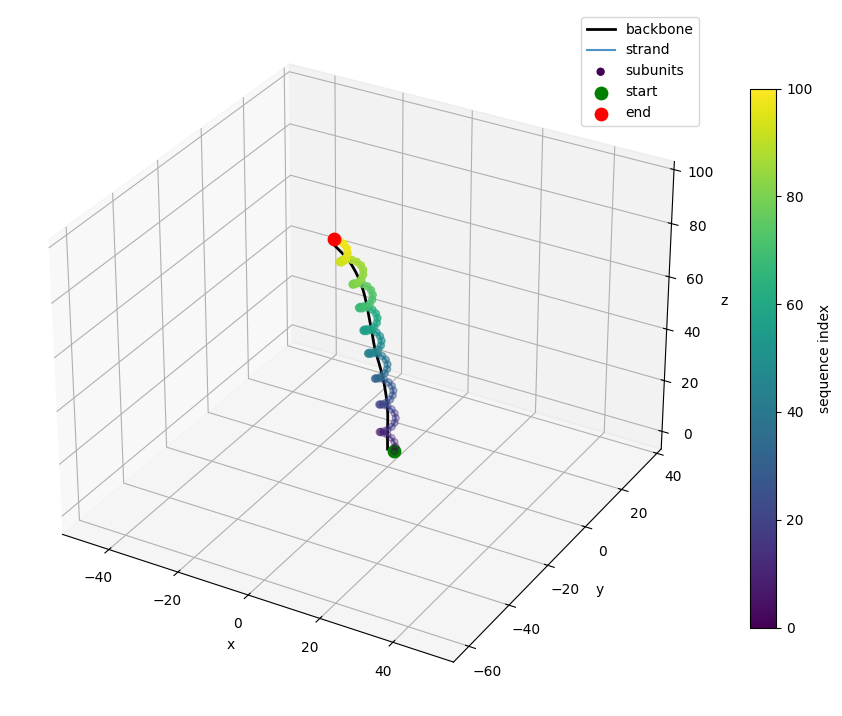

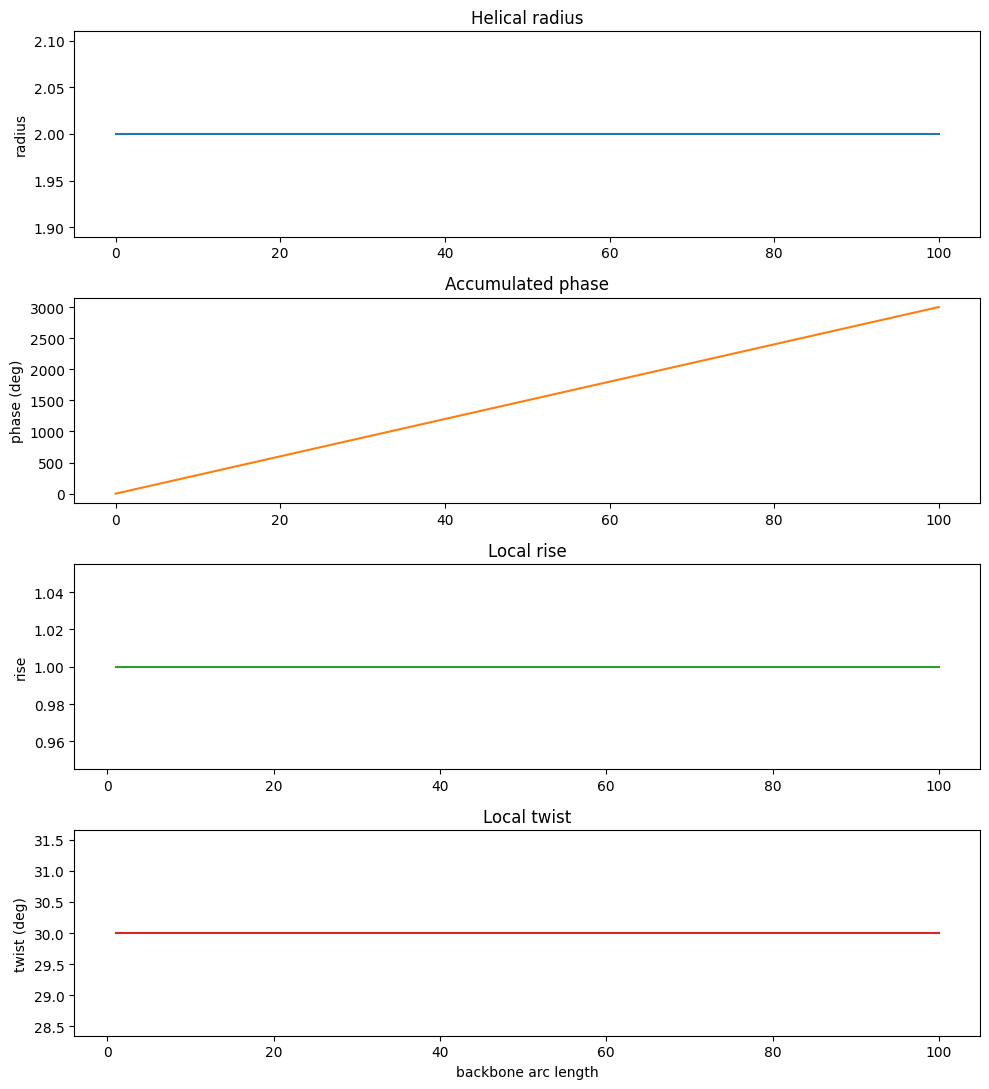

In [1319]:
plot_single_strand_helix(helix)
plot_helix_diagnostics(helix)

### Straight backbone

In [1320]:
straight_backbone_config = BackboneConfig(
    length=50.0,
    sampling_step=0.25,
    initial_position=(0.0, 0.0, 0.0),
    initial_direction=(0.0, 0.0, 1.0),
    curvature_std=0.0,
    max_curvature=0.0,
    correlation_length=10.0,
    seed=42,
)

straight_backbone = generate_backbone(
    straight_backbone_config
)

straight_helix = generate_single_strand_helix(
    backbone=straight_backbone,
    config=helix_config,
)

straight_validation = validate_single_strand_helix(
    helix=straight_helix,
    config=helix_config,
)

straight_validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'sequence_starts_at_zero': True,
  'sequence_is_consecutive': True,
  'single_strand': True,
  'radius_is_correct': True,
  'stored_radius_is_correct': True,
  'phase_is_correct': True,
  'rise_is_correct': True,
  'twist_is_correct': True,
  'edges_are_correct': True,
  'edge_indices_are_valid': True},
 'metrics': {'n_nodes': 51,
  'n_directed_edges': 100,
  'max_radius_error': 2.220446049250313e-16,
  'mean_backbone_curvature': 0.0,
  'max_backbone_curvature': 0.0,
  'n_turns': 4.166666666666666}}

# Multiple strands

In [1321]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0
    twist_rad: float = np.deg2rad(30.0)
    radius: float = 2.0

    n_strands: int = 1
    initial_phase_rad: float = 0.0
    strand_phase_offsets_rad: tuple[float, ...] | None = None

    first_strand_id: int = 0

In [1322]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    backbone_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    strand_phase_offset_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_strand_id: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    global_rise: float
    global_twist_rad: float
    global_radius: float

    n_strands: int
    n_nodes_per_strand: int

### Config validation

In [1323]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Valida la configuración multistrand respecto al backbone.
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be greater than zero")

    if config.radius <= 0.0:
        raise ValueError("radius must be greater than zero")

    if not isinstance(config.n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if config.n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if not isinstance(config.first_strand_id, (int, np.integer)):
        raise ValueError("first_strand_id must be an integer")

    if config.strand_phase_offsets_rad is not None:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        )

        if offsets.shape != (config.n_strands,):
            raise ValueError(
                "strand_phase_offsets_rad must contain exactly "
                f"{config.n_strands} values"
            )

        if not np.all(np.isfinite(offsets)):
            raise ValueError(
                "strand_phase_offsets_rad contains non-finite values"
            )

    backbone_length = float(backbone.arc_length[-1])

    if config.rise > backbone_length:
        raise ValueError(
            "rise is greater than the backbone length"
        )

    n_nodes_per_strand = (
        int(np.floor(backbone_length / config.rise)) + 1
    )

    if n_nodes_per_strand < 3:
        raise ValueError(
            "at least three nodes per strand are required"
        )

### Resolve strand phases

In [1324]:
def resolve_strand_phase_offsets(
    config: HelixConfig,
) -> np.ndarray:
    """
    Returns the offset for each strand

    Returns
    -------
    np.ndarray
        float64 array with shape (n_strands,)
    """
    if config.strand_phase_offsets_rad is None:
        offsets = (
            2.0
            * np.pi
            * np.arange(config.n_strands, dtype=np.float64)
            / config.n_strands
        )
    else:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        ).copy()

    return np.mod(offsets, 2.0 *np.pi)


### Build undirected edges per strand

In [1325]:
def build_undirected_strand_edges(
    n_strands: int,
    n_nodes_per_strand: int,
    first_strand_id: int = 0,
) -> [np.ndarray, np.ndarray]:
    """
    Connect consecutive nodes in each strand

    Returns
    -------
    unidrected_edge_index
        Shape (2, n_strands * (n_nodes_per_strand - 1))
        Each strand appears once and source < target
    edge_strand_id
        Shpae (E,)
    """
    if not isinstance(n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if not isinstance(n_nodes_per_strand, (int, np.integer)):
        raise ValueError(
            "n_nodes_per_strand must be an integer"
        )

    if n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if n_nodes_per_strand < 2:
        raise ValueError(
            "n_nodes_per_strand must be at least two"
        )

    local_source = np.arange(
        n_nodes_per_strand - 1,
        dtype=np.int64,
    )

    strand_node_offsets = (
        np.arange(n_strands, dtype=np.int64)
        * n_nodes_per_strand
    )

    source = (
        strand_node_offsets[:, None]
        + local_source[None, :]
    )

    target = source + 1

    undirected_edge_index = np.stack(
        [
            source.reshape(-1),
            target.reshape(-1,)
        ],
        axis=0,
    )

    strand_ids = (
        first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    edge_strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand - 1,
    )

    return undirected_edge_index, edge_strand_id

### Message passing conversion

In [1326]:
def undirected_to_directed_edge_index(
    undirected_edge_index: np.ndarray,
) -> np.ndarray:
    """
    Transform each undirected edge u--v into u->v and v->u

    Oriniginal graph is still undirected conceptually
    """
    undirected_edge_index = np.asarray(
        undirected_edge_index,
        dtype=np.int64,
    )

    if (
        undirected_edge_index.ndim != 2
        or undirected_edge_index.shape[0] != 2
    ):
        raise ValueError(
            "undirected_edge_index must have shape (2, E)"
        )

    if np.any(
        undirected_edge_index[0]
        >= undirected_edge_index[1]
    ):
        raise ValueError(
            "canonical undirected edges must satisfy source < target"
        )

    reverse_edges = undirected_edge_index[[1, 0]]

    return np.concatenate(
        [undirected_edge_index, reverse_edges],
        axis=1,
    )

### Generate vectorized multistrand

In [1327]:
def generate_clean_helix(
    backbone: BackboneGeometry,
    config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a clean helix with one or more strands

    Positions generation is vectorized over strands and axial positions
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    helix_arc_length = build_helix_arc_length_grid(
        backbone_length=float(backbone.arc_length[-1]),
        rise=config.rise,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=helix_arc_length,
    )

    n_strands = config.n_strands
    n_nodes_per_strand = len(helix_arc_length)

    sequence_index_1d = np.arange(
        n_nodes_per_strand,
        dtype=np.int64,
    )

    strand_ids = (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    phase_offsets = resolve_strand_phase_offsets(config)

    base_phase = (
        config.initial_phase_rad
        + sequence_index_1d.astype(np.float64)
        * config.twist_rad
    )

    # Shape: (S, L)
    phase_matrix = (
        phase_offsets[:, None]
        + base_phase[None, :]
    )

    cos_phase = np.cos(phase_matrix)
    sin_phase = np.sin(phase_matrix)

    # Frames share strands
    # Resultant phase: (S, L, 3)
    radial_directions = (
        cos_phase[:, :, None]
        * sampled_backbone.normals[None, :, :]
        + sin_phase[:, :, None]
        * sampled_backbone.binormals[None, :, :]
    )

    positions_matrix = (
        sampled_backbone.positions[None, :, :]
        + config.radius * radial_directions
    )

    positions = positions_matrix.reshape(
        n_strands * n_nodes_per_strand,
        3,   
    )

    backbone_positions = np.broadcast_to(
        sampled_backbone.positions[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    tangents = np.broadcast_to(
        sampled_backbone.tangents[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    normals = np.broadcast_to(
        sampled_backbone.normals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    binormals = np.broadcast_to(
        sampled_backbone.binormals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    arc_length = np.tile(
        helix_arc_length,
        n_strands,
    )

    sequence_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    backbone_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand,
    )

    phase_rad = phase_matrix.reshape(-1)

    strand_phase_offset_rad = np.repeat(
        phase_offsets,
        n_nodes_per_strand,
    )

    radius = np.full(
        n_strands * n_nodes_per_strand,
        config.radius,
        dtype=np.float64,
    )

    backbone_curvature = np.tile(
        sampled_backbone.curvature,
        n_strands,
    )

    (
        undirected_edge_index,
        edge_strand_id,
    ) = build_undirected_strand_edges(
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
        first_strand_id=config.first_strand_id,
    )

    n_edges = undirected_edge_index.shape[1]

    local_rise = np.full(
        n_edges,
        config.rise,
        dtype=np.float64,
    )

    local_twist_rad = np.full(
        n_edges,
        config.twist_rad,
        dtype=np.float64,
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=backbone_positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        arc_length=arc_length,
        sequence_index=sequence_index,
        backbone_index=backbone_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        strand_phase_offset_rad=strand_phase_offset_rad,
        radius=radius,
        backbone_curvature=backbone_curvature,
        undirected_edge_index=undirected_edge_index,
        edge_strand_id=edge_strand_id,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        global_rise=float(config.rise),
        global_twist_rad=float(config.twist_rad),
        global_radius=float(config.radius),
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
    )






In [1328]:
def validate_clean_helix(
    helix: CleanHelixGeometry,
    config: HelixConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Valida una hélice limpia de uno o varios strands.
    """
    n_strands = config.n_strands
    nodes_per_strand = helix.n_nodes_per_strand
    n_nodes = n_strands * nodes_per_strand
    n_edges = n_strands * (nodes_per_strand - 1)

    vector_fields = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    for name, values in vector_fields.items():
        if values.shape != (n_nodes, 3):
            raise ValueError(
                f"{name} must have shape ({n_nodes}, 3), "
                f"received {values.shape}"
            )

    node_fields = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "backbone_index": helix.backbone_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "strand_phase_offset_rad": helix.strand_phase_offset_rad,
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, values in node_fields.items():
        if values.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    if helix.undirected_edge_index.shape != (2, n_edges):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    edge_fields = {
        "edge_strand_id": helix.edge_strand_id,
        "local_rise": helix.local_rise,
        "local_twist_rad": helix.local_twist_rad,
    }

    for name, values in edge_fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} must have shape ({n_edges},)"
            )

    all_arrays = (
        list(vector_fields.values())
        + list(node_fields.values())
        + list(edge_fields.values())
    )

    all_finite = all(
        np.all(np.isfinite(values))
        for values in all_arrays
    )

    source = helix.undirected_edge_index[0]
    target = helix.undirected_edge_index[1]

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    expected_offsets = resolve_strand_phase_offsets(config)

    expected_strand_ids = (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    correct_sequences = True
    correct_offsets = True

    for strand_position, strand_value in enumerate(
        expected_strand_ids
    ):
        mask = helix.strand_id == strand_value

        correct_sequences &= np.array_equal(
            helix.sequence_index[mask],
            np.arange(nodes_per_strand, dtype=np.int64),
        )

        correct_offsets &= np.allclose(
            helix.strand_phase_offset_rad[mask],
            expected_offsets[strand_position],
            atol=atol,
        )

    checks = {
        "all_finite": bool(all_finite),
        "correct_number_of_strands": bool(
            len(np.unique(helix.strand_id)) == n_strands
        ),
        "sequence_is_correct_per_strand": bool(
            correct_sequences
        ),
        "phase_offsets_are_correct": bool(correct_offsets),
        "radius_is_correct": bool(
            np.allclose(
                measured_radius,
                config.radius,
                atol=atol,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edge_indices_are_valid": bool(
            np.min(source) >= 0
            and np.max(target) < n_nodes
        ),
        "edges_remain_inside_strands": bool(
            np.all(
                helix.strand_id[source]
                == helix.strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                helix.sequence_index[target]
                - helix.sequence_index[source]
                == 1
            )
        ),
        "local_rise_is_correct": bool(
            np.allclose(
                helix.local_rise,
                config.rise,
                atol=atol,
            )
        ),
        "local_twist_is_correct": bool(
            np.allclose(
                helix.local_twist_rad,
                config.twist_rad,
                atol=atol,
            )
        ),
    }

    unique_edges = np.unique(
        helix.undirected_edge_index.T,
        axis=0,
    )

    checks["edges_are_unique"] = bool(
        len(unique_edges) == n_edges
    )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "n_strands": n_strands,
        "n_nodes_per_strand": nodes_per_strand,
        "max_radius_error": float(
            np.max(
                np.abs(measured_radius - config.radius)
            )
        ),
        "mean_backbone_curvature": float(
            np.mean(helix.backbone_curvature)
        ),
        "max_backbone_curvature": float(
            np.max(helix.backbone_curvature)
        ),
        "turns_per_strand": float(
            abs(config.twist_rad)
            * (nodes_per_strand - 1)
            / (2.0 * np.pi)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Multistrand helix visualization

In [1329]:
def plot_clean_helix(
    helix: CleanHelixGeometry,
    show_backbone: bool = True,
    show_edges: bool = True,
):
    """
    Representa una hélice limpia coloreando cada strand.
    """
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection="3d")

    color_map = plt.get_cmap("tab10")
    strand_values = np.unique(helix.strand_id)

    if show_backbone:
        backbone_mask = (
            helix.strand_id == strand_values[0]
        )

        backbone_positions = helix.backbone_positions[
            backbone_mask
        ]

        ax.plot(
            backbone_positions[:, 0],
            backbone_positions[:, 1],
            backbone_positions[:, 2],
            color="black",
            linewidth=2.0,
            label="backbone",
        )

    for strand_position, strand_value in enumerate(
        strand_values
    ):
        mask = helix.strand_id == strand_value
        positions = helix.positions[mask]
        color = color_map(strand_position % 10)

        if show_edges:
            ax.plot(
                positions[:, 0],
                positions[:, 1],
                positions[:, 2],
                color=color,
                linewidth=1.5,
                alpha=0.8,
            )

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color=color,
            s=24,
            label=f"strand {strand_value}",
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

### Execution

In [1330]:
helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,
    n_strands=3,
    initial_phase_rad=0.0,
    strand_phase_offsets_rad=None,
    first_strand_id=0,
)

clean_helix = generate_clean_helix(
    backbone=backbone,
    config=helix_config,
)

validation = validate_clean_helix(
    helix=clean_helix,
    config=helix_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'correct_number_of_strands': True,
  'sequence_is_correct_per_strand': True,
  'phase_offsets_are_correct': True,
  'radius_is_correct': True,
  'edges_are_canonical': True,
  'edge_indices_are_valid': True,
  'edges_remain_inside_strands': True,
  'edges_join_consecutive_nodes': True,
  'local_rise_is_correct': True,
  'local_twist_is_correct': True,
  'edges_are_unique': True},
 'metrics': {'n_nodes': 303,
  'n_undirected_edges': 300,
  'n_strands': 3,
  'n_nodes_per_strand': 101,
  'max_radius_error': 3.774758283725532e-15,
  'mean_backbone_curvature': 0.009238176455392344,
  'max_backbone_curvature': 0.021423357745849428,
  'turns_per_strand': 8.333333333333332}}

(<Figure size 1000x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

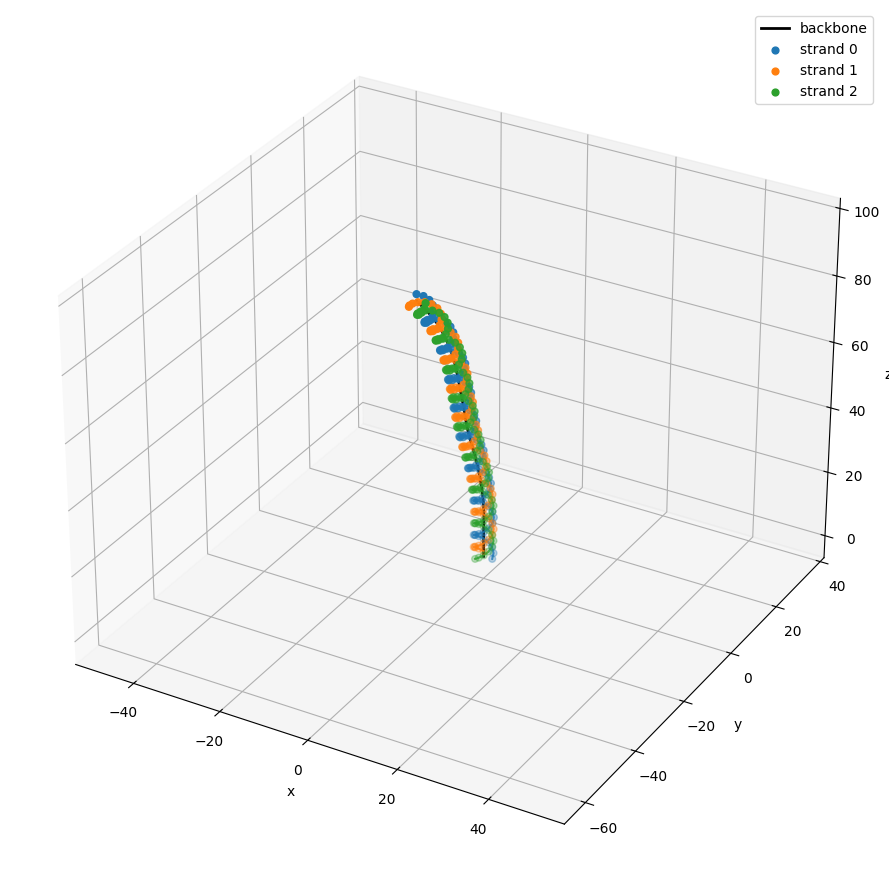

In [1331]:
plot_clean_helix(clean_helix)

In [1332]:
directed_edge_index = undirected_to_directed_edge_index(
    clean_helix.undirected_edge_index
)

print(clean_helix.undirected_edge_index.shape)
print(directed_edge_index.shape)

(2, 300)
(2, 600)


In [1333]:
for n_strands in [1, 2, 3, 4]:
    test_config = HelixConfig(
        rise=1.0,
        twist_rad=np.deg2rad(30.0),
        radius=2.0,
        n_strands=n_strands,
    )

    test_helix = generate_clean_helix(
        backbone=backbone,
        config=test_config,
    )

    test_validation = validate_clean_helix(
        helix=test_helix,
        config=test_config,
    )

    print(
        n_strands,
        test_validation["is_valid"],
        test_validation["metrics"],
    )

1 True {'n_nodes': 101, 'n_undirected_edges': 100, 'n_strands': 1, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392343, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
2 True {'n_nodes': 202, 'n_undirected_edges': 200, 'n_strands': 2, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392343, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
3 True {'n_nodes': 303, 'n_undirected_edges': 300, 'n_strands': 3, 'n_nodes_per_strand': 101, 'max_radius_error': 3.774758283725532e-15, 'mean_backbone_curvature': 0.009238176455392344, 'max_backbone_curvature': 0.021423357745849428, 'turns_per_strand': 8.333333333333332}
4 True {'n_nodes': 404, 'n_undirected_edges': 400, 'n_strands': 4, 'n_nodes_per_strand': 101, 'max_radius_error': 4.440892098500626e-15, 'mean_backbone_curvature': 0.009238176455392

# Rise, twist and radio variation

In [1334]:
@dataclass(frozen=True)
class ScalarProfileConfig:
    enabled: bool = False # Returns a constant profile or not
    std: float = 0.0 # Intensity of variation
    correlation_length: float = 10.0 # Physical distance that persists over the variation

    min_value: float | None = None 
    max_value: float | None = None

    anchor_start: bool = True # First value equal to nominal value

## Helix configuration

In [1335]:
@dataclass(frozen=True)
class HelixConfig:
    rise: float = 1.0
    twist_rad: float = np.deg2rad(30.0)
    radius: float = 2.0

    n_strands: int = 1
    initial_phase_rad: float= 0.0
    strand_phase_offsets_rad: tuple[float, ...] | None = None
    first_strand_id: int = 0

    rise_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )
    twist_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )
    radius_variation: ScalarProfileConfig = field(
        default_factory=ScalarProfileConfig
    )

    seed: int = 42

## Helix geometry 

In [1336]:
@dataclass
class CleanHelixGeometry:
    positions: np.ndarray
    backbone_positions: np.ndarray

    tangents: np.ndarray
    normals: np.ndarray
    binormals: np.ndarray

    arc_length: np.ndarray
    sequence_index: np.ndarray
    backbone_index: np.ndarray
    strand_id: np.ndarray

    phase_rad: np.ndarray
    strand_phase_offset_rad: np.ndarray
    radius: np.ndarray
    backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_strand_id: np.ndarray
    local_rise: np.ndarray
    local_twist_rad: np.ndarray

    shared_arc_length: np.ndarray
    shared_radius_profile: np.ndarray
    shared_local_rise: np.ndarray
    shared_local_twist_rad: np.ndarray
    shared_phase_rad: np.ndarray

    nominal_rise: float
    nominal_twist_rad: float
    nominal_radius: float

    global_rise: float
    global_twist_rad: float
    global_radius: float

    n_strands: int
    n_nodes_per_strand: int

In [1337]:
def validate_scalar_profile_config(
    config: ScalarProfileConfig,
    nominal_value: float,
    profile_name: str,
    require_positive: bool,
) -> None:
    """
    Valida la configuración de un perfil escalar.

    Parameters
    ----------
    config
        Configuración del perfil.
    nominal_value
        Valor alrededor del que fluctúa el perfil.
    profile_name
        Nombre usado en mensajes de error.
    require_positive
        Si True, todos los valores deben ser mayores que cero.
    """
    if not isinstance(config.enabled, (bool, np.bool_)):
        raise ValueError(
            f"{profile_name}.enabled must be boolean"
        )

    scalar_values = {
        "std": config.std,
        "correlation_length": config.correlation_length,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(
                f"{profile_name}.{name} must be finite"
            )

    if config.std < 0.0:
        raise ValueError(
            f"{profile_name}.std cannot be negative"
        )

    if config.correlation_length <= 0.0:
        raise ValueError(
            f"{profile_name}.correlation_length must be positive"
        )

    if config.min_value is not None:
        if not np.isfinite(config.min_value):
            raise ValueError(
                f"{profile_name}.min_value must be finite"
            )

    if config.max_value is not None:
        if not np.isfinite(config.max_value):
            raise ValueError(
                f"{profile_name}.max_value must be finite"
            )

    if (
        config.min_value is not None
        and config.max_value is not None
        and config.min_value > config.max_value
    ):
        raise ValueError(
            f"{profile_name}.min_value cannot be greater "
            "than max_value"
        )

    if (
        config.min_value is not None
        and nominal_value < config.min_value
    ):
        raise ValueError(
            f"nominal {profile_name} is below min_value"
        )

    if (
        config.max_value is not None
        and nominal_value > config.max_value
    ):
        raise ValueError(
            f"nominal {profile_name} is above max_value"
        )

    if require_positive:
        if nominal_value <= 0.0:
            raise ValueError(
                f"nominal {profile_name} must be positive"
            )

        if (
            config.min_value is not None
            and config.min_value <= 0.0
        ):
            raise ValueError(
                f"{profile_name}.min_value must be positive"
            )

    if config.enabled and config.std == 0.0:
        raise ValueError(
            f"{profile_name} variation is enabled but std is zero"
        )

In [1338]:
def validate_helix_config(
    config: HelixConfig,
    backbone: BackboneGeometry,
) -> None:
    """
    Valida la configuración helicoidal y sus perfiles.
    """
    scalar_values = {
        "rise": config.rise,
        "twist_rad": config.twist_rad,
        "radius": config.radius,
        "initial_phase_rad": config.initial_phase_rad,
    }

    for name, value in scalar_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

    if config.rise <= 0.0:
        raise ValueError("rise must be positive")

    if config.radius <= 0.0:
        raise ValueError("radius must be positive")

    if not isinstance(config.n_strands, (int, np.integer)):
        raise ValueError("n_strands must be an integer")

    if config.n_strands < 1:
        raise ValueError("n_strands must be at least one")

    if not isinstance(config.first_strand_id, (int, np.integer)):
        raise ValueError(
            "first_strand_id must be an integer"
        )

    if not isinstance(config.seed, (int, np.integer)):
        raise ValueError("seed must be an integer")

    if config.strand_phase_offsets_rad is not None:
        offsets = np.asarray(
            config.strand_phase_offsets_rad,
            dtype=np.float64,
        )

        if offsets.shape != (config.n_strands,):
            raise ValueError(
                "strand_phase_offsets_rad must contain "
                f"{config.n_strands} values"
            )

        if not np.all(np.isfinite(offsets)):
            raise ValueError(
                "strand_phase_offsets_rad contains "
                "non-finite values"
            )

    validate_scalar_profile_config(
        config=config.rise_variation,
        nominal_value=config.rise,
        profile_name="rise",
        require_positive=True,
    )

    validate_scalar_profile_config(
        config=config.twist_variation,
        nominal_value=config.twist_rad,
        profile_name="twist",
        require_positive=False,
    )

    validate_scalar_profile_config(
        config=config.radius_variation,
        nominal_value=config.radius,
        profile_name="radius",
        require_positive=True,
    )

    backbone_length = float(backbone.arc_length[-1])

    minimum_rise = (
        config.rise_variation.min_value
        if config.rise_variation.enabled
        and config.rise_variation.min_value is not None
        else config.rise
    )

    if minimum_rise > backbone_length:
        raise ValueError(
            "rise is too large for the backbone"
        )

    if backbone_length / minimum_rise < 2.0:
        raise ValueError(
            "the backbone cannot contain three helix nodes"
        )

## Application of limits

In [1339]:
def clip_profile_values(
    values: np.ndarray,
    config: ScalarProfileConfig,
) -> np.ndarray:
    """
    Apply the limits configurated in the profile
    """
    values = np.asarray(values, dtype=np.float64).copy()

    lower = (
        config.min_value
        if config.min_value is not None
        else -np.inf
    )

    upper = (
        config.max_value
        if config.max_value is not None
        else np.inf
    )

    return np.clip(values, lower, upper)

## Generate correlated profile

In [1340]:
def generate_correlated_scalar_profile(
    coordinate: np.ndarray,
    nominal_value: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a smooth scalar profile over the rising coordinates

    Use an Ornstein-Uhlenbeck discretized process, so the correlation is expressed in physical units of 'coordinate'

    Parameters 
    ----------
    coordinate
        Shape (N,)rising estrictly
    nominal_value
        Nominal mean of the profile
    config
        Variation configuration
    rng
        Random generator

    Returns
    -------
    np.ndarray
        float64 array with shape (N,)
    """
    coordinate = np.asarray(coordinate, dtype=np.float64)

    if coordinate.ndim != 1:
        raise ValueError(
            "coordinate must be one-dimensional"
        )

    if len(coordinate) < 1:
        raise ValueError(
            "coordinate must contain at least one value"
        )

    if not np.all(np.isfinite(coordinate)):
        raise ValueError(
            "coordinate contains non-finite values"
        )

    if len(coordinate) > 1:
        if np.any(np.diff(coordinate) <= 0.0):
            raise ValueError(
                "coordinate must be strictly increasing"
            )
    
    if not config.enabled:
        return np.full(
            len(coordinate),
            nominal_value,
            dtype=np.float64,
        )

    profile = np.empty(
        len(coordinate),
        dtype=np.float64,
    )

    if config.anchor_start:
        profile[0] = nominal_value
    else:
        profile[0] = rng.normal(
            loc=nominal_value,
            scale=config.std,
        )

    profile[0] = clip_profile_values(
        np.array([profile[0]], dtype=np.float64),
        config,
    )[0]

    for index in range(1, len(coordinate)):
        step = coordinate[index] - coordinate[index - 1]

        alpha = np.exp(
            -step / config.correlation_length
        )
        innovation_scale = (
            config.std * np.sqrt(1.0 - alpha**2)
        )

        deviation_previous = (
            profile[index - 1] - nominal_value
        )

        profile[index] = (
            nominal_value
            + alpha * deviation_previous
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
            )
        )

        profile[index] = clip_profile_values(
            np.array([profile[index]], dtype=np.float64),
            config,
        )[0]

    return profile

## Variable rise generation

In [1341]:
def generate_variable_rise_grid(
    backbone_length: float,
    nominal_rise: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate axial positions and local rises

    Returns
    -------
    arc_length
        Shape (N,), axial position of each node
    local_rise
        Shape (N-1,), separation between consecutive nodes
    """
    if backbone_length <= 0.0:
        raise ValueError(
            "backbone_length must be positive"
        )

    if nominal_rise <= 0.0:
        raise ValueError(
            "nominal_rise must be positive"
        )

    if not config.enabled:
        arc_length = build_helix_arc_length_grid(
            backbone_length=backbone_length,
            rise=nominal_rise,
        )

        return arc_length, np.diff(arc_length)

    minimum_rise = (
        config.min_value
        if config.min_value is not None
        else max(
            nominal_rise - 5.0 * config.std,
            0.05 * nominal_rise,
        )
    )

    if minimum_rise <= 0.0:
        raise ValueError(
            "rise_variation requires a positive effective minimum"
        )

    maximum_iterations = (
        int(np.ceil(backbone_length / minimum_rise)) + 2
    )

    arc_values = [0.0]
    rise_values = []

    if config.anchor_start:
        current_rise = nominal_rise
    else:
        current_rise = rng.normal(
            loc=nominal_rise,
            scale=config.std,
        )

    current_rise = clip_profile_values(
        np.array([current_rise], dtype=np.float64),
        config,
    )[0]

    if current_rise <= 0.0:
        raise ValueError(
            "generated rise must be positive"
        )

    for _ in range(maximum_iterations):
        current_position = arc_values[-1]
        next_position = current_position + current_rise

        if next_position > backbone_length:
            break

        rise_values.append(current_rise)
        arc_values.append(next_position)

        alpha = np.exp(
            -current_rise / config.correlation_length
        )
        innovation_scale = (
            config.std * np.sqrt(1.0 - alpha**2)
        )

        current_deviation = (
            current_rise - nominal_rise
        )

        next_rise = (
            nominal_rise
            + alpha * current_deviation
            + rng.normal(
                loc=0.0,
                scale=innovation_scale,
            )
        )

        current_rise = clip_profile_values(
            np.array([next_rise], dtype=np.float64),
            config,
        )[0]

        if current_rise <= 0.0:
            raise ValueError(
                "generated rise must remain positive"
            )

    arc_length = np.asarray(
        arc_values,
        dtype=np.float64,
    )
    local_rise = np.asarray(
        rise_values,
        dtype=np.float64,
    )

    if len(arc_length) < 3:
        raise ValueError(
        "rise profile generated fewer than three nodes"
    )

    if local_rise.shape != (len(arc_length) - 1,):
        raise RuntimeError(
            "inconsistent rise grid generation"
        )

    return arc_length, local_rise

## Twist profile generation

In [1342]:
def generate_local_twist_profile(
    arc_length: np.ndarray,
    nominal_twist_rad: float,
    config: ScalarProfileConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a twist for each segment

    Returns
    -------
    np.ndarray
        Shape (N-1,), twist between each pair of consecutive nodes
    """
    arc_length = np.asanyarray(
        arc_length,
        dtype=np.float64,
    )

    if arc_length.ndim != 1 or len(arc_length) < 2:
        raise ValueError(
            "arc_length must contain at least two points"
        )

    # Each i segment twist is associated with its initial point
    segment_coordinate = arc_length[:-1]

    return generate_correlated_scalar_profile(
        coordinate=segment_coordinate,
        nominal_value=nominal_twist_rad,
        config=config,
        rng=rng,
    )

## Transform local twist into phase

In [1343]:
def integrate_twist_to_phase(
        local_twist_rad: np.ndarray,
        initial_phase_rad: float,
) -> np.ndarray:
    """
    Twists integration between segments for obtaining a phase per node

    Parameters
    ----------
    local_twist_rad
        Shape (N-1,)
    initial_phase_rad
        Phase of the first node

    Returns
    -------
    np.ndarray
        Accumulated phase with shape (N,)
    """
    local_twist_rad = np.asarray(
        local_twist_rad,
        dtype=np.float64,
    )

    if local_twist_rad.ndim != 1:
        raise ValueError(
            "local_twist_rad must be one-dimensional"
        )

    if not np.all(np.isfinite(local_twist_rad)):
        raise ValueError(
            "local_twist_rad contains non-finite values"
        )

    phase = np.empty(
        len(local_twist_rad) + 1,
        dtype=np.float64,
    )

    phase[0] = initial_phase_rad
    phase[1:] = (
        initial_phase_rad
        + np.cumsum(local_twist_rad)
    )

    return phase

## Local radius generation

In [1344]:
def generate_local_radius_profile(
        arc_length: np.ndarray,
        nominal_radius: float,
        config: ScalarProfileConfig,
        rng:np.random.Generator,
) -> np.ndarray:
    """
    Generate a radius per node

    Returns
    -------
    np.ndarray
        Radius profile with shape (N,)
    """
    radius_profile = generate_correlated_scalar_profile(
        coordinate=arc_length,
        nominal_value=nominal_radius,
        config=config,
        rng=rng,
    )

    if np.any(radius_profile <= 0.0):
        raise ValueError(
            "radius profile must remain positive"
        )

    return radius_profile

## Generate independant random profiles

In [1345]:
def create_helix_profile_generators(
        seed: int,
) -> tuple[
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
]:
    """
    Create independent generators for rise, twist and radius
    """
    seed_sequence = np.random.SeedSequence(seed)
    rise_seed, twist_seed, radius_seed = (
        seed_sequence.spawn(3)
    )

    return (
        np.random.default_rng(rise_seed),
        np.random.default_rng(twist_seed),
        np.random.default_rng(radius_seed),
    )

## Expansion of the profile over the strand

In [1346]:
def expand_node_profile_by_strand(
        profile: np.ndarray,
        n_strands: int,
) -> np.ndarray:
    """
    Repeat the profile per node for all the strands

    Input shape (L,), output shape (S*L,)
    """
    profile = np.asarray(profile)

    if profile.ndim != 1:
        raise ValueError(
            "profile must be one-dimensional"
        )

    if n_strands < 1:
        raise ValueError(
            "n_strands must be at least one"
        )

    return np.tile(profile, n_strands)

def expand_edge_profile_by_strand(
        profile: np.ndarray,
        n_strands: int,
) -> np.ndarray:
    """
    Repeat the profile per segment for each of the strands

    Input shape (L-1,), output shape(S*(L-1),)
    """
    profile = np.asarray(profile)

    if profile.ndim != 1:
        raise ValueError(
            "profile must be one-dimensional"
        )

    if n_strands < 1:
        raise ValueError(
            "n_strands must be at least one"
        )

    return np.tile(profile, n_strands)

## Helix generation

In [1347]:
def generate_clean_helix(
        backbone: BackboneGeometry,
        config: HelixConfig,
) -> CleanHelixGeometry:
    """
    Generate a multistrand helix with constant or smootly variable rise, twist and radius 
    """
    validate_helix_config(
        config=config,
        backbone=backbone,
    )

    (
        rise_rng,
        twist_rng,
        radius_rng,
    ) = create_helix_profile_generators(config.seed)

    backbone_length = float(
        backbone.arc_length[-1]
    )

    (
        shared_arc_length,
        shared_local_rise,
    ) = generate_variable_rise_grid(
        backbone_length=backbone_length,
        nominal_rise=config.rise,
        config=config.rise_variation,
        rng=rise_rng,
    )

    sampled_backbone = resample_backbone(
        backbone=backbone,
        target_arc_length=shared_arc_length,
    )

    shared_local_twist_rad = (
        generate_local_twist_profile(
            arc_length=shared_arc_length,
            nominal_twist_rad=config.twist_rad,
            config=config.twist_variation,
            rng=twist_rng,
        )
    )

    shared_phase_rad = integrate_twist_to_phase(
        local_twist_rad=shared_local_twist_rad,
        initial_phase_rad=config.initial_phase_rad,
    )

    shared_radius_profile = (
        generate_local_radius_profile(
            arc_length=shared_arc_length,
            nominal_radius=config.radius,
            config=config.radius_variation,
            rng=radius_rng,
        )
    )

    n_strands = config.n_strands
    n_nodes_per_strand = len(shared_arc_length)

    sequence_index_1d = np.arange(
        n_nodes_per_strand,
        dtype=np.int64,
    )

    strand_ids= (
        config.first_strand_id
        + np.arange(n_strands, dtype=np.int64)
    )

    phase_offsets = resolve_strand_phase_offsets(
        config
    )

    phase_matrix = (
        phase_offsets[:, None]
        + shared_phase_rad[None, :]
    )

    radial_directions = (
        np.cos(phase_matrix)[:, :, None]
        * sampled_backbone.normals[None, :, :,]
        + np.sin(phase_matrix)[:, :, None]
        * sampled_backbone.binormals[None, :, :]
    )

    positions_matrix = (
        sampled_backbone.positions[None, : , :]
        + shared_radius_profile[None, :, None]
        * radial_directions
    )

    positions = positions_matrix.reshape(-1, 3)

    backbone_positions = np.broadcast_to(
        sampled_backbone.positions[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    tangents = np.broadcast_to(
        sampled_backbone.tangents[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    normals = np.broadcast_to(
        sampled_backbone.normals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    binormals = np.broadcast_to(
        sampled_backbone.binormals[None, :, :],
        (n_strands, n_nodes_per_strand, 3),
    ).reshape(-1, 3).copy()

    arc_length = expand_node_profile_by_strand(
        shared_arc_length,
        n_strands,
    )

    sequence_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    backbone_index = np.tile(
        sequence_index_1d,
        n_strands,
    )

    strand_id = np.repeat(
        strand_ids,
        n_nodes_per_strand,
    )

    phase_rad = phase_matrix.reshape(-1)

    strand_phase_offset_rad = np.repeat(
        phase_offsets,
        n_nodes_per_strand,
    )

    radius = expand_node_profile_by_strand(
        shared_radius_profile,
        n_strands,
    )

    backbone_curvature = (
        expand_node_profile_by_strand(
            sampled_backbone.curvature,
            n_strands,
        )
    )

    (
        undirected_edge_index,
        edge_strand_id,
    ) = build_undirected_strand_edges(
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
        first_strand_id=config.first_strand_id,
    )

    local_rise = expand_edge_profile_by_strand(
        shared_local_rise,
        n_strands,
    )

    local_twist_rad = (
        expand_edge_profile_by_strand(
            shared_local_twist_rad,
            n_strands,
        )
    )

    return CleanHelixGeometry(
        positions=positions,
        backbone_positions=backbone_positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        arc_length=arc_length,
        sequence_index=sequence_index,
        backbone_index=backbone_index,
        strand_id=strand_id,
        phase_rad=phase_rad,
        strand_phase_offset_rad=strand_phase_offset_rad,
        radius=radius,
        backbone_curvature=backbone_curvature,
        undirected_edge_index=undirected_edge_index,
        edge_strand_id=edge_strand_id,
        local_rise=local_rise,
        local_twist_rad=local_twist_rad,
        shared_arc_length=shared_arc_length,
        shared_radius_profile=shared_radius_profile,
        shared_local_rise=shared_local_rise,
        shared_local_twist_rad=shared_local_twist_rad,
        shared_phase_rad=shared_phase_rad,
        nominal_rise=float(config.rise),
        nominal_twist_rad=float(config.twist_rad),
        nominal_radius=float(config.radius),
        global_rise=float(
            np.mean(shared_local_rise)
        ),
        global_twist_rad=float(
            np.mean(shared_local_twist_rad)
        ),
        global_radius=float(
            np.mean(shared_radius_profile)
        ),
        n_strands=n_strands,
        n_nodes_per_strand=n_nodes_per_strand,
    )


In [1348]:
def validate_clean_helix(
    helix: CleanHelixGeometry,
    config: HelixConfig,
    atol: float = 1e-8,
) -> dict[str, Any]:
    """
    Valida geometría, perfiles, fases y aristas.
    """
    n_strands = helix.n_strands
    nodes_per_strand = helix.n_nodes_per_strand

    n_nodes = n_strands * nodes_per_strand
    edges_per_strand = nodes_per_strand - 1
    n_edges = n_strands * edges_per_strand

    vector_fields = {
        "positions": helix.positions,
        "backbone_positions": helix.backbone_positions,
        "tangents": helix.tangents,
        "normals": helix.normals,
        "binormals": helix.binormals,
    }

    for name, array in vector_fields.items():
        if array.shape != (n_nodes, 3):
            raise ValueError(
                f"{name} must have shape ({n_nodes}, 3)"
            )

    node_fields = {
        "arc_length": helix.arc_length,
        "sequence_index": helix.sequence_index,
        "backbone_index": helix.backbone_index,
        "strand_id": helix.strand_id,
        "phase_rad": helix.phase_rad,
        "strand_phase_offset_rad": (
            helix.strand_phase_offset_rad
        ),
        "radius": helix.radius,
        "backbone_curvature": helix.backbone_curvature,
    }

    for name, array in node_fields.items():
        if array.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    edge_fields = {
        "edge_strand_id": helix.edge_strand_id,
        "local_rise": helix.local_rise,
        "local_twist_rad": helix.local_twist_rad,
    }

    for name, array in edge_fields.items():
        if array.shape != (n_edges,):
            raise ValueError(
                f"{name} must have shape ({n_edges},)"
            )

    if helix.undirected_edge_index.shape != (2, n_edges):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    if helix.shared_arc_length.shape != (nodes_per_strand,):
        raise ValueError(
            "shared_arc_length has an invalid shape"
        )

    if helix.shared_radius_profile.shape != (
        nodes_per_strand,
    ):
        raise ValueError(
            "shared_radius_profile has an invalid shape"
        )

    if helix.shared_phase_rad.shape != (
        nodes_per_strand,
    ):
        raise ValueError(
            "shared_phase_rad has an invalid shape"
        )

    if helix.shared_local_rise.shape != (
        edges_per_strand,
    ):
        raise ValueError(
            "shared_local_rise has an invalid shape"
        )

    if helix.shared_local_twist_rad.shape != (
        edges_per_strand,
    ):
        raise ValueError(
            "shared_local_twist_rad has an invalid shape"
        )

    source = helix.undirected_edge_index[0]
    target = helix.undirected_edge_index[1]

    measured_radius = np.linalg.norm(
        helix.positions - helix.backbone_positions,
        axis=1,
    )

    phase_difference = (
        helix.phase_rad[target]
        - helix.phase_rad[source]
    )

    arc_difference = (
        helix.arc_length[target]
        - helix.arc_length[source]
    )

    expected_phase_from_twist = (
        integrate_twist_to_phase(
            helix.shared_local_twist_rad,
            config.initial_phase_rad,
        )
    )

    all_arrays = (
        list(vector_fields.values())
        + list(node_fields.values())
        + list(edge_fields.values())
        + [
            helix.shared_arc_length,
            helix.shared_radius_profile,
            helix.shared_local_rise,
            helix.shared_local_twist_rad,
            helix.shared_phase_rad,
        ]
    )

    checks = {
        "all_finite": bool(
            all(
                np.all(np.isfinite(array))
                for array in all_arrays
            )
        ),
        "number_of_strands_is_correct": bool(
            n_strands == config.n_strands
        ),
        "radius_matches_geometry": bool(
            np.allclose(
                measured_radius,
                helix.radius,
                atol=atol,
            )
        ),
        "radius_is_positive": bool(
            np.all(helix.radius > 0.0)
        ),
        "rise_is_positive": bool(
            np.all(helix.local_rise > 0.0)
        ),
        "arc_length_is_consistent": bool(
            np.allclose(
                arc_difference,
                helix.local_rise,
                atol=atol,
            )
        ),
        "phase_is_consistent": bool(
            np.allclose(
                phase_difference,
                helix.local_twist_rad,
                atol=atol,
            )
        ),
        "shared_phase_is_consistent": bool(
            np.allclose(
                helix.shared_phase_rad,
                expected_phase_from_twist,
                atol=atol,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_inside_strands": bool(
            np.all(
                helix.strand_id[source]
                == helix.strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                helix.sequence_index[target]
                - helix.sequence_index[source]
                == 1
            )
        ),
        "global_rise_is_correct": bool(
            np.isclose(
                helix.global_rise,
                np.mean(helix.shared_local_rise),
                atol=atol,
            )
        ),
        "global_twist_is_correct": bool(
            np.isclose(
                helix.global_twist_rad,
                np.mean(
                    helix.shared_local_twist_rad
                ),
                atol=atol,
            )
        ),
        "global_radius_is_correct": bool(
            np.isclose(
                helix.global_radius,
                np.mean(
                    helix.shared_radius_profile
                ),
                atol=atol,
            )
        ),
    }

    unique_edges = np.unique(
        helix.undirected_edge_index.T,
        axis=0,
    )

    checks["edges_are_unique"] = bool(
        len(unique_edges) == n_edges
    )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "n_strands": n_strands,
        "n_nodes_per_strand": nodes_per_strand,
        "rise_min": float(
            np.min(helix.shared_local_rise)
        ),
        "rise_mean": float(
            np.mean(helix.shared_local_rise)
        ),
        "rise_max": float(
            np.max(helix.shared_local_rise)
        ),
        "twist_min_deg": float(
            np.rad2deg(
                np.min(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "twist_mean_deg": float(
            np.rad2deg(
                np.mean(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "twist_max_deg": float(
            np.rad2deg(
                np.max(
                    helix.shared_local_twist_rad
                )
            )
        ),
        "radius_min": float(
            np.min(helix.shared_radius_profile)
        ),
        "radius_mean": float(
            np.mean(helix.shared_radius_profile)
        ),
        "radius_max": float(
            np.max(helix.shared_radius_profile)
        ),
        "max_radius_geometry_error": float(
            np.max(
                np.abs(
                    measured_radius - helix.radius
                )
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

## Visualization

In [1349]:
def plot_helix_profiles(
    helix: CleanHelixGeometry,
):
    """
    Muestra los perfiles compartidos de rise, twist, radio y fase.
    """
    fig, axes = plt.subplots(
        4,
        1,
        figsize=(11, 12),
        sharex=False,
    )

    axes[0].plot(
        helix.shared_arc_length,
        helix.shared_radius_profile,
        color="tab:blue",
    )
    axes[0].axhline(
        helix.nominal_radius,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[0].set_ylabel("radius")
    axes[0].legend()

    axes[1].plot(
        helix.shared_arc_length[:-1],
        helix.shared_local_rise,
        color="tab:green",
    )
    axes[1].axhline(
        helix.nominal_rise,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[1].set_ylabel("rise")
    axes[1].legend()

    axes[2].plot(
        helix.shared_arc_length[:-1],
        np.rad2deg(
            helix.shared_local_twist_rad
        ),
        color="tab:red",
    )
    axes[2].axhline(
        np.rad2deg(helix.nominal_twist_rad),
        color="black",
        linestyle="--",
        alpha=0.6,
        label="nominal",
    )
    axes[2].set_ylabel("twist (deg)")
    axes[2].legend()

    axes[3].plot(
        helix.shared_arc_length,
        np.rad2deg(helix.shared_phase_rad),
        color="tab:purple",
    )
    axes[3].set_xlabel("backbone arc length")
    axes[3].set_ylabel("phase (deg)")

    plt.tight_layout()

    return fig, axes

In [1350]:
helix_config = HelixConfig(
    rise=1.0,
    twist_rad=np.deg2rad(30.0),
    radius=2.0,

    n_strands=3,
    initial_phase_rad=0.0,
    strand_phase_offsets_rad=None,
    first_strand_id=0,

    rise_variation=ScalarProfileConfig(
        enabled=True,
        std=0.08,
        correlation_length=12.0,
        min_value=0.75,
        max_value=1.25,
        anchor_start=True,
    ),

    twist_variation=ScalarProfileConfig(
        enabled=True,
        std=np.deg2rad(3.0),
        correlation_length=15.0,
        min_value=np.deg2rad(20.0),
        max_value=np.deg2rad(40.0),
        anchor_start=True,
    ),

    radius_variation=ScalarProfileConfig(
        enabled=True,
        std=0.15,
        correlation_length=18.0,
        min_value=1.5,
        max_value=2.5,
        anchor_start=True,
    ),

    seed=13,
)

In [1351]:
clean_helix = generate_clean_helix(
    backbone=backbone,
    config=helix_config,
)

validation = validate_clean_helix(
    helix=clean_helix,
    config=helix_config,
)

validation

{'is_valid': True,
 'checks': {'all_finite': True,
  'number_of_strands_is_correct': True,
  'radius_matches_geometry': True,
  'radius_is_positive': True,
  'rise_is_positive': True,
  'arc_length_is_consistent': True,
  'phase_is_consistent': True,
  'shared_phase_is_consistent': True,
  'edges_are_canonical': True,
  'edges_are_inside_strands': True,
  'edges_join_consecutive_nodes': True,
  'global_rise_is_correct': True,
  'global_twist_is_correct': True,
  'global_radius_is_correct': True,
  'edges_are_unique': True},
 'metrics': {'n_nodes': 291,
  'n_undirected_edges': 288,
  'n_strands': 3,
  'n_nodes_per_strand': 97,
  'rise_min': 0.9398399266171136,
  'rise_mean': 1.0350824370138867,
  'rise_max': 1.1855272851913765,
  'twist_min_deg': 26.605941952309298,
  'twist_mean_deg': 29.26180407857044,
  'twist_max_deg': 32.62821004895348,
  'radius_min': 1.7712711357990194,
  'radius_mean': 1.9942125430269642,
  'radius_max': 2.1663062696401307,
  'max_radius_geometry_error': 4.66293

(<Figure size 1100x1200 with 4 Axes>,
 array([<Axes: ylabel='radius'>, <Axes: ylabel='rise'>,
        <Axes: ylabel='twist (deg)'>,
        <Axes: xlabel='backbone arc length', ylabel='phase (deg)'>],
       dtype=object))

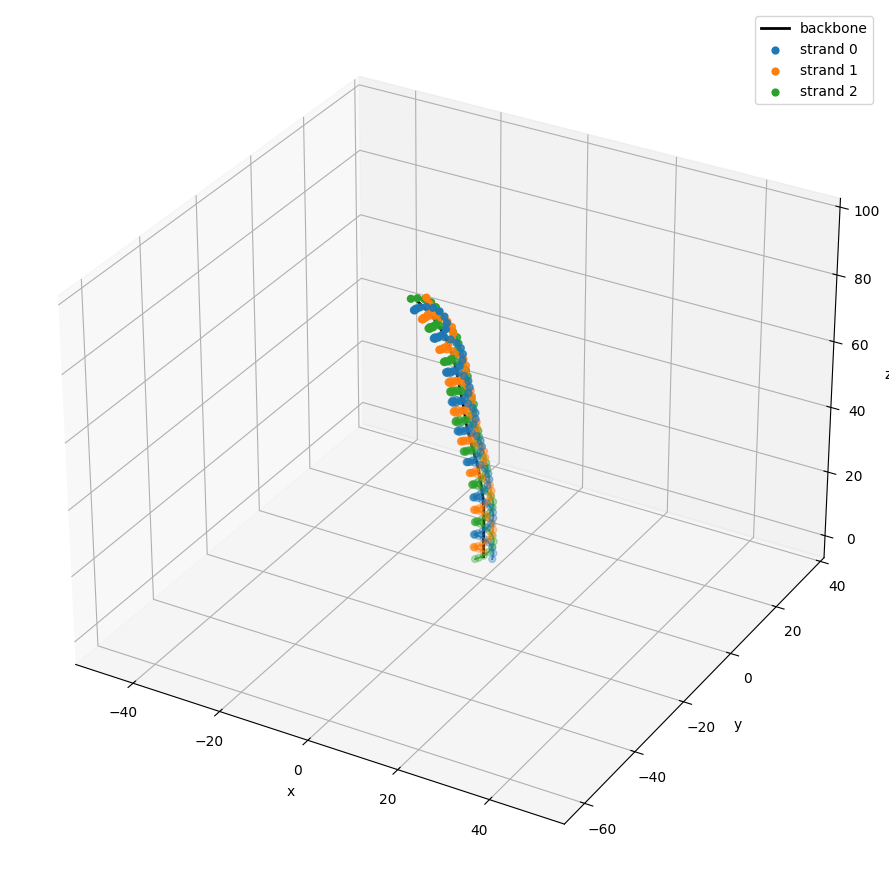

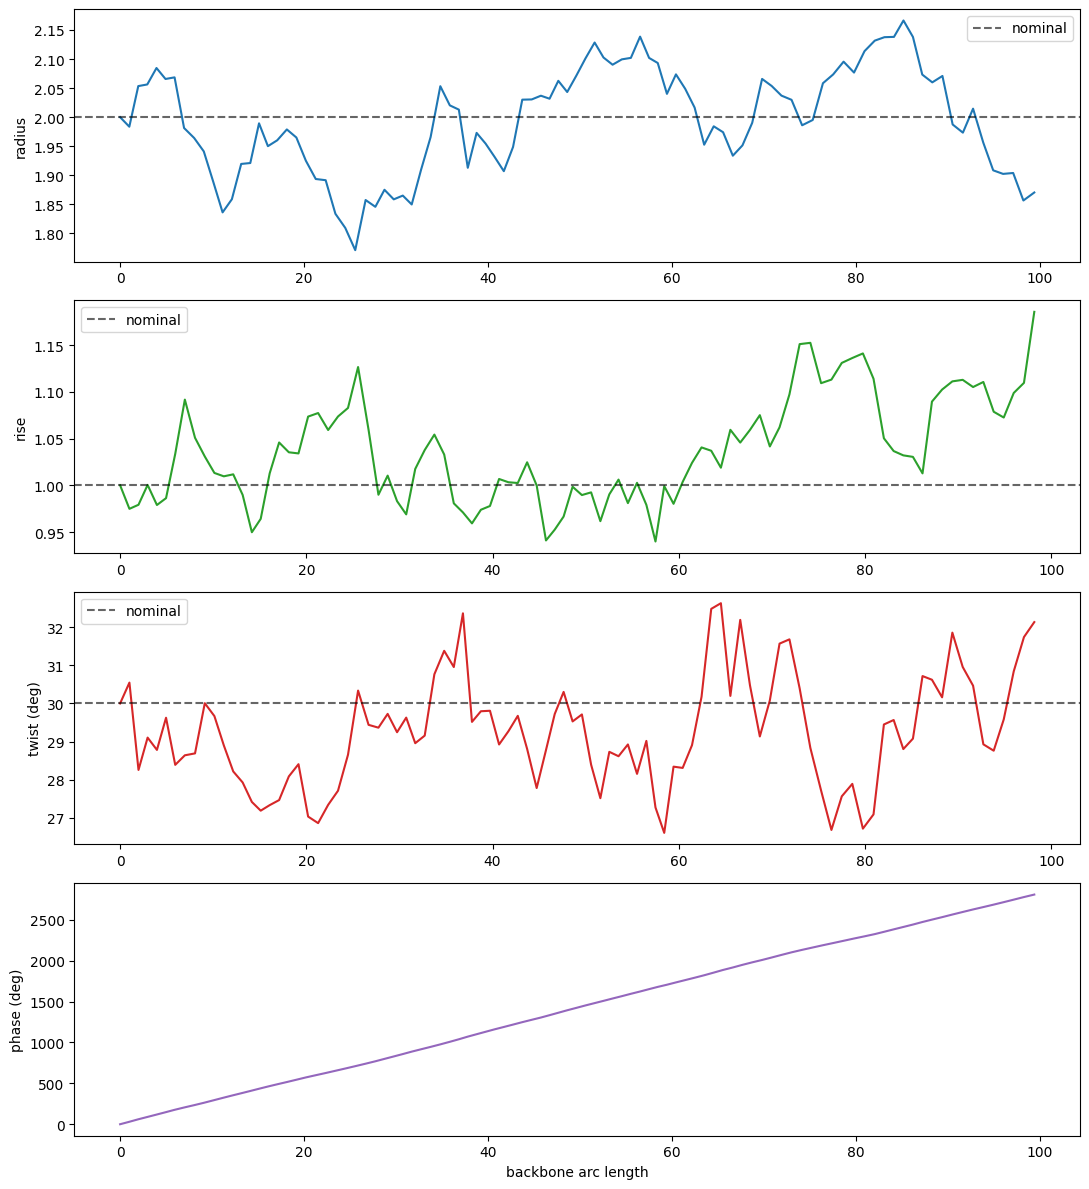

In [1352]:
plot_clean_helix(clean_helix)
plot_helix_profiles(clean_helix)

In [1353]:
helix_config_without_radius_variation = (
    HelixConfig(
        rise=helix_config.rise,
        twist_rad=helix_config.twist_rad,
        radius=helix_config.radius,
        n_strands=helix_config.n_strands,
        initial_phase_rad=helix_config.initial_phase_rad,
        strand_phase_offsets_rad=(
            helix_config.strand_phase_offsets_rad
        ),
        first_strand_id=helix_config.first_strand_id,
        rise_variation=helix_config.rise_variation,
        twist_variation=helix_config.twist_variation,
        radius_variation=ScalarProfileConfig(
            enabled=False
        ),
        seed=helix_config.seed,
    )
)

helix_without_radius_variation = generate_clean_helix(
    backbone=backbone,
    config=helix_config_without_radius_variation,
)

{
    "same_rise": np.array_equal(
        clean_helix.shared_local_rise,
        helix_without_radius_variation.shared_local_rise,
    ),
    "same_twist": np.array_equal(
        clean_helix.shared_local_twist_rad,
        helix_without_radius_variation.shared_local_twist_rad,
    ),
}

{'same_rise': True, 'same_twist': True}

# Degradation

In [1354]:
@dataclass(frozen=True)
class DegradationConfig:
    missing_fraction: float = 0.0 # Fraction of the nodes deleted
    max_gap_size: int = 1 # Max consecutive nodes deleted
    shared_missing_mask_across_strands: bool = False # Gaps appear always on the same indices
    protect_strand_ends: bool = True # Save first and last nodes

    displacement_fraction: float = 0.0 # Fraction of real nodes that are displaced
    displacement_std: float = 0.0 # Typical deviation of the displacement

    near_false_positive_fraction: float = 0.0 # False positives close to real nodes, relative to the true observed nodes
    near_false_positive_std: float = 1.0

    background_false_positive_fraction: float = 0.0 # False positives distributed around the full volume
    background_margin_fraction: float = 0.25

    shuffle_observed_nodes: bool = True # Forbid that the order of the array shows which are the true nodes

    seed: int = 42

In [1355]:
# Training metadata
FALSE_POSITIVE_NONE = np.int8(0)
FALSE_POSITIVE_NEAR_STRUCTURE = np.int8(1)
FALSE_POSITIVE_BACKGROUND = np.int8(2)

### Gap table

In [1356]:
@dataclass
class GapTable:
    strand_id: np.ndarray
    gap_id: np.ndarray

    start_sequence_index: np.ndarray
    end_sequence_index: np.ndarray
    gap_size: np.ndarray
    
    left_clean_node_index: np.ndarray
    right_clean_node_index: np.ndarray

    missing_clean_node_indices: tuple[np.ndarray, ...]

### Observed helix

In [1357]:
@dataclass
class ObservedHelixGeometry:
    # Input of the future model
    observed_positions: np.ndarray

    # Latent labels per observed nodes
    observed_to_clean_index: np.ndarray # False positive == -1
    observed_is_true: np.ndarray
    observed_is_displaced: np.ndarray
    observed_false_positive_type: np.ndarray

    # Correspondence from clean geometry
    clean_to_observed_index: np.ndarray # Missing node == -1
    clean_is_observed: np.ndarray
    clean_is_missing: np.ndarray

    # Displacement applied to true nodes
    clean_displacement: np.ndarray

    # Gap structural information
    gap_table: GapTable

    # Complete reference; only available during training
    clean_helix: CleanHelixGeometry

    # Summary
    n_observed_true: int
    n_missing: int
    n_near_false_positives: int
    n_background_false_positives: int

In [1358]:
def validate_degradation_config(
    config: DegradationConfig,
    clean_helix: CleanHelixGeometry,
) -> None:
    """
    Valida los parámetros de degradación respecto a una hélice limpia.
    """
    fraction_values = {
        "missing_fraction": config.missing_fraction,
        "displacement_fraction": config.displacement_fraction,
        "near_false_positive_fraction": (
            config.near_false_positive_fraction
        ),
        "background_false_positive_fraction": (
            config.background_false_positive_fraction
        ),
    }

    for name, value in fraction_values.items():
        if not np.isfinite(value):
            raise ValueError(f"{name} must be finite")

        if value < 0.0:
            raise ValueError(f"{name} cannot be negative")

    if config.missing_fraction >= 1.0:
        raise ValueError(
            "missing_fraction must be smaller than one"
        )

    if config.displacement_fraction > 1.0:
        raise ValueError(
            "displacement_fraction cannot exceed one"
        )

    positive_values = {
        "near_false_positive_std": (
            config.near_false_positive_std
        ),
        "background_margin_fraction": (
            config.background_margin_fraction
        ),
    }

    for name, value in positive_values.items():
        if not np.isfinite(value) or value < 0.0:
            raise ValueError(
                f"{name} must be finite and non-negative"
            )

    if (
        not np.isfinite(config.displacement_std)
        or config.displacement_std < 0.0
    ):
        raise ValueError(
            "displacement_std must be finite and non-negative"
        )

    if not isinstance(config.max_gap_size, (int, np.integer)):
        raise ValueError("max_gap_size must be an integer")

    if config.max_gap_size < 1:
        raise ValueError(
            "max_gap_size must be at least one"
        )

    if not isinstance(config.seed, (int, np.integer)):
        raise ValueError("seed must be an integer")

    boolean_values = {
        "shared_missing_mask_across_strands": (
            config.shared_missing_mask_across_strands
        ),
        "protect_strand_ends": config.protect_strand_ends,
        "shuffle_observed_nodes": config.shuffle_observed_nodes,
    }

    for name, value in boolean_values.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    if not config.protect_strand_ends:
        raise ValueError(
            "the current implementation requires "
            "protect_strand_ends=True"
        )

    n_nodes_per_strand = clean_helix.n_nodes_per_strand

    n_missing = int(
        round(
            config.missing_fraction
            * n_nodes_per_strand
        )
    )

    maximum_missing = n_nodes_per_strand - 2

    if n_missing > maximum_missing:
        raise ValueError(
            "missing_fraction removes too many nodes while "
            "protecting strand endpoints"
        )

### Limited random composition

In [1359]:
def sample_bounded_positive_composition(
    total: int,
    n_parts: int,
    max_part: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Divide 'total' in 'n_parts' positives integers <= 'max_part'Any

    Returns
    -------
    np.ndarray
        Shape (n_parts,), sum 'total' exactly
    """
    if not isinstance(total, (int, np.integer)):
        raise ValueError("total must be an integer")

    if not isinstance(n_parts, (int, np.integer)):
        raise ValueError("n_parts must be an integer")

    if not isinstance(max_part, (int, np.integer)):
        raise ValueError("max_part must be an integer")

    if total < 1:
        raise ValueError("total must be positive")

    if n_parts < 1:
        raise ValueError("n_parts must be positive")

    if max_part < 1:
        raise ValueError("max_part must be positive")

    if total < n_parts:
        raise ValueError(
            "total is too small for the requested number of parts"
        )

    if total > n_parts * max_part:
        raise ValueError(
            "total is too large for the requested bounded composition"
        )

    parts = np.ones(n_parts, dtype=np.int64)
    remaining = total - n_parts

    while remaining > 0:
        available = np.flatnonzero(parts < max_part)

        if len(available) == 0:
            raise RuntimeError(
                "no capacity remains in bounded composition"
            )

        selected = int(rng.choice(available))
        parts[selected] += 1
        remaining -= 1

    rng.shuffle(parts)

    return parts

### Constrution of gap mask

In [1360]:
def sample_internal_gap_mask(
    n_nodes: int,
    missing_fraction: float,
    max_gap_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate internal gaps preserving the first and the last node

    Returns
    -------
    np.ndarray
        Boolean mask shape (n_nodes,). True indicates missing node
    """
    if n_nodes < 3:
        raise ValueError("at least three nodes are required")

    if missing_fraction < 0.0 or missing_fraction >= 1.0:
        raise ValueError(
            "missing_fraction must be in [0, 1)"
        )

    if max_gap_size < 1:
        raise ValueError(
            "max_gap_size must be at least one"
        )

    n_missing = int(round(missing_fraction * n_nodes))
    n_missing = min(n_missing, n_nodes - 2)

    missing_mask = np.zeros(n_nodes, dtype=bool)

    if n_missing == 0:
        return missing_mask

    n_observed = n_nodes - n_missing

    minimum_n_gaps = int(
        np.ceil(n_missing / max_gap_size)
    )

    maximum_n_gaps = min(
        n_missing,
        n_observed - 1,
    )

    if minimum_n_gaps > maximum_n_gaps:
        raise ValueError(
            "request missing fraction and max_gap_size "
            "cannot preserve observed nodes between gaps"
        )

    n_gaps = int(
        rng.integers(
            minimum_n_gaps,
            maximum_n_gaps + 1,
        )
    )

    gap_lengths = sample_bounded_positive_composition(
        total=n_missing,
        n_parts=n_gaps,
        max_part=max_gap_size,
        rng=rng,
    )

    observed_block_lengths = np.ones(
        n_gaps + 1,
        dtype=np.int64,
    )

    remaining_observed = (
        n_observed - (n_gaps + 1)
    )

    if remaining_observed > 0:
        extra_observed = rng.multinomial(
            remaining_observed,
            np.full(
                n_gaps + 1,
                1.0 / (n_gaps +1),
            ),
        )

        observed_block_lengths += extra_observed

    cursor = 0

    for gap_index in range(n_gaps):
        cursor += int(
            observed_block_lengths[gap_index]
        )

        gap_length = int(gap_lengths[gap_index])

        missing_mask[
            cursor : cursor + gap_length
        ] = True

        cursor += gap_length

    cursor += int(observed_block_lengths[-1])

    if cursor != n_nodes:
        raise RuntimeError(
            "gap mask construction produced an invalid length"
        )

    if missing_mask[0] or missing_mask[-1]:
        raise RuntimeError(
            "protected strand endpoints were removed"
        )

    if int(missing_mask.sum()) != n_missing:
        raise RuntimeError(
            "gap mask has an incorrect number of missing nodes"
        )

    return missing_mask


### Maximum length gap

In [1361]:
def maximum_true_run_length(
    mask: np.ndarray,
) -> int:
    """
    Returns maximum length of True values
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.ndim != 1:
        raise ValueError("mask must be one-dimensional")

    if len(mask) == 0 or not np.any(mask):
        return 0

    padded = np.concatenate([
        np.array([False]),
        mask,
        np.array([False]),
    ])

    changes = np.diff(padded.astype(np.int8))

    run_starts = np.flatnonzero(changes == 1)
    run_ends = np.flatnonzero(changes == -1)

    return int(
        np.max(run_ends - run_starts)
    )

### Multistrand missing mask

In [1362]:
def generate_multistrand_missing_mask(
    clean_helix: CleanHelixGeometry,
    config: DegradationConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a missing mask with shape (N_clean,)
    """
    n_strands = clean_helix.n_strands
    nodes_per_strand = clean_helix.n_nodes_per_strand

    mask_matrix = np.zeros(
        (n_strands, nodes_per_strand),
        dtype=bool,
    )

    if config.missing_fraction == 0.0:
        return mask_matrix.reshape(-1)

    if config.shared_missing_mask_across_strands:
        shared_mask = sample_internal_gap_mask(
            n_nodes=nodes_per_strand,
            missing_fraction=config.missing_fraction,
            max_gap_size=config.max_gap_size,
            rng=rng,
        )

        mask_matrix[:] = shared_mask[None, :]
    else:
        for strand_position in range(n_strands):
            mask_matrix[strand_position] = (
                sample_internal_gap_mask(
                    n_nodes=nodes_per_strand,
                    missing_fraction=config.missing_fraction,
                    max_gap_size=config.max_gap_size,
                    rng=rng,
                )
            )

    return mask_matrix.reshape(-1)

### Extract gap intervals

In [1363]:
def find_true_runs(
    mask: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Find continuous True intervals into a mask

    Returns
    -------
    starts, ends
        Initial indices included and excluded 
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.ndim != 1:
        raise ValueError("mask must be one-dimensional")

    padded = np.concatenate([
        np.array([False]),
        mask,
        np.array([False]),
    ])

    changes = np.diff(padded.astype(np.int8))

    starts = np.flatnonzero(changes == 1).astype(
        np.int64
    )

    ends = np.flatnonzero(changes == -1).astype(
        np.int64
    )

    return starts, ends

### Gap table

In [1364]:
def build_gap_table(
    clean_helix: CleanHelixGeometry,
    clean_is_missing: np.ndarray,
) -> GapTable:
    """
    Builds a table with a register per continuous gap
    """
    clean_is_missing = np.asarray(
        clean_is_missing,
        dtype=bool,
    )

    n_clean = len(clean_helix.positions)

    if clean_is_missing.shape != (n_clean,):
        raise ValueError(
            "clean_is_missing has an invalid shape"
        )

    strand_ids_output = []
    gap_ids_output = []
    start_sequence_output = []
    end_sequence_output = []
    gap_size_output = []
    left_clean_output = []
    right_clean_output = []
    missing_indices_output = []

    nodes_per_strand = clean_helix.n_nodes_per_strand
    unique_strands = np.unique(clean_helix.strand_id)

    global_gap_id = 0

    for strand_position, strand_value in enumerate(
        unique_strands
    ):
        global_start = (
            strand_position * nodes_per_strand
        )
        global_end = global_start + nodes_per_strand

        strand_missing = clean_is_missing[
            global_start:global_end
        ]

        starts, ends = find_true_runs(strand_missing)

        for local_start, local_end in zip(starts, ends):
            if local_start == 0 or local_end == nodes_per_strand:
                raise ValueError(
                    "gap table requires observed boundary nodes"
                )

            missing_global_indices = np.arange(
                global_start + local_start,
                global_start + local_end,
                dtype=np.int64,
            )

            strand_ids_output.append(int(strand_value))
            gap_ids_output.append(global_gap_id)

            start_sequence_output.append(
                int(local_start)
            )
            end_sequence_output.append(
                int(local_end - 1)
            )
            gap_size_output.append(
                int(local_end - local_start)
            )

            left_clean_output.append(
                int(global_start + local_start - 1)
            )
            right_clean_output.append(
                int(global_start + local_end)
            )

            missing_indices_output.append(
                missing_global_indices
            )

            global_gap_id += 1

    return GapTable(
        strand_id=np.asarray(
            strand_ids_output,
            dtype=np.int64,
        ),
        gap_id=np.asarray(
            gap_ids_output,
            dtype=np.int64,
        ),
        start_sequence_index=np.asarray(
            start_sequence_output,
            dtype=np.int64,
        ),
        end_sequence_index=np.asarray(
            end_sequence_output,
            dtype=np.int64,
        ),
        gap_size=np.asarray(
            gap_size_output,
            dtype=np.int64,
        ),
        left_clean_node_index=np.asarray(
            left_clean_output,
            dtype=np.int64,
        ),
        right_clean_node_index=np.asarray(
            right_clean_output,
            dtype=np.int64,
        ),
        missing_clean_node_indices=tuple(
            missing_indices_output
        ),
    )

### Displaced node selection

In [1365]:
def sample_displaced_true_nodes(
    n_observed_true: int,
    displacement_fraction: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Select which true observed nodes are displaced

    Returns
    -------
    np.ndarray
        Boolean mask shape (n_observed_true,)
    """
    if n_observed_true < 0:
        raise ValueError(
            "n_observed_true cannot be negative"
        )

    if not 0.0 <= displacement_fraction <= 1.0:
        raise ValueError(
            "displacement_fraction must be in [0, 1]"
        )
    
    mask = np.zeros(n_observed_true, dtype=bool)

    n_displaced = int(
        round(
            displacement_fraction
            * n_observed_true
        )
    )

    if n_displaced == 0:
        return mask

    selected = rng.choice(
        n_observed_true,
        size=n_displaced,
        replace=False,
    )

    mask[selected] = True

    return mask

In [1366]:
def displace_true_positions(
    clean_positions: np.ndarray,
    displacement_mask: np.ndarray,
    displacement_std: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply gaussian noise to nodes

    Returns
    -------
    displaced_positions
        Shape (N, 3)
    displacement_vectors
        Shape (N, 3)
    """
    clean_positions = np.asarray(
        clean_positions,
        dtype=np.float64,
    )
    displacement_mask = np.asarray(
        displacement_mask,
        dtype=bool,
    )

    if (
        clean_positions.ndim != 2
        or clean_positions.shape[1] != 3
    ):
        raise ValueError(
            "clean_positions must have shape (N, 3)"
        )

    if displacement_mask.shape != (
        len(clean_positions),
    ):
        raise ValueError(
            "displacement_mask has an invalid shape"
        )

    if displacement_std < 0.0:
        raise ValueError(
            "displacement_std cannot be negative"
        )

    displacement_vectors = np.zeros_like(
        clean_positions
    )

    n_displaced = int(displacement_mask.sum())

    if n_displaced > 0 and displacement_std > 0.0:
        displacement_vectors[displacement_mask] = (
            rng.normal(
                loc=0.0,
                scale=displacement_std,size=(n_displaced, 3),
            )
        )

    displaced_positions = (
        clean_positions + displacement_vectors
    )

    return displaced_positions, displacement_vectors

### Generate close false positives

In [1367]:
def generate_near_structure_false_positive(
    reference_positions: np.ndarray,
    n_false_positives: int,
    noise_std: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate false positives around true observed positions
    """
    reference_positions = np.asarray(
        reference_positions,
        dtype=np.float64,
    )

    if (
        reference_positions.ndim != 2
        or reference_positions.shape[1] != 3
    ):
        raise ValueError(
            "reference_positions must have shape (N, 3)"
        )

    if n_false_positives < 0:
        raise ValueError(
            "n_false_positives cannot be negative"
        )

    if noise_std < 0.0:
        raise ValueError(
            "noise_std cannot be negative"
        )

    if n_false_positives == 0:
        return np.empty((0, 3), dtype=np.float64)

    if len(reference_positions) == 0:
        raise ValueError(
            "reference_positions cannot be empty"
        )

    anchor_indices = rng.integers(
        0,
        len(reference_positions),
        size=n_false_positives,
    )

    anchor_positions = reference_positions[
        anchor_indices
    ]

    offsets = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_false_positives, 3),
    )

    return anchor_positions + offsets

### Experimental bounding box

In [1368]:
def compute_expanded_bounding_box(
    positions: np.ndarray,
    margin_fraction: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculate expanded bounding box around a cloud
    """
    positions = np.asarray(
        positions,
        dtype=np.float64,
    )

    if (
        positions.ndim != 2
        or positions.shape[1] != 3
        or len(positions) == 0
    ):
        raise ValueError(
            "positions must have shape (N, 3) with N > 0"
        )

    if margin_fraction < 0.0:
        raise ValueError(
            "margin_fraction cannot be negative"
        )

    minimum = np.min(positions, axis=0)
    maximum = np.max(positions, axis=0)

    extent = maximum - minimum
    reference_extent = max(
        float(np.max(extent)),
        1e-8,
    )

    margin = margin_fraction * reference_extent
    
    return minimum - margin, maximum + margin

### Background false positives

In [1369]:
def generate_background_false_positives(
        reference_positions: np.ndarray,
        n_false_positives: int,
        margin_fraction: float,
        rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate uniform positions
    """
    if n_false_positives < 0:
        raise ValueError(
            "n_false_positives cannot be negative"
        )

    if n_false_positives == 0:
        return np.empty((0, 3), dtype=np.float64)

    lower, upper = compute_expanded_bounding_box(
        positions=reference_positions,
        margin_fraction=margin_fraction,
    )

    return rng.uniform(
        low=lower,
        high=upper,
        size=(n_false_positives, 3),
    )

### Independent random generator

In [1370]:
def create_degradation_generators(
    seed: int,
) -> tuple[
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
    np.random.Generator,
]:
    """
    Create independent RNG for gaps, displacements, close false positives, background and shuffled
    """
    seed_sequence = np.random.SeedSequence(seed)

    child_sequences = seed_sequence.spawn(5)

    return tuple(
        np.random.default_rng(child)
        for child in child_sequences
    )

### Shuffled

In [1371]:
def permute_observed_nodes(
    positions: np.ndarray,
    observed_to_clean_index: np.ndarray,
    observed_is_true: np.ndarray,
    observed_is_displaced: np.ndarray,
    false_positive_type: np.ndarray,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Apply same permutation to all the fields
    """
    n_nodes = len(positions)

    expected_shapes = {
        "observed_to_clean_index": observed_to_clean_index,
        "observed_is_true": observed_is_true,
        "observed_is_displaced": observed_is_displaced,
        "false_positive_type": false_positive_type,
    }

    for name, values in expected_shapes.items():
        if values.shape != (n_nodes,):
            raise ValueError(
                f"{name} must have shape ({n_nodes},)"
            )

    permutation = rng.permutation(n_nodes)

    return (
        positions[permutation],
        observed_to_clean_index[permutation],
        observed_is_true[permutation],
        observed_is_displaced[permutation],
        false_positive_type[permutation],
    )

### Inverse mapping reconstruction

In [1372]:
def build_clean_to_observed_mapping(
        observed_to_clean_index: np.ndarray,
        n_clean_nodes: int,
) -> np.ndarray:
    """
    Build clean_index -> observed_index
    
    Missing nodes recibe -1
    """
    observed_to_clean_index = np.asarray(
        observed_to_clean_index,
        dtype=np.int64,
    )

    if observed_to_clean_index.ndim != 1:
        raise ValueError(
            "observed_to_clean_index must be one-dimensional"
        )

    clean_to_observed = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )

    true_observed_indices = np.flatnonzero(
        observed_to_clean_index >= 0
    )

    clean_indices = observed_to_clean_index[
        true_observed_indices
    ]

    if np.any(clean_indices >= n_clean_nodes):
        raise ValueError(
            "observed_to_clean_index contains invalid indices"
        )

    if len(np.unique(clean_indices)) != len(clean_indices):
        raise ValueError(
            "multiple observed nodes map to the same clean node"
        )

    clean_to_observed[clean_indices] = (
        true_observed_indices
    )

    return clean_to_observed

### Degrade clean helix

In [1373]:
def degrade_clean_helix(
    clean_helix: CleanHelixGeometry,
    config: DegradationConfig,
) -> ObservedHelixGeometry:
    """
    Generate observed cloud from clean helix

    'observed_positions' is the only node feature that will be available for the model
    """
    validate_degradation_config(
        config=config,
        clean_helix=clean_helix,
    )

    (
        missing_rng,
        displacement_rng,
        near_fp_rng,
        background_rng,
        shuffle_rng,
    ) = create_degradation_generators(config.seed)
    
    n_clean = len(clean_helix.positions)

    clean_is_missing = (
        generate_multistrand_missing_mask(
            clean_helix=clean_helix,
            config=config,
            rng=missing_rng,
        )
    )

    clean_is_observed = ~clean_is_missing

    observed_clean_indices = np.flatnonzero(
        clean_is_observed
    ).astype(np.int64)

    clean_true_positions = clean_helix.positions[
        observed_clean_indices
    ]

    observed_displacement_mask = (
        sample_displaced_true_nodes(
            n_observed_true=len(
                observed_clean_indices
            ),
            displacement_fraction=(
                config.displacement_fraction
            ),
            rng=displacement_rng,
        )
    )

    (
        displaced_true_positions,
        observed_displacement_vectors,
    ) = displace_true_positions(
        clean_positions=clean_true_positions,
        displacement_mask=observed_displacement_mask,
        displacement_std=config.displacement_std,
        rng=displacement_rng,
    )

    clean_displacement = np.zeros(
        (n_clean, 3),
        dtype=np.float64,
    )

    clean_displacement[
        observed_clean_indices
    ] = observed_displacement_vectors

    n_observed_true = len(observed_clean_indices)

    n_near_false_positives = int(
        round(
            config.near_false_positive_fraction
            * n_observed_true
        )
    )

    n_background_false_positives = int(
        round(
            config.background_false_positive_fraction
            * n_observed_true
        )
    )

    near_false_positive_positions = (
        generate_near_structure_false_positive(
            reference_positions=displaced_true_positions,
            n_false_positives=n_near_false_positives,
            noise_std=config.near_false_positive_std,
            rng=near_fp_rng,
        )
    )

    background_false_positive_positions = (
        generate_background_false_positives(
            reference_positions=clean_helix.positions,
            n_false_positives=(
                n_background_false_positives
            ),
            margin_fraction=(
                config.background_margin_fraction
            ),
            rng=background_rng,
        )
    )

    observed_positions = np.concatenate(
        [
            displaced_true_positions,
            near_false_positive_positions,
            background_false_positive_positions,
        ],
        axis=0,
    )

    observed_to_clean_index = np.concatenate([
        observed_clean_indices,
        np.full(
            n_near_false_positives,
            -1,
            dtype=np.int64,
        ),
        np.full(
            n_background_false_positives,
            -1,
            dtype=np.int64,
        ),
    ])

    observed_is_true = (
        observed_to_clean_index >= 0
    )

    observed_is_displaced = np.concatenate([
        observed_displacement_mask,
        np.zeros(
            n_near_false_positives
            + n_background_false_positives,
            dtype=bool,
        ),
    ])

    observed_false_positive_type = np.concatenate([
        np.full(
            n_observed_true,
            FALSE_POSITIVE_NONE,
            dtype=np.int8,
        ),
        np.full(
            n_near_false_positives,
            FALSE_POSITIVE_NEAR_STRUCTURE,
            dtype=np.int8,
        ),
        np.full(
            n_background_false_positives,
            FALSE_POSITIVE_BACKGROUND,
            dtype=np.int8,
        ),
    ])

    if config.shuffle_observed_nodes:
        (
            observed_positions,
            observed_to_clean_index,
            observed_is_true,
            observed_is_displaced,
            observed_false_positive_type,
        ) = permute_observed_nodes(
            positions=observed_positions,
            observed_to_clean_index=(
                observed_to_clean_index
            ),
            observed_is_true=observed_is_true,
            observed_is_displaced=(
                observed_is_displaced
            ),
            false_positive_type=(
                observed_false_positive_type
            ),
            rng=shuffle_rng,
        )

    clean_to_observed_index = (
        build_clean_to_observed_mapping(
            observed_to_clean_index=(
                observed_to_clean_index
            ),
            n_clean_nodes=n_clean,
        )
    )

    gap_table = build_gap_table(
        clean_helix=clean_helix,
        clean_is_missing=clean_is_missing,
    )

    return ObservedHelixGeometry(
        observed_positions=observed_positions,
        observed_to_clean_index=(
            observed_to_clean_index
        ),
        observed_is_true=observed_is_true,
        observed_is_displaced=(
            observed_is_displaced
        ),
        observed_false_positive_type=(
            observed_false_positive_type
        ),
        clean_to_observed_index=(
            clean_to_observed_index
        ),
        clean_is_observed=clean_is_observed,
        clean_is_missing=clean_is_missing,
        clean_displacement=clean_displacement,
        gap_table=gap_table,
        clean_helix=clean_helix,
        n_observed_true=n_observed_true,
        n_missing=int(clean_is_missing.sum()),
        n_near_false_positives=(
            n_near_false_positives
        ),
        n_background_false_positives=(
            n_background_false_positives
        ),
    )

    

In [1374]:
def validate_gap_table(
    gap_table: GapTable,
    observed: ObservedHelixGeometry,
    max_gap_size: int,
) -> dict[str, bool]:
    """
    Valida límites, tamaños y nodos asociados a cada gap.
    """
    n_gaps = len(gap_table.gap_id)

    array_fields = {
        "strand_id": gap_table.strand_id,
        "start_sequence_index": (
            gap_table.start_sequence_index
        ),
        "end_sequence_index": (
            gap_table.end_sequence_index
        ),
        "gap_size": gap_table.gap_size,
        "left_clean_node_index": (
            gap_table.left_clean_node_index
        ),
        "right_clean_node_index": (
            gap_table.right_clean_node_index
        ),
    }

    for name, values in array_fields.items():
        if values.shape != (n_gaps,):
            raise ValueError(
                f"gap_table.{name} has an invalid shape"
            )

    all_gap_nodes_missing = True
    all_boundaries_observed = True
    all_sizes_correct = True

    for gap_index in range(n_gaps):
        missing_indices = (
            gap_table.missing_clean_node_indices[
                gap_index
            ]
        )

        left_index = int(
            gap_table.left_clean_node_index[gap_index]
        )
        right_index = int(
            gap_table.right_clean_node_index[gap_index]
        )

        all_gap_nodes_missing &= bool(
            np.all(
                observed.clean_is_missing[
                    missing_indices
                ]
            )
        )

        all_boundaries_observed &= bool(
            observed.clean_is_observed[left_index]
            and observed.clean_is_observed[right_index]
        )

        all_sizes_correct &= bool(
            len(missing_indices)
            == gap_table.gap_size[gap_index]
        )

    return {
        "gap_ids_are_unique": bool(
            len(np.unique(gap_table.gap_id))
            == n_gaps
        ),
        "gap_sizes_are_positive": bool(
            np.all(gap_table.gap_size > 0)
        ),
        "gap_sizes_respect_maximum": bool(
            np.all(gap_table.gap_size <= max_gap_size)
        ),
        "all_gap_nodes_are_missing": bool(
            all_gap_nodes_missing
        ),
        "all_gap_boundaries_are_observed": bool(
            all_boundaries_observed
        ),
        "all_gap_sizes_are_correct": bool(
            all_sizes_correct
        ),
    }

In [1375]:
def validate_observed_helix(
    observed: ObservedHelixGeometry,
    config: DegradationConfig,
) -> dict[str, Any]:
    """
    Valida mappings, máscaras, posiciones y falsos positivos.
    """
    n_clean = len(observed.clean_helix.positions)
    n_observed = len(observed.observed_positions)

    if observed.observed_positions.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "observed_positions has an invalid shape"
        )

    observed_fields = {
        "observed_to_clean_index": (
            observed.observed_to_clean_index
        ),
        "observed_is_true": observed.observed_is_true,
        "observed_is_displaced": (
            observed.observed_is_displaced
        ),
        "observed_false_positive_type": (
            observed.observed_false_positive_type
        ),
    }

    for name, values in observed_fields.items():
        if values.shape != (n_observed,):
            raise ValueError(
                f"{name} must have shape ({n_observed},)"
            )

    clean_fields = {
        "clean_to_observed_index": (
            observed.clean_to_observed_index
        ),
        "clean_is_observed": observed.clean_is_observed,
        "clean_is_missing": observed.clean_is_missing,
    }

    for name, values in clean_fields.items():
        if values.shape != (n_clean,):
            raise ValueError(
                f"{name} must have shape ({n_clean},)"
            )

    if observed.clean_displacement.shape != (
        n_clean,
        3,
    ):
        raise ValueError(
            "clean_displacement has an invalid shape"
        )

    true_observed_indices = np.flatnonzero(
        observed.observed_is_true
    )
    false_observed_indices = np.flatnonzero(
        ~observed.observed_is_true
    )

    mapped_clean_indices = (
        observed.observed_to_clean_index[
            true_observed_indices
        ]
    )

    reconstructed_clean_to_observed = (
        build_clean_to_observed_mapping(
            observed_to_clean_index=(
                observed.observed_to_clean_index
            ),
            n_clean_nodes=n_clean,
        )
    )

    expected_true_positions = (
        observed.clean_helix.positions[
            mapped_clean_indices
        ]
        + observed.clean_displacement[
            mapped_clean_indices
        ]
    )

    gap_checks = validate_gap_table(
        gap_table=observed.gap_table,
        observed=observed,
        max_gap_size=config.max_gap_size,
    )

    expected_n_missing_per_strand = int(
        round(
            config.missing_fraction
            * observed.clean_helix.n_nodes_per_strand
        )
    )

    missing_matrix = observed.clean_is_missing.reshape(
        observed.clean_helix.n_strands,
        observed.clean_helix.n_nodes_per_strand,
    )

    maximum_gap_found = max(
        (
            maximum_true_run_length(row)
            for row in missing_matrix
        ),
        default=0,
    )

    checks = {
        "all_observed_positions_finite": bool(
            np.all(
                np.isfinite(
                    observed.observed_positions
                )
            )
        ),
        "clean_masks_are_disjoint": bool(
            not np.any(
                observed.clean_is_observed
                & observed.clean_is_missing
            )
        ),
        "clean_masks_cover_all_nodes": bool(
            np.all(
                observed.clean_is_observed
                | observed.clean_is_missing
            )
        ),
        "true_flags_match_mapping": bool(
            np.array_equal(
                observed.observed_is_true,
                observed.observed_to_clean_index >= 0,
            )
        ),
        "false_positives_have_no_mapping": bool(
            np.all(
                observed.observed_to_clean_index[
                    false_observed_indices
                ] == -1
            )
        ),
        "clean_mapping_is_correct": bool(
            np.array_equal(
                observed.clean_to_observed_index,
                reconstructed_clean_to_observed,
            )
        ),
        "true_positions_are_correct": bool(
            np.allclose(
                observed.observed_positions[
                    true_observed_indices
                ],
                expected_true_positions,
            )
        ),
        "missing_nodes_have_no_observation": bool(
            np.all(
                observed.clean_to_observed_index[
                    observed.clean_is_missing
                ] == -1
            )
        ),
        "observed_nodes_have_mapping": bool(
            np.all(
                observed.clean_to_observed_index[
                    observed.clean_is_observed
                ] >= 0
            )
        ),
        "missing_count_is_correct_per_strand": bool(
            np.all(
                missing_matrix.sum(axis=1)
                == expected_n_missing_per_strand
            )
        ),
        "gap_maximum_is_respected": bool(
            maximum_gap_found <= config.max_gap_size
        ),
        "strand_ends_are_observed": bool(
            np.all(~missing_matrix[:, 0])
            and np.all(~missing_matrix[:, -1])
        ),
        "summary_true_count_is_correct": bool(
            observed.n_observed_true
            == int(observed.observed_is_true.sum())
        ),
        "summary_missing_count_is_correct": bool(
            observed.n_missing
            == int(observed.clean_is_missing.sum())
        ),
        "near_false_positive_count_is_correct": bool(
            observed.n_near_false_positives
            == int(
                np.sum(
                    observed.observed_false_positive_type
                    == FALSE_POSITIVE_NEAR_STRUCTURE
                )
            )
        ),
        "background_false_positive_count_is_correct": bool(
            observed.n_background_false_positives
            == int(
                np.sum(
                    observed.observed_false_positive_type
                    == FALSE_POSITIVE_BACKGROUND
                )
            )
        ),
    }

    checks.update({
        f"gap_{name}": value
        for name, value in gap_checks.items()
    })

    metrics = {
        "n_clean_nodes": n_clean,
        "n_observed_nodes": n_observed,
        "n_observed_true": observed.n_observed_true,
        "n_missing": observed.n_missing,
        "n_gaps": len(observed.gap_table.gap_id),
        "maximum_gap_found": maximum_gap_found,
        "n_displaced": int(
            observed.observed_is_displaced.sum()
        ),
        "n_near_false_positives": (
            observed.n_near_false_positives
        ),
        "n_background_false_positives": (
            observed.n_background_false_positives
        ),
        "actual_missing_fraction": float(
            observed.clean_is_missing.mean()
        ),
        "actual_false_positive_fraction": float(
            (
                observed.n_near_false_positives
                + observed.n_background_false_positives
            )
            / max(observed.n_observed_true, 1)
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Visualize the degradation

In [1376]:
def plot_observed_helix(
    observed: ObservedHelixGeometry,
    show_clean_structure: bool = True,
):
    """
    Representa nodos observados, ausentes y falsos positivos.
    """
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")

    clean_positions = observed.clean_helix.positions

    if show_clean_structure:
        ax.scatter(
            clean_positions[:, 0],
            clean_positions[:, 1],
            clean_positions[:, 2],
            color="lightgray",
            s=10,
            alpha=0.35,
            label="clean target",
        )

    true_mask = observed.observed_is_true
    displaced_mask = (
        observed.observed_is_true
        & observed.observed_is_displaced
    )
    unchanged_mask = (
        observed.observed_is_true
        & ~observed.observed_is_displaced
    )

    near_fp_mask = (
        observed.observed_false_positive_type
        == FALSE_POSITIVE_NEAR_STRUCTURE
    )
    background_fp_mask = (
        observed.observed_false_positive_type
        == FALSE_POSITIVE_BACKGROUND
    )

    if np.any(unchanged_mask):
        positions = observed.observed_positions[
            unchanged_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            s=25,
            label="observed true",
        )

    if np.any(displaced_mask):
        positions = observed.observed_positions[
            displaced_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:orange",
            s=30,
            label="displaced true",
        )

    if np.any(near_fp_mask):
        positions = observed.observed_positions[
            near_fp_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:red",
            marker="x",
            s=45,
            label="near false positive",
        )

    if np.any(background_fp_mask):
        positions = observed.observed_positions[
            background_fp_mask
        ]

        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:purple",
            marker="x",
            s=45,
            label="background false positive",
        )

    missing_positions = clean_positions[
        observed.clean_is_missing
    ]

    if len(missing_positions) > 0:
        ax.scatter(
            missing_positions[:, 0],
            missing_positions[:, 1],
            missing_positions[:, 2],
            facecolors="none",
            edgecolors="black",
            s=55,
            label="missing target",
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

In [1377]:
degradation_config = DegradationConfig(
    missing_fraction=0.25,
    max_gap_size=5,
    shared_missing_mask_across_strands=False,
    protect_strand_ends=True,

    displacement_fraction=0.50,
    displacement_std=0.15,

    near_false_positive_fraction=0.10,
    near_false_positive_std=0.8,

    background_false_positive_fraction=0.05,
    background_margin_fraction=0.25,

    shuffle_observed_nodes=True,
    seed=456,
)

In [1378]:
observed_helix = degrade_clean_helix(
    clean_helix=clean_helix,
    config=degradation_config,
)

observed_validation = validate_observed_helix(
    observed=observed_helix,
    config=degradation_config,
)

observed_validation

{'is_valid': True,
 'checks': {'all_observed_positions_finite': True,
  'clean_masks_are_disjoint': True,
  'clean_masks_cover_all_nodes': True,
  'true_flags_match_mapping': True,
  'false_positives_have_no_mapping': True,
  'clean_mapping_is_correct': True,
  'true_positions_are_correct': True,
  'missing_nodes_have_no_observation': True,
  'observed_nodes_have_mapping': True,
  'missing_count_is_correct_per_strand': True,
  'gap_maximum_is_respected': True,
  'strand_ends_are_observed': True,
  'summary_true_count_is_correct': True,
  'summary_missing_count_is_correct': True,
  'near_false_positive_count_is_correct': True,
  'background_false_positive_count_is_correct': True,
  'gap_gap_ids_are_unique': True,
  'gap_gap_sizes_are_positive': True,
  'gap_gap_sizes_respect_maximum': True,
  'gap_all_gap_nodes_are_missing': True,
  'gap_all_gap_boundaries_are_observed': True,
  'gap_all_gap_sizes_are_correct': True},
 'metrics': {'n_clean_nodes': 291,
  'n_observed_nodes': 252,
  'n_ob

(<Figure size 1100x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

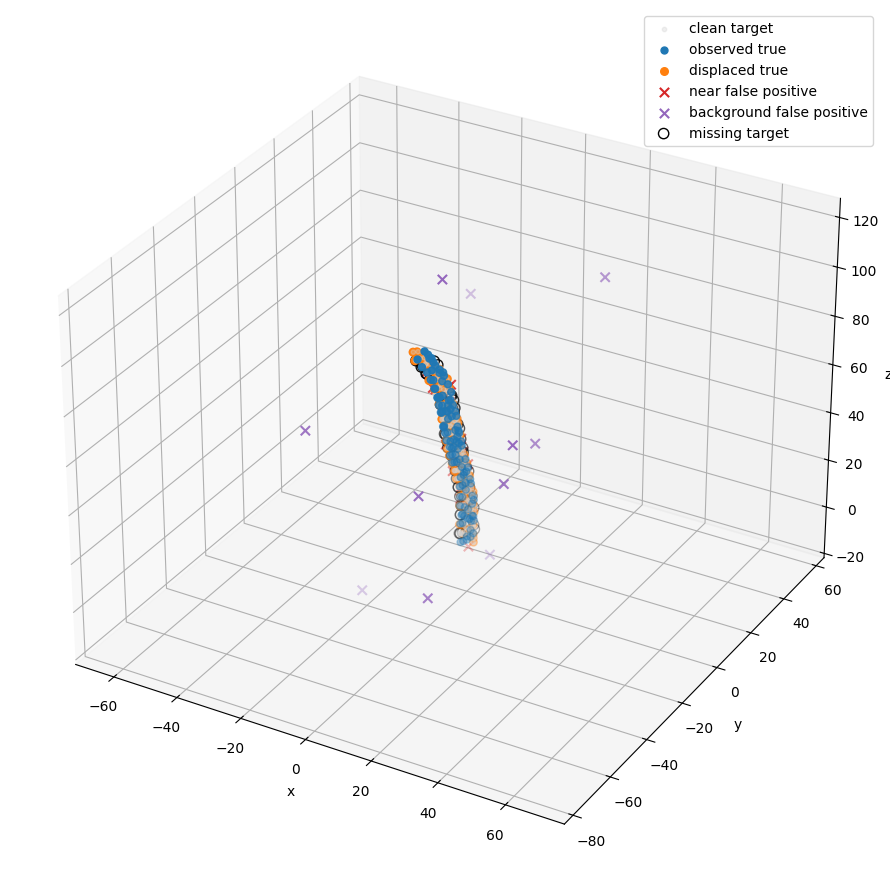

In [1379]:
plot_observed_helix(observed_helix)

In [1380]:
model_node_input = (
    observed_helix.observed_positions.astype(
        np.float32
    )
)

model_node_input.shape

(252, 3)

In [1381]:
from scipy.spatial import cKDTree

# Graph construction

### Edge type

In [1382]:
EDGE_SOURCE_SEGMENTATION = np.uint8(1)
EDGE_SOURCE_SYMMETRIC_KNN = np.uint8(2)
EDGE_SOURCE_MUTUAL_KNN = np.uint8(4)
EDGE_SOURCE_FIXED_RADIUS = np.uint8(8)
EDGE_SOURCE_ADAPTIVE_RADIUS = np.uint8(16)
EDGE_SOURCE_FALLBACK = np.uint8(32)

### Graph configuration

In [1383]:
@dataclass(frozen=True)
class ObservedGraphConfig:
    include_segmentation_adjacency: bool = True

    include_symmetric_knn: bool = True
    include_mutual_knn:bool = True
    k_neighbors: int = 6

    include_fixed_radius: bool = False
    fixed_radius: float = 3.0

    include_adaptive_radius: bool = True
    adaptive_k: int = 4
    adaptive_radius_factor: float = 1.5
    adaptive_rule: str = "mutual" # mutual: edge must have local radius of both nodes. "union": only one local radius

    ensure_no_isolated_nodes: bool = True
    fallback_k: int = 1

    maximum_edge_distance: float | None = None

    query_workers: int | None = 1

In [1384]:
@dataclass
class ObservedGraph:
    node_positions: np.ndarray # Shape (N, 3)

    undirected_edge_index: np.ndarray #(2, E)
    edge_distance: np.ndarray # (E,)
    edge_displacement: np.ndarray # (E, 3) 
    edge_source_mask: np.ndarray # (E,)

    node_degree: np.ndarray # (N,)
    node_local_scale: np.ndarray # (N,)

    config: ObservedGraphConfig

In [1385]:
def resolve_query_workers(
    query_workers: int | None,
) -> int:
    """
    Resolver the numbers of workers used by cKDTree.query

    Returns
    -------
    int
        -1 for all the cores or int
    """

    if query_workers is None:
        return 1

    if not isinstance(
        query_workers,
        (int, np.integer),
    ):
        raise ValueError(
            "query_workers must be None or an integer"
        )

    if query_workers == -1:
        return -1

    if query_workers < 1:
        raise ValueError(
            "query_workers must be -1 or a positive integer"
        )

    return int(query_workers)

### Validate graph positions

In [1386]:
def validate_graph_positions(
    positions: np.ndarray,
) -> np.ndarray:
    """
    Validate and return float64 positions contiguous
    """
    positions = np.asarray(
        positions,
        dtype=np.float64,
        order="C",
    )

    if(
        positions.ndim != 2
        or positions.shape[1] != 3
    ):
        raise ValueError(
            "positions must have shape (N, 3)"
        )

    if len(positions) < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    if not np.all(np.isfinite(positions)):
        raise ValueError(
            "positions contain non-finite values"
        )

    return positions

In [1387]:
def validate_observed_graph_config(
    config: ObservedGraphConfig,
    n_nodes: int,
) -> None:
    if n_nodes < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    boolean_fields = {
        "include_segmentation_adjacency": (
            config.include_segmentation_adjacency
        ),
        "include_symmetric_knn": (
            config.include_symmetric_knn
        ),
        "include_mutual_knn": (
            config.include_mutual_knn
        ),
        "include_fixed_radius": (
            config.include_fixed_radius
        ),
        "include_adaptive_radius": (
            config.include_adaptive_radius
        ),
        "ensure_no_isolated_nodes": (
            config.ensure_no_isolated_nodes
        ),
    }

    for name, value in boolean_fields.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    integer_fields = {
        "k_neighbors": config.k_neighbors,
        "adaptive_k": config.adaptive_k,
        "fallback_k": config.fallback_k,
    }

    for name, value in integer_fields.items():
        if not isinstance(value, (int, np.integer)):
            raise ValueError(f"{name} must be an integer")

        if value < 1:
            raise ValueError(
                f"{name} must be at least one"
            )

    if config.fixed_radius <= 0.0:
        raise ValueError(
            "fixed_radius must be positive"
        )

    if config.adaptive_radius_factor <= 0.0:
        raise ValueError(
            "adaptive_radius_factor must be positive"
        )

    if config.adaptive_rule not in {
        "mutual",
        "union",
    }:
        raise ValueError(
            "adaptive_rule must be 'mutual' or 'union'"
        )

    if config.maximum_edge_distance is not None:
        if (
            not np.isfinite(
                config.maximum_edge_distance
            )
            or config.maximum_edge_distance <= 0.0
        ):
            raise ValueError(
                "maximum_edge_distance must be positive"
            )

    resolve_query_workers(config.query_workers)

    any_primary_method = any([
        config.include_segmentation_adjacency,
        config.include_symmetric_knn,
        config.include_mutual_knn,
        config.include_fixed_radius,
        config.include_adaptive_radius,
    ])

    if not any_primary_method:
        raise ValueError(
            "at least one graph construction method "
            "must be enabled"
        )

### Canonicalize edges

In [1388]:
def canonicalize_undirected_edges(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Transform edges to the canonical form source < target,
    delete self-loop and duplicates

    Returns
    -------
    np.ndarray
        Unic edges with shape (2, E)
    """
    edge_index = np.asarray(
        edge_index,
        dtype=np.int64,
    )

    if edge_index.size == 0:
        return np.empty((2,0 ), dtype=np.int64)

    if (
        edge_index.ndim != 2
        or edge_index.shape[0] != 2
    ):
        raise ValueError(
            "edge_index must have shape (2, E)"
        )

    if np.any(edge_index < 0):
        raise ValueError(
            "edge_index contains negative indices"
        )

    if np.any(edge_index >= n_nodes):
        raise ValueError(
            "edge_index contains out-of-range indices"
        )

    source = np.minimum(
        edge_index[0],
        edge_index[1],
    )
    target = np.maximum(
        edge_index[0],
        edge_index[1],
    )

    non_self = source != target

    source = source[non_self]
    target = target[non_self]

    if len(source) == 0:
        return np.empty((2, 0), dtype=np.int64)

    encoded = source * np.int64(n_nodes) + target
    unique_encoded = np.unique(encoded)

    unique_source = unique_encoded // n_nodes
    unique_target = unique_encoded % n_nodes

    return np.stack(
        [unique_source, unique_target],
        axis = 0,
    ).astype(np.int64, copy=False)

### KNN shared query

In [1389]:
def query_knn(
    positions: np.ndarray,
    k_neighbors: int,
    query_workers: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Find k closest neighbors excluding the source node

    Returns
    -------
    distances
        Shape (N, k_effective)
    neighbor_indices
        Shape (N, k_effective)
    """
    positions = validate_graph_positions(positions)

    if k_neighbors < 1:
        raise ValueError(
            "k_neighbors must be at least one"
        )

    n_nodes = len(positions)

    k_effective = min(
        int(k_neighbors),
        n_nodes - 1,
    )

    workers = resolve_query_workers(
        query_workers
    )

    tree = cKDTree(positions)

    distances, neighbor_indices = tree.query(
        positions,
        k=k_effective + 1,
        workers=workers,
    )

    if distances.ndim == 1:
        distances = distances[:, None]
        neighbor_indices = neighbor_indices[:, None]

    # First column corresponds to source node
    distances = distances[:, 1:]
    neighbor_indices = neighbor_indices[:, 1:]

    return (
        np.asarray(distances, dtype=np.float64),
        np.asarray(neighbor_indices, dtype=np.int64),
    )

### Symmetric KNN edges

In [1390]:
def build_symmetric_knn_edges(
    neighbor_indices: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Build undirected joins of kNN
    """
    neighbor_indices = np.asarray(
        neighbor_indices,
        dtype=np.int64,
    )

    if neighbor_indices.ndim != 2:
        raise ValueError(
            "neighbor_indices must have shape (N, k)"
        )

    if neighbor_indices.shape[0] != n_nodes:
        raise ValueError(
            "neighbor_indices has an invalid first dimension"
        )
    
    source = np.repeat(
        np.arange(n_nodes, dtype=np.int64),
        neighbor_indices.shape[1],
    )
    target = neighbor_indices.reshape(-1)

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [source, target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [1391]:
def build_mutual_knn_edges(
    neighbor_indices: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Maintain i--j only if i selects j and viceversa
    """
    neighbor_indices = np.asarray(
        neighbor_indices,
        dtype=np.int64,
    )

    if (
        neighbor_indices.ndim != 2
        or neighbor_indices.shape[0] != n_nodes
    ):
        raise ValueError(
            "neighbor_indices must have shape (N, k)"
    )

    k_effective = neighbor_indices.shape[1]

    source = np.repeat(
        np.arange(n_nodes, dtype=np.int64),
        k_effective,
    )
    target = neighbor_indices.reshape(-1)

    directed_codes = (
        source * np.int64(n_nodes) + target
    )

    reverse_codes = (
        target * np.int64(n_nodes) + source
    )

    directed_codes_sorted = np.sort(
        np.unique(directed_codes)
    )

    mutual_mask = np.isin(
        reverse_codes,
        directed_codes_sorted,
        assume_unique=False,
    )

    mutual_source = source[mutual_mask]
    mutual_target = target[mutual_mask]

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [mutual_source, mutual_target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [1392]:
def build_fixed_radius_edges(
    positions: np.ndarray,
    radius: float,
) -> np.ndarray:
    """
    Connect all pairs with distance <= radius
    """
    positions = validate_graph_positions(positions)

    if radius <= 0.0:
        raise ValueError("radius must be positive")

    tree = cKDTree(positions)

    pairs = tree.query_pairs(
        r=radius,
        output_type="ndarray",
    )

    if pairs.size == 0:
        return np.empty((2, 0), dtype=np.int64)

    return canonicalize_undirected_edges(
        edge_index=pairs.T,
        n_nodes=len(positions),
    )

In [1393]:
def compute_node_local_scale(
    knn_distances: np.ndarray,
    adaptive_k: int,
) -> np.ndarray:
    """
    Calculates local spatial scale per node

    Returns
    -------
    np.ndarray
        Shape(N,)
    """
    knn_distances = np.asarray(
        knn_distances,
        dtype=np.float64,
    )

    if knn_distances.ndim != 2:
        raise ValueError(
            "knn_distances must have shape (N, k)"
        )

    if adaptive_k < 1:
        raise ValueError(
            "adaptive_k must be at least one"
        )

    if knn_distances.shape[1] < adaptive_k:
        raise ValueError(
            "knn_distances does not contain enough neighbors"
        )
    
    local_scale = knn_distances[
        :,
        adaptive_k - 1,
    ].copy()

    positive_scales = local_scale[
        local_scale > 0.0
    ]

    if len(positive_scales) == 0:
        raise ValueError(
            "all local scales are zero; positions may be duplicated"
        )

    replacement = float(
        np.median(positive_scales)
    )

    local_scale[local_scale <= 0.0] = replacement
    
    return local_scale

In [1394]:
def build_adaptive_radius_edges(
    positions: np.ndarray,
    local_scale: np.ndarray,
    radius_factor: float,
    rule: str,
    maximum_edge_distance: float | None = None,
) -> np.ndarray:
    """
    Build edges using different radius per node

    mutual:
        distance <= factor * min(scale_i, scale_j)

    union:
        distance <= factor * max(scale_i, scale_j)
    """
    positions = validate_graph_positions(positions)
    local_scale = np.asarray(
        local_scale,
        dtype=np.float64,
    )

    n_nodes = len(positions)

    if local_scale.shape != (n_nodes,):
        raise ValueError(
            "local_scale must have shape (N,)"
        )

    if np.any(local_scale <= 0.0):
        raise ValueError(
            "local_scale must be positive"
        )

    if radius_factor <= 0.0:
        raise ValueError(
            "radius_factor must be positive"
        )

    if rule not in {"mutual", "union"}:
        raise ValueError(
            "rule must be 'mutual' or 'union'"
        )

    node_radius = radius_factor * local_scale

    maximum_search_radius = float(
        np.max(node_radius)
    )

    if maximum_edge_distance is not None:
        maximum_search_radius = min(
            maximum_search_radius,
            maximum_edge_distance,
        )

    tree = cKDTree(positions)

    candidate_pairs = tree.query_pairs(
        r=maximum_search_radius,
        output_type="ndarray",
    )

    if candidate_pairs.size == 0:
        return np.empty((2, 0), dtype=np.int64)

    source = candidate_pairs[:, 0]
    target = candidate_pairs[:, 1]

    displacement = (
        positions[target] - positions[source]
    )
    distance = np.linalg.norm(
        displacement,
        axis=1,
    )

    if rule == "mutual":
        allowed_radius = np.minimum(
            node_radius[source],
            node_radius[target],
        )
    else:
        allowed_radius = np.maximum(
            node_radius[source],
            node_radius[target],
        )

    keep = distance <= allowed_radius

    if maximum_edge_distance is not None:
        keep &= distance <= maximum_edge_distance

    selected_pairs = candidate_pairs[keep]

    if len(selected_pairs) == 0:
        return np.empty((2, 0), dtype=np.int64)

    return selected_pairs.T.astype(
        np.int64,
        copy=False,
    )

### Filter edges by maximum distance

In [1395]:
def filter_edges_by_distance(
    positions: np.ndarray,
    edge_index: np.ndarray,
    maximum_distance: float | None,
 ) -> np.ndarray:
    """
    Delete edges longer than maximum_distance
    """
    if maximum_distance is None:
        return edge_index
    
    if maximum_distance <= 0.0:
        raise ValueError(
            "maximum_distance must be possitive"
        )

    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=len(positions),
    )

    if edge_index.shape[1] == 0:
        return edge_index

    source = edge_index[0]
    target = edge_index[1]

    distances = np.linalg.norm(
        positions[target] - positions[source],
        axis=1,
    )

    return edge_index[
        :,
        distances <= maximum_distance,
    ]

### Merge sourced edges

In [1396]:
def merge_tagged_undirected_edges(
    n_nodes: int,
    tagged_edge_sets: list[
        tuple[np.ndarray, np.uint8]
    ],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Merge edge sets and combine their source masks

    Returns
    -------
    edge_index
        Shape (2, E)
    edge_source_mask
        Shape (E,)
    """
    encoded_parts = []
    source_mask_parts = []

    for edge_index, source_flag in tagged_edge_sets:
        canonical = canonicalize_undirected_edges(
            edge_index=edge_index,
            n_nodes=n_nodes,
        )

        if canonical.shape[1] == 0:
            continue

        encoded = (
            canonical[0] * np.int64(n_nodes)
            + canonical[1]
        )

        encoded_parts.append(encoded)

        source_mask_parts.append(
            np.full(
                len(encoded),
                source_flag,
                dtype=np.uint8,
            )
        )
    if len(encoded_parts) == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.uint8),
        )

    encoded_all = np.concatenate(encoded_parts)
    source_mask_all = np.concatenate(
        source_mask_parts
    )

    order = np.argsort(encoded_all)

    encoded_sorted = encoded_all[order]
    source_mask_sorted = source_mask_all[order]

    unique_encoded, first_indices = np.unique(
        encoded_sorted,
        return_index=True,
    )

    merged_source_mask = np.bitwise_or.reduceat(
        source_mask_sorted,
        first_indices,
    )

    source = unique_encoded // n_nodes
    target = unique_encoded % n_nodes

    edge_index = np.stack(
        [source, target],
        axis=0,
    ).astype(np.int64, copy=False)

    return edge_index, merged_source_mask

In [1397]:
def compute_undirected_node_degree(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Calculates each node degree
    """
    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    degree = np.zeros(
        n_nodes,
        dtype=np.int64,
    )

    if edge_index.shape[1] == 0:
        return degree

    np.add.at(
        degree,
        edge_index[0],
        1,
    )
    np.add.at(
        degree,
        edge_index[1],
        1,
    )

    return degree

### Connect isolated nodes

In [1398]:
def build_isolated_node_fallback_edges(
    current_edge_index: np.ndarray,
    neighbor_indices: np.ndarray,
    n_nodes: int,
    fallback_k: int, 
) -> np.ndarray:
    """
    Connect isolated nodes with their closest neighbors
    """
    if fallback_k < 1:
        raise ValueError(
            "fallback_k must be at least one"
        )

    degree = compute_undirected_node_degree(
        edge_index=current_edge_index,
        n_nodes=n_nodes,
    )

    isolated_nodes = np.flatnonzero(
        degree == 0
    )
    if len(isolated_nodes) == 0:
        return np.empty((2, 0), dtype=np.int64)

    k_effective = min(
        fallback_k,
        neighbor_indices.shape[1],
    )

    source = np.repeat(
        isolated_nodes,
        k_effective,
    )

    target = neighbor_indices[
        isolated_nodes,
        :k_effective,
    ].reshape(-1)

    return canonicalize_undirected_edges(
        edge_index=np.stack(
            [source, target],
            axis=0,
        ),
        n_nodes=n_nodes,
    )

In [1399]:
def validate_canonical_edge_index(
    edge_index: np.ndarray,
    n_nodes: int,
    require_unique: bool = True,
) -> np.ndarray:
    """
    Validate canonical edges unchanging their order

    It never reorder or eliminate edges

    Returns
    -------
    np.ndarray
        Same edge_index as int64 contiguous
    """
    edge_index = np.asarray(
        edge_index,
        dtype=np.int64,
        order="C",
    )

    if (
        edge_index.ndim != 2
        or edge_index.shape[0] != 2
    ):
        raise ValueError(
            "edge_index must have shape (2, E)"
        )

    if edge_index.shape[1] == 0:
        return edge_index

    source = edge_index[0]
    target = edge_index[1]

    if np.any(source < 0) or np.any(target < 0):
        raise ValueError(
            "edge_index contains negative indices"
        )

    if (
        np.any(source >= n_nodes)
        or np.any(target >= n_nodes)
    ):
        raise ValueError(
            "edge_index contains out-of-range indices"
        )

    if np.any(source >= target):
        raise ValueError(
            "canonical undirected edges must satisfy source < target"
        )

    if require_unique:
        encoded = (
            source * np.int64(n_nodes)
            + target
        )

        if len(np.unique(encoded)) != len(encoded):
            raise ValueError(
                "edge_index contains duplicate edges"
            )

    return edge_index

def compute_undirected_edge_geometry(
    positions: np.ndarray,
    edge_index: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculates geometry without changing edge order

    Parameters
    ----------
    positions
        Shape (N, 3).
    edge_index
        Canonicalized edges, shape (2, E).

    Returns
    -------
    displacement
        Shape (E, 3), same order as edge_index
    distance
        Shape (E,), same order as edge_index
    """
    positions = validate_graph_positions(
        positions
    )

    edge_index = validate_canonical_edge_index(
        edge_index=edge_index,
        n_nodes=len(positions),
        require_unique=True,
    )

    source = edge_index[0]
    target = edge_index[1]

    displacement = (
        positions[target]
        - positions[source]
    )

    distance = np.linalg.norm(
        displacement,
        axis=1,
    )

    return displacement, distance

In [1400]:
def prepare_segmentation_edges(
        segmentation_edge_index: np.ndarray | None,
        n_nodes:int,
) -> np.ndarray:
    """
    Validate and canonicalize supervoxels adjacency
    """
    if segmentation_edge_index is None:
        return np.empty((2, 0), dtype=np.int64)

    return canonicalize_undirected_edges(
        edge_index=segmentation_edge_index,
        n_nodes=n_nodes,
    )

### Build observed graph

In [1401]:
def merge_existing_graph_with_tagged_edges(
    n_nodes: int,
    existing_edge_index: np.ndarray,
    existing_source_mask: np.ndarray,
    new_edge_index: np.ndarray,
    new_source_flag: np.uint8,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Add new edges with edges mask
    """
    existing_edge_index = canonicalize_undirected_edges(
        edge_index=existing_edge_index,
        n_nodes=n_nodes,
    )

    existing_source_mask = np.asarray(
        existing_source_mask,
        dtype=np.uint8,
    )

    if existing_source_mask.shape != (
        existing_edge_index.shape[1],
    ):
        raise ValueError(
            "existing_source_mask has an invalid shape"
        )

    new_edge_index = canonicalize_undirected_edges(
        edge_index=new_edge_index,
        n_nodes=n_nodes,
    )

    existing_codes = (
        existing_edge_index[0] * np.int64(n_nodes)
        + existing_edge_index[1]
    )

    new_codes = (
        new_edge_index[0] * np.int64(n_nodes)
        + new_edge_index[1]
    )

    all_codes = np.concatenate([
        existing_codes,
        new_codes,
    ])

    all_masks = np.concatenate([
        existing_source_mask,
        np.full(
            len(new_codes),
            new_source_flag,
            dtype=np.uint8,
        ),
    ])

    if len(all_codes) == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.uint8),
        )

    order = np.argsort(all_codes)
    sorted_codes = all_codes[order]
    sorted_masks = all_masks[order]

    unique_codes, first_indices = np.unique(
        sorted_codes,
        return_index=True,
    )

    merged_masks = np.bitwise_or.reduceat(
        sorted_masks,
        first_indices,
    )

    source = unique_codes // n_nodes
    target = unique_codes % n_nodes

    return (
        np.stack(
            [source, target],
            axis=0,
        ).astype(np.int64, copy=False),
        merged_masks,
    )

In [1402]:
def build_observed_graph(
    observed: ObservedHelixGeometry,
    config: ObservedGraphConfig,
    segmentation_edge_index: np.ndarray | None = None,
) -> ObservedGraph:
    """
    Build undirected observed graph

    Only uses observed positions and, optionally, adjacency from the segmentation
    """
    positions = validate_graph_positions(
        observed.observed_positions
    )

    n_nodes = len(positions)

    validate_observed_graph_config(
        config=config,
        n_nodes=n_nodes,
    )

    maximum_required_k = max(
        config.k_neighbors
        if (
            config.include_symmetric_knn
            or config.include_mutual_knn
        )
        else 1,
        config.adaptive_k
        if config.include_adaptive_radius
        else 1,
        config.fallback_k
        if config.ensure_no_isolated_nodes
        else 1,
    )

    (
        knn_distances,
        neighbor_indices,
    ) = query_knn(
        positions=positions,
        k_neighbors=maximum_required_k,
        query_workers=resolve_query_workers(
            config.query_workers
        ),
    )

    adaptive_k_effective = min(
        config.adaptive_k,
        knn_distances.shape[1],
    )

    node_local_scale = compute_node_local_scale(
        knn_distances=knn_distances,
        adaptive_k=adaptive_k_effective,
    )

    tagged_edge_sets = []

    if config.include_segmentation_adjacency:
        segmentation_edges = prepare_segmentation_edges(
            segmentation_edge_index=(
                segmentation_edge_index
            ),
            n_nodes=n_nodes,
        )

        segmentation_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=segmentation_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            segmentation_edges,
            EDGE_SOURCE_SEGMENTATION,
        ))

    if config.include_symmetric_knn:
        symmetric_edges = build_symmetric_knn_edges(
            neighbor_indices=neighbor_indices[
                :, :min(
                    config.k_neighbors,
                    neighbor_indices.shape[1],
                )
            ],
            n_nodes=n_nodes,
        )

        symmetric_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=symmetric_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            symmetric_edges,
            EDGE_SOURCE_SYMMETRIC_KNN,
        ))

    if config.include_mutual_knn:
        mutual_edges = build_mutual_knn_edges(
            neighbor_indices=neighbor_indices[
                :, :min(
                    config.k_neighbors,
                    neighbor_indices.shape[1],
                )
            ],
            n_nodes=n_nodes,
        )

        mutual_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=mutual_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            mutual_edges,
            EDGE_SOURCE_MUTUAL_KNN,
        ))

    if config.include_fixed_radius:
        fixed_radius_edges = (
            build_fixed_radius_edges(
                positions=positions,
                radius=config.fixed_radius,
            )
        )

        fixed_radius_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=fixed_radius_edges,
            maximum_distance=(
                config.maximum_edge_distance
            ),
        )

        tagged_edge_sets.append((
            fixed_radius_edges,
            EDGE_SOURCE_FIXED_RADIUS,
        ))

    if config.include_adaptive_radius:
        adaptive_radius_edges = (
            build_adaptive_radius_edges(
                positions=positions,
                local_scale=node_local_scale,
                radius_factor=(
                    config.adaptive_radius_factor
                ),
                rule=config.adaptive_rule,
                maximum_edge_distance=(
                    config.maximum_edge_distance
                ),
            )
        )

        tagged_edge_sets.append((
            adaptive_radius_edges,
            EDGE_SOURCE_ADAPTIVE_RADIUS,
        ))

    (
        edge_index,
        edge_source_mask,
    ) = merge_tagged_undirected_edges(
        n_nodes=n_nodes,
        tagged_edge_sets=tagged_edge_sets,
    )

    if config.ensure_no_isolated_nodes:
        fallback_edges = (
            build_isolated_node_fallback_edges(
                current_edge_index=edge_index,
                neighbor_indices=neighbor_indices,
                n_nodes=n_nodes,
                fallback_k=config.fallback_k,
            )
        )

        (
            edge_index,
            edge_source_mask,
        ) = merge_existing_graph_with_tagged_edges(
            n_nodes=n_nodes,
            existing_edge_index=edge_index,
            existing_source_mask=edge_source_mask,
            new_edge_index=fallback_edges,
            new_source_flag=EDGE_SOURCE_FALLBACK,
        )

    edge_displacement, edge_distance = (
        compute_undirected_edge_geometry(
            positions=positions,
            edge_index=edge_index,
        )
    )

    node_degree = compute_undirected_node_degree(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    return ObservedGraph(
        node_positions=positions,
        undirected_edge_index=edge_index,
        edge_distance=edge_distance,
        edge_displacement=edge_displacement,
        edge_source_mask=edge_source_mask,
        node_degree=node_degree,
        node_local_scale=node_local_scale,
        config=config,
    )

### Message passing conversion

In [1403]:
@dataclass
class DirectedMessagePassingGraph:
    node_positions: np.ndarray
    edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray
    edge_source_mask: np.ndarray

def prepare_directed_message_passing_graph(
        graph: ObservedGraph,
) -> DirectedMessagePassingGraph:
    """
    Duplicate each undirected edge in both directions
    """
    edge_index = graph.undirected_edge_index

    reverse_edge_index = edge_index[[1, 0]]

    directed_edge_index = np.concatenate(
        [edge_index, reverse_edge_index],
        axis=1,
    )

    directed_distance = np.concatenate(
        [graph.edge_distance, graph.edge_distance],
        axis=0,
    )

    directed_displacement = np.concatenate(
        [
            graph.edge_displacement,
            -graph.edge_displacement,
        ],
        axis=0,
    )

    directed_source_mask = np.concatenate(
        [
            graph.edge_source_mask,
            graph.edge_source_mask,
        ],
        axis=0,
    )

    return DirectedMessagePassingGraph(
        node_positions=graph.node_positions,
        edge_index=directed_edge_index,
        edge_distance=directed_distance,
        edge_displacement=directed_displacement,
        edge_source_mask=directed_source_mask,
    )

In [1404]:
def validate_observed_graph(
    graph: ObservedGraph,
) -> dict[str, Any]:
    """
    Valida canonicalización, distancias, grados y duplicados.
    """
    n_nodes = len(graph.node_positions)
    n_edges = graph.undirected_edge_index.shape[1]

    if graph.node_positions.shape != (n_nodes, 3):
        raise ValueError(
            "node_positions has an invalid shape"
        )

    if graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "undirected_edge_index has an invalid shape"
        )

    if graph.edge_distance.shape != (n_edges,):
        raise ValueError(
            "edge_distance has an invalid shape"
        )

    if graph.edge_displacement.shape != (
        n_edges,
        3,
    ):
        raise ValueError(
            "edge_displacement has an invalid shape"
        )

    if graph.edge_source_mask.shape != (n_edges,):
        raise ValueError(
            "edge_source_mask has an invalid shape"
        )

    if graph.node_degree.shape != (n_nodes,):
        raise ValueError(
            "node_degree has an invalid shape"
        )

    if graph.node_local_scale.shape != (n_nodes,):
        raise ValueError(
            "node_local_scale has an invalid shape"
        )

    source = graph.undirected_edge_index[0]
    target = graph.undirected_edge_index[1]

    recomputed_displacement = (
        graph.node_positions[target]
        - graph.node_positions[source]
    )

    recomputed_distance = np.linalg.norm(
        recomputed_displacement,
        axis=1,
    )

    unique_edges = np.unique(
        graph.undirected_edge_index.T,
        axis=0,
    )

    recomputed_degree = compute_undirected_node_degree(
        edge_index=graph.undirected_edge_index,
        n_nodes=n_nodes,
    )

    checks = {
        "positions_are_finite": bool(
            np.all(np.isfinite(graph.node_positions))
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edge_indices_are_valid": bool(
            n_edges == 0
            or (
                np.min(source) >= 0
                and np.max(target) < n_nodes
            )
        ),
        "edges_are_unique": bool(
            len(unique_edges) == n_edges
        ),
        "displacements_are_correct": bool(
            np.allclose(
                graph.edge_displacement,
                recomputed_displacement,
            )
        ),
        "distances_are_correct": bool(
            np.allclose(
                graph.edge_distance,
                recomputed_distance,
            )
        ),
        "distances_are_positive": bool(
            np.all(graph.edge_distance > 0.0)
        ),
        "degrees_are_correct": bool(
            np.array_equal(
                graph.node_degree,
                recomputed_degree,
            )
        ),
        "source_masks_are_nonzero": bool(
            np.all(graph.edge_source_mask > 0)
        ),
        "local_scales_are_positive": bool(
            np.all(graph.node_local_scale > 0.0)
        ),
    }

    if graph.config.ensure_no_isolated_nodes:
        checks["no_isolated_nodes"] = bool(
            np.all(graph.node_degree > 0)
        )

    metrics = {
        "n_nodes": n_nodes,
        "n_undirected_edges": n_edges,
        "mean_degree": float(
            np.mean(graph.node_degree)
        ),
        "minimum_degree": int(
            np.min(graph.node_degree)
        ),
        "maximum_degree": int(
            np.max(graph.node_degree)
        ),
        "mean_edge_distance": float(
            np.mean(graph.edge_distance)
        ),
        "maximum_edge_distance": float(
            np.max(graph.edge_distance)
        ),
        "n_segmentation_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_SEGMENTATION
                ) != 0
            )
        ),
        "n_mutual_knn_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_MUTUAL_KNN
                ) != 0
            )
        ),
        "n_adaptive_radius_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_ADAPTIVE_RADIUS
                ) != 0
            )
        ),
        "n_fallback_edges": int(
            np.sum(
                (
                    graph.edge_source_mask
                    & EDGE_SOURCE_FALLBACK
                ) != 0
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Visualization

In [1405]:
def plot_observed_graph(
    graph: ObservedGraph,
    observed: ObservedHelixGeometry | None = None,
):
    """
    Representa nodos y aristas del grafo observado.
    """
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")

    positions = graph.node_positions
    edges = graph.undirected_edge_index

    source_colors = [
        (
            EDGE_SOURCE_SEGMENTATION,
            "black",
            "segmentation",
        ),
        (
            EDGE_SOURCE_MUTUAL_KNN,
            "tab:blue",
            "mutual kNN",
        ),
        (
            EDGE_SOURCE_SYMMETRIC_KNN,
            "tab:cyan",
            "symmetric kNN",
        ),
        (
            EDGE_SOURCE_FIXED_RADIUS,
            "tab:green",
            "fixed radius",
        ),
        (
            EDGE_SOURCE_ADAPTIVE_RADIUS,
            "tab:orange",
            "adaptive radius",
        ),
        (
            EDGE_SOURCE_FALLBACK,
            "tab:red",
            "fallback",
        ),
    ]

    used_labels = set()

    for edge_position in range(edges.shape[1]):
        source = edges[0, edge_position]
        target = edges[1, edge_position]
        source_mask = graph.edge_source_mask[
            edge_position
        ]

        color = "gray"
        label = "other"

        for flag, candidate_color, candidate_label in (
            source_colors
        ):
            if source_mask & flag:
                color = candidate_color
                label = candidate_label
                break

        plot_label = (
            label if label not in used_labels else None
        )
        used_labels.add(label)

        ax.plot(
            [
                positions[source, 0],
                positions[target, 0],
            ],
            [
                positions[source, 1],
                positions[target, 1],
            ],
            [
                positions[source, 2],
                positions[target, 2],
            ],
            color=color,
            linewidth=0.7,
            alpha=0.45,
            label=plot_label,
        )

    if observed is None:
        ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            color="tab:blue",
            s=25,
            label="nodes",
        )
    else:
        true_mask = observed.observed_is_true
        false_mask = ~true_mask

        ax.scatter(
            positions[true_mask, 0],
            positions[true_mask, 1],
            positions[true_mask, 2],
            color="tab:blue",
            s=25,
            label="true observed",
        )

        if np.any(false_mask):
            ax.scatter(
                positions[false_mask, 0],
                positions[false_mask, 1],
                positions[false_mask, 2],
                color="tab:red",
                marker="x",
                s=40,
                label="false positive",
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    set_axes_equal_3d(ax)
    plt.tight_layout()

    return fig, ax

In [1406]:
observed_graph_config = ObservedGraphConfig(
    include_segmentation_adjacency=False,

    include_symmetric_knn=False,
    include_mutual_knn=True,
    k_neighbors=6,

    include_fixed_radius=False,
    fixed_radius=3.0,

    include_adaptive_radius=True,
    adaptive_k=4,
    adaptive_radius_factor=1.5,
    adaptive_rule="mutual",

    ensure_no_isolated_nodes=True,
    fallback_k=1,

    maximum_edge_distance=None,

    query_workers=1,
)

In [1407]:
observed_graph = build_observed_graph(
    observed=observed_helix,
    config=observed_graph_config,
    segmentation_edge_index=None,
)

graph_validation = validate_observed_graph(
    observed_graph
)

graph_validation

{'is_valid': True,
 'checks': {'positions_are_finite': True,
  'edges_are_canonical': True,
  'edge_indices_are_valid': True,
  'edges_are_unique': True,
  'displacements_are_correct': True,
  'distances_are_correct': True,
  'distances_are_positive': True,
  'degrees_are_correct': True,
  'source_masks_are_nonzero': True,
  'local_scales_are_positive': True,
  'no_isolated_nodes': True},
 'metrics': {'n_nodes': 252,
  'n_undirected_edges': 1498,
  'mean_degree': 11.88888888888889,
  'minimum_degree': 1,
  'maximum_degree': 18,
  'mean_edge_distance': 3.23277904232274,
  'maximum_edge_distance': 45.602521870900176,
  'n_segmentation_edges': 0,
  'n_mutual_knn_edges': 607,
  'n_adaptive_radius_edges': 1496,
  'n_fallback_edges': 2}}

(<Figure size 1100x900 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

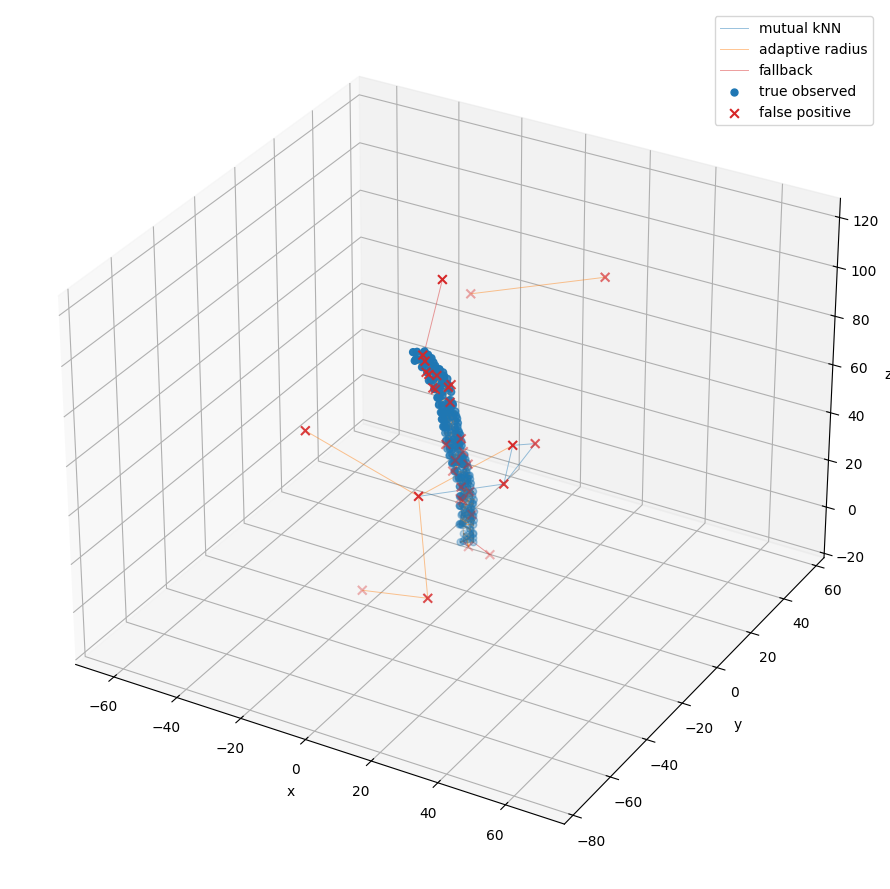

In [1408]:
plot_observed_graph(
    graph=observed_graph,
    observed=observed_helix,
)

In [1409]:
message_passing_graph = (
    prepare_directed_message_passing_graph(
        observed_graph
    )
)

# Target building

In [1410]:
@dataclass
class ObservedNodeTargets:
    is_true_node: np.ndarray
    is_false_positive: np.ndarray

    has_position_target: np.ndarray
    clean_position: np.ndarray
    position_correction: np.ndarray

    clean_node_index: np.ndarray
    strand_id: np.ndarray
    sequence_index: np.ndarray

In [1411]:
@dataclass
class ObservedEdgeTargets:
    both_nodes_are_true: np.ndarray
    same_strand: np.ndarray

    is_true_filament_edge: np.ndarray # Connect two real consecutive subunits
    is_gap_boundary_edge: np.ndarray # Connect two observed extrenes from a gap
    is_negative_edge: np.ndarray # Spatial edge that is not represented with the previous two

    has_local_structure_target: np.ndarray

    sequence_separation: np.ndarray
    missing_nodes_between: np.ndarray

    accumulated_rise: np.ndarray
    accumulated_twist_rad: np.ndarray

    mean_local_rise: np.ndarray
    mean_local_twist_rad: np.ndarray
    mean_backbone_curvature: np.ndarray

### Completion targets

In [1412]:
@dataclass
class CompletionTargets:
    missing_clean_node_index: np.ndarray
    missing_position: np.ndarray

    strand_id: np.ndarray
    sequence_index: np.ndarray
    gap_id: np.ndarray

    left_clean_node_index: np.ndarray
    right_clean_node_index: np.ndarray

    left_observed_node_index: np.ndarray
    right_observed_node_index: np.ndarray

### Clean target graph

In [1413]:
@dataclass
class CleanTargetGraph:
    node_positions: np.ndarray
    node_strand_id: np.ndarray
    node_sequence_index: np.ndarray
    node_backbone_curvature: np.ndarray

    undirected_edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray

    edge_local_rise: np.ndarray
    edge_local_twist_rad: np.ndarray
    edge_mean_backbone_curvature: np.ndarray

### Global targets

In [1414]:
@dataclass
class GlobalHelixTargets:
    n_strands: int

    global_rise: float
    global_twist_rad: float
    global_radius: float

    nominal_rise: float
    nominal_twist_rad: float
    nominal_radius: float

    mean_backbone_curvature: float
    max_backbone_curvature: float

### Complete container

In [1415]:
@dataclass
class HelixTrainingTargets:
    observed_node_targets: ObservedNodeTargets
    observed_edge_targets: ObservedEdgeTargets

    completion_targets: CompletionTargets
    clean_target_graph: CleanTargetGraph
    global_targets: GlobalHelixTargets

### Observed Target Nodes

In [1416]:
def build_observed_node_targets(
        observed: ObservedHelixGeometry,
) -> ObservedNodeTargets:
    """
    Build targets per node of the observed graph
    """
    observed_positions = observed.observed_positions
    observed_to_clean = (
        observed.observed_to_clean_index
    )

    n_observed = len(observed_positions)

    if observed_to_clean.shape != (n_observed,):
        raise ValueError(
            "observed_to_clean_index has an invalid shape"
        )

    is_true_node = observed_to_clean >= 0
    is_false_positive = ~is_true_node
    has_position_target = is_true_node.copy()

    clean_position = np.zeros(
        (n_observed, 3),
        dtype=np.float64,
    )

    position_correction = np.zeros(
        (n_observed, 3),
        dtype=np.float64,
    )

    strand_id = np.full(
        n_observed,
        -1,
        dtype=np.int64,
    )

    sequence_index = np.full(
        n_observed,
        -1,
        dtype=np.int64,
    )

    true_observed_indices = np.flatnonzero(
        is_true_node
    )

    clean_indices = observed_to_clean[
        true_observed_indices
    ]

    clean_position[true_observed_indices] = (
        observed.clean_helix.positions[
            clean_indices
        ]
    )

    position_correction[true_observed_indices] = (
        clean_position[true_observed_indices]
        - observed_positions[true_observed_indices]
    )

    strand_id[true_observed_indices] = (
        observed.clean_helix.strand_id[
            clean_indices
        ]
    )

    sequence_index[true_observed_indices] = (
        observed.clean_helix.sequence_index[
            clean_indices
        ]
    )

    return ObservedNodeTargets(
        is_true_node=is_true_node,
        is_false_positive=is_false_positive,
        has_position_target=has_position_target,
        clean_position=clean_position,
        position_correction=position_correction,
        clean_node_index=observed_to_clean.copy(),
        strand_id=strand_id,
        sequence_index=sequence_index,
    )


### Encode undirected edges

In [1417]:
def encode_undirected_edge_pairs(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Encode each edge u < v as u * n_nodes + v
    """
    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_nodes,
    )

    return (
        edge_index[0] * np.int64(n_nodes)
        + edge_index[1]
    )

### Lookup encoded edge values

In [1418]:
def lookup_encoded_edge_values(
    query_codes: np.ndarray,
    reference_codes: np.ndarray,
    reference_values: np.ndarray,
    default_value: int | float = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Lookup values asociated to the codes of the edges

    Returns
    -------
    found
        Boolean mask with shape equal to query_codes
    values
        Found values or default_value
    """
    query_codes = np.asarray(
        query_codes,
        dtype=np.int64,
    )
    reference_codes = np.asarray(
        reference_codes,
        dtype=np.int64,
    )
    reference_values = np.asarray(reference_values)

    if query_codes.ndim != 1:
        raise ValueError(
            "query_codes must be one-dimensional"
        )

    if reference_codes.ndim != 1:
        raise ValueError(
            "reference_codes must be one-dimensional"
        )

    if reference_values.shape != reference_codes.shape:
        raise ValueError(
            "reference_values and reference_codes must"
            "have the same shape"
        )

    output = np.full(
        query_codes.shape,
        default_value,
        dtype=reference_values.dtype,
    )

    found = np.zeros(
        query_codes.shape,
        dtype=bool,
    )

    if len(reference_codes) == 0:
        return found, output

    order = np.argsort(reference_codes)
    sorted_codes = reference_codes[order]
    sorted_values = reference_values[order]

    positions = np.searchsorted(
        sorted_codes,
        query_codes,
    )

    in_bounds = positions < len(sorted_codes)

    safe_positions = np.minimum(
        positions,
        len(sorted_codes) - 1,
    )

    found = (
        in_bounds
        & (
            sorted_codes[safe_positions]
            == query_codes
        )
    )

    output[found] = sorted_values[
        safe_positions[found]
    ]

    return found, output

### True edge codes

In [1419]:
def build_clean_true_edge_codes(
    clean_helix: CleanHelixGeometry,
) -> np.ndarray:
    """
    Encode consecutive connections of the clean graph
    """
    return encode_undirected_edge_pairs(
        edge_index=clean_helix.undirected_edge_index,
        n_nodes=len(clean_helix.positions),
    )

In [1420]:
def build_gap_boundary_codes(
    gap_table: GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Encode each pair of clena nodes that delimite a gap

    Returns
    -------
    boundary_codes
        Shape (G,)
    gap_sizes
        Shape (G,)
    """
    left = gap_table.left_clean_node_index
    right = gap_table.right_clean_node_index

    if left.shape != right.shape:
        raise ValueError(
            "gap boundary arrays have inconsistent shapes"
        )

    if len(left) == 0:
        return(
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    boundary_edges = np.stack(
        [
            np.minimum(left, right),
            np.maximum(left, right),
        ],
        axis=0,
    )

    boundary_codes = encode_undirected_edge_pairs(
        edge_index=boundary_edges,
        n_nodes=n_clean_nodes,
    )

    return (
        boundary_codes,
        gap_table.gap_size.astype(
            np.int64,
            copy=True,
        ),
    )

### Mean interval curvature

In [1421]:
def compute_interval_mean_values(
    values: np.ndarray,
    start_index: np.ndarray,
    end_index: np.ndarray,
    valid_mask: np.ndarray,
) -> np.ndarray:
    """
    Calculate inclusive mean between index pairs
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )
    start_index = np.asarray(
        start_index,
        dtype=np.int64,
    )
    end_index = np.asarray(
        end_index,
        dtype=np.int64,
    )
    valid_mask = np.asarray(
        valid_mask,
        dtype=bool,
    )

    if start_index.shape != end_index.shape:
        raise ValueError(
            "start_index and end_index must have the same shape"
        )

    if valid_mask.shape != start_index.shape:
        raise ValueError(
            "valid_mask has an invalid shape"
        )

    output = np.zeros(
        start_index.shape,
        dtype=np.float64,
    )

    if not np.any(valid_mask):
        return output

    cumulative = np.concatenate([
        np.array([0.0], dtype=np.float64),
        np.cumsum(values, dtype=np.float64),
    ])

    valid_start = start_index[valid_mask]
    valid_end = end_index[valid_mask]

    if np.any(valid_start < 0):
        raise ValueError(
            "start_index contains negative valid indices"
        )

    if np.any(valid_end >= len(values)):
        raise ValueError(
            "end_index contains out-of-range valid indices"
        )

    interval_sum = (
        cumulative[valid_end + 1]
        - cumulative[valid_start]
    )

    interval_length = (
        valid_end - valid_start + 1
    )

    output[valid_mask] = (
        interval_sum / interval_length
    )

    return output

In [1422]:
def build_observed_edge_targets(
    observed: ObservedHelixGeometry,
    graph: ObservedGraph,
) -> ObservedEdgeTargets:
    """
    Classify observed edges and build local targets
    """
    n_clean = len(
        observed.clean_helix.positions
    )
    n_observed = len(
        observed.observed_positions
    )

    if len(graph.node_positions) != n_observed:
        raise ValueError(
            "graph and observed geometry contain differen numbers of nodes"
        )

    edge_index = graph.undirected_edge_index
    n_edges = edge_index.shape[1]

    source_observed = edge_index[0]
    target_observed = edge_index[1]

    source_clean = (
        observed.observed_to_clean_index[
            source_observed
        ]
    )
    target_clean = (
        observed.observed_to_clean_index[
            target_observed
        ]
    )

    both_nodes_are_true = (
        (source_clean >= 0)
        & (target_clean >= 0)
    )

    same_strand = np.zeros(
        n_edges,
        dtype=bool,
    )

    source_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )
    target_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    source_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    source_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    true_edge_codes = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    if np.any(both_nodes_are_true):
        valid_indices = np.flatnonzero(
            both_nodes_are_true
        )

        valid_source_clean = source_clean[
            valid_indices
        ]
        valid_target_clean = target_clean[
            valid_indices
        ]

        source_strand = (
            observed.clean_helix.strand_id[
                valid_source_clean
            ]
        )
        target_strand = (
            observed.clean_helix.strand_id[
                valid_target_clean
            ]
        )

        same_strand[valid_indices] = (
            source_strand == target_strand
        )

        source_sequence[valid_indices] = (
            observed.clean_helix.sequence_index[
                valid_source_clean
            ]
        )
        target_sequence[valid_indices] = (
            observed.clean_helix.sequence_index[
                valid_target_clean
            ]
        )

        source_arc_length[valid_indices] = (
            observed.clean_helix.arc_length[
                valid_source_clean
            ]
        )
        target_arc_length[valid_indices] = (
            observed.clean_helix.arc_length[
                valid_target_clean
            ]
        )

        source_phase[valid_indices] = (
            observed.clean_helix.phase_rad[
                valid_source_clean
            ]
        )
        target_phase[valid_indices] = (
            observed.clean_helix.phase_rad[
                valid_target_clean
            ]
        )

        clean_min = np.minimum(
            valid_source_clean,
            valid_target_clean,
        )
        clean_max = np.maximum(
            valid_source_clean,
            valid_target_clean,
        )

        true_edge_codes[valid_indices] = (
            clean_min * np.int64(n_clean)
            + clean_max
        )
    
    reference_true_codes = (
        build_clean_true_edge_codes(
            observed.clean_helix
        )
    )

    is_true_filament_edge = (
        both_nodes_are_true
        & np.isin(
            true_edge_codes,
            reference_true_codes,
        )
    )

    (
        gap_boundary_codes,
        gap_sizes,
    ) = build_gap_boundary_codes(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    (
        is_gap_boundary_edge,
        gap_size_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=true_edge_codes,
        reference_codes=gap_boundary_codes,
        reference_values=gap_sizes,
        default_value=0,
    )

    is_gap_boundary_edge &= both_nodes_are_true

    is_negative_edge = ~(
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    has_local_structure_target = (
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    sequence_separation = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    valid_same_strand = (
        both_nodes_are_true
        & same_strand
    )

    sequence_separation[valid_same_strand] = (
        np.abs(
            target_sequence[valid_same_strand]
            - source_sequence[valid_same_strand]
        )
    )

    missing_nodes_between = np.zeros(
        n_edges,
        dtype=np.int64,
    )
    missing_nodes_between[
        is_gap_boundary_edge
    ] = gap_size_lookup[
        is_gap_boundary_edge
    ]

    accumulated_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    accumulated_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    if np.any(valid_same_strand):
        accumulated_rise[valid_same_strand] = (
            np.abs(
                target_arc_length[valid_same_strand]
                - source_arc_length[valid_same_strand]
            )
        )

        lower_sequence_first = (
            source_sequence <= target_sequence
        )

        forward_twist = (
            target_phase - source_phase
        )
        reverse_twist = (
            source_phase - target_phase
        )

        accumulated_twist_rad[
            valid_same_strand
        ] = np.where(
            lower_sequence_first[
                valid_same_strand
            ],
            forward_twist[valid_same_strand],
            reverse_twist[valid_same_strand],
        )

    mean_local_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    mean_local_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    nonzero_separation = (
        has_local_structure_target
        & (sequence_separation > 0)
    )

    mean_local_rise[nonzero_separation] = (
        accumulated_rise[nonzero_separation]
        / sequence_separation[nonzero_separation]
    )

    mean_local_twist_rad[nonzero_separation] = (
        accumulated_twist_rad[
            nonzero_separation
        ]
        / sequence_separation[
            nonzero_separation
        ]
    )

    lower_clean_index = np.minimum(
        source_clean,
        target_clean,
    )
    upper_clean_index = np.maximum(
        source_clean,
        target_clean,
    )

    safe_lower_clean = np.where(
        valid_same_strand,
        lower_clean_index,
        0,
    )
    safe_upper_clean = np.where(
        valid_same_strand,
        upper_clean_index,
        0,
    )

    mean_backbone_curvature = (
        compute_interval_mean_values(
            values=(
                observed.clean_helix.backbone_curvature
            ),
            start_index=safe_lower_clean,
            end_index=safe_upper_clean,
            valid_mask=has_local_structure_target,
        )
    )

    return ObservedEdgeTargets(
        both_nodes_are_true=both_nodes_are_true,
        same_strand=same_strand,
        is_true_filament_edge=(
            is_true_filament_edge
        ),
        is_gap_boundary_edge=is_gap_boundary_edge,
        is_negative_edge=is_negative_edge,
        has_local_structure_target=has_local_structure_target,
        sequence_separation=sequence_separation,
        missing_nodes_between=missing_nodes_between,
        accumulated_rise=accumulated_rise,
        accumulated_twist_rad=accumulated_twist_rad,
        mean_local_rise=mean_local_rise,
        mean_local_twist_rad=mean_local_twist_rad,
        mean_backbone_curvature=mean_backbone_curvature,
    )


### Assing missing nodes to gaps

In [1423]:
def build_missing_node_gap_mapping(
    gap_table:GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Assign clean missing node its gap and the limits

    Returns
    -------
    clean_gap_id
    clean_left_boundary
    clean_right_boundary

    The three arrays are (N_clean,) and value -1 for the nodes that are not part of the gap
    """
    clean_gap_id = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )
    clean_left_boundary = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )
    clean_right_boundary = np.full(
        n_clean_nodes,
        -1,
        dtype=np.int64,
    )

    for gap_position, missing_indices in enumerate(
        gap_table.missing_clean_node_indices
    ):
        gap_id = int(
            gap_table.gap_id[gap_position]
        )
        left_index = int(gap_table.left_clean_node_index[
            gap_position
        ])
        right_index = int(
            gap_table.right_clean_node_index[
                gap_position
            ]
        )

        clean_gap_id[missing_indices] = gap_id
        clean_left_boundary[missing_indices] = left_index
        clean_right_boundary[missing_indices] = right_index

    return (
        clean_gap_id,
        clean_left_boundary,
        clean_right_boundary,
    )


### Completion targets

In [1424]:
def build_completion_targets(
    observed: ObservedHelixGeometry,
) -> CompletionTargets:
    """
    Build a register per missing node
    """
    clean_helix = observed.clean_helix
    n_clean = len(clean_helix.positions)

    missing_clean_node_index = np.flatnonzero(
        observed.clean_is_missing
    ).astype(np.int64)

    (
        clean_gap_id,
        clean_left_boundary,
        clean_right_boundary,
    ) = build_missing_node_gap_mapping(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    left_clean_node_index = (
        clean_left_boundary[
            missing_clean_node_index
        ]
    )
    right_clean_node_index = (
        clean_right_boundary[
            missing_clean_node_index
        ]
    )

    if len(missing_clean_node_index) > 0:
        if np.any(left_clean_node_index < 0):
            raise ValueError(
                "some missing nodes have no left gap boundary"
            )

        if np.any(right_clean_node_index < 0):
            raise ValueError(
                "some missing nodes have no right gap boundary"
            )

    left_observed_node_index = (
        observed.clean_to_observed_index[
            left_clean_node_index
        ]
        if len(missing_clean_node_index) > 0
        else np.empty(0, dtype=np.int64)
    )

    right_observed_node_index = (
        observed.clean_to_observed_index[
            right_clean_node_index
        ]
        if len(missing_clean_node_index) > 0
        else np.empty(0, dtype=np.int64)
    )

    return CompletionTargets(
        missing_clean_node_index=(
            missing_clean_node_index
        ),
        missing_position=clean_helix.positions[
            missing_clean_node_index
        ].copy(),
        strand_id=clean_helix.strand_id[
            missing_clean_node_index
        ].copy(),
        sequence_index=clean_helix.sequence_index[
            missing_clean_node_index
        ].copy(),
        gap_id=clean_gap_id[
            missing_clean_node_index
        ].copy(),
        left_clean_node_index=(
            left_clean_node_index.copy()
        ),
        right_clean_node_index=(
            right_clean_node_index.copy()
        ),
        left_observed_node_index=(
            left_observed_node_index.copy()
        ),
        right_observed_node_index=(
            right_observed_node_index.copy()
        ),
    )

### Complete target graph

In [1425]:
def build_clean_target_graph(
    clean_helix: CleanHelixGeometry,
) -> CleanTargetGraph:
    """
    Build clean complete graph with undirected graph
    """
    node_positions = np.asarray(
        clean_helix.positions,
        dtype=np.float64,
    )

    edge_index = canonicalize_undirected_edges(
        edge_index=clean_helix.undirected_edge_index,
        n_nodes=len(node_positions),
    )

    edge_displacement, edge_distance = (
        compute_undirected_edge_geometry(
            positions=node_positions,
            edge_index=edge_index,
        )
    )

    source = edge_index[0]
    target = edge_index[1]

    edge_mean_backbone_curvature = 0.5 * (
        clean_helix.backbone_curvature[source]
        + clean_helix.backbone_curvature[target]
    )

    if clean_helix.local_rise.shape != (
        edge_index.shape[1],
    ):
        raise ValueError(
            "clean local_rise does not match target edges"
        )

    if clean_helix.local_twist_rad.shape != (
        edge_index.shape[1],
    ): 
        raise ValueError(
            "clean local_twist_rad does not match target edges"
        )

    return CleanTargetGraph(
        node_positions=node_positions.copy(),
        node_strand_id=(clean_helix.strand_id.copy()),
        node_sequence_index=(clean_helix.sequence_index.copy()),
        node_backbone_curvature=(clean_helix.backbone_curvature.copy()),
        undirected_edge_index=edge_index,
        edge_distance=edge_distance,
        edge_displacement=edge_displacement,
        edge_local_rise=(clean_helix.local_rise.copy()),
        edge_local_twist_rad=(clean_helix.local_twist_rad.copy()),
        edge_mean_backbone_curvature=(edge_mean_backbone_curvature)
    )


### Global targets

In [1426]:
def build_global_helix_targets(
        clean_helix: CleanHelixGeometry,
) -> GlobalHelixTargets:
    """
    Build global targets withount counting many times the same backbone with different strands
    """
    shared_backbone_curvature = (
        clean_helix.backbone_curvature.reshape(
            clean_helix.n_strands,
            clean_helix.n_nodes_per_strand,
        )[0]
    )

    return GlobalHelixTargets(
        n_strands=int(clean_helix.n_strands),
        global_rise=float(
            clean_helix.global_rise
        ),
        global_twist_rad=float(
            clean_helix.global_twist_rad
        ),
        global_radius=float(
            clean_helix.global_radius
        ),
        nominal_rise=float(
            clean_helix.nominal_rise
        ),
        nominal_twist_rad=float(
            clean_helix.nominal_twist_rad
        ),
        nominal_radius=float(
            clean_helix.nominal_radius
        ),
        mean_backbone_curvature=float(
            np.mean(shared_backbone_curvature)
        ),
        max_backbone_curvature=float(
            np.max(shared_backbone_curvature)
        ),
    )

### Helix training targets

In [1427]:
def build_helix_training_targets(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
) -> HelixTrainingTargets:
    """
    Build all the training target for a sample
    """
    if not np.array_equal(
        observed.observed_positions,
        observed_graph.node_positions,
    ):
        raise ValueError(
            "observed graph node order does not match the observed geometry"
        )

    observed_node_targets = (
        build_observed_node_targets(
            observed=observed
        )
    )

    observed_edge_targets = (
        build_observed_edge_targets(
            observed=observed,
            graph=observed_graph,
        )
    )

    completion_targets = (
        build_completion_targets(
            observed=observed
        )
    )

    clean_target_graph = (
        build_clean_target_graph(
            clean_helix=observed.clean_helix
        )
    )

    global_targets = (
        build_global_helix_targets(
            clean_helix=observed.clean_helix
        )
    )

    return HelixTrainingTargets(
        observed_node_targets=(
            observed_node_targets
        ),
        observed_edge_targets=(
            observed_edge_targets
        ),
        completion_targets=(
            completion_targets
        ),
        clean_target_graph=(
            clean_target_graph
        ),
        global_targets=global_targets,
    )

In [1428]:
def validate_observed_node_targets(
    observed: ObservedHelixGeometry,
    targets: ObservedNodeTargets,
) -> dict[str, bool]:
    """
    Valida etiquetas y correcciones por nodo observado.
    """
    n_observed = len(
        observed.observed_positions
    )

    one_dimensional_fields = {
        "is_true_node": targets.is_true_node,
        "is_false_positive": (
            targets.is_false_positive
        ),
        "has_position_target": (
            targets.has_position_target
        ),
        "clean_node_index": (
            targets.clean_node_index
        ),
        "strand_id": targets.strand_id,
        "sequence_index": targets.sequence_index,
    }

    for name, values in one_dimensional_fields.items():
        if values.shape != (n_observed,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    if targets.clean_position.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "clean_position has an invalid shape"
        )

    if targets.position_correction.shape != (
        n_observed,
        3,
    ):
        raise ValueError(
            "position_correction has an invalid shape"
        )

    true_mask = targets.is_true_node
    false_mask = targets.is_false_positive

    reconstructed_clean_position = (
        observed.observed_positions
        + targets.position_correction
    )

    return {
        "true_and_false_are_complementary": bool(
            np.array_equal(
                false_mask,
                ~true_mask,
            )
        ),
        "position_mask_matches_true_nodes": bool(
            np.array_equal(
                targets.has_position_target,
                true_mask,
            )
        ),
        "true_indices_are_valid": bool(
            np.all(
                targets.clean_node_index[
                    true_mask
                ] >= 0
            )
        ),
        "false_indices_are_minus_one": bool(
            np.all(
                targets.clean_node_index[
                    false_mask
                ] == -1
            )
        ),
        "false_strands_are_minus_one": bool(
            np.all(
                targets.strand_id[false_mask]
                == -1
            )
        ),
        "false_sequences_are_minus_one": bool(
            np.all(
                targets.sequence_index[false_mask]
                == -1
            )
        ),
        "correction_recovers_clean_position": bool(
            np.allclose(
                reconstructed_clean_position[
                    true_mask
                ],
                targets.clean_position[
                    true_mask
                ],
            )
        ),
    }

def validate_observed_edge_targets(
    graph: ObservedGraph,
    targets: ObservedEdgeTargets,
) -> dict[str, bool]:
    """
    Valida la clasificación y targets de aristas observadas.
    """
    n_edges = graph.undirected_edge_index.shape[1]

    boolean_fields = {
        "both_nodes_are_true": (
            targets.both_nodes_are_true
        ),
        "same_strand": targets.same_strand,
        "is_true_filament_edge": (
            targets.is_true_filament_edge
        ),
        "is_gap_boundary_edge": (
            targets.is_gap_boundary_edge
        ),
        "is_negative_edge": (
            targets.is_negative_edge
        ),
        "has_local_structure_target": (
            targets.has_local_structure_target
        ),
    }

    integer_fields = {
        "sequence_separation": (
            targets.sequence_separation
        ),
        "missing_nodes_between": (
            targets.missing_nodes_between
        ),
    }

    float_fields = {
        "accumulated_rise": (
            targets.accumulated_rise
        ),
        "accumulated_twist_rad": (
            targets.accumulated_twist_rad
        ),
        "mean_local_rise": (
            targets.mean_local_rise
        ),
        "mean_local_twist_rad": (
            targets.mean_local_twist_rad
        ),
        "mean_backbone_curvature": (
            targets.mean_backbone_curvature
        ),
    }

    all_fields = {
        **boolean_fields,
        **integer_fields,
        **float_fields,
    }

    for name, values in all_fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    positive = (
        targets.is_true_filament_edge
        | targets.is_gap_boundary_edge
    )

    target_type_count = (
        targets.is_true_filament_edge.astype(
            np.int8
        )
        + targets.is_gap_boundary_edge.astype(
            np.int8
        )
        + targets.is_negative_edge.astype(
            np.int8
        )
    )

    return {
        "edge_classes_are_exclusive": bool(
            np.all(target_type_count == 1)
        ),
        "structure_mask_is_correct": bool(
            np.array_equal(
                targets.has_local_structure_target,
                positive,
            )
        ),
        "positive_edges_have_true_nodes": bool(
            np.all(
                targets.both_nodes_are_true[
                    positive
                ]
            )
        ),
        "positive_edges_are_same_strand": bool(
            np.all(
                targets.same_strand[positive]
            )
        ),
        "true_edges_are_consecutive": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_true_filament_edge
                ] == 1
            )
        ),
        "true_edges_have_no_missing_between": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_true_filament_edge
                ] == 0
            )
        ),
        "gap_edges_have_missing_nodes": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_gap_boundary_edge
                ] > 0
            )
        ),
        "gap_separation_is_consistent": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_gap_boundary_edge
                ]
                == (
                    targets.missing_nodes_between[
                        targets.is_gap_boundary_edge
                    ]
                    + 1
                )
            )
        ),
        "local_rise_is_positive": bool(
            np.all(
                targets.mean_local_rise[
                    positive
                ] > 0.0
            )
        ),
        "float_targets_are_finite": bool(
            all(
                np.all(np.isfinite(values))
                for values in float_fields.values()
            )
        ),
    }

def validate_completion_targets(
    observed: ObservedHelixGeometry,
    targets: CompletionTargets,
) -> dict[str, bool]:
    """
    Valida los targets de nodos ausentes.
    """
    n_missing = observed.n_missing

    one_dimensional_fields = {
        "missing_clean_node_index": (
            targets.missing_clean_node_index
        ),
        "strand_id": targets.strand_id,
        "sequence_index": targets.sequence_index,
        "gap_id": targets.gap_id,
        "left_clean_node_index": (
            targets.left_clean_node_index
        ),
        "right_clean_node_index": (
            targets.right_clean_node_index
        ),
        "left_observed_node_index": (
            targets.left_observed_node_index
        ),
        "right_observed_node_index": (
            targets.right_observed_node_index
        ),
    }

    for name, values in one_dimensional_fields.items():
        if values.shape != (n_missing,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    if targets.missing_position.shape != (
        n_missing,
        3,
    ):
        raise ValueError(
            "missing_position has an invalid shape"
        )

    if n_missing == 0:
        return {
            "empty_completion_is_valid": True,
        }

    expected_missing_indices = np.flatnonzero(
        observed.clean_is_missing
    )

    expected_positions = (
        observed.clean_helix.positions[
            expected_missing_indices
        ]
    )

    return {
        "missing_indices_are_correct": bool(
            np.array_equal(
                targets.missing_clean_node_index,
                expected_missing_indices,
            )
        ),
        "missing_positions_are_correct": bool(
            np.allclose(
                targets.missing_position,
                expected_positions,
            )
        ),
        "gap_ids_are_valid": bool(
            np.all(targets.gap_id >= 0)
        ),
        "left_boundaries_are_observed": bool(
            np.all(
                observed.clean_is_observed[
                    targets.left_clean_node_index
                ]
            )
        ),
        "right_boundaries_are_observed": bool(
            np.all(
                observed.clean_is_observed[
                    targets.right_clean_node_index
                ]
            )
        ),
        "left_observed_indices_are_valid": bool(
            np.all(
                targets.left_observed_node_index
                >= 0
            )
        ),
        "right_observed_indices_are_valid": bool(
            np.all(
                targets.right_observed_node_index
                >= 0
            )
        ),
    }

def validate_clean_target_graph(
    graph: CleanTargetGraph,
) -> dict[str, bool]:
    """
    Valida el grafo limpio completo.
    """
    n_nodes = len(graph.node_positions)
    n_edges = graph.undirected_edge_index.shape[1]

    if graph.node_positions.shape != (n_nodes, 3):
        raise ValueError(
            "target node_positions has an invalid shape"
        )

    if graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "target edge_index has an invalid shape"
        )

    source = graph.undirected_edge_index[0]
    target = graph.undirected_edge_index[1]

    reconstructed_displacement = (
        graph.node_positions[target]
        - graph.node_positions[source]
    )

    reconstructed_distance = np.linalg.norm(
        reconstructed_displacement,
        axis=1,
    )

    return {
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_unique": bool(
            len(
                np.unique(
                    graph.undirected_edge_index.T,
                    axis=0,
                )
            )
            == n_edges
        ),
        "edges_remain_inside_strands": bool(
            np.all(
                graph.node_strand_id[source]
                == graph.node_strand_id[target]
            )
        ),
        "edges_join_consecutive_nodes": bool(
            np.all(
                graph.node_sequence_index[target]
                - graph.node_sequence_index[source]
                == 1
            )
        ),
        "displacements_are_correct": bool(
            np.allclose(
                graph.edge_displacement,
                reconstructed_displacement,
            )
        ),
        "distances_are_correct": bool(
            np.allclose(
                graph.edge_distance,
                reconstructed_distance,
            )
        ),
        "rise_is_positive": bool(
            np.all(graph.edge_local_rise > 0.0)
        ),
        "all_values_are_finite": bool(
            all([
                np.all(
                    np.isfinite(
                        graph.node_positions
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_distance
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_local_rise
                    )
                ),
                np.all(
                    np.isfinite(
                        graph.edge_local_twist_rad
                    )
                ),
            ])
        ),
    }

def validate_helix_training_targets(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    targets: HelixTrainingTargets,
) -> dict[str, Any]:
    """
    Ejecuta todas las validaciones de targets.
    """
    node_checks = validate_observed_node_targets(
        observed=observed,
        targets=targets.observed_node_targets,
    )

    edge_checks = validate_observed_edge_targets(
        graph=observed_graph,
        targets=targets.observed_edge_targets,
    )

    completion_checks = (
        validate_completion_targets(
            observed=observed,
            targets=targets.completion_targets,
        )
    )

    target_graph_checks = (
        validate_clean_target_graph(
            graph=targets.clean_target_graph
        )
    )

    checks = {}

    checks.update({
        f"node_{name}": value
        for name, value in node_checks.items()
    })

    checks.update({
        f"edge_{name}": value
        for name, value in edge_checks.items()
    })

    checks.update({
        f"completion_{name}": value
        for name, value in completion_checks.items()
    })

    checks.update({
        f"target_graph_{name}": value
        for name, value in target_graph_checks.items()
    })

    edge_targets = targets.observed_edge_targets

    metrics = {
        "n_observed_nodes": len(
            observed_graph.node_positions
        ),
        "n_observed_edges": (
            observed_graph
            .undirected_edge_index
            .shape[1]
        ),
        "n_true_filament_candidate_edges": int(
            edge_targets
            .is_true_filament_edge
            .sum()
        ),
        "n_gap_boundary_candidate_edges": int(
            edge_targets
            .is_gap_boundary_edge
            .sum()
        ),
        "n_negative_candidate_edges": int(
            edge_targets
            .is_negative_edge
            .sum()
        ),
        "n_missing_target_nodes": len(
            targets
            .completion_targets
            .missing_clean_node_index
        ),
        "n_target_nodes": len(
            targets
            .clean_target_graph
            .node_positions
        ),
        "n_target_edges": (
            targets
            .clean_target_graph
            .undirected_edge_index
            .shape[1]
        ),
        "target_n_strands": (
            targets.global_targets.n_strands
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

### Input function

In [1429]:
@dataclass
class ModelGraphInput:
    node_positions: np.ndarray
    edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray

def build_model_graph_input(
    observed_graph: ObservedGraph,
) -> ModelGraphInput:
    """
    Build exclusivelly available tensors in inference

    Graph is expanded in both directions for message passing
    """
    directed = (
        prepare_directed_message_passing_graph(
            observed_graph
        )
    )

    return ModelGraphInput(
        node_positions=(
            directed.node_positions.astype(
                np.float32,
                copy=True,
            )
        ),
        edge_index=(
            directed.edge_index.astype(
                np.int64,
                copy=True,
            )
        ),
        edge_distance=(
            directed.edge_distance.astype(
                np.float32,
                copy=True,
            )
        ),
        edge_displacement=(
            directed.edge_displacement.astype(
                np.float32,
                copy=True,
            )
        ),
    )

In [1430]:
training_targets = build_helix_training_targets(
    observed=observed_helix,
    observed_graph=observed_graph,
)

In [1431]:
target_validation = (
    validate_helix_training_targets(
        observed=observed_helix,
        observed_graph=observed_graph,
        targets=training_targets,
    )
)

target_validation

{'is_valid': True,
 'checks': {'node_true_and_false_are_complementary': True,
  'node_position_mask_matches_true_nodes': True,
  'node_true_indices_are_valid': True,
  'node_false_indices_are_minus_one': True,
  'node_false_strands_are_minus_one': True,
  'node_false_sequences_are_minus_one': True,
  'node_correction_recovers_clean_position': True,
  'edge_edge_classes_are_exclusive': True,
  'edge_structure_mask_is_correct': True,
  'edge_positive_edges_have_true_nodes': True,
  'edge_positive_edges_are_same_strand': True,
  'edge_true_edges_are_consecutive': True,
  'edge_true_edges_have_no_missing_between': True,
  'edge_gap_edges_have_missing_nodes': True,
  'edge_gap_separation_is_consistent': True,
  'edge_local_rise_is_positive': True,
  'edge_float_targets_are_finite': True,
  'completion_missing_indices_are_correct': True,
  'completion_missing_positions_are_correct': True,
  'completion_gap_ids_are_valid': True,
  'completion_left_boundaries_are_observed': True,
  'completion

In [1432]:
model_input = build_model_graph_input(
    observed_graph=observed_graph
)

print(
    "nodes:",
    model_input.node_positions.shape,
)

print(
    "directed message-passing edges:",
    model_input.edge_index.shape,
)

nodes: (252, 3)
directed message-passing edges: (2, 2996)


In [1433]:
node_targets = (
    training_targets.observed_node_targets
)

edge_targets = (
    training_targets.observed_edge_targets
)

completion_targets = (
    training_targets.completion_targets
)

print(
    "true observed nodes:",
    int(node_targets.is_true_node.sum()),
)

print(
    "false positives:",
    int(node_targets.is_false_positive.sum()),
)

print(
    "true filament edges:",
    int(
        edge_targets
        .is_true_filament_edge
        .sum()
    ),
)

print(
    "gap boundary edges present in graph:",
    int(
        edge_targets
        .is_gap_boundary_edge
        .sum()
    ),
)

print(
    "missing nodes:",
    len(
        completion_targets
        .missing_clean_node_index
    ),
)

true observed nodes: 219
false positives: 33
true filament edges: 179
gap boundary edges present in graph: 27
missing nodes: 72


# GAP CANDIDATES

In [1434]:
GAP_CANDIDATE_SOURCE_OBSERVED_GRAPH = np.uint8(1)
GAP_CANDIDATE_SOURCE_LARGE_KNN = np.uint8(2)
GAP_CANDIDATE_SOURCE_ADAPTIVE_RADIUS = np.uint8(4)

## Configuration

In [1435]:
@dataclass(frozen=True)
class GapCandidateConfig:
    include_observed_graph_edges: bool = True

    include_large_knn: bool = True
    candidate_k: int = 24

    include_adaptive_radius: bool = True
    adaptive_radius_factor: float = 4.0
    adaptive_rule: str = "union"

    maximum_candidate_distance: float | None = None
    maximum_candidate_edges: int | None = None

    query_workers: int | None = 1

In [1436]:
@dataclass
class GapCandidateGraph:
    node_positions: np.ndarray

    undirected_edge_index: np.ndarray
    edge_distance: np.ndarray
    edge_displacement: np.ndarray
    edge_source_mask: np.ndarray

    is_observed_graph_edge: np.ndarray

    config: GapCandidateConfig

### Update observed edge targets

In [1437]:
@dataclass
class ObservedEdgeTargets:
    both_nodes_are_true: np.ndarray
    same_strand: np.ndarray

    is_true_filament_edge: np.ndarray
    is_gap_boundary_edge: np.ndarray
    is_negative_edge: np.ndarray

    has_local_structure_target: np.ndarray

    sequence_separation: np.ndarray
    missing_nodes_between: np.ndarray
    gap_id: np.ndarray

    accumulated_rise: np.ndarray
    accumulated_twist_rad: np.ndarray

    mean_local_rise: np.ndarray
    mean_local_twist_rad: np.ndarray
    mean_backbone_curvature: np.ndarray

In [1438]:
def validate_gap_candidate_config(
    config: GapCandidateConfig,
    n_nodes: int,
) -> None:
    """
    Valida la configuración del grafo de candidatos.
    """
    if n_nodes < 2:
        raise ValueError(
            "at least two nodes are required"
        )

    boolean_fields = {
        "include_observed_graph_edges": (
            config.include_observed_graph_edges
        ),
        "include_large_knn": (
            config.include_large_knn
        ),
        "include_adaptive_radius": (
            config.include_adaptive_radius
        ),
    }

    for name, value in boolean_fields.items():
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError(f"{name} must be boolean")

    if not any(boolean_fields.values()):
        raise ValueError(
            "at least one candidate construction method "
            "must be enabled"
        )

    if not isinstance(
        config.candidate_k,
        (int, np.integer),
    ):
        raise ValueError(
            "candidate_k must be an integer"
        )

    if config.candidate_k < 1:
        raise ValueError(
            "candidate_k must be at least one"
        )

    if (
        not np.isfinite(
            config.adaptive_radius_factor
        )
        or config.adaptive_radius_factor <= 0.0
    ):
        raise ValueError(
            "adaptive_radius_factor must be positive"
        )

    if config.adaptive_rule not in {
        "mutual",
        "union",
    }:
        raise ValueError(
            "adaptive_rule must be 'mutual' or 'union'"
        )

    if config.maximum_candidate_distance is not None:
        if (
            not np.isfinite(
                config.maximum_candidate_distance
            )
            or config.maximum_candidate_distance <= 0.0
        ):
            raise ValueError(
                "maximum_candidate_distance must be positive"
            )

    if config.maximum_candidate_edges is not None:
        if not isinstance(
            config.maximum_candidate_edges,
            (int, np.integer),
        ):
            raise ValueError(
                "maximum_candidate_edges must be an integer"
            )

        if config.maximum_candidate_edges < 1:
            raise ValueError(
                "maximum_candidate_edges must be positive"
            )

    resolve_query_workers(config.query_workers)

### Identify shared edges

In [1439]:
def find_edges_in_reference_graph(
    query_edge_index: np.ndarray,
    reference_edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Show which query edges appears in the reference graph

    Returns
    -------
    np.ndarray
        Boolean mask (E_query,)
    """
    query_codes = encode_undirected_edge_pairs(
        edge_index=query_edge_index,
        n_nodes=n_nodes,
    )

    reference_codes = encode_undirected_edge_pairs(
        edge_index=reference_edge_index,
        n_nodes=n_nodes,
    )

    return np.isin(
        query_codes,
        reference_codes,
    )

### Protect if the graph is very dense

In [1440]:
def validate_candidate_edge_count(
    n_edges: int,
    config: GapCandidateConfig,
) -> None:
    """
    Stop the generation if the number of candidates is higher than the limit
    """
    if (
        config.maximum_candidate_edges is not None
        and n_edges > config.maximum_candidate_edges
    ):
        raise ValueError(
            "gap candidate graph contains "
            f"{n_edges} edges, exceeding "
            f"maximum_candidate_edges="
            f"{config.maximum_candidate_edges}. "
            "Reduce candidate_k or adaptive_radius_factor."
        )

### Build candidate graph

In [1441]:
def build_gap_candidate_graph(
        observed_graph:ObservedGraph,
        config: GapCandidateConfig,
) -> GapCandidateGraph:
    """
    Build candidate pairs exclusivelly from information available during inference
    """
    positions = validate_graph_positions(
        observed_graph.node_positions
    )

    n_nodes = len(positions)

    validate_gap_candidate_config(
        config=config,
        n_nodes=n_nodes,
    )

    tagged_edge_sets = []

    if config.include_observed_graph_edges:
        tagged_edge_sets.append((
            observed_graph.undirected_edge_index,
            GAP_CANDIDATE_SOURCE_OBSERVED_GRAPH,
        ))

    if config.include_large_knn:
        _, candidate_neighbor_indices = query_knn(
            positions=positions,
            k_neighbors=config.candidate_k,
            query_workers=resolve_query_workers(
                config.query_workers
            ),
        )

        large_knn_edges = build_symmetric_knn_edges(
            neighbor_indices=(
                candidate_neighbor_indices
            ),
            n_nodes=n_nodes,
        )

        large_knn_edges = filter_edges_by_distance(
            positions=positions,
            edge_index=large_knn_edges,
            maximum_distance=(
                config.maximum_candidate_distance
            ),
        )

        tagged_edge_sets.append((
            large_knn_edges,
            GAP_CANDIDATE_SOURCE_LARGE_KNN,
        ))

    if config.include_adaptive_radius:
        adaptive_edges = (
            build_adaptive_radius_edges(
                positions=positions,
                local_scale=(
                    observed_graph.node_local_scale
                ),
                radius_factor=(
                    config.adaptive_radius_factor
                ),
                rule=config.adaptive_rule,
                maximum_edge_distance=(
                    config.maximum_candidate_distance
                ),
            )
        )

        tagged_edge_sets.append((
            adaptive_edges,
            GAP_CANDIDATE_SOURCE_ADAPTIVE_RADIUS,
        ))

    (
        candidate_edge_index,
        candidate_source_mask,
    ) = merge_tagged_undirected_edges(
        n_nodes=n_nodes,
        tagged_edge_sets=tagged_edge_sets,
    )

    validate_candidate_edge_count(
        n_edges=candidate_edge_index.shape[1],
        config=config,
    )

    (
        candidate_displacement,
        candidate_distance,
    ) = compute_undirected_edge_geometry(
        positions=positions,
        edge_index=candidate_edge_index,
    )

    is_observed_graph_edge = (
        find_edges_in_reference_graph(
            query_edge_index=candidate_edge_index,
            reference_edge_index=(
                observed_graph.undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    return GapCandidateGraph(
        node_positions=positions.copy(),
        undirected_edge_index=(
            candidate_edge_index
        ),
        edge_distance=candidate_distance,
        edge_displacement=candidate_displacement,
        edge_source_mask=candidate_source_mask,
        is_observed_graph_edge=(
            is_observed_graph_edge
        ),
        config=config,
    )


In [1442]:
def build_gap_boundary_metadata(
    gap_table: GapTable,
    n_clean_nodes: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Encode gap limit and return size and ID

    Returns
    -------
    boundary_codes
        Shape (G,)
    gap_sizes
        Shape (G,)
    gap_ids
        Shape (G,)
    """
    left = np.asarray(
        gap_table.left_clean_node_index,
        dtype=np.int64,
    )
    right = np.asarray(
        gap_table.right_clean_node_index,
        dtype=np.int64,
    )

    if left.shape != right.shape:
        raise ValueError(
            "gap boundaries have inconsistent shapes"
        )

    if len(left) == 0:
        return(
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    boundary_edge_index = np.stack(
        [
            np.minimum(left, right),
            np.maximum(left, right),
        ],
        axis=0,
    )

    boundary_codes = encode_undirected_edge_pairs(
        edge_index=boundary_edge_index,
        n_nodes=n_clean_nodes,
    )

    if len(np.unique(boundary_codes)) != len(boundary_codes):
        raise ValueError(
            "gap boundary pairs must be unique"
        )

    return (
        boundary_codes,
        gap_table.gap_size.astype(
            np.int64,
            copy=True,
        ),
        gap_table.gap_id.astype(
            np.int64,
            copy=True,
        ),
    )

### Build general targets for any edge set

In [1443]:
def build_edge_targets_for_edge_index(
    observed: ObservedHelixGeometry,
    edge_index: np.ndarray,    
) -> ObservedEdgeTargets:
    """
    Build targets for any pair observed set

    It can be used for principal graph and gap candidate
    """
    n_clean = len(
        observed.clean_helix.positions
    )
    n_observed = len(
        observed.observed_positions
    )

    edge_index = canonicalize_undirected_edges(
        edge_index=edge_index,
        n_nodes=n_observed,
    )

    n_edges = edge_index.shape[1]

    source_observed = edge_index[0]
    target_observed = edge_index[1]

    source_clean = (
        observed.observed_to_clean_index[
            source_observed
        ]
    )
    target_clean = (
        observed.observed_to_clean_index[
            target_observed
        ]
    )

    both_nodes_are_true = (
        (source_clean >= 0)
        & (target_clean >= 0)
    )

    same_strand = np.zeros(
        n_edges,
        dtype=bool,
    )

    source_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )
    target_sequence = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    source_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_arc_length = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    source_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    target_phase = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    clean_pair_codes = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    true_edge_indices = np.flatnonzero(
        both_nodes_are_true
    )

    if len(true_edge_indices) > 0:
        valid_source_clean = source_clean[
            true_edge_indices
        ]
        valid_target_clean = target_clean[
            true_edge_indices
        ]

        source_strand = (
            observed.clean_helix.strand_id[valid_source_clean]
        )
        target_strand = (
            observed.clean_helix.strand_id[
                valid_target_clean
            ]
        )

        same_strand[true_edge_indices] = (
            source_strand == target_strand
        )

        source_sequence[true_edge_indices] = (
            observed.clean_helix.sequence_index[
                valid_source_clean
            ]
        )
        target_sequence[true_edge_indices] = (
            observed.clean_helix.sequence_index[
                valid_target_clean
            ]
        )

        source_arc_length[true_edge_indices] = (
            observed.clean_helix.arc_length[
                valid_source_clean
            ]
        )
        target_arc_length[true_edge_indices] = (
            observed.clean_helix.arc_length[
                valid_target_clean
            ]
        )

        source_phase[true_edge_indices] = (
            observed.clean_helix.phase_rad[
                valid_source_clean
            ]
        )
        target_phase[true_edge_indices] = (
            observed.clean_helix.phase_rad[
                valid_target_clean
            ]
        )

        clean_minimum = np.minimum(
            valid_source_clean,
            valid_target_clean,
        )
        clean_maximum = np.maximum(
            valid_source_clean,
            valid_target_clean,
        )

        clean_pair_codes[true_edge_indices] = (
            clean_minimum * np.int64(n_clean)
            + clean_maximum
        )

    clean_true_edge_codes = (
        build_clean_true_edge_codes(
            clean_helix=observed.clean_helix
        )
    )

    is_true_filament_edge = (
        both_nodes_are_true
        & np.isin(
            clean_pair_codes,
            clean_true_edge_codes,
        )
    )

    (
        gap_boundary_codes,
        reference_gap_sizes,
        reference_gap_ids,
    ) = build_gap_boundary_metadata(
        gap_table=observed.gap_table,
        n_clean_nodes=n_clean,
    )

    (
        found_gap_boundary,
        gap_size_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=clean_pair_codes,
        reference_codes=gap_boundary_codes,
        reference_values=reference_gap_sizes,
        default_value=0,
    )

    (
        found_gap_id,
        gap_id_lookup,
    ) = lookup_encoded_edge_values(
        query_codes=clean_pair_codes,
        reference_codes=gap_boundary_codes,
        reference_values=reference_gap_ids,
        default_value=-1,
    )

    is_gap_boundary_edge = (
        both_nodes_are_true
        & found_gap_boundary
        & found_gap_id
    )

    is_negative_edge = ~(
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    has_local_structure_target = (
        is_true_filament_edge
        | is_gap_boundary_edge
    )

    sequence_separation = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    valid_same_strand = (
        both_nodes_are_true
        & same_strand
    )

    sequence_separation[valid_same_strand] = (
        np.abs(
            target_sequence[valid_same_strand]
            - source_sequence[valid_same_strand]
        )
    )

    missing_nodes_between = np.zeros(
        n_edges,
        dtype=np.int64,
    )

    missing_nodes_between[
        is_gap_boundary_edge
    ] = gap_size_lookup[
        is_gap_boundary_edge
    ]

    gap_id = np.full(
        n_edges,
        -1,
        dtype=np.int64,
    )

    gap_id[is_gap_boundary_edge] = (
        gap_id_lookup[
            is_gap_boundary_edge
        ]
    )

    accumulated_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    accumulated_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    if np.any(valid_same_strand):
        accumulated_rise[valid_same_strand] = (
            np.abs(
                target_arc_length[
                    valid_same_strand
                ]
                - source_arc_length[
                    valid_same_strand
                ]
            )
        )

        source_comes_first = (
            source_sequence <= target_sequence
        )

        forward_twist = (
            target_phase - source_phase
        )
        reverse_twist = (
            source_phase - target_phase
        )

        accumulated_twist_rad[
            valid_same_strand
        ] = np.where(
            source_comes_first[
                valid_same_strand
            ],
            forward_twist[
                valid_same_strand
            ],
            reverse_twist[
                valid_same_strand
            ],
        )

    mean_local_rise = np.zeros(
        n_edges,
        dtype=np.float64,
    )
    mean_local_twist_rad = np.zeros(
        n_edges,
        dtype=np.float64,
    )

    valid_structure = (
        has_local_structure_target
        & (sequence_separation > 0)
    )

    mean_local_rise[valid_structure] = (
        accumulated_rise[valid_structure]
        / sequence_separation[valid_structure]
    )

    mean_local_twist_rad[valid_structure] = (
        accumulated_twist_rad[valid_structure]
        / sequence_separation[valid_structure]
    )

    lower_clean_index = np.minimum(
        source_clean,
        target_clean,
    )
    upper_clean_index = np.maximum(
        source_clean,
        target_clean,
    )

    safe_lower_index = np.where(
        valid_structure,
        lower_clean_index,
        0,
    )
    safe_upper_index = np.where(
        valid_structure,
        upper_clean_index,
        0,
    )

    mean_backbone_curvature = (
        compute_interval_mean_values(
            values=(
                observed.clean_helix
                .backbone_curvature
            ),
            start_index=safe_lower_index,
            end_index=safe_upper_index,
            valid_mask=valid_structure,
        )
    )

    return ObservedEdgeTargets(
        both_nodes_are_true=both_nodes_are_true,
        same_strand=same_strand,
        is_true_filament_edge=(
            is_true_filament_edge
        ),
        is_gap_boundary_edge=(
            is_gap_boundary_edge
        ),
        is_negative_edge=is_negative_edge,
        has_local_structure_target=(
            has_local_structure_target
        ),
        sequence_separation=(
            sequence_separation
        ),
        missing_nodes_between=(
            missing_nodes_between
        ),
        gap_id=gap_id,
        accumulated_rise=accumulated_rise,
        accumulated_twist_rad=(
            accumulated_twist_rad
        ),
        mean_local_rise=mean_local_rise,
        mean_local_twist_rad=(
            mean_local_twist_rad
        ),
        mean_backbone_curvature=(
            mean_backbone_curvature
        ),
    )

### Redefine build_observed_edge_targets

In [1444]:
def build_observed_edge_targets(
    observed: ObservedHelixGeometry,
    graph: ObservedGraph,
) -> ObservedEdgeTargets:
    """
    Build targets for the principal graph edges
    """
    if len(graph.node_positions) != len(
        observed.observed_positions
    ):
        raise ValueError(
            "graph and observed geometry have different "
            "numbers of nodes"
        )

    return build_edge_targets_for_edge_index(
        observed=observed,
        edge_index=graph.undirected_edge_index,
    )

In [1445]:
def build_gap_candidate_targets(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> ObservedEdgeTargets:
    """
    Build target for gap cadidante pairs
    """
    if not np.array_equal(
        observed.observed_positions,
        candidate_graph.node_positions,
    ):
        raise ValueError(
            "candidate graph node order does not match "
            "observed geometry"
        )

    return build_edge_targets_for_edge_index(
        observed=observed,
        edge_index=(
            candidate_graph.undirected_edge_index
        ),
    )

### True gap limits in observed indices

In [1446]:
def build_observed_gap_boundary_edges(
    observed: ObservedHelixGeometry,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns clean limits for each gap to observed indices

    Returns
    -------
    observed_boundary_edges
        Shape (2, G).
    gap_ids
        Shape (G,).
    """
    gap_table = observed.gap_table

    n_gaps = len(gap_table.gap_id)

    if n_gaps == 0:
        return (
            np.empty((2, 0), dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    left_observed = (
        observed.clean_to_observed_index[
            gap_table.left_clean_node_index
        ]
    )

    right_observed = (
        observed.clean_to_observed_index[
            gap_table.right_clean_node_index
        ]
    )

    if np.any(left_observed < 0):
        raise ValueError(
            "some left gap boundaries are not observed"
        )

    if np.any(right_observed < 0):
        raise ValueError(
            "some right gap boundaries are not observed"
        )

    observed_boundary_edges = np.stack(
        [
            np.minimum(
                left_observed,
                right_observed,
            ),
            np.maximum(
                left_observed,
                right_observed,
            ),
        ],
        axis=0,
    )

    return (
        observed_boundary_edges,
        gap_table.gap_id.astype(
            np.int64,
            copy=True,
        ),
    )

### Recall candidate gaps

In [1447]:
def compute_gap_candidate_recall(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[str, Any]:
    """
    Calcutates which true gap rate appears in the candidates
    """
    (
        true_boundary_edges,
        true_gap_ids,
    ) = build_observed_gap_boundary_edges(
        observed=observed
    )

    n_gaps = true_boundary_edges.shape[1]

    if n_gaps == 0:
        return {
            "n_gaps": 0,
            "n_recovered_gaps": 0,
            "recall": 1.0,
            "recovered_gap_mask": np.empty(
                0,
                dtype=bool,
            ),
            "missing_gap_ids": np.empty(
                0,
                dtype=np.int64,
            ),
        }

    n_observed = len(
        observed.observed_positions
    )

    true_codes = encode_undirected_edge_pairs(
        edge_index=true_boundary_edges,
        n_nodes=n_observed,
    )

    candidate_codes = encode_undirected_edge_pairs(
        edge_index=(
            candidate_graph.undirected_edge_index
        ),
        n_nodes=n_observed,
    )

    recovered_gap_mask = np.isin(
        true_codes,
        candidate_codes,
    )

    n_recovered = int(
        recovered_gap_mask.sum()
    )

    return {
        "n_gaps": n_gaps,
        "n_recovered_gaps": n_recovered,
        "recall": float(
            n_recovered / n_gaps
        ),
        "recovered_gap_mask": (
            recovered_gap_mask
        ),
        "missing_gap_ids": (
            true_gap_ids[
                ~recovered_gap_mask
            ]
        ),
    }

In [1448]:
def summarize_gap_recall_by_size(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[int, dict[str, float | int]]:
    """
    Summarize recall for each gap length
    """
    recall_result = compute_gap_candidate_recall(
        observed=observed,
        candidate_graph=candidate_graph,
    )

    if recall_result["n_gaps"] == 0:
        return {}

    recovered = recall_result[
        "recovered_gap_mask"
    ]

    gap_sizes = observed.gap_table.gap_size

    summary = {}

    for gap_size in np.unique(gap_sizes):
        size_mask = gap_sizes == gap_size

        n_total = int(size_mask.sum())
        n_recovered = int(
            np.sum(recovered[size_mask])
        )

        summary[int(gap_size)] = {
            "n_gaps": n_total,
            "n_recovered": n_recovered,
            "recall": float(
                n_recovered / n_total
            ),
        }

    return summary

### Distance between the limits of each gap

In [1449]:
def compute_true_gap_boundary_distances(
    observed: ObservedHelixGeometry,
) -> np.ndarray:
    """
    Calculates euclidean distance between observed extremes of each gap
    """
    (
        boundary_edges,
        _,
    ) = build_observed_gap_boundary_edges(
        observed=observed
    )

    if boundary_edges.shape[1] == 0:
        return np.empty(
            0,
            dtype=np.float64,
        )

    positions = observed.observed_positions

    displacement = (
        positions[boundary_edges[1]]
        - positions[boundary_edges[0]]
    )

    return np.linalg.norm(
        displacement,
        axis=1,
    )

### Validation

In [1450]:
def validate_gap_candidate_graph(
    candidate_graph: GapCandidateGraph,
    observed_graph: ObservedGraph,
) -> dict[str, Any]:
    """
    Valida el conjunto de candidatos.
    """
    n_nodes = len(
        candidate_graph.node_positions
    )
    n_edges = (
        candidate_graph
        .undirected_edge_index
        .shape[1]
    )

    if candidate_graph.node_positions.shape != (
        n_nodes,
        3,
    ):
        raise ValueError(
            "candidate node_positions has an invalid shape"
        )

    if candidate_graph.undirected_edge_index.shape != (
        2,
        n_edges,
    ):
        raise ValueError(
            "candidate edge_index has an invalid shape"
        )

    if candidate_graph.edge_distance.shape != (
        n_edges,
    ):
        raise ValueError(
            "candidate edge_distance has an invalid shape"
        )

    if candidate_graph.edge_displacement.shape != (
        n_edges,
        3,
    ):
        raise ValueError(
            "candidate edge_displacement has an invalid shape"
        )

    if candidate_graph.edge_source_mask.shape != (
        n_edges,
    ):
        raise ValueError(
            "candidate edge_source_mask has an invalid shape"
        )

    if candidate_graph.is_observed_graph_edge.shape != (
        n_edges,
    ):
        raise ValueError(
            "is_observed_graph_edge has an invalid shape"
        )

    source = (
        candidate_graph.undirected_edge_index[0]
    )
    target = (
        candidate_graph.undirected_edge_index[1]
    )

    reconstructed_displacement = (
        candidate_graph.node_positions[target]
        - candidate_graph.node_positions[source]
    )

    reconstructed_distance = np.linalg.norm(
        reconstructed_displacement,
        axis=1,
    )

    expected_observed_membership = (
        find_edges_in_reference_graph(
            query_edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            reference_edge_index=(
                observed_graph
                .undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    observed_edges_in_candidates = (
        find_edges_in_reference_graph(
            query_edge_index=(
                observed_graph
                .undirected_edge_index
            ),
            reference_edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            n_nodes=n_nodes,
        )
    )

    unique_edges = np.unique(
        candidate_graph.undirected_edge_index.T,
        axis=0,
    )

    checks = {
        "same_node_positions_as_observed_graph": bool(
            np.array_equal(
                candidate_graph.node_positions,
                observed_graph.node_positions,
            )
        ),
        "edges_are_canonical": bool(
            np.all(source < target)
        ),
        "edges_are_unique": bool(
            len(unique_edges) == n_edges
        ),
        "edge_indices_are_valid": bool(
            n_edges == 0
            or (
                np.min(source) >= 0
                and np.max(target) < n_nodes
            )
        ),
        "edge_distances_are_correct": bool(
            np.allclose(
                candidate_graph.edge_distance,
                reconstructed_distance,
            )
        ),
        "edge_displacements_are_correct": bool(
            np.allclose(
                candidate_graph.edge_displacement,
                reconstructed_displacement,
            )
        ),
        "source_masks_are_nonzero": bool(
            np.all(
                candidate_graph.edge_source_mask > 0
            )
        ),
        "observed_membership_is_correct": bool(
            np.array_equal(
                candidate_graph.is_observed_graph_edge,
                expected_observed_membership,
            )
        ),
    }

    if (
        candidate_graph
        .config
        .include_observed_graph_edges
    ):
        checks[
            "all_observed_edges_are_candidates"
        ] = bool(
            np.all(observed_edges_in_candidates)
        )

    metrics = {
        "n_nodes": n_nodes,
        "n_candidate_edges": n_edges,
        "n_observed_graph_edges": (
            observed_graph
            .undirected_edge_index
            .shape[1]
        ),
        "candidate_to_observed_edge_ratio": float(
            n_edges
            / max(
                observed_graph
                .undirected_edge_index
                .shape[1],
                1,
            )
        ),
        "mean_candidate_distance": float(
            np.mean(
                candidate_graph.edge_distance
            )
        ),
        "max_candidate_distance": float(
            np.max(
                candidate_graph.edge_distance
            )
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "metrics": metrics,
    }

In [1451]:
def validate_observed_edge_targets(
    edge_index: np.ndarray,
    targets: ObservedEdgeTargets,
) -> dict[str, bool]:
    """
    Valida targets asociados a cualquier conjunto de aristas.
    """
    n_edges = edge_index.shape[1]

    fields = {
        "both_nodes_are_true": (
            targets.both_nodes_are_true
        ),
        "same_strand": targets.same_strand,
        "is_true_filament_edge": (
            targets.is_true_filament_edge
        ),
        "is_gap_boundary_edge": (
            targets.is_gap_boundary_edge
        ),
        "is_negative_edge": (
            targets.is_negative_edge
        ),
        "has_local_structure_target": (
            targets.has_local_structure_target
        ),
        "sequence_separation": (
            targets.sequence_separation
        ),
        "missing_nodes_between": (
            targets.missing_nodes_between
        ),
        "gap_id": targets.gap_id,
        "accumulated_rise": (
            targets.accumulated_rise
        ),
        "accumulated_twist_rad": (
            targets.accumulated_twist_rad
        ),
        "mean_local_rise": (
            targets.mean_local_rise
        ),
        "mean_local_twist_rad": (
            targets.mean_local_twist_rad
        ),
        "mean_backbone_curvature": (
            targets.mean_backbone_curvature
        ),
    }

    for name, values in fields.items():
        if values.shape != (n_edges,):
            raise ValueError(
                f"{name} has an invalid shape"
            )

    positive = (
        targets.is_true_filament_edge
        | targets.is_gap_boundary_edge
    )

    class_count = (
        targets.is_true_filament_edge.astype(
            np.int8
        )
        + targets.is_gap_boundary_edge.astype(
            np.int8
        )
        + targets.is_negative_edge.astype(
            np.int8
        )
    )

    float_values = [
        targets.accumulated_rise,
        targets.accumulated_twist_rad,
        targets.mean_local_rise,
        targets.mean_local_twist_rad,
        targets.mean_backbone_curvature,
    ]

    return {
        "edge_classes_are_exclusive": bool(
            np.all(class_count == 1)
        ),
        "structure_mask_is_correct": bool(
            np.array_equal(
                targets.has_local_structure_target,
                positive,
            )
        ),
        "positive_edges_have_true_nodes": bool(
            np.all(
                targets.both_nodes_are_true[
                    positive
                ]
            )
        ),
        "positive_edges_are_same_strand": bool(
            np.all(
                targets.same_strand[positive]
            )
        ),
        "true_edges_are_consecutive": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_true_filament_edge
                ] == 1
            )
        ),
        "true_edges_have_gap_id_minus_one": bool(
            np.all(
                targets.gap_id[
                    targets.is_true_filament_edge
                ] == -1
            )
        ),
        "negative_edges_have_gap_id_minus_one": bool(
            np.all(
                targets.gap_id[
                    targets.is_negative_edge
                ] == -1
            )
        ),
        "gap_edges_have_valid_gap_id": bool(
            np.all(
                targets.gap_id[
                    targets.is_gap_boundary_edge
                ] >= 0
            )
        ),
        "gap_edges_have_missing_nodes": bool(
            np.all(
                targets.missing_nodes_between[
                    targets.is_gap_boundary_edge
                ] > 0
            )
        ),
        "gap_separation_is_correct": bool(
            np.all(
                targets.sequence_separation[
                    targets.is_gap_boundary_edge
                ]
                == (
                    targets.missing_nodes_between[
                        targets.is_gap_boundary_edge
                    ]
                    + 1
                )
            )
        ),
        "positive_rise_is_positive": bool(
            np.all(
                targets.mean_local_rise[
                    positive
                ] > 0.0
            )
        ),
        "float_targets_are_finite": bool(
            all(
                np.all(np.isfinite(values))
                for values in float_values
            )
        ),
    }

### Construction and evaluation

In [1452]:
gap_candidate_config = GapCandidateConfig(
    include_observed_graph_edges=True,

    include_large_knn=True,
    candidate_k=24,

    include_adaptive_radius=False,
    adaptive_radius_factor=4.0,
    adaptive_rule="union",

    maximum_candidate_distance=None,
    maximum_candidate_edges=100_000,

    query_workers=1,
)

In [1453]:
gap_candidate_graph = (
    build_gap_candidate_graph(
        observed_graph=observed_graph,
        config=gap_candidate_config,
    )
)

In [1454]:
gap_candidate_targets = (
    build_gap_candidate_targets(
        observed=observed_helix,
        candidate_graph=gap_candidate_graph,
    )
)

In [1455]:
candidate_graph_validation = (
    validate_gap_candidate_graph(
        candidate_graph=gap_candidate_graph,
        observed_graph=observed_graph,
    )
)

candidate_target_validation = (
    validate_observed_edge_targets(
        edge_index=(
            gap_candidate_graph
            .undirected_edge_index
        ),
        targets=gap_candidate_targets,
    )
)

candidate_graph_validation

{'is_valid': True,
 'checks': {'same_node_positions_as_observed_graph': True,
  'edges_are_canonical': True,
  'edges_are_unique': True,
  'edge_indices_are_valid': True,
  'edge_distances_are_correct': True,
  'edge_displacements_are_correct': True,
  'source_masks_are_nonzero': True,
  'observed_membership_is_correct': True,
  'all_observed_edges_are_candidates': True},
 'metrics': {'n_nodes': 252,
  'n_candidate_edges': 3351,
  'n_observed_graph_edges': 1498,
  'candidate_to_observed_edge_ratio': 2.2369826435246996,
  'mean_candidate_distance': 6.484020120626856,
  'max_candidate_distance': 56.09871853393965}}

In [1456]:
candidate_target_validation

{'edge_classes_are_exclusive': True,
 'structure_mask_is_correct': True,
 'positive_edges_have_true_nodes': True,
 'positive_edges_are_same_strand': True,
 'true_edges_are_consecutive': True,
 'true_edges_have_gap_id_minus_one': True,
 'negative_edges_have_gap_id_minus_one': True,
 'gap_edges_have_valid_gap_id': True,
 'gap_edges_have_missing_nodes': True,
 'gap_separation_is_correct': True,
 'positive_rise_is_positive': True,
 'float_targets_are_finite': True}

In [1457]:
gap_recall = compute_gap_candidate_recall(
    observed=observed_helix,
    candidate_graph=gap_candidate_graph,
)

gap_recall

{'n_gaps': 37,
 'n_recovered_gaps': 35,
 'recall': 0.9459459459459459,
 'recovered_gap_mask': array([ True,  True,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]),
 'missing_gap_ids': array([ 5, 16])}

In [1458]:
gap_recall_by_size = (
    summarize_gap_recall_by_size(
        observed=observed_helix,
        candidate_graph=gap_candidate_graph,
    )
)

gap_recall_by_size

{1: {'n_gaps': 16, 'n_recovered': 14, 'recall': 0.875},
 2: {'n_gaps': 13, 'n_recovered': 13, 'recall': 1.0},
 3: {'n_gaps': 4, 'n_recovered': 4, 'recall': 1.0},
 4: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0},
 5: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}}

In [1459]:
gap_boundary_distances = (
    compute_true_gap_boundary_distances(
        observed=observed_helix
    )
)

if len(gap_boundary_distances) > 0:
    gap_distance_summary = {
        "minimum": float(
            np.min(gap_boundary_distances)
        ),
        "mean": float(
            np.mean(gap_boundary_distances)
        ),
        "p95": float(
            np.quantile(
                gap_boundary_distances,
                0.95,
            )
        ),
        "maximum": float(
            np.max(gap_boundary_distances)
        ),
    }
else:
    gap_distance_summary = {
        "minimum": None,
        "mean": None,
        "p95": None,
        "maximum": None,
    }

gap_distance_summary

{'minimum': 2.6485900268258074,
 'mean': 4.040377026585154,
 'p95': 6.5230866627211785,
 'maximum': 7.651113621310531}

# Evaluate gap configuration

In [1460]:
def evaluate_gap_candidate_config(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    config: GapCandidateConfig,
) -> dict[str, Any]:
    """
    Construye y evalúa una configuración de candidatos sobre una muestra.

    Returns
    -------
    dict
        Configuración, recall, densidad y resultados por tamaño.
    """
    candidate_graph = build_gap_candidate_graph(
        observed_graph=observed_graph,
        config=config,
    )

    graph_validation = (
        validate_gap_candidate_graph(
            candidate_graph=candidate_graph,
            observed_graph=observed_graph,
        )
    )

    if not graph_validation["is_valid"]:
        raise ValueError(
            "candidate graph validation failed: "
            f"{graph_validation['checks']}"
        )

    candidate_targets = (
        build_gap_candidate_targets(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    target_validation = (
        validate_observed_edge_targets(
            edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            targets=candidate_targets,
        )
    )

    if not all(target_validation.values()):
        failed_checks = [
            name
            for name, passed
            in target_validation.items()
            if not passed
        ]

        raise ValueError(
            "candidate target validation failed: "
            f"{failed_checks}"
        )

    recall_result = (
        compute_gap_candidate_recall(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    recall_by_size = (
        summarize_gap_recall_by_size(
            observed=observed,
            candidate_graph=candidate_graph,
        )
    )

    n_nodes = len(
        candidate_graph.node_positions
    )
    n_candidate_edges = (
        candidate_graph
        .undirected_edge_index
        .shape[1]
    )
    n_observed_edges = (
        observed_graph
        .undirected_edge_index
        .shape[1]
    )

    n_positive_candidates = int(
        candidate_targets
        .is_gap_boundary_edge
        .sum()
    )

    return {
        "config": config,
        "candidate_graph": candidate_graph,
        "candidate_targets": candidate_targets,

        "candidate_k": config.candidate_k,
        "n_nodes": n_nodes,
        "n_candidate_edges": n_candidate_edges,
        "n_observed_edges": n_observed_edges,

        "candidate_edge_ratio": float(
            n_candidate_edges
            / max(n_observed_edges, 1)
        ),
        "candidate_mean_degree": float(
            2.0 * n_candidate_edges
            / max(n_nodes, 1)
        ),

        "n_gaps": recall_result["n_gaps"],
        "n_recovered_gaps": (
            recall_result["n_recovered_gaps"]
        ),
        "recall": recall_result["recall"],
        "missing_gap_ids": (
            recall_result["missing_gap_ids"]
        ),
        "recall_by_size": recall_by_size,

        "n_positive_candidates": (
            n_positive_candidates
        ),
        "positive_candidate_fraction": float(
            n_positive_candidates
            / max(n_candidate_edges, 1)
        ),
    }

### Sweep gap k candidates

In [1461]:
def sweep_gap_candidate_k(
    observed: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    base_config: GapCandidateConfig,
    candidate_k_values: list[int],
) -> list[dict[str, Any]]:
    """
    Evalúa diferentes valores de candidate_k.

    El radio adaptativo permanece según base_config.
    """
    if len(candidate_k_values) == 0:
        raise ValueError(
            "candidate_k_values cannot be empty"
        )

    results = []

    for candidate_k in candidate_k_values:
        if candidate_k < 1:
            raise ValueError(
                "all candidate_k values must be positive"
            )

        current_config = replace(
            base_config,
            candidate_k=int(candidate_k),
        )

        result = evaluate_gap_candidate_config(
            observed=observed,
            observed_graph=observed_graph,
            config=current_config,
        )

        results.append(result)

    return results

In [1462]:
def summarize_gap_candidate_sweep(
    sweep_results: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    Extrae las métricas principales de un barrido.
    """
    summary = []

    for result in sweep_results:
        minimum_size_recall = 1.0

        if len(result["recall_by_size"]) > 0:
            minimum_size_recall = min(
                size_result["recall"]
                for size_result
                in result["recall_by_size"].values()
            )

        size_one_result = (
            result["recall_by_size"].get(1)
        )

        summary.append({
            "candidate_k": (
                result["candidate_k"]
            ),
            "n_candidate_edges": (
                result["n_candidate_edges"]
            ),
            "candidate_edge_ratio": (
                result["candidate_edge_ratio"]
            ),
            "candidate_mean_degree": (
                result["candidate_mean_degree"]
            ),
            "global_recall": result["recall"],
            "minimum_size_recall": (
                minimum_size_recall
            ),
            "size_1_recall": (
                None
                if size_one_result is None
                else size_one_result["recall"]
            ),
            "missing_gap_ids": (
                result["missing_gap_ids"].tolist()
            ),
        })

    return summary

In [1463]:
base_gap_candidate_config = (
    GapCandidateConfig(
        include_observed_graph_edges=True,

        include_large_knn=True,
        candidate_k=24,

        include_adaptive_radius=False,
        adaptive_radius_factor=4.0,
        adaptive_rule="union",

        maximum_candidate_distance=None,
        maximum_candidate_edges=100_000,

        query_workers=1,
    )
)

In [1464]:
candidate_k_sweep = sweep_gap_candidate_k(
    observed=observed_helix,
    observed_graph=observed_graph,
    base_config=base_gap_candidate_config,
    candidate_k_values=[
        24,
        32,
        40,
        48,
        64,
    ],
)

In [1465]:
candidate_k_summary = (
    summarize_gap_candidate_sweep(
        candidate_k_sweep
    )
)

candidate_k_summary

[{'candidate_k': 24,
  'n_candidate_edges': 3351,
  'candidate_edge_ratio': 2.2369826435246996,
  'candidate_mean_degree': 26.595238095238095,
  'global_recall': 0.9459459459459459,
  'minimum_size_recall': 0.875,
  'size_1_recall': 0.875,
  'missing_gap_ids': [5, 16]},
 {'candidate_k': 32,
  'n_candidate_edges': 4487,
  'candidate_edge_ratio': 2.9953271028037385,
  'candidate_mean_degree': 35.611111111111114,
  'global_recall': 0.972972972972973,
  'minimum_size_recall': 0.9375,
  'size_1_recall': 0.9375,
  'missing_gap_ids': [16]},
 {'candidate_k': 40,
  'n_candidate_edges': 5625,
  'candidate_edge_ratio': 3.755006675567423,
  'candidate_mean_degree': 44.642857142857146,
  'global_recall': 1.0,
  'minimum_size_recall': 1.0,
  'size_1_recall': 1.0,
  'missing_gap_ids': []},
 {'candidate_k': 48,
  'n_candidate_edges': 6740,
  'candidate_edge_ratio': 4.499332443257677,
  'candidate_mean_degree': 53.492063492063494,
  'global_recall': 1.0,
  'minimum_size_recall': 1.0,
  'size_1_recall':

In [1466]:
def select_smallest_valid_candidate_config(
    sweep_results: list[dict[str, Any]],
    minimum_global_recall: float = 0.98,
    minimum_recall_per_size: float = 0.95,
) -> dict[str, Any] | None:
    """
    Selecciona el resultado válido con menos aristas.

    Esta selección es provisional hasta evaluarla sobre múltiples muestras.
    """
    valid_results = []

    for result in sweep_results:
        global_recall_is_valid = (
            result["recall"]
            >= minimum_global_recall
        )

        size_recalls = [
            size_result["recall"]
            for size_result
            in result["recall_by_size"].values()
        ]

        size_recall_is_valid = (
            len(size_recalls) == 0
            or min(size_recalls)
            >= minimum_recall_per_size
        )

        if (
            global_recall_is_valid
            and size_recall_is_valid
        ):
            valid_results.append(result)

    if len(valid_results) == 0:
        return None

    return min(
        valid_results,
        key=lambda result: (
            result["n_candidate_edges"]
        ),
    )

In [1467]:
selected_result = (
    select_smallest_valid_candidate_config(
        sweep_results=candidate_k_sweep,
        minimum_global_recall=0.98,
        minimum_recall_per_size=0.95,
    )
)

In [1468]:
if selected_result is None:
    print(
        "No candidate_k satisfies the recall thresholds"
    )
else:
    print({
        "candidate_k": (
            selected_result["candidate_k"]
        ),
        "n_candidate_edges": (
            selected_result["n_candidate_edges"]
        ),
        "global_recall": (
            selected_result["recall"]
        ),
        "recall_by_size": (
            selected_result["recall_by_size"]
        ),
    })

{'candidate_k': 40, 'n_candidate_edges': 5625, 'global_recall': 1.0, 'recall_by_size': {1: {'n_gaps': 16, 'n_recovered': 16, 'recall': 1.0}, 2: {'n_gaps': 13, 'n_recovered': 13, 'recall': 1.0}, 3: {'n_gaps': 4, 'n_recovered': 4, 'recall': 1.0}, 4: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}, 5: {'n_gaps': 2, 'n_recovered': 2, 'recall': 1.0}}}


# Generate dataset

## Helix configuration

In [1469]:
@dataclass(frozen=True)
class HelixSampleConfig:
    sample_id: int
    seed: int

    backbone: BackboneConfig
    helix: HelixConfig
    degradation: DegradationConfig
    observed_graph: ObservedGraphConfig
    gap_candidates: GapCandidateConfig

### Structure of one sample

In [1470]:
@dataclass
class HelixSample:
    sample_id: int
    seed: int

    config: HelixSampleConfig

    backbone: BackboneGeometry
    clean_helix: CleanHelixGeometry
    observed_helix: ObservedHelixGeometry

    observed_graph: ObservedGraph
    gap_candidate_graph: GapCandidateGraph

    training_targets: HelixTrainingTargets
    gap_candidate_targets: ObservedEdgeTargets

    validation: dict[str, Any]
    metrics: dict[str, Any]

### Seed generation

In [1471]:
def derive_sample_component_seeds(
        sample_seed: int,
) -> dict[str, int]:
    """
    Generate independent seeds for backbone, helix profiles and degradation

    The result does not depend on the number of workers
    """
    if not isinstance(
        sample_seed,
        (int, np.integer),
    ):
        raise ValueError(
            "sample_seed must be an integer"
        )

    seed_sequence = np.random.SeedSequence(
        int(sample_seed)
    )

    child_sequences = seed_sequence.spawn(3)

    seed_names = [
        "backbone",
        "helix",
        "degradation",
    ]

    return {
        name: int(
            child.generate_state(
                1,
                dtype=np.uint32,
            )[0]
        )
        for name, child in zip(
            seed_names,
            child_sequences,
        )
    }

In [1472]:
def resolve_sample_config_seeds(
    config: HelixSampleConfig,
) -> HelixSampleConfig:
    """
    Change internal seed with derived seed from main seed
    """
    component_seeds = (
        derive_sample_component_seeds(
            sample_seed=config.seed
        )
    )

    resolved_backbone = replace(
        config.backbone,
        seed=component_seeds["backbone"],
    )

    resolved_helix = replace(
        config.helix,
        seed=component_seeds["helix"],
    )

    resolved_degradation = replace(
        config.degradation,
        seed=component_seeds["degradation"],
    )

    return replace(
        config,
        backbone=resolved_backbone,
        helix=resolved_helix,
        degradation=resolved_degradation,
    )



### Metrics for a sample

In [1473]:
def summarize_helix_sample(
    sample_id: int,
    seed: int,
    clean_helix: CleanHelixGeometry,
    observed_helix: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    candidate_graph: GapCandidateGraph,
    candidate_targets: ObservedEdgeTargets,
    gap_recall: dict[str, Any],
) -> dict[str, Any]:
    """
    Extract scalar metricts for dataset analysis
    """
    n_observed_edges = (
        observed_graph
        .undirected_edge_index
        .shape[1]
    )

    n_candidate_edges = (
        candidate_graph
        .undirected_edge_index
        .shape[1]
    )

    return {
        "sample_id": int(sample_id),
        "seed": int(seed),

        "n_strands":int(
            clean_helix.n_strands
        ),
        "n_nodes_per_strand": int(
            clean_helix.n_nodes_per_strand
        ),
        "n_clean_nodes": int(
            len(clean_helix.positions)
        ),
        "n_observed_nodes": int(
            len(observed_helix.observed_positions)
        ),

        "n_true_observed_nodes": int(
            observed_helix.n_observed_true
        ),
        "n_missing_nodes": int(
            observed_helix.n_missing
        ),
        "n_gaps": int(
            gap_recall["n_gaps"]
        ),

        "n_near_false_positives": int(
            observed_helix.n_near_false_positives
        ),
        "n_background_false_positives": int(
            observed_helix.n_background_false_positives
        ),

        "n_observed_edges": int(
            n_observed_edges
        ),
        "n_candidate_edges": int(
            n_candidate_edges
        ),
        "candidate_edge_ratio": float(
            n_candidate_edges
            / max(n_observed_edges, 1)
        ),
        "candidate_mean_degree": float(
            2.0
            * n_candidate_edges
            /max(
                len(
                    observed_helix
                    .observed_positions
                ),
                1,
            )
        ),

        "n_recovered_gaps": int(
            gap_recall["n_recovered_gaps"]
        ),
        "gap_candidate_recall": float(
            gap_recall["recall"]
        ),

        "n_positive_gap_candidates": int(
            candidate_targets
            .is_gap_boundary_edge
            .sum()
        ),
        "n_negative_candidates": int(
            candidate_targets
            .is_negative_edge
            .sum()
        ),

        "global_rise": float(
            clean_helix.global_rise
        ),
        "global_twist_deg": float(
            np.rad2deg(
                clean_helix.global_twist_rad
            )
        ),

        "maximum_candidate_distance": float(
            np.max(candidate_graph.edge_distance)
        ),
        "mean_candidate_distance": float(
            np.mean(candidate_graph.edge_distance)
        ),
    }

### Validation

In [1474]:
def validate_complete_helix_sample(
    config: HelixSampleConfig,
    backbone: BackboneGeometry,
    clean_helix: CleanHelixGeometry,
    observed_helix: ObservedHelixGeometry,
    observed_graph: ObservedGraph,
    candidate_graph: GapCandidateGraph,
    training_targets: HelixTrainingTargets,
    candidate_targets: ObservedEdgeTargets,
) -> dict[str, Any]:
    """
    Ejecuta todas las validaciones del pipeline.
    """
    backbone_validation = validate_backbone(
        backbone=backbone,
        config=config.backbone,
    )

    clean_validation = validate_clean_helix(
        helix=clean_helix,
        config=config.helix,
    )

    observed_validation = (
        validate_observed_helix(
            observed=observed_helix,
            config=config.degradation,
        )
    )

    observed_graph_validation = (
        validate_observed_graph(
            graph=observed_graph
        )
    )

    candidate_graph_validation = (
        validate_gap_candidate_graph(
            candidate_graph=candidate_graph,
            observed_graph=observed_graph,
        )
    )

    node_target_checks = (
        validate_observed_node_targets(
            observed=observed_helix,
            targets=(
                training_targets
                .observed_node_targets
            ),
        )
    )

    observed_edge_target_checks = (
        validate_observed_edge_targets(
            edge_index=(
                observed_graph
                .undirected_edge_index
            ),
            targets=(
                training_targets
                .observed_edge_targets
            ),
        )
    )

    candidate_target_checks = (
        validate_observed_edge_targets(
            edge_index=(
                candidate_graph
                .undirected_edge_index
            ),
            targets=candidate_targets,
        )
    )

    completion_checks = (
        validate_completion_targets(
            observed=observed_helix,
            targets=(
                training_targets
                .completion_targets
            ),
        )
    )

    clean_target_graph_checks = (
        validate_clean_target_graph(
            graph=(
                training_targets
                .clean_target_graph
            )
        )
    )

    groups = {
        "backbone": (
            backbone_validation["checks"]
        ),
        "clean_helix": (
            clean_validation["checks"]
        ),
        "observed_helix": (
            observed_validation["checks"]
        ),
        "observed_graph": (
            observed_graph_validation["checks"]
        ),
        "candidate_graph": (
            candidate_graph_validation["checks"]
        ),
        "node_targets": node_target_checks,
        "observed_edge_targets": (
            observed_edge_target_checks
        ),
        "candidate_targets": (
            candidate_target_checks
        ),
        "completion_targets": (
            completion_checks
        ),
        "clean_target_graph": (
            clean_target_graph_checks
        ),
    }

    flattened_checks = {
        f"{group_name}.{check_name}": passed
        for group_name, group_checks
        in groups.items()
        for check_name, passed
        in group_checks.items()
    }

    failed_checks = [
        name
        for name, passed
        in flattened_checks.items()
        if not passed
    ]

    return {
        "is_valid": len(failed_checks) == 0,
        "checks": flattened_checks,
        "failed_checks": failed_checks,
        "component_metrics": {
            "backbone": (
                backbone_validation["metrics"]
            ),
            "clean_helix": (
                clean_validation["metrics"]
            ),
            "observed_helix": (
                observed_validation["metrics"]
            ),
            "observed_graph": (
                observed_graph_validation["metrics"]
            ),
            "candidate_graph": (
                candidate_graph_validation["metrics"]
            ),
        },
    }

### Helix sample generation

In [1475]:
def generate_helix_sample(
        config: HelixSampleConfig,
        validate: bool = True,
) -> HelixSample:
    """
    Run full pipeline for one sample
    """
    resolved_config = (
        resolve_sample_config_seeds(
            config=config
        )
    )

    backbone = generate_backbone(
        config=resolved_config.backbone
    )

    clean_helix= generate_clean_helix(
        backbone=backbone,
        config=resolved_config.helix,
    )

    observed_helix = degrade_clean_helix(
        clean_helix=clean_helix,
        config=resolved_config.degradation,
    )

    observed_graph = build_observed_graph(
        observed=observed_helix,
        config=resolved_config.observed_graph,
        segmentation_edge_index=None,
    )

    candidate_graph = (
        build_gap_candidate_graph(
            observed_graph=observed_graph,
            config=(
                resolved_config.gap_candidates
            ),
        )
    )

    training_targets = (
        build_helix_training_targets(
            observed=observed_helix,
            observed_graph=observed_graph,
        )
    )

    candidate_targets = (
        build_gap_candidate_targets(
            observed=observed_helix,
            candidate_graph=candidate_graph,
        )
    )

    if validate:
        validation = (
            validate_complete_helix_sample(
                config=resolved_config,
                backbone=backbone,
                clean_helix=clean_helix,
                observed_helix=observed_helix,
                observed_graph=observed_graph,
                candidate_graph=candidate_graph,
                training_targets=training_targets,
                candidate_targets=candidate_targets,
            )
        )

        if not validation["is_valid"]:
            raise ValueError(
                "sample validation failed: "
                f"{validation['failed_checks']}"
            )
    else:
        validation = {
            "is_valid": None,
            "checks":{},
            "failed_checks": [],
            "component_metrics": {},
        }

    gap_recall = compute_gap_candidate_recall(
        observed=observed_helix,
        candidate_graph=candidate_graph,
    )

    metrics = summarize_helix_sample(
        sample_id=resolved_config.sample_id,
        seed=resolved_config.seed,
        clean_helix=clean_helix,
        observed_helix=observed_helix,
        observed_graph=observed_graph,
        candidate_graph=candidate_graph,
        candidate_targets=candidate_targets,
        gap_recall=gap_recall,
    )

    return HelixSample(
        sample_id=resolved_config.sample_id,
        seed=resolved_config.seed,
        config=resolved_config,
        backbone=backbone,
        clean_helix=clean_helix,
        observed_helix=observed_helix,
        observed_graph=observed_graph,
        gap_candidate_graph=candidate_graph,
        training_targets=training_targets,
        gap_candidate_targets=candidate_targets,
        validation=validation,
        metrics=metrics,
    )

In [1476]:
selected_gap_candidate_config = (
    GapCandidateConfig(
        include_observed_graph_edges=True,

        include_large_knn=True,
        candidate_k=40,

        include_adaptive_radius=False,
        adaptive_radius_factor=4.0,
        adaptive_rule="union",

        maximum_candidate_distance=None,
        maximum_candidate_edges=100_000,

        query_workers=1,
    )
)

In [1477]:
base_sample_config = HelixSampleConfig(
    sample_id=0,
    seed=12345,

    backbone=backbone_config,
    helix=helix_config,
    degradation=degradation_config,
    observed_graph=observed_graph_config,
    gap_candidates=(
        selected_gap_candidate_config
    ),
)

In [1478]:
test_sample = generate_helix_sample(
    config=base_sample_config,
    validate=True,
)

In [1479]:
test_sample.validation["is_valid"]

True

In [1480]:
test_sample.metrics

{'sample_id': 0,
 'seed': 12345,
 'n_strands': 3,
 'n_nodes_per_strand': 99,
 'n_clean_nodes': 297,
 'n_observed_nodes': 255,
 'n_true_observed_nodes': 222,
 'n_missing_nodes': 75,
 'n_gaps': 42,
 'n_near_false_positives': 22,
 'n_background_false_positives': 11,
 'n_observed_edges': 1435,
 'n_candidate_edges': 5672,
 'candidate_edge_ratio': 3.9526132404181187,
 'candidate_mean_degree': 44.48627450980392,
 'n_recovered_gaps': 42,
 'gap_candidate_recall': 1.0,
 'n_positive_gap_candidates': 42,
 'n_negative_candidates': 5453,
 'global_rise': 1.0149724912493006,
 'global_twist_deg': 28.98879255927496,
 'maximum_candidate_distance': 55.2761113758178,
 'mean_candidate_distance': 7.399006617937688}

### Create reproducible samples

In [1481]:
def create_seeded_sample_configs(
        base_config: HelixSampleConfig,
        n_samples: int,
        master_seed: int,
        first_sample_id: int = 0,
) -> list[HelixSampleConfig]:
    """
    Creates configurations with unic and reproducible seeds
    """
    if not isinstance(n_samples, (int, np.integer)):
        raise ValueError(
            "n_samples must be an integer"
        )

    if n_samples < 1:
        raise ValueError(
            "n_samples must be at least one"
        )

    if not isinstance(
        first_sample_id,
        (int, np.integer),
    ):
        raise ValueError(
            "first_sample_id must be an integer"
        )

    master_sequence = np.random.SeedSequence(
        int(master_seed)
    )

    sample_sequences = (
        master_sequence.spawn(n_samples)
    )

    configs = []

    for sample_offset, sample_sequence in enumerate(
        sample_sequences
    ):
        sample_seed = int(
            sample_sequence.generate_state(
                1,
                dtype=np.uint32,
            )[0]
        )

        configs.append(
            replace(
                base_config,
                sample_id=(
                    first_sample_id
                    + sample_offset
                ),
                seed=sample_seed,
            )
        )

    return configs

### Parallel run configuration

In [1482]:
@dataclass(frozen=True)
class ParallelGenerationConfig:
    num_workers: int | None = None
    chunksize: int = 1
    start_method: str = "auto"
    validate_samples: bool = True

In [1483]:
def resolve_num_workers(
        num_workers: int | None,
) -> int:
    """
    Resolve number of workers for generation
    
    None uses all available cores except one, with a minimum of one
    """
    available_cpus = os.cpu_count() or 1

    if num_workers is None:
        return max(1, available_cpus - 1)

    if not isinstance(
        num_workers,
        (int, np.integer),
    ):
        raise ValueError(
            "num_workers must be None or an integer"
        )

    if num_workers < 1:
        raise ValueError(
            "num_workers must be at least one"
        )

    return min(
        int(num_workers),
        available_cpus,
    )

### Multiprocessing context

In [1484]:
def resolve_multiprocessing_context(
        start_method:str,
):
    """
    Resolve multiprocessing context
    """
    available_methods = (
        mp.get_all_start_methods()
    )

    if start_method == "auto":
        if "fork" in available_methods:
            selected_method = "fork"
        else:
            selected_method = "spawn"
    else:
        selected_method = start_method

    if selected_method not in available_methods:
        raise ValueError(
            f"start method {selected_method!r} is unavailable; "
            f"available methods: {available_methods}"
        )

    return mp.get_context(selected_method)

In [1485]:
def generate_helix_sample_worker(
        arguments: tuple[
            HelixSampleConfig,
            bool,
        ],
) -> HelixSample:
    """
    Run on each process
    """
    config, validate = arguments

    return generate_helix_sample(
        config=config,
        validate=validate,
    )

### Generate parallel pilot

In [1486]:
def generate_pilot_dataset(
    sample_configs: list[HelixSampleConfig],
    execution_config: ParallelGenerationConfig,
) -> list[HelixSample]:
    """
    Generates samples in parallel maintaining input order
    """
    if len(sample_configs) == 0:
        raise ValueError(
            "ssample_configs cannot be empty"
        )

    if execution_config.chunksize < 1:
        raise ValueError(
            "chunksize must be at least one"
        )

    num_workers = resolve_num_workers(
        execution_config.num_workers
    )

    worker_arguments = [
        (
            config,
            execution_config.validate_samples,
        )
        for config in sample_configs
    ]

    if num_workers == 1:
        return[
            generate_helix_sample_worker(arguments)
            for arguments in worker_arguments
        ]

    multiprocessing_context = (
        resolve_multiprocessing_context(
            execution_config.start_method
        )
    )

    with ProcessPoolExecutor(
        max_workers=num_workers,
        mp_context=multiprocessing_context, 
    ) as executor:
        samples = list(
            executor.map(
                generate_helix_sample_worker,
                worker_arguments,
                chunksize=execution_config.chunksize,
            )
        )

    return samples

### Generation

In [1487]:
pilot_configs = create_seeded_sample_configs(
    base_config=base_sample_config,
    n_samples=100,
    master_seed=2026,
    first_sample_id=0,
)

In [1488]:
parallel_config = ParallelGenerationConfig(
    num_workers=8,
    chunksize=1,
    start_method="auto",
    validate_samples=True,
)

In [1489]:
pilot_samples = generate_pilot_dataset(
    sample_configs=pilot_configs,
    execution_config=parallel_config,
)

In [1490]:
def validate_parallel_reproducibility(
    sample_configs: list[HelixSampleConfig],
    parallel_num_workers: int,
) -> dict[str, bool]:
    """
    Comprueba que la ejecución secuencial y paralela producen
    exactamente los mismos resultados.
    """
    sequential_samples = (
        generate_pilot_dataset(
            sample_configs=sample_configs,
            execution_config=(
                ParallelGenerationConfig(
                    num_workers=1,
                    chunksize=1,
                    validate_samples=True,
                )
            ),
        )
    )

    parallel_samples = (
        generate_pilot_dataset(
            sample_configs=sample_configs,
            execution_config=(
                ParallelGenerationConfig(
                    num_workers=parallel_num_workers,
                    chunksize=1,
                    validate_samples=True,
                )
            ),
        )
    )

    same_sample_ids = all(
        sequential.sample_id == parallel.sample_id
        for sequential, parallel
        in zip(
            sequential_samples,
            parallel_samples,
        )
    )

    same_clean_positions = all(
        np.array_equal(
            sequential.clean_helix.positions,
            parallel.clean_helix.positions,
        )
        for sequential, parallel
        in zip(
            sequential_samples,
            parallel_samples,
        )
    )

    same_observed_positions = all(
        np.array_equal(
            sequential
            .observed_helix
            .observed_positions,
            parallel
            .observed_helix
            .observed_positions,
        )
        for sequential, parallel
        in zip(
            sequential_samples,
            parallel_samples,
        )
    )

    same_observed_edges = all(
        np.array_equal(
            sequential
            .observed_graph
            .undirected_edge_index,
            parallel
            .observed_graph
            .undirected_edge_index,
        )
        for sequential, parallel
        in zip(
            sequential_samples,
            parallel_samples,
        )
    )

    same_candidate_edges = all(
        np.array_equal(
            sequential
            .gap_candidate_graph
            .undirected_edge_index,
            parallel
            .gap_candidate_graph
            .undirected_edge_index,
        )
        for sequential, parallel
        in zip(
            sequential_samples,
            parallel_samples,
        )
    )

    return {
        "same_sample_ids": same_sample_ids,
        "same_clean_positions": (
            same_clean_positions
        ),
        "same_observed_positions": (
            same_observed_positions
        ),
        "same_observed_edges": (
            same_observed_edges
        ),
        "same_candidate_edges": (
            same_candidate_edges
        ),
        "is_reproducible": all([
            same_sample_ids,
            same_clean_positions,
            same_observed_positions,
            same_observed_edges,
            same_candidate_edges,
        ]),
    }

In [1491]:
parallel_reproducibility = (
    validate_parallel_reproducibility(
        sample_configs=pilot_configs[:4],
        parallel_num_workers=4,
    )
)

parallel_reproducibility

{'same_sample_ids': True,
 'same_clean_positions': True,
 'same_observed_positions': True,
 'same_observed_edges': True,
 'same_candidate_edges': True,
 'is_reproducible': True}

### Recall aggregation

In [1492]:
def aggregate_pilot_gap_recall(
    samples: list[HelixSample],
) -> dict[str, Any]:
    """
    Calcula recall agregado global y por tamaño de gap.
    """
    if len(samples) == 0:
        raise ValueError(
            "samples cannot be empty"
        )

    total_gaps = 0
    total_recovered = 0

    by_size = {}

    samples_without_gaps = 0
    samples_below_full_recall = 0

    for sample in samples:
        recall_result = (
            compute_gap_candidate_recall(
                observed=sample.observed_helix,
                candidate_graph=(
                    sample.gap_candidate_graph
                ),
            )
        )

        n_gaps = int(
            recall_result["n_gaps"]
        )
        n_recovered = int(
            recall_result["n_recovered_gaps"]
        )

        total_gaps += n_gaps
        total_recovered += n_recovered

        if n_gaps == 0:
            samples_without_gaps += 1
        elif n_recovered < n_gaps:
            samples_below_full_recall += 1

        recovered_mask = recall_result[
            "recovered_gap_mask"
        ]
        gap_sizes = (
            sample
            .observed_helix
            .gap_table
            .gap_size
        )

        for gap_size in np.unique(gap_sizes):
            size_mask = gap_sizes == gap_size

            size_value = int(gap_size)

            if size_value not in by_size:
                by_size[size_value] = {
                    "n_gaps": 0,
                    "n_recovered": 0,
                }

            by_size[size_value]["n_gaps"] += int(
                size_mask.sum()
            )
            by_size[size_value][
                "n_recovered"
            ] += int(
                recovered_mask[size_mask].sum()
            )

    for size_result in by_size.values():
        size_result["recall"] = float(
            size_result["n_recovered"]
            / max(size_result["n_gaps"], 1)
        )

    return {
        "n_samples": len(samples),
        "n_samples_without_gaps": (
            samples_without_gaps
        ),
        "n_samples_below_full_recall": (
            samples_below_full_recall
        ),
        "n_gaps": total_gaps,
        "n_recovered_gaps": total_recovered,
        "global_recall": float(
            total_recovered
            / max(total_gaps, 1)
        ),
        "recall_by_size": by_size,
    }

In [1493]:
pilot_gap_recall = (
    aggregate_pilot_gap_recall(
        samples=pilot_samples
    )
)

pilot_gap_recall

{'n_samples': 100,
 'n_samples_without_gaps': 0,
 'n_samples_below_full_recall': 0,
 'n_gaps': 4607,
 'n_recovered_gaps': 4607,
 'global_recall': 1.0,
 'recall_by_size': {1: {'n_gaps': 2919, 'n_recovered': 2919, 'recall': 1.0},
  2: {'n_gaps': 973, 'n_recovered': 973, 'recall': 1.0},
  3: {'n_gaps': 339, 'n_recovered': 339, 'recall': 1.0},
  4: {'n_gaps': 202, 'n_recovered': 202, 'recall': 1.0},
  5: {'n_gaps': 174, 'n_recovered': 174, 'recall': 1.0}}}

### Graph cost

In [1494]:
def summarize_pilot_graph_cost(
    samples: list[HelixSample]
) -> dict[str, float | int]:
    """
    Summarizes the size of pilot graphs
    """
    observed_edge_counts = np.asarray([
        sample.metrics["n_observed_edges"]
        for sample in samples
    ])

    candidate_edge_counts = np.asarray([
        sample.metrics["n_candidate_edges"]
        for sample in samples
    ])

    candidate_ratios = np.asarray([
        sample.metrics["candidate_edge_ratio"]
        for sample in samples
    ])

    candidate_degrees = np.asarray([
        sample.metrics["candidate_mean_degree"]
        for sample in samples
    ])

    return {
        "n_samples": len(samples),

        "mean_observed_edges": float(
            np.mean(observed_edge_counts)
        ),
        "p95_observed_edges": float(
            np.quantile(
                observed_edge_counts,
                0.95,
            )
        ),
        "max_observed_edges": int(
            np.max(observed_edge_counts)
        ),

        "mean_candidate_edges": float(
            np.mean(candidate_edge_counts)
        ),
        "p95_candidate_edges": float(
            np.quantile(
                candidate_edge_counts,
                0.95,
            )
        ),
        "max_candidate_edges": int(
            np.max(candidate_edge_counts)
        ),

        "mean_candidate_ratio": float(
            np.mean(candidate_ratios)
        ),
        "p95_candidate_ratio": float(
            np.quantile(
                candidate_ratios,
                0.95,
            )
        ),

        "mean_candidate_degree": float(
            np.mean(candidate_degrees)
        ),
        "p95_candidate_degree": float(
            np.quantile(
                candidate_degrees,
                0.95,
            )
        ),
    }

In [1495]:
def validate_pilot_dataset(
    samples: list[HelixSample],
    minimum_global_gap_recall: float = 0.98,
    minimum_recall_per_gap_size: float = 0.95,
) -> dict[str, Any]:
    """
    Comprueba validez estructural y recall agregado.
    """
    if len(samples) == 0:
        raise ValueError(
            "samples cannot be empty"
        )

    invalid_sample_ids = [
        sample.sample_id
        for sample in samples
        if not sample.validation["is_valid"]
    ]

    sample_ids = np.asarray([
        sample.sample_id
        for sample in samples
    ])

    recall_summary = aggregate_pilot_gap_recall(
        samples=samples
    )

    recalls_by_size = [
        values["recall"]
        for values
        in recall_summary[
            "recall_by_size"
        ].values()
    ]

    minimum_observed_size_recall = (
        min(recalls_by_size)
        if len(recalls_by_size) > 0
        else 1.0
    )

    checks = {
        "all_samples_are_valid": bool(
            len(invalid_sample_ids) == 0
        ),
        "sample_ids_are_unique": bool(
            len(np.unique(sample_ids))
            == len(sample_ids)
        ),
        "global_gap_recall_is_sufficient": bool(
            recall_summary["global_recall"]
            >= minimum_global_gap_recall
        ),
        "gap_size_recall_is_sufficient": bool(
            minimum_observed_size_recall
            >= minimum_recall_per_gap_size
        ),
    }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "invalid_sample_ids": (
            invalid_sample_ids
        ),
        "gap_recall": recall_summary,
        "graph_cost": (
            summarize_pilot_graph_cost(
                samples=samples
            )
        ),
    }

In [1496]:
pilot_validation = validate_pilot_dataset(
    samples=pilot_samples,
    minimum_global_gap_recall=0.98,
    minimum_recall_per_gap_size=0.95,
)

pilot_validation

{'is_valid': True,
 'checks': {'all_samples_are_valid': True,
  'sample_ids_are_unique': True,
  'global_gap_recall_is_sufficient': True,
  'gap_size_recall_is_sufficient': True},
 'invalid_sample_ids': [],
 'gap_recall': {'n_samples': 100,
  'n_samples_without_gaps': 0,
  'n_samples_below_full_recall': 0,
  'n_gaps': 4607,
  'n_recovered_gaps': 4607,
  'global_recall': 1.0,
  'recall_by_size': {1: {'n_gaps': 2919, 'n_recovered': 2919, 'recall': 1.0},
   2: {'n_gaps': 973, 'n_recovered': 973, 'recall': 1.0},
   3: {'n_gaps': 339, 'n_recovered': 339, 'recall': 1.0},
   4: {'n_gaps': 202, 'n_recovered': 202, 'recall': 1.0},
   5: {'n_gaps': 174, 'n_recovered': 174, 'recall': 1.0}}},
 'graph_cost': {'n_samples': 100,
  'mean_observed_edges': 1455.71,
  'p95_observed_edges': 1556.4,
  'max_observed_edges': 1606,
  'mean_candidate_edges': 5783.84,
  'p95_candidate_edges': 6136.75,
  'max_candidate_edges': 6272,
  'mean_candidate_ratio': 3.9758601637268303,
  'p95_candidate_ratio': 4.1618469

In [1497]:
test_sample.validation["is_valid"]

True

In [1498]:
parallel_reproducibility["is_reproducible"]

True

In [1499]:
pilot_validation["checks"]["all_samples_are_valid"]

True

In [1500]:
pilot_validation[
    "gap_recall"
]["global_recall"] >= 0.98

True

# Basic distributions

### Imports and check dependencies

In [1501]:
required_definitions = [
    "BackboneConfig",
    "BackboneGeometry",
    "HelixConfig",
    "ScalarProfileConfig",
    "CleanHelixGeometry",
    "ObservedHelixGeometry",
    "ObservedGraphConfig",
    "ObservedGraph",
    "GapCandidateConfig",
    "GapCandidateGraph",
    "HelixTrainingTargets",
    "ObservedEdgeTargets",
    "ParallelGenerationConfig",
    "generate_backbone",
    "generate_clean_helix",
    "degrade_clean_helix",
    "build_observed_graph",
    "build_gap_candidate_graph",
    "build_helix_training_targets",
    "build_gap_candidate_targets",
    "validate_complete_helix_sample",
    "validate_backbone_config",
    "validate_scalar_profile_config",
    "validate_observed_graph_config",
    "validate_gap_candidate_config",
    "resolve_num_workers",
    "resolve_multiprocessing_context",
    "generate_helix_sample_worker",
]

missing_definitions = [
    name for name in required_definitions
    if name not in globals()
]

if missing_definitions:
    raise RuntimeError(
        "Ejecuta primero las definiciones anteriores del pipeline: "
        + ", ".join(missing_definitions)
    )

PIPELINE_VERSION = "helix-pilot-heterogeneous-v1"

### Fix edge coding without changing the order

In [1502]:
def encode_undirected_edge_pairs(
    edge_index: np.ndarray,
    n_nodes: int,
) -> np.ndarray:
    """
    Input
    -----
    edge_index: int, shape (2, E)
        Admits both extremes order, but not self-loops
    n_nodes: int
        Number of nodes

    Returns
    -------
    codes: int64, shape(E,)
        Maintains exactly columns order
    """
    edges = np.asarray(edge_index)

    if edges.ndim != 2 or edges.shape[0] != 2:
        raise ValueError("edge_index must have shape (2, E)")

    if not np.issubdtype(edges.dtype, np.integer):
        raise ValueError("edge_index must contain integers")

    if not isinstance(n_nodes, (int, np.integer)) or n_nodes < 1:
        raise ValueError("n_nodes must be a positive integer")

    if int(n_nodes) ** 2 > np.iinfo(np.int64).max:
        raise ValueError("n_nodes is too large for int64 edge encoding")

    edges = edges.astype(np.int64, copy=False)

    if np.any(edges < 0) or np.any(edges >= n_nodes):
        raise ValueError("edge_index contains invalid indices")

    source = np.minimum(edges[0], edges[1])
    target = np.maximum(edges[0], edges[1])

    if np.any(source == target):
        raise ValueError("self-loops are not allowed")

    return source * np.int64(n_nodes) + target

### Recall aligned with gap table
If there are no gaps, recall is returner as None: that sample shows no evidence on gap detection

In [1503]:
def compute_gap_candidate_recall(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[str, Any]:
    """
    i position from recovered_gap_mask corresponds with i row from observed.gap_table
    """
    if not np.array_equal(
        observed.observed_positions,
        candidate_graph.node_positions,
    ): 
        raise ValueError("Candidate nodes do not match observed nodes")

    gap_table = observed.gap_table
    n_gaps = len(gap_table.gap_id)
    n_observed = len(observed.observed_positions)

    if n_gaps == 0:
        return {
            "n_gaps": 0,
            "n_recovered_gaps": 0,
            "recall": None,
            "recovered_gap_mask": np.empty(0, dtype=bool),
            "missing_gap_ids": np.empty(0, dtype=np.int64),
        }

    left = observed.clean_to_observed_index[
        gap_table.left_clean_node_index
    ]
    right = observed.clean_to_observed_index[
        gap_table.right_clean_node_index
    ]

    if np.any(left < 0) or np.any(right < 0):
        raise ValueError("Gap boundaries must be observed")

    boundary_edges = np.stack([left, right], axis=0)

    boundary_codes = encode_undirected_edge_pairs(
        boundary_edges, n_observed
    )
    candidate_codes = encode_undirected_edge_pairs(
        candidate_graph.undirected_edge_index, n_observed
    )

    recovered = np.isin(boundary_codes, candidate_codes)

    return {
        "n_gaps": n_gaps,
        "n_recovered_gaps": int(recovered.sum()),
        "recall": float(recovered.mean()),
        "recovered_gap_mask": recovered,
        "missing_gap_ids": gap_table.gap_id[~recovered].copy(),
    }

def summarize_gap_recall_by_size(
    observed: ObservedHelixGeometry,
    candidate_graph: GapCandidateGraph,
) -> dict[int, dict[str, Any]]:
    result = compute_gap_candidate_recall(observed, candidate_graph)
    recovered = result["recovered_gap_mask"]
    sizes = observed.gap_table.gap_size

    return {
        int(size): {
            "n_gaps": int(np.sum(sizes == size)),
            "n_recovered": int(recovered[sizes == size].sum()),
            "recall": float(recovered[sizes == size].mean()),
        }
        for size in np.unique(sizes)
    }

### Basic distributions

In [1504]:
@dataclass(frozen=True)
class FloatDistribution:
    minimum: float
    maximum: float
    mode: str = "uniform"

    def __post_init__(self):
        if not np.isfinite([self.minimum, self.maximum]).all():
            raise ValueError("Distribution bounds must be finite")
        if self.maximum < self.minimum:
            raise ValueError("maximum must be >= minimum")
        if self.mode not in {"uniform", "log_uniform"}:
            raise ValueError("Unknown distribution mode")
        if self.mode == "log_uniform" and self.minimum <= 0:
            raise ValueError("log_uniform requires minimum > 0")

    def sample(self, rng: np.random.Generator) -> float:
        if self.minimum == self.maximum:
            return float(self.minimum)
        if self.mode == "uniform":
            return float(rng.uniform(self.minimum, self.maximum))
        return float(np.exp(rng.uniform(
            np.log(self.minimum),
            np.log(self.maximum),
        )))


@dataclass(frozen=True)
class IntDistribution:
    minimum: int
    maximum: int

    def __post_init__(self):
        for value in (self.minimum, self.maximum):
            if isinstance(value, (bool, np.bool_)) or not isinstance(
                value, (int, np.integer)
            ):
                raise ValueError("Integer bounds required")
        if self.maximum < self.minimum:
            raise ValueError("maximum must be >= minimum")

    def sample(self, rng: np.random.Generator) -> int:
        return int(rng.integers(self.minimum, self.maximum + 1))


@dataclass(frozen=True)
class WeightedChoice:
    values: tuple[Any, ...]
    probabilities: tuple[float, ...]

    def __post_init__(self):
        probabilities = np.asarray(self.probabilities, dtype=np.float64)
        if not self.values or probabilities.shape != (len(self.values),):
            raise ValueError("Invalid categorical distribution")
        if not np.isfinite(probabilities).all():
            raise ValueError("Probabilities must be finite")
        if np.any(probabilities < 0):
            raise ValueError("Probabilities cannot be negative")
        if not np.isclose(probabilities.sum(), 1.0, rtol=0, atol=1e-10):
            raise ValueError("Probabilities must sum to one")

    def sample(self, rng: np.random.Generator) -> Any:
        index = int(rng.choice(
            len(self.values),
            p=np.asarray(self.probabilities, dtype=np.float64),
        ))
        return self.values[index]

@dataclass(frozen=True)
class LengthRegime:
    name: str
    probability: float
    length: FloatDistribution

def sample_length_regime(
    regimes: tuple[LengthRegime, ...],
    rng: np.random.Generator,
) -> tuple[str, float]:
    distribution = WeightedChoice(
        values=tuple(range(len(regimes))),
        probabilities=tuple(regime.probability for regime in regimes),
    )
    selected = regimes[distribution.sample(rng)]
    return selected.name, selected.length.sample(rng)
    

### Dataset distributions
It uses relative parameters to fit scales:
- Length in physical units
- Raidus respect to nominal rise
- Max curvature with curvature x radius
- Correlation length of backbone respect to the rise
- Noise respect to the rise
- Local variations respect to nominal values

In [1505]:
@dataclass(frozen=True)
class ProfileSamplingConfig:
    enabled_probability: float = 0.7
    relative_std: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.02, 0.08)
    )
    correlation_in_rises: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(10.0, 30.0)
    )
    relative_bound: float = 0.20

@dataclass(frozen=True)
class HeterogeneousSamplingConfig:
    version: str = "synthetic-distributions-v1"

    tomo_size: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(100.0, 100.0)
    )

    length_regimes: tuple[LengthRegime, ...] = (
        LengthRegime("short", 0.40, FloatDistribution(30.0, 60.0)),
        LengthRegime("medium", 0.40, FloatDistribution(60.0, 120.0)),
        LengthRegime("long", 0.20, FloatDistribution(120.0, 220.0)),
    )

    strands: WeightedChoice = field(default_factory=lambda: WeightedChoice(
        values=(1, 2, 3, 4),
        probabilities=(0.20, 0.35, 0.30, 0.15),
    ))

    rise: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.8, 1.4)
    )
    radius_over_rise: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(1.5, 3.0)
    )
    twist_magnitude_deg: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(15.0, 35.0)
    )
    twist_sign: WeightedChoice = field(default_factory=lambda: WeightedChoice(
        values=(-1, 1),
        probabilities=(0.5, 0.5),
    ))

    backbone_step_over_rise: float = 0.20
    straight_probability: float = 0.15

    curvature_times_radius: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.015, 0.12)
    )
    curvature_std_fraction: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.25, 0.50)
    )
    backbone_correlation_in_rises: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(10.0, 35.0)
    )

    max_bend_over_correlation: float = 0.60

    rise_profile: ProfileSamplingConfig = field(
        default_factory=ProfileSamplingConfig
    )
    twist_profile: ProfileSamplingConfig = field(
        default_factory=ProfileSamplingConfig
    )
    radius_profile: ProfileSamplingConfig = field(
        default_factory=ProfileSamplingConfig
    )

    no_missing_probability: float = 0.10
    missing_fraction: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.05, 0.25)
    )
    max_gap_size: IntDistribution = field(
        default_factory=lambda: IntDistribution(1, 5)
    )

    gap_mode: WeightedChoice = field(default_factory=lambda: WeightedChoice(
        values=("scattered", "mixed", "few_long"),
        probabilities=(0.30, 0.45, 0.25),
    ))
    gap_size_weights: tuple[float, ...] = (1.0, 1.0, 1.0, 1.0, 1.0)
    shared_gaps_probability: float = 0.20

    displacement_fraction: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.0, 0.8)
    )
    noise_std_over_rise: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.0, 0.2)
    )

    near_fp_ratio: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.0, 0.15)
    )
    background_fp_ratio: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.0, 0.10)
    )
    near_fp_std_over_rise: FloatDistribution = field(
        default_factory=lambda: FloatDistribution(0.5, 1.5)
    )
    background_margin_fraction: float = 0.25

    max_clean_nodes: int = 3000
    max_observed_nodes: int = 4000
    max_backbone_points: int = 10000

    max_radius_times_curvature: float = 0.25

    max_twist_fraction_of_strand_period: float = 0.45

### Degradation config with gap control

In [1506]:
@dataclass(frozen=True)
class DegradationConfig:
    missing_fraction: float = 0.0
    max_gap_size: int = 1
    shared_missing_mask_across_strands: bool = False
    protect_strand_ends: bool = True

    displacement_fraction: float = 0.0
    displacement_std: float = 0.0

    near_false_positive_fraction: float = 0.0
    near_false_positive_std: float = 1.0

    background_false_positive_fraction: float = 0.0
    background_margin_fraction: float = 0.25

    shuffle_observed_nodes: bool = True
    seed: int = 42

    gap_mode: str = "mixed"
    gap_count: int | None = None # Gap per strand
    gap_size_weights: tuple[float, ...] = ()

### Gap generation

In [1507]:
def gap_count_limits(
    n_nodes: int,
    missing_fraction: float,
    max_gap_size: int,    
) -> tuple[int, int, int]:
    """
    Returns
    -------
        exact missing number
        minimum gap number
        maximum gap number
    """
    if n_nodes < 3:
        raise ValueError("At least three nodes per strand are required")
    if not np.isfinite(missing_fraction) or not 0 <= missing_fraction < 1:
        raise ValueError("missing_fraction must be in [0, 1)")
    if max_gap_size < 1:
        raise ValueError("max_gap_size must be positive")

    n_missing = int(round(n_nodes * missing_fraction))

    if n_missing == 0:
       return 0, 0, 0

    n_observed = n_nodes - n_missing
    minimum = (n_missing + max_gap_size - 1) // max_gap_size
    maximum = min(n_missing, n_observed - 1)

    if n_observed < 2 or minimum > maximum:
        raise ValueError(
            "Missing fraction and maximum gap size are incompatible "
            "with protected endpoints and separated gaps"
        )

    return n_missing, minimum, maximum

def sample_gap_lengths(
    total_missing: int,
    n_gaps: int,
    max_gap_size: int,
    weights: tuple[float, ...],
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Positive integers, shape (n_gaps,), exact sum total_missing

    Sequential sample weighted between sizes that gives possible
    solutions for the rest gaps
    """
    if not n_gaps <= total_missing <= n_gaps * max_gap_size:
        raise ValueError("Infeasible gap composition")

    probabilities = (
        np.ones(max_gap_size, dtype=np.float64)
        if not weights
        else np.asarray(weights, dtype=np.float64)
    )

    if probabilities.shape != (max_gap_size,):
        raise ValueError("One weight per allowed gap size is required")
    if not np.isfinite(probabilities).all() or np.any(probabilities <= 0):
        raise ValueError("Gap weights must be finite and strictly positive")

    lengths = np.empty(n_gaps, dtype=np.int64)
    remaining = total_missing

    for index in range(n_gaps):
        remaining_parts = n_gaps - index - 1

        lower = max(1, remaining - remaining_parts * max_gap_size)
        upper = min(max_gap_size, remaining - remaining_parts)

        choices = np.arange(lower, upper + 1, dtype=np.int64)
        local_probabilities = probabilities[choices - 1]
        local_probabilities = local_probabilities / local_probabilities.sum()

        selected = int(rng.choice(choices, p=local_probabilities))
        lengths[index] = selected
        remaining -= selected

    rng.shuffle(lengths)
    return lengths

def sample_internal_gap_mask(
    n_nodes: int,
    missing_fraction: float,
    max_gap_size: int,
    rng: np.random.Generator,
    gap_mode: str = "mixed",
    gap_count: int | None = None,
    gap_size_weights: tuple[float, ...] = (),
) -> np.ndarray:
    """
    Boolean mask (n_nodes,); True mean missing node.
    Maintain extremes a separate gaps with at least one observed gap
    """
    n_missing, minimum, maximum = gap_count_limits(
        n_nodes, missing_fraction, max_gap_size
    )

    if gap_mode not in {"scattered", "mixed", "few_long"}:
        raise ValueError("Unknown gap_mode")

    if gap_count is not None:
        if not isinstance(gap_count, (int, np.integer)):
            raise ValueError("gap_count must be an integer")
        if not minimum <= gap_count <= maximum:
            raise ValueError(
                f"gap_count must be between {minimum} and {maximum}"
            )

    mask = np.zeros(n_nodes, dtype=bool)

    if n_missing == 0:
        return mask

    if gap_count is not None:
        n_gaps = int(gap_count)
    elif gap_mode == "scattered":
        n_gaps = maximum
    elif gap_mode == "few_long":
        n_gaps = minimum
    else:
        n_gaps = int(rng.integers(minimum, maximum + 1))

    lengths = sample_gap_lengths(
        total_missing=n_missing,
        n_gaps=n_gaps,
        max_gap_size=max_gap_size,
        weights=gap_size_weights,
        rng=rng,
    )

    n_observed = n_nodes - n_missing
    blocks = np.ones(n_gaps + 1, dtype=np.int64)
    extras = n_observed - len(blocks)

    blocks += rng.multinomial(
        extras,
        np.full(len(blocks), 1.0 / len(blocks)),
    )

    starts = (
        np.cumsum(blocks[:-1])
        + np.concatenate(([0], np.cumsum(lengths[:-1])))
    )
    ends = starts + lengths

    changes = np.zeros(n_nodes + 1, dtype=np.int64)
    np.add.at(changes, starts, 1)
    np.add.at(changes, ends, -1)
    mask = np.cumsum(changes[:-1]) > 0

    if mask[0] or mask[-1] or int(mask.sum()) != n_missing:
        raise RuntimeError("Inconsistent gap mask")

    return mask

def generate_multistrand_missing_mask(
    clean_helix: CleanHelixGeometry,
    config: DegradationConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Returns mask (N_clean,) in major strand order
    """
    n_strands = clean_helix.n_strands
    n_nodes = clean_helix.n_nodes_per_strand

    kwargs = dict(
        n_nodes=n_nodes,
        missing_fraction=config.missing_fraction,
        max_gap_size=config.max_gap_size,
        gap_mode=config.gap_mode,
        gap_count=config.gap_count,
        gap_size_weights=config.gap_size_weights,
    )

    if config.shared_missing_mask_across_strands:
        mask = sample_internal_gap_mask(rng=rng, **kwargs)
        return np.tile(mask, n_strands)

    return np.concatenate([
        sample_internal_gap_mask(rng=rng, **kwargs)
        for _ in range(n_strands)
    ])

In [1508]:
def validate_sampling_config(
    config: HeterogeneousSamplingConfig,
) -> None:
    if not config.version:
        raise ValueError("A distribution version is required")

    WeightedChoice(
        values=tuple(regime.name for regime in config.length_regimes),
        probabilities=tuple(regime.probability for regime in config.length_regimes),
    )

    names = [regime.name for regime in config.length_regimes]
    if len(set(names)) != len(names):
        raise ValueError("Length regime names must be unique")

    if any(regime.length.minimum <= 0 for regime in config.length_regimes):
        raise ValueError("Lengths must be positive")

    for name in (
        "straight_probability",
        "no_missing_probability",
        "shared_gaps_probability",
    ):
        value = getattr(config, name)
        if not np.isfinite(value) or not 0 <= value <= 1:
            raise ValueError(f"{name} must be in [0, 1]")

    for name in (
        "rise",
        "radius_over_rise",
        "twist_magnitude_deg",
        "backbone_correlation_in_rises",
        "near_fp_std_over_rise",
    ):
        if getattr(config, name).minimum <= 0:
            raise ValueError(f"{name} must be strictly positive")

    for name in ("missing_fraction", "displacement_fraction"):
        distribution = getattr(config, name)
        upper = 1.0 if name == "displacement_fraction" else np.nextafter(1.0, 0.0)
        if distribution.minimum < 0 or distribution.maximum > upper:
            raise ValueError(f"Invalid {name} range")

    for name in (
        "noise_std_over_rise",
        "near_fp_ratio",
        "background_fp_ratio",
        "curvature_times_radius",
    ):
        if getattr(config, name).minimum < 0:
            raise ValueError(f"{name} must be non-negative")

    if not 0 <= config.curvature_std_fraction.minimum:
        raise ValueError("Invalid curvature_std_fraction")
    if config.curvature_std_fraction.maximum > 1:
        raise ValueError("curvature_std_fraction must not exceed one")

    if any(
        not isinstance(value, (int, np.integer)) or value < 1
        for value in config.strands.values
    ):
        raise ValueError("Strand counts must be positive integers")

    if any(value not in (-1, 1) for value in config.twist_sign.values):
        raise ValueError("twist_sign must contain only -1 or +1")

    if any(
        value not in {"scattered", "mixed", "few_long"}
        for value in config.gap_mode.values
    ):
        raise ValueError("Unknown gap mode")

    if config.max_gap_size.minimum < 1:
        raise ValueError("max_gap_size must be positive")

    weights = np.asarray(config.gap_size_weights, dtype=np.float64)
    if weights.shape != (config.max_gap_size.maximum,):
        raise ValueError("Provide weights for every allowed gap size")
    if not np.isfinite(weights).all() or np.any(weights <= 0):
        raise ValueError("Gap weights must be finite and positive")

    for profile in (
        config.rise_profile,
        config.twist_profile,
        config.radius_profile,
    ):
        if not 0 <= profile.enabled_probability <= 1:
            raise ValueError("Invalid profile enabled_probability")
        if not 0 < profile.relative_bound < 1:
            raise ValueError("relative_bound must be in (0, 1)")
        if profile.relative_std.minimum < 0:
            raise ValueError("Profile std must be non-negative")
        if profile.correlation_in_rises.minimum <= 0:
            raise ValueError("Profile correlation must be positive")

    for name in (
        "backbone_step_over_rise",
        "max_bend_over_correlation",
        "max_radius_times_curvature",
        "max_twist_fraction_of_strand_period",
    ):
        value = getattr(config, name)
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f"{name} must be finite and positive")

    for name in (
        "max_clean_nodes",
        "max_observed_nodes",
        "max_backbone_points",
    ):
        value = getattr(config, name)
        if not isinstance(value, (int, np.integer)) or value < 3:
            raise ValueError(f"{name} must be an integer >= 3")

    if not np.isfinite(config.background_margin_fraction):
        raise ValueError("Invalid background margin")
    if config.background_margin_fraction < 0:
        raise ValueError("Invalid background margin")

### Complete configuration adn sample structure

In [1509]:
@dataclass(frozen=True)
class HelixSampleConfig:
    sample_id: int
    seed: int

    backbone: BackboneConfig
    helix: HelixConfig
    degradation: DegradationConfig
    observed_graph: ObservedGraphConfig
    gap_candidates: GapCandidateConfig

    distribution_version: str
    distribution_fingerprint: str
    length_regime: str

    max_clean_nodes: int
    max_observed_nodes: int
    max_backbone_points: int

    max_radius_times_curvature: float
    max_twist_fraction_of_strand_period: float

@dataclass
class HelixSample:
    sample_id: int
    seed: int
    config: HelixSampleConfig

    backbone: BackboneGeometry
    clean_helix: CleanHelixGeometry
    observed_helix: ObservedHelixGeometry

    observed_graph: ObservedGraph
    gap_candidate_graph: GapCandidateGraph

    training_targets: HelixTrainingTargets
    gap_candidate_targets: ObservedEdgeTargets

    validation: dict[str, Any]
    metrics: dict[str, Any]

### Serialization and configuration fingerprint

In [1510]:
def to_jsonable(value: Any) -> Any:
    if is_dataclass(value):
        return {
            item.name: to_jsonable(getattr(value, item.name))
            for item in fields(value)
        }
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value


def configuration_fingerprint(value: Any) -> str:
    payload = json.dumps(
        to_jsonable(value),
        sort_keys=True,
        separators=(",", ":"),
        allow_nan=False,
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def seed_for_sample(
    master_seed: int,
    sample_id: int,
    stream: int,
) -> int:
    """
    Independent of the batch size and generation order

    stream=0: sample parameters
    stream=1: main seed
    """
    for value in (master_seed, sample_id, stream):
        if not isinstance(value, (int, np.integer)) or value < 0:
            raise ValueError("Seeds, sample IDs and streams must be non-negative")

    state = np.random.SeedSequence([
        int(master_seed), int(sample_id), int(stream)
    ]).generate_state(4, dtype=np.uint32)

    return sum(int(word) << (32 * index) for index, word in enumerate(state))

def derive_sample_component_seeds(sample_seed: int) -> dict[str, int]:
    children = np.random.SeedSequence(sample_seed).spawn(3)
    names = ("backbone", "helix", "degradation")

    return {
        name: sum(
            int(word) << (32 * index)
            for index, word in enumerate(
                child.generate_state(4, dtype=np.uint32)
            )
        )
        for name, child in zip(names, children)
    }

### Sample local profiles

In [1511]:
def sample_profile_config(
    nominal_value: float,
    nominal_rise: float,
    sampling: ProfileSamplingConfig,
    rng: np.random.Generator,
) -> ScalarProfileConfig:
    """
    Returns a fully resolved profile

    str and limits have units of the parameter
    correlation_length has units of length
    """
    enabled = bool(rng.random() < sampling.enabled_probability)

    relative_std = sampling.relative_std.sample(rng)
    correlation_length = (
        sampling.correlation_in_rises.sample(rng) * nominal_rise
    )

    amplitude = abs(nominal_value) * sampling.relative_bound
    std = abs(nominal_value) * relative_std

    return ScalarProfileConfig(
        enabled=enabled and std > 0,
        std=std if enabled else 0.0,
        correlation_length=correlation_length,
        min_value=nominal_value - amplitude,
        max_value=nominal_value + amplitude,
        anchor_start=True,
    )


def resolved_profile_bounds(
    nominal_value: float,
    config: ScalarProfileConfig,
) -> tuple[float, float]:
    if not config.enabled:
        return float(nominal_value), float(nominal_value)

    if config.min_value is None or config.max_value is None:
        raise ValueError("Variable profiles require explicit bounds")

    return float(config.min_value), float(config.max_value)

In [1512]:
def validate_resolved_sample_config(
    config: HelixSampleConfig,
) -> dict[str, int]:
    b = config.backbone
    h = config.helix
    d = config.degradation

    validate_backbone_config(b)

    for name in ("sample_id", "seed"):
        value = getattr(config, name)
        if not isinstance(value, (int, np.integer)) or value < 0:
            raise ValueError(f"{name} must be a non-negative integer")

    expected_seeds = derive_sample_component_seeds(config.seed)
    if (
        b.seed != expected_seeds["backbone"]
        or h.seed != expected_seeds["helix"]
        or d.seed != expected_seeds["degradation"]
    ):
        raise ValueError("Component seeds have not been resolved correctly")

    if not isinstance(h.n_strands, (int, np.integer)) or h.n_strands < 1:
        raise ValueError("Invalid number of strands")

    if not np.isfinite([h.rise, h.radius, h.twist_rad, h.initial_phase_rad]).all():
        raise ValueError("Non-finite helix parameters")
    if h.rise <= 0 or h.radius <= 0:
        raise ValueError("Rise and radius must be positive")

    for name, nominal, profile, positive in (
        ("rise", h.rise, h.rise_variation, True),
        ("twist", h.twist_rad, h.twist_variation, False),
        ("radius", h.radius, h.radius_variation, True),
    ):
        validate_scalar_profile_config(
            config=profile,
            nominal_value=nominal,
            profile_name=name,
            require_positive=positive,
        )

    rise_min, rise_max = resolved_profile_bounds(h.rise, h.rise_variation)
    _, radius_max = resolved_profile_bounds(h.radius, h.radius_variation)
    twist_min, twist_max = resolved_profile_bounds(h.twist_rad, h.twist_variation)

    if rise_min <= 0:
        raise ValueError("Minimum rise must be positive")

    twist_limit = (
        config.max_twist_fraction_of_strand_period
        * 2.0 * np.pi / h.n_strands
    )
    if max(abs(twist_min), abs(twist_max)) >= twist_limit:
        raise ValueError("Twist exceeds the selected unambiguous branch")

    if radius_max * b.max_curvature > config.max_radius_times_curvature:
        raise ValueError("Radius and curvature exceed the local geometry limit")

    if b.max_curvature * b.sampling_step > 0.05:
        raise ValueError("Backbone integration step is too coarse")

    n_backbone = int(np.ceil(b.length / b.sampling_step)) + 1
    minimum_nodes = int(np.floor(b.length / rise_max)) + 1
    maximum_nodes = int(np.ceil(b.length / rise_min)) + 1

    if minimum_nodes < 3:
        raise ValueError("Some realizations would contain fewer than three nodes")
    if n_backbone > config.max_backbone_points:
        raise ValueError("Backbone exceeds the point budget")
    if maximum_nodes * h.n_strands > config.max_clean_nodes:
        raise ValueError("Clean geometry exceeds the node budget")

    if not d.protect_strand_ends:
        raise ValueError("This pipeline currently requires protected endpoints")

    if d.gap_mode not in {"scattered", "mixed", "few_long"}:
        raise ValueError("Unknown gap mode")

    if not isinstance(d.max_gap_size, (int, np.integer)) or d.max_gap_size < 1:
        raise ValueError("Invalid maximum gap size")

    if d.gap_size_weights:
        weights = np.asarray(d.gap_size_weights, dtype=np.float64)
        if (
            weights.shape != (d.max_gap_size,)
            or not np.isfinite(weights).all()
            or np.any(weights <= 0)
        ):
            raise ValueError("Invalid gap size weights")

    for n_nodes in range(minimum_nodes, maximum_nodes + 1):
        _, minimum_gaps, maximum_gaps = gap_count_limits(
            n_nodes, d.missing_fraction, d.max_gap_size
        )
        if d.gap_count is not None:
            if not isinstance(d.gap_count, (int, np.integer)):
                raise ValueError("gap_count must be an integer")
            if not minimum_gaps <= d.gap_count <= maximum_gaps:
                raise ValueError(
                    f"Infeasible gap_count for a strand of {n_nodes} nodes"
                )

    if not 0 <= d.displacement_fraction <= 1:
        raise ValueError("Invalid displacement fraction")

    for name in (
        "displacement_std",
        "near_false_positive_fraction",
        "near_false_positive_std",
        "background_false_positive_fraction",
        "background_margin_fraction",
    ):
        value = getattr(d, name)
        if not np.isfinite(value) or value < 0:
            raise ValueError(f"Invalid degradation parameter: {name}")

    if d.near_false_positive_fraction > 0 and d.near_false_positive_std <= 0:
        raise ValueError("Near false positives require positive spatial spread")

    maximum_true = maximum_nodes * h.n_strands
    maximum_observed = (
        maximum_true
        + int(np.ceil(maximum_true * d.near_false_positive_fraction))
        + int(np.ceil(maximum_true * d.background_false_positive_fraction))
    )

    if maximum_observed > config.max_observed_nodes:
        raise ValueError("Observed geometry exceeds the node budget")

    validate_observed_graph_config(config.observed_graph, maximum_observed)
    validate_gap_candidate_config(config.gap_candidates, maximum_observed)

    # Sin adyacencia experimental durante esta generación sintética.
    if not any((
        config.observed_graph.include_symmetric_knn,
        config.observed_graph.include_mutual_knn,
        config.observed_graph.include_fixed_radius,
        config.observed_graph.include_adaptive_radius,
    )):
        raise ValueError("A geometric observed-graph method is required")

    return {
        "minimum_nodes_per_strand": minimum_nodes,
        "maximum_nodes_per_strand": maximum_nodes,
        "maximum_observed_nodes": maximum_observed,
        "n_backbone_points": n_backbone,
    }

### Sampling an heterogeneous configuration

In [1513]:
def sample_heterogeneous_config(
    sample_id: int,
    master_seed: int,
    sampling: HeterogeneousSamplingConfig,
    observed_graph_config: ObservedGraphConfig,
    candidate_config: GapCandidateConfig,
    distribution_fingerprint: str,
) -> HelixSampleConfig:
    parameter_seed = seed_for_sample(master_seed, sample_id, stream=0)
    sample_seed = seed_for_sample(master_seed, sample_id, stream=1)

    rng = np.random.default_rng(parameter_seed)
    component_seeds = derive_sample_component_seeds(sample_seed)

    length_regime, length = sample_length_regime(
        sampling.length_regimes, rng
    )

    n_strands = int(sampling.strands.sample(rng))
    rise = sampling.rise.sample(rng)
    radius = sampling.radius_over_rise.sample(rng) * rise

    # Conditional sampling to the number of strands and maximum local profile
    twist_bound_factor = 1.0 + sampling.twist_profile.relative_bound
    allowed_twist_deg = np.rad2deg(
        sampling.max_twist_fraction_of_strand_period
        * 2.0 * np.pi / n_strands
    ) / twist_bound_factor

    twist_upper = min(
        sampling.twist_magnitude_deg.maximum,
        np.nextafter(allowed_twist_deg, 0.0),
    )

    if twist_upper < sampling.twist_magnitude_deg.minimum:
        raise ValueError(
            f"Twist range incompatible with {n_strands} strands"
        )

    twist_magnitude = FloatDistribution(
        sampling.twist_magnitude_deg.minimum,
        twist_upper,
        sampling.twist_magnitude_deg.mode,
    ).sample(rng)

    twist = (
        int(sampling.twist_sign.sample(rng))
        * np.deg2rad(twist_magnitude)
    )

    rise_profile = sample_profile_config(
        rise, rise, sampling.rise_profile, rng
    )
    twist_profile = sample_profile_config(
        twist, rise, sampling.twist_profile, rng
    )
    radius_profile = sample_profile_config(
        radius, rise, sampling.radius_profile, rng
    )

    _, radius_upper = resolved_profile_bounds(radius, radius_profile)

    step = sampling.backbone_step_over_rise * rise
    correlation = sampling.backbone_correlation_in_rises.sample(rng) * rise

    max_curvature = (
        sampling.curvature_times_radius.sample(rng) / radius_upper
    )

    # Coupling between curve intensity and persistence
    max_curvature = min(
        max_curvature,
        sampling.max_bend_over_correlation / correlation,
        sampling.max_radius_times_curvature / radius_upper,
        0.05 / step,
    )

    if rng.random() < sampling.straight_probability:
        max_curvature = 0.0

    curvature_std = (
        max_curvature * sampling.curvature_std_fraction.sample(rng)
    )


    initial_position = rng.uniform(0, sampling.tomo_size.sample(rng), size=3)
    direction = rng.normal(size=3)
    while np.linalg.norm(direction) < 1e-12:
        direction = rng.normal(size=3)
    direction /= np.linalg.norm(direction)

    backbone_config = BackboneConfig(
        length=length,
        sampling_step=step,
        initial_position=tuple(float(value) for value in initial_position),
        initial_direction=tuple(float(value) for value in direction),
        curvature_std=curvature_std,
        max_curvature=max_curvature,
        correlation_length=max(correlation, step),
        seed=component_seeds["backbone"],
    )

    helix_config = HelixConfig(
        rise=rise,
        twist_rad=twist,
        radius=radius,
        n_strands=n_strands,
        initial_phase_rad=float(rng.uniform(0.0, 2.0 * np.pi)),
        strand_phase_offsets_rad=None,
        first_strand_id=0,
        rise_variation=rise_profile,
        twist_variation=twist_profile,
        radius_variation=radius_profile,
        seed=component_seeds["helix"],
    )

    missing_fraction = sampling.missing_fraction.sample(rng)
    if rng.random() < sampling.no_missing_probability:
        missing_fraction = 0.0

    max_gap = sampling.max_gap_size.sample(rng)

    degradation_config = DegradationConfig(
        missing_fraction=missing_fraction,
        max_gap_size=max_gap,
        shared_missing_mask_across_strands=bool(
            rng.random() < sampling.shared_gaps_probability
        ),
        protect_strand_ends=True,
        displacement_fraction=sampling.displacement_fraction.sample(rng),
        displacement_std=sampling.noise_std_over_rise.sample(rng) * rise,
        near_false_positive_fraction=sampling.near_fp_ratio.sample(rng),
        near_false_positive_std=(
            sampling.near_fp_std_over_rise.sample(rng) * rise
        ),
        background_false_positive_fraction=(
            sampling.background_fp_ratio.sample(rng)
        ),
        background_margin_fraction=sampling.background_margin_fraction,
        shuffle_observed_nodes=True,
        seed=component_seeds["degradation"],
        gap_mode=str(sampling.gap_mode.sample(rng)),
        gap_count=None,
        gap_size_weights=tuple(sampling.gap_size_weights[:max_gap]),
    )

    result = HelixSampleConfig(
        sample_id=int(sample_id),
        seed=sample_seed,
        backbone=backbone_config,
        helix=helix_config,
        degradation=degradation_config,
        observed_graph=observed_graph_config,
        gap_candidates=candidate_config,
        distribution_version=sampling.version,
        distribution_fingerprint=distribution_fingerprint,
        length_regime=length_regime,
        max_clean_nodes=sampling.max_clean_nodes,
        max_observed_nodes=sampling.max_observed_nodes,
        max_backbone_points=sampling.max_backbone_points,
        max_radius_times_curvature=sampling.max_radius_times_curvature,
        max_twist_fraction_of_strand_period=(
            sampling.max_twist_fraction_of_strand_period
        ),
    )

    validate_resolved_sample_config(result)
    return result

### Redefined "create_heterogeneous_sample_configs"

In [1514]:
def create_heterogeneous_sample_configs(
    sampling: HeterogeneousSamplingConfig,
    observed_graph_config: ObservedGraphConfig,
    candidate_config: GapCandidateConfig,
    n_samples: int,
    master_seed: int,
    first_sample_id: int = 0,
) -> tuple[list[HelixSampleConfig], dict[str, Any]]:
    validate_sampling_config(sampling)

    for name, value in (
        ("n_samples", n_samples),
        ("master_seed", master_seed),
        ("first_sample_id", first_sample_id),
    ):
        if not isinstance(value, (int, np.integer)):
            raise ValueError(f"{name} must be an integer")

    if n_samples < 1 or master_seed < 0 or first_sample_id < 0:
        raise ValueError("Invalid dataset size, seed or first sample ID")

    distribution_spec = {
        "pipeline_version": PIPELINE_VERSION,
        "sampling": sampling,
        "observed_graph": observed_graph_config,
        "gap_candidates": candidate_config,
    }

    fingerprint = configuration_fingerprint(distribution_spec)

    configs = []

    for sample_id in range(first_sample_id, first_sample_id + n_samples):
        try:
            configs.append(sample_heterogeneous_config(
                sample_id=sample_id,
                master_seed=master_seed,
                sampling=sampling,
                observed_graph_config=observed_graph_config,
                candidate_config=candidate_config,
                distribution_fingerprint=fingerprint,
            ))
        except ValueError as error:
            raise ValueError(
                f"Configuration for sample_id={sample_id} is invalid: {error}"
            ) from error

    manifest = {
        "pipeline_version": PIPELINE_VERSION,
        "distribution_version": sampling.version,
        "distribution_fingerprint": fingerprint,
        "master_seed": int(master_seed),
        "first_sample_id": int(first_sample_id),
        "n_samples": int(n_samples),
        "distribution_spec": to_jsonable(distribution_spec),
        "resolver_configurations": [to_jsonable(config) for config in configs],
        "environment": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "scipy": scipy.__version__,
            "platform": platform.platform(),
        },
    }

    manifest["manifest_fingerprint"] = configuration_fingerprint(manifest)
    return configs, manifest

def save_dataset_manifest(
    manifest: dict[str, Any],
    path: str | Path,
) -> Path:
    """
    Explicit write at the moment of execution
    Don't overwrite existen manifest
    """
    path = Path(path)

    with path.open("x", encoding="utf-8") as handle:
        json.dump(
            to_jsonable(manifest),
            handle,
            indent=2,
            sort_keys=True,
            allow_nan=False,
        )

    return path

### Memory estimation

In [1515]:
def estimate_numpy_storage_bytes(value: Any) -> int:
    """
    Estimates NumPy buffer bytes retained by an object

    Doesn't include Python object, temporary memory, cKDTree,
    serialization and RSS peaks
    """
    visited_objects = set()
    visited_buffers = set()
    total = 0

    def visit(item):
        nonlocal total
        identity = id(item)
        if identity in visited_objects:
            return
        visited_objects.add(identity)

        if isinstance(item, np.ndarray):
            owner = item
            while isinstance(owner.base, np.ndarray):
                owner = owner.base

            buffer_id = id(owner)
            if buffer_id not in visited_buffers:
                visited_buffers.add(buffer_id)
                total += int(owner.nbytes)
            return

        if is_dataclass(item):
            for definition in fields(item):
                visit(getattr(item, definition.name))
        elif isinstance(item,dict):
            for child in item.values():
                visit(child)
        elif isinstance(item, (tuple, list)):
            for child in item:
                visit(child)

    visit(value)
    return total

### Difficulty metrics

In [1516]:
def summarize_sample_difficulty(
    sample: HelixSample,
    recall: dict[str, Any],
) -> dict[str, Any]:
    config = sample.config
    clean = sample.clean_helix
    observed = sample.observed_helix
    candidates = sample.gap_candidate_graph
    targets = sample.gap_candidate_targets

    rise = clean.global_rise
    n_true = observed.n_observed_true
    n_fp = (
        observed.n_near_false_positives
        + observed.n_background_false_positives
    )

    gap_sizes = observed.gap_table.gap_size
    max_gap = int(gap_sizes.max()) if len(gap_sizes) else 0

    curvature = clean.backbone_curvature
    radius = clean.shared_radius_profile

    displacement = observed.clean_displacement[observed.clean_is_observed]
    displacement_rms = float(np.sqrt(
        np.mean(np.sum(displacement ** 2, axis=1))
    ))

    n_candidate_edges = candidates.undirected_edge_index.shape[1]
    n_observed_edges = sample.observed_graph.undirected_edge_index.shape[1]
    positive_gaps = int(targets.is_gap_boundary_edge.sum())

    return {
        "sample_id": sample.sample_id,
        "seed": sample.seed,
        "distribution_version": config.distribution_version,
        "distribution_fingerprint": config.distribution_fingerprint,
        "length_regime": config.length_regime,
        "length": config.backbone.length,
        "gap_mode": config.degradation.gap_mode,

        "n_strands": clean.n_strands,
        "n_nodes_per_strand": clean.n_nodes_per_strand,
        "n_clean_nodes": len(clean.positions),
        "n_observed_nodes": len(observed.observed_positions),
        "n_true_observed_nodes": n_true,
        "n_missing_nodes": observed.n_missing,
        "n_false_positives": n_fp,

        "n_gaps": recall["n_gaps"],
        "n_recovered_gaps": recall["n_recovered_gaps"],
        "gap_candidate_recall": recall["recall"],

        "n_observed_edges": n_observed_edges,
        "n_candidate_edges": n_candidate_edges,
        "candidate_edge_ratio": n_candidate_edges / max(n_observed_edges, 1),
        "candidate_mean_degree": (
            2* n_candidate_edges / len(observed.observed_positions)
        ),
        "positive_gap_candidate_fraction": (
            positive_gaps / max(n_candidate_edges, 1)
        ),
        "positive_structure_candidate_fraction": float(
            targets.has_local_structure_target.sum()
            / max(n_candidate_edges, 1)
        ),
        "noise_std_over_nominal_rise": (
            config.degradation.displacement_std / config.helix.rise
        ),
        "actual_displacement_rms_over_rise": displacement_rms / rise,

        "actual_missing_fraction": float(observed.clean_is_missing.mean()),
        "max_gap_nodes": max_gap,
        "max_gap_over_nodes_per_strand": max_gap / clean.n_nodes_per_strand,
        "false_positives_per_true_observed": n_fp / max(n_true, 1),

        "maximum_backbone_curvature": float(curvature.max()),
        "maximum_radius_times_curvature": float(
            np.max(clean.radius * curvature)
        ),
        "radius_range_over_mean": float(np.ptp(radius) / radius.mean()),
        "radius_max_relative_nominal_deviation": float(
            np.max(np.abs(radius - clean.nominal_radius))
            / clean.nominal_radius
        ),

        "global_rise": rise,
        "global_twist_deg": float(np.rad2deg(clean.global_twist_rad)),
        "global_radius": clean.global_radius,

        "maximum_candidate_distance": (
            float(candidates.edge_distance.max())
            if n_candidate_edges else None
        ),
    }

### Update generate_helix_sample

In [1517]:
def generate_helix_sample(
    config: HelixSampleConfig,
    validate: bool = True,
) -> HelixSample:
    """
    Execute a resolved configuration

    Previous validations are done inside the coordinator
    Times exclude waiting time and transfer to the principal process
    """
    total_start = perf_counter()
    timings = {}

    def timed(name, function, **kwargs):
        start = perf_counter()
        result = function(**kwargs)
        timings[name] = perf_counter() - start
        return result

    backbone = timed(
        "backbone_seconds",
        generate_backbone,
        config=config.backbone,
    )

    clean = timed(
        "clean_helix_seconds",
        generate_clean_helix,
        backbone=backbone,
        config=config.helix,
    )

    observed = timed(
        "degradation_seconds",
        degrade_clean_helix,
        clean_helix=clean,
        config=config.degradation,
    )

    if len(clean.positions) > config.max_clean_nodes:
        raise ValueError("Actual clean node count exceeds budget")
    if len(observed.observed_positions) > config.max_observed_nodes:
        raise ValueError("Actual observed node count exceeds budget")

    graph = timed(
        "observed_graph_seconds",
        build_observed_graph,
        observed=observed,
        config=config.observed_graph,
        segmentation_edge_index=None,
    )

    candidates = timed(
        "candidate_graph_seconds",
        build_gap_candidate_graph,
        observed_graph=graph,
        config=config.gap_candidates,
    )

    targets = timed(
        "training_targets_seconds",
        build_helix_training_targets,
        observed=observed,
        observed_graph=graph,
    )

    candidate_targets = timed(
        "candidate_targets_seconds",
        build_gap_candidate_targets,
        observed=observed,
        candidate_graph=candidates,
    )

    if validate:
        validation = timed(
            "validation_seconds",
            validate_complete_helix_sample,
            config=config,
            backbone=backbone,
            clean_helix=clean,
            observed_helix=observed,
            observed_graph=graph,
            candidate_graph=candidates,
            training_targets=targets,
            candidate_targets=candidate_targets,
        )
        if not validation["is_valid"]:
            raise ValueError(
                f"sample_id={config.sample_id}: "
                f"{validation['failed_checks']}"
            )
    else:
        validation = {
            "is_valid": None,
            "checks": {},
            "failed_checks": [],
            "component_metrics": {},
        }

    sample = HelixSample(
        sample_id=config.sample_id,
        seed=config.seed,
        config=config,
        backbone=backbone,
        clean_helix=clean,
        observed_helix=observed,
        observed_graph=graph,
        gap_candidate_graph=candidates,
        training_targets=targets,
        gap_candidate_targets=candidate_targets,
        validation=validation,
        metrics={},
    )

    recall = compute_gap_candidate_recall(observed,candidates)
    sample.metrics = summarize_sample_difficulty(sample, recall)
    sample.metrics["timings"] = timings
    sample.metrics["numpy_storage_bytes"] = estimate_numpy_storage_bytes(sample)
    sample.metrics["generation_seconds"] = perf_counter() - total_start

    return sample

### Coordinator with previous validation and output in batches

In [1518]:
def iter_helix_sample_batches(
    sample_configs: list[HelixSampleConfig],
    execution_config: ParallelGenerationConfig,
    batch_size: int = 8,
) -> Iterator[list[HelixSample]]:
    """
    Validates all the configurations before sending the first batch.

    Maintains one batch sent by this interface. 
    """
    if not sample_configs:
        raise ValueError("sample_configs cannot be empty")
    if not isinstance(batch_size, int) or batch_size < 1:
        raise ValueError("batch_size must be a positive integer")
    if execution_config.chunksize < 1:
        raise ValueError("chunksize must be positive")

    ids = [config.sample_id for config in sample_configs]
    if len(ids) != len(set(ids)):
        raise ValueError("Duplicate sample IDs")

    for config in sample_configs:
        validate_resolved_sample_config(config)

    num_workers = min(
        resolve_num_workers(execution_config.num_workers),
        len(sample_configs),
    )

    if num_workers > 1:
        for config in sample_configs:
            if (
                config.observed_graph.query_workers not in (None, 1)
                or config.gap_candidates.query_workers not in (None, 1)
            ): 
                raise ValueError(
                    "Use query_workers=1 when generating multiple processes"
                )

    def arguments_for_batch(start):
        return [
            (config, execution_config.validate_samples)
            for config in sample_configs[start:start + batch_size]
        ]

    if num_workers == 1:
        for start in range(0, len(sample_configs), batch_size):
            yield [
                generate_helix_sample_worker(arguments)
                for arguments in arguments_for_batch(start)
            ]
        return

    context = resolve_multiprocessing_context(execution_config.start_method)

    with ProcessPoolExecutor(
        max_workers=num_workers,
        mp_context=context,
    ) as executor:
        for start in range(0, len(sample_configs), batch_size):
            yield list(executor.map(
                generate_helix_sample_worker,
                arguments_for_batch(start),
                chunksize=execution_config.chunksize,
            ))


def generate_pilot_dataset(
    sample_configs: list[HelixSampleConfig],
    execution_config: ParallelGenerationConfig,
    batch_size: int = 8,
) -> list[HelixSample]:
    """Maintain samples in memory exclusivelly for the pilot"""
    samples = []

    for batch in iter_helix_sample_batches(
        sample_configs,
        execution_config,
        batch_size=batch_size,
    ):
        samples.extend(batch)

    return samples

### Reproducibility comparison

In [1519]:
def scientific_fingerprint(value: Any) -> str:
    """Scientific structures and numeric arrays fingerprints"""
    digest = hashlib.sha256()

    def feed(item):
        if isinstance(item, np.ndarray):
            if item.dtype.hasobject:
                raise ValueError("Object arrays are not supported")
            digest.update(b"array")
            digest.update(item.dtype.str.encode())
            digest.update(str(item.shape).encode())
            digest.update(np.ascontiguousarray(item).tobytes())
        elif is_dataclass(item):
            digest.update(type(item).__name__.encode())
            for definition in fields(item):
                digest.update(definition.name.encode())
                feed(getattr(item, definition.name))
        elif isinstance(item, dict):
            digest.update(b"dict")
            for key in sorted(item, key=str):
                feed(str(key))
                feed(item[key])
        elif isinstance(item, (tuple, list)):
            digest.update(type(item).__name__.encode())
            digest.update(str(len(item)).encode())
            for child in item:
                feed(child)
        else:
            digest.update(json.dumps(
                to_jsonable(item),
                sort_keys=True,
                allow_nan=False,
            ).encode())

    feed(value)
    return digest.hexdigest()


def validate_parallel_reproducibility(
    sample_configs: list[HelixSampleConfig],
    parallel_num_workers: int = 2,
) -> dict[str, Any]:
    if not sample_configs:
        raise ValueError("Provide at least one configuration")
    if parallel_num_workers < 2:
        raise ValueError("Use at least two requested workers for this test")

    sequential = generate_pilot_dataset(
        sample_configs,
        ParallelGenerationConfig(
            num_workers=1,
            chunksize=1,
            start_method="auto",
            validate_samples=True,
        ),
    )

    parallel = generate_pilot_dataset(
        sample_configs,
        ParallelGenerationConfig(
            num_workers=parallel_num_workers,
            chunksize=1,
            start_method="auto",
            validate_samples=True,
        ),
    )

    same_length = (
        len(sequential) == len(parallel) == len(sample_configs)
    )

    sections = (
        "config",
        "backbone",
        "clean_helix",
        "observed_helix",
        "observed_graph",
        "gap_candidate_graph",
        "training_targets",
        "gap_candidate_targets",
    )

    checks = {
        "same_length": same_length,
        "same_ids_and_order": (
            same_length
            and [sample.sample_id for sample in sequential]
            == [sample.sample_id for sample in parallel]
            == [config.sample_id for config in sample_configs]
        ),
    }

    mismatches = []

    for section in sections:
        same_section = same_length

        for first, second in zip(sequential, parallel):
            equal = (
                scientific_fingerprint(getattr(first, section))
                == scientific_fingerprint(getattr(second, section))
            )
            same_section &= equal
            if not equal:
                mismatches.append({
                    "sample_id": first.sample_id,
                    "section": section,
                })

        checks[section] = bool(same_section)

    return {
        "is_reproducible": all(checks.values()),
        "checks": checks,
        "mismatches": mismatches,
        "n_sequential": len(sequential),
        "n_parallel": len(parallel),
    }

### Pilot evaluation

In [1520]:
@dataclass(frozen=True)
class PilotAcceptanceConfig:
    minimum_samples: int = 100
    minimum_total_gaps: int = 500
    required_gap_sizes: tuple[int, ...] = (1, 2, 3, 4, 5)
    minimum_gaps_per_size: int = 50
    minimum_samples_per_size: int = 10

    minimum_global_recall: float = 0.98
    minimum_recall_per_size: float = 0.95


def aggregate_pilot_gap_recall(
    samples: list[HelixSample],
) -> dict[str, Any]:
    total = 0
    recovered_total = 0
    by_size = {}
    without_gaps = 0

    for sample in samples:
        result = compute_gap_candidate_recall(
            sample.observed_helix,
            sample.gap_candidate_graph,
        )

        total += result["n_gaps"]
        recovered_total += result["n_recovered_gaps"]
        without_gaps += int(result["n_gaps"] == 0)

        sizes = sample.observed_helix.gap_table.gap_size
        recovered = result["recovered_gap_mask"]

        for size in np.unique(sizes):
            record = by_size.setdefault(int(size), {
                "n_gaps": 0,
                "n_recovered": 0,
                "n_samples": 0,
            })

            mask = sizes == size
            record["n_gaps"] += int(mask.sum())
            record["n_recovered"] += int(recovered[mask].sum())
            record["n_samples"] += 1


    for record in by_size.values():
        record["recall"] = record["n_recovered"] / record["n_gaps"]

    return {
        "n_samples": len(samples),
        "n_samples_without_gaps": without_gaps,
        "n_gaps": total,
        "n_recovered_gaps": recovered_total,
        "global_recall": recovered_total / total if total else None,
        "recall_by_size": by_size,
    }


def summarize_numeric_values(values) -> dict[str, float | int | None]:
    values = np.asarray(list(values), dtype=np.float64)

    if values.size == 0:
        return {"count": 0, "mean": None, "p95": None, "maximum": 0}
    
    return {
        "count": int(values.size),
        "mean": float(values.mean()),
        "p95": float(np.quantile(values, 0.95)),
        "maximum": float(values.max()),
    }


def validate_pilot_dataset(
    samples: list[HelixSample],
    acceptance: PilotAcceptanceConfig,
) -> dict[str, Any]:
    if not samples:
        raise ValueError("samples cannot be empty")

    count_limits = (
        acceptance.minimum_samples,
        acceptance.minimum_total_gaps,
        acceptance.minimum_gaps_per_size,
        acceptance.minimum_samples_per_size,
    )

    if any(not isinstance(value, int) or value < 1 for value in count_limits):
        raise ValueError("Coverage limits must be positive integers")

    for value in (
        acceptance.minimum_global_recall,
        acceptance.minimum_recall_per_size,
    ):
        if not 0 <= value <= 1:
            raise ValueError("Recall thresholds must be in [0, 1]")

    recall = aggregate_pilot_gap_recall(samples)
    ids = [sample.sample_id for sample in samples]
    fingerprints = {
        sample.config.distribution_fingerprint for sample in samples
    }

    checks = {
        "all_samples_are_valid": all(
            sample.validation["is_valid"] is True for sample in samples
        ),
        "sample_ids_are_unique": len(ids) == len(set(ids)),
        "single_distribution_fingerprint": len(fingerprints) == 1,
        "minimum_sample_count": len(samples) >= acceptance.minimum_samples,
        "minimum_total_gaps": (
            recall["n_gaps"] >= acceptance.minimum_total_gaps
        ),
        "global_gap_recall_is_sufficient": (
            recall["global_recall"] is not None
            and recall["global_recall"] >= acceptance.minimum_global_recall
        ),
    }

    for size in acceptance.required_gap_sizes:
        record = recall["recall_by_size"].get(size, {
            "n_gaps": 0,
            "n_samples": 0,
            "recall": None,
        })

        checks[f"size_{size}_coverage"] = (
            record["n_gaps"] >= acceptance.minimum_gaps_per_size
            and record["n_samples"] >= acceptance.minimum_samples_per_size
        )
        checks[f"size_{size}_recall"] = (
            record["recall"] is not None
            and record["recall"] >= acceptance.minimum_recall_per_size
        )

    metric_names = (
        "generation_seconds",
        "numpy_storage_bytes",
        "n_observed_nodes",
        "n_observed_edges",
        "candidate_mean_degree",
        "positive_gap_candidate_fraction",
        "noise_std_over_nominal_rise",
        "actual_displacement_rms_over_rise",
        "max_gap_over_nodes_per_strand",
        "false_positives_per_true_observed",
        "maximum_backbone_curvature",
        "radius_range_over_mean",
    )

    metric_summary = {
        name: summarize_numeric_values(
            sample.metrics[name] for sample in samples
        )
        for name in metric_names
    }

    timing_names = sorted({
        name for sample in samples
        for name in sample.metrics["timings"]
    })

    timing_summary = {
        name: summarize_numeric_values(
            sample.metrics["timings"][name]
            for sample in samples
            if name in sample.metrics["timings"]
        )
        for name in timing_names
    }

    grouped_recall = {}

    for grouping in ("length_regime", "n_strands", "gap_mode"):
        groups = {}
        for sample in samples:
            key = sample.metrics[grouping]
            groups.setdefault(key, []).append(sample)

        grouped_recall[grouping] = {
            str(key): aggregate_pilot_gap_recall(group)
            for key, group in groups.items()
        }

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "failed_checks": [name for name, passed in checks.items() if not passed],
        "gap_recall": recall,
        "recall_by_group": grouped_recall,
        "metrics": metric_summary,
        "timings": timing_summary,
        "estimated_retained_numpy_bytes": sum(
            sample.metrics["numpy_storage_bytes"] for sample in samples
        ),
    }

### Initialization

In [1521]:
sampling_config = HeterogeneousSamplingConfig()

observed_graph_config = ObservedGraphConfig(
    include_segmentation_adjacency=False,
    include_symmetric_knn=False,
    include_mutual_knn=True,
    k_neighbors=6,

    include_fixed_radius=False,
    fixed_radius=3.0,

    include_adaptive_radius=True,
    adaptive_k=4,
    adaptive_radius_factor=1.5,
    adaptive_rule="mutual",

    ensure_no_isolated_nodes=True,
    fallback_k=1,
    maximum_edge_distance=None,
    query_workers=1,
)

gap_candidate_config = GapCandidateConfig(
    include_observed_graph_edges=True,
    include_large_knn=True,
    candidate_k=40,

    include_adaptive_radius=False,
    adaptive_radius_factor=2.0,
    adaptive_rule="mutual",

    maximum_candidate_distance=None,
    maximum_candidate_edges=100_000,
    query_workers=1,
)

parallel_config = ParallelGenerationConfig(
    num_workers=4,
    chunksize=1,
    start_method="auto",
    validate_samples=True,
)

acceptance_config = PilotAcceptanceConfig(
    minimum_samples=100,
    minimum_total_gaps=500,
    required_gap_sizes=(1, 2, 3, 4, 5),
    minimum_gaps_per_size=50,
    minimum_samples_per_size=10,
    minimum_global_recall=0.98,
    minimum_recall_per_size=0.95,
)

pilot_configs, pilot_manifest = create_heterogeneous_sample_configs(
    sampling=sampling_config,
    observed_graph_config=observed_graph_config,
    candidate_config=gap_candidate_config,
    n_samples=100,
    master_seed=20260921,
    first_sample_id=0,
)

print({
    "n_config": len(pilot_configs),
    "distribution_version": pilot_manifest["distribution_version"],
    "distribution_fingerprint": pilot_manifest["distribution_fingerprint"],
})

{'n_config': 100, 'distribution_version': 'synthetic-distributions-v1', 'distribution_fingerprint': '248977b10c60c6e606d2e4e080d8e0106210fa651450ba6d8b75b293fe3ac27f'}


In [1522]:
subset_configs, _ = create_heterogeneous_sample_configs(
    sampling=sampling_config,
    observed_graph_config=observed_graph_config,
    candidate_config=gap_candidate_config,
    n_samples=3,
    master_seed=20260921,
    first_sample_id=2,
)

configuration_batch_independence = (
    configuration_fingerprint(subset_configs)
    == configuration_fingerprint(pilot_configs[2:5])
)

if not configuration_batch_independence:
    raise RuntimeError("Configurations depend on batch boundaries")

test_sample = generate_helix_sample(
    config=pilot_configs[0],
    validate=True,
)

print(test_sample.validation["is_valid"])
print(test_sample.metrics)

True
{'sample_id': 0, 'seed': 218933597680765355090309138161633878326, 'distribution_version': 'synthetic-distributions-v1', 'distribution_fingerprint': '248977b10c60c6e606d2e4e080d8e0106210fa651450ba6d8b75b293fe3ac27f', 'length_regime': 'long', 'length': 163.7520270217449, 'gap_mode': 'few_long', 'n_strands': 4, 'n_nodes_per_strand': 146, 'n_clean_nodes': 584, 'n_observed_nodes': 478, 'n_true_observed_nodes': 456, 'n_missing_nodes': 128, 'n_false_positives': 22, 'n_gaps': 32, 'n_recovered_gaps': 32, 'gap_candidate_recall': 1.0, 'n_observed_edges': 2929, 'n_candidate_edges': 10945, 'candidate_edge_ratio': 3.736770228747013, 'candidate_mean_degree': 45.79497907949791, 'positive_gap_candidate_fraction': 0.002923709456372773, 'positive_structure_candidate_fraction': 0.04129739607126542, 'noise_std_over_nominal_rise': 0.02083493387418558, 'actual_displacement_rms_over_rise': 0.03161248912666008, 'actual_missing_fraction': 0.2191780821917808, 'max_gap_nodes': 4, 'max_gap_over_nodes_per_stra

In [1523]:
parallel_reproducibility = validate_parallel_reproducibility(
    sample_configs=pilot_configs[:4],
    parallel_num_workers=2,
)

parallel_reproducibility

{'is_reproducible': True,
 'checks': {'same_length': True,
  'same_ids_and_order': True,
  'config': True,
  'backbone': True,
  'clean_helix': True,
  'observed_helix': True,
  'observed_graph': True,
  'gap_candidate_graph': True,
  'training_targets': True,
  'gap_candidate_targets': True},
 'mismatches': [],
 'n_sequential': 4,
 'n_parallel': 4}

### Pilot generation and time cost

In [1524]:
if not parallel_reproducibility["is_reproducible"]:
    raise RuntimeError(
        f"Reproducibility failed: {parallel_reproducibility}"
    )

pilot_start = perf_counter()

pilot_samples = generate_pilot_dataset(
    sample_configs=pilot_configs,
    execution_config=parallel_config,
    batch_size=8,
)

pilot_wall_seconds = perf_counter() - pilot_start

pilot_execution_summary = {
    "n_samples": len(pilot_samples),
    "wall_seconds": pilot_wall_seconds,
    "samples_per_second": len(pilot_samples) / pilot_wall_seconds,
    "execution_config": to_jsonable(parallel_config),
    "batch_size": 8,
}

pilot_execution_summary

{'n_samples': 100,
 'wall_seconds': 4.204874828457832,
 'samples_per_second': 23.78192076568322,
 'execution_config': {'num_workers': 4,
  'chunksize': 1,
  'start_method': 'auto',
  'validate_samples': True},
 'batch_size': 8}

In [1525]:
pilot_validation = validate_pilot_dataset(
    samples=pilot_samples,
    acceptance=acceptance_config,
)

pilot_report = {
    "manifest_fingerprint": pilot_manifest["manifest_fingerprint"],
    "acceptance_config": to_jsonable(acceptance_config),
    "configuration_batch_independence": configuration_batch_independence,
    "parallel_reproducibility": parallel_reproducibility,
    "execution": pilot_execution_summary,
    "validation": pilot_validation,
}

print({
    "is_valid": pilot_validation["is_valid"],
    "failed_checks": pilot_validation["failed_checks"],
    "gap_recall": pilot_validation["gap_recall"],
})

{'is_valid': False, 'failed_checks': ['size_5_coverage'], 'gap_recall': {'n_samples': 100, 'n_samples_without_gaps': 12, 'n_gaps': 1946, 'n_recovered_gaps': 1945, 'global_recall': 0.9994861253854059, 'recall_by_size': {4: {'n_gaps': 87, 'n_recovered': 87, 'n_samples': 16, 'recall': 1.0}, 1: {'n_gaps': 1472, 'n_recovered': 1472, 'n_samples': 70, 'recall': 1.0}, 2: {'n_gaps': 216, 'n_recovered': 216, 'n_samples': 36, 'recall': 1.0}, 3: {'n_gaps': 140, 'n_recovered': 140, 'n_samples': 31, 'recall': 1.0}, 5: {'n_gaps': 31, 'n_recovered': 30, 'n_samples': 8, 'recall': 0.967741935483871}}}}


In [1526]:
pilot_validation["timings"]

{'backbone_seconds': {'count': 100,
  'mean': 0.08474895725026727,
  'p95': 0.20502173574641344,
  'maximum': 0.2472854945808649},
 'candidate_graph_seconds': {'count': 100,
  'mean': 0.002617328129708767,
  'p95': 0.005971003044396637,
  'maximum': 0.009459467604756355},
 'candidate_targets_seconds': {'count': 100,
  'mean': 0.001386528331786394,
  'p95': 0.002966804523020982,
  'maximum': 0.003842148929834366},
 'clean_helix_seconds': {'count': 100,
  'mean': 0.01765388114377856,
  'p95': 0.04196415040642023,
  'maximum': 0.04998607933521271},
 'degradation_seconds': {'count': 100,
  'mean': 0.0011727063730359076,
  'p95': 0.0024254554882645603,
  'maximum': 0.003414427861571312},
 'observed_graph_seconds': {'count': 100,
  'mean': 0.004550815634429455,
  'p95': 0.012332320306450121,
  'maximum': 0.03435886092483997},
 'training_targets_seconds': {'count': 100,
  'mean': 0.0010207259468734263,
  'p95': 0.0016739306971430778,
  'maximum': 0.002347087487578392},
 'validation_seconds': 

In [1527]:
pilot_validation["metrics"]

{'generation_seconds': {'count': 100,
  'mean': 0.1198750214278698,
  'p95': 0.28559096520766614,
  'maximum': 0.3174703847616911},
 'numpy_storage_bytes': {'count': 100,
  'mean': 921838.09,
  'p95': 2065927.8,
  'maximum': 3448120.0},
 'n_observed_nodes': {'count': 100,
  'mean': 226.18,
  'p95': 523.1,
  'maximum': 896.0},
 'n_observed_edges': {'count': 100,
  'mean': 1146.31,
  'p95': 3010.85,
  'maximum': 4576.0},
 'candidate_mean_degree': {'count': 100,
  'mean': 43.841237261427224,
  'p95': 46.91871038251366,
  'maximum': 47.7037037037037},
 'positive_gap_candidate_fraction': {'count': 100,
  'mean': 0.004450712587157365,
  'p95': 0.009955800003610514,
  'maximum': 0.016042780748663103},
 'noise_std_over_nominal_rise': {'count': 100,
  'mean': 0.10475693515354872,
  'p95': 0.1881862968407651,
  'maximum': 0.19922972436728914},
 'actual_displacement_rms_over_rise': {'count': 100,
  'mean': 0.10762641917915175,
  'p95': 0.21434138680305234,
  'maximum': 0.27333712198368887},
 'max

In [1528]:
pilot_validation["recall_by_group"]

{'length_regime': {'long': {'n_samples': 25,
   'n_samples_without_gaps': 4,
   'n_gaps': 866,
   'n_recovered_gaps': 866,
   'global_recall': 1.0,
   'recall_by_size': {4: {'n_gaps': 59,
     'n_recovered': 59,
     'n_samples': 6,
     'recall': 1.0},
    1: {'n_gaps': 675, 'n_recovered': 675, 'n_samples': 18, 'recall': 1.0},
    2: {'n_gaps': 76, 'n_recovered': 76, 'n_samples': 11, 'recall': 1.0},
    3: {'n_gaps': 47, 'n_recovered': 47, 'n_samples': 9, 'recall': 1.0},
    5: {'n_gaps': 9, 'n_recovered': 9, 'n_samples': 1, 'recall': 1.0}}},
  'medium': {'n_samples': 43,
   'n_samples_without_gaps': 3,
   'n_gaps': 841,
   'n_recovered_gaps': 840,
   'global_recall': 0.9988109393579072,
   'recall_by_size': {1: {'n_gaps': 619,
     'n_recovered': 619,
     'n_samples': 29,
     'recall': 1.0},
    3: {'n_gaps': 76, 'n_recovered': 76, 'n_samples': 15, 'recall': 1.0},
    4: {'n_gaps': 22, 'n_recovered': 22, 'n_samples': 6, 'recall': 1.0},
    5: {'n_gaps': 10, 'n_recovered': 9, 'n_sam

In [1529]:
dataset_record = {
    "manifest": pilot_manifest,
    "pilot_report": pilot_report,
}

record_path = save_dataset_manifest(
    manifest=dataset_record,
    path="helix_pilot_20260921_v1.json",
)

record_path

PosixPath('helix_pilot_20260921_v1.json')

# Increase pilot dataset size

In [1530]:
from dataclasses import replace
from time import perf_counter
from typing import Any

import numpy as np


required_names = [
    "pilot_samples",
    "pilot_configs",
    "pilot_manifest",
    "sampling_config",
    "parallel_config",
    "acceptance_config",
    "create_heterogeneous_sample_configs",
    "generate_pilot_dataset",
    "validate_pilot_dataset",
    "aggregate_pilot_gap_recall",
    "configuration_fingerprint",
    "to_jsonable",
    "encode_undirected_edge_pairs",
    "WeightedChoice",
    "IntDistribution",
    "FloatDistribution",
    "LengthRegime",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        "Faltan definiciones u objetos del piloto anterior: "
        + ", ".join(missing_names)
    )

### Unrecovered gaps diagnostic

In [1531]:
def neighbor_rank_interval(
    positions: np.ndarray,
    source: int,
    target: int,
) -> tuple[int, int]:
    """
    Returns interval ranking of the target node between the source neighbors,
    excluding source

    Ranking starts at 1
    If the are not draws, both values are similar
    """
    positions = np.asarray(positions, dtype=np.float64)

    if positions.ndim != 2 or positions.shape[1] != 3:
        raise ValueError("positions must have shape (N, 3)")

    n_nodes = len(positions)

    if not 0 <= source < n_nodes or not 0 <= target < n_nodes:
        raise ValueError("Invalid node index")

    if source == target:
        raise ValueError("source and target must differ")

    squared_distances = np.sum(
        (positions - positions[source]) ** 2,
        axis=1,
    )
    squared_distances[source] = np.inf

    target_distance = squared_distances[target]

    minimum_rank = 1 + int(
        np.count_nonzero(squared_distances < target_distance)
    )
    maximum_rank = int(
        np.count_nonzero(squared_distances <= target_distance)
    )

    return minimum_rank, maximum_rank


def diagnose_unrecovered_gaps(
    samples: list,
) -> list[dict[str, Any]]:
    """
    Returns a register per missing gap from the candidate set.

    Use gap_table directly and pair coding to preserve the order.
    """
    records = []

    for sample in samples:
        observed = sample.observed_helix
        candidates = sample.gap_candidate_graph
        table = observed.gap_table
        positions = observed.observed_positions

        if len(table.gap_id) == 0:
            continue

        left = observed.clean_to_observed_index[
            table.left_clean_node_index
        ]
        right = observed.clean_to_observed_index[
            table.right_clean_node_index
        ]

        if np.any(left < 0) or np.any(right < 0):
            raise ValueError("Gap boundaries must be observed")

        boundary_codes = encode_undirected_edge_pairs(
            np.stack([left, right]),
            len(positions),
        )
        candidate_codes = encode_undirected_edge_pairs(
            candidates.undirected_edge_index,
            len(positions),
        )

        recovered = np.isin(boundary_codes, candidate_codes)

        # Comprobar también la correspondencia con los targets.
        expected_recovered_ids = np.sort(
            table.gap_id[recovered]
        )
        target_recovered_ids = np.sort(
            sample.gap_candidate_targets.gap_id[
                sample.gap_candidate_targets.is_gap_boundary_edge
            ]
        )

        if not np.array_equal(
            expected_recovered_ids,
            target_recovered_ids,
        ):
            raise ValueError(
                f"sample_id={sample.sample_id}: "
                "gap target IDs do not match candidate membership"
            )

        for row in np.flatnonzero(~recovered):
            source = int(left[row])
            target = int(right[row])

            source_rank = neighbor_rank_interval(
                positions, source, target
            )
            target_rank = neighbor_rank_interval(
                positions, target, source
            )

            distance = float(np.linalg.norm(
                positions[target] - positions[source]
            ))

            k_effective = min(
                sample.config.gap_candidates.candidate_k,
                len(positions) - 1,
            )

            distance_limit = (
                sample.config.gap_candidates.maximum_candidate_distance
            )

            records.append({
                "sample_id": int(sample.sample_id),
                "gap_id": int(table.gap_id[row]),
                "gap_size": int(table.gap_size[row]),
                "length_regime": sample.config.length_regime,
                "n_strands": int(sample.clean_helix.n_strands),
                "gap_mode": sample.config.degradation.gap_mode,

                "left_observed_index": source,
                "right_observed_index": target,
                "boundary_distance": distance,

                "rank_right_from_left": source_rank,
                "rank_left_from_right": target_rank,
                "candidate_k_effective": k_effective,

                "outside_both_knn_lists": bool(
                    source_rank[0] > k_effective
                    and target_rank[0] > k_effective
                ),
                "exceeds_distance_limit": bool(
                    distance_limit is not None
                    and distance > distance_limit
                ),

                "left_local_scale": float(
                    sample.observed_graph.node_local_scale[source]
                ),
                "right_local_scale": float(
                    sample.observed_graph.node_local_scale[target]
                ),

                "noise_std_over_rise": float(
                    sample.config.degradation.displacement_std
                    / sample.config.helix.rise
                ),
            })

    return records

In [1532]:
unrecovered_gap_diagnostics = diagnose_unrecovered_gaps(
    pilot_samples
)

unrecovered_gap_diagnostics

[{'sample_id': 9,
  'gap_id': 10,
  'gap_size': 5,
  'length_regime': 'medium',
  'n_strands': 4,
  'gap_mode': 'mixed',
  'left_observed_index': 12,
  'right_observed_index': 138,
  'boundary_distance': 9.571080401331901,
  'rank_right_from_left': (44, 44),
  'rank_left_from_right': (44, 44),
  'candidate_k_effective': 40,
  'outside_both_knn_lists': True,
  'exceeds_distance_limit': False,
  'left_local_scale': 2.648890056692627,
  'right_local_scale': 3.0511362692224124,
  'noise_std_over_rise': 0.023989615762748984}]

### Create an extension without changing the layout

In [1533]:
def create_pilot_extension(
    existing_samples: list,
    existing_configs: list,
    existing_manifest: dict[str, Any],
    sampling,
    n_extra_samples: int = 100,
) -> tuple[list, dict[str, Any]]:
    """
    Create new IDs of the same distribution

    Doesn't modify existent lists, samples or manifest
    """
    if not existing_samples or not existing_configs:
        raise ValueError("An existing pilot is required")

    if len(existing_samples) != len(existing_configs):
        raise ValueError("Sample/configuration lengths differ")

    sample_ids = [
        sample.sample_id for sample in existing_samples
    ]
    config_ids = [
        config.sample_id for config in existing_configs
    ]

    if sample_ids != config_ids:
        raise ValueError("Sample/configuration order differs")

    if len(set(sample_ids)) != len(sample_ids):
        raise ValueError("Existing sample IDs are not unique")

    for sample, config in zip(existing_samples, existing_configs):
        if (
            configuration_fingerprint(sample.config)
            != configuration_fingerprint(config)
        ):
            raise ValueError(
                f"Configuration mismatch for sample_id={sample.sample_id}"
            )

    fingerprint = existing_manifest["distribution_fingerprint"]

    if any(
        config.distribution_fingerprint != fingerprint
        for config in existing_configs
    ):
        raise ValueError("Existing configurations mix distributions")

    reference = existing_configs[0]

    new_configs, new_manifest = create_heterogeneous_sample_configs(
        sampling=sampling,
        observed_graph_config=reference.observed_graph,
        candidate_config=reference.gap_candidates,
        n_samples=n_extra_samples,
        master_seed=int(existing_manifest["master_seed"]),
        first_sample_id=max(sample_ids) + 1,
    )

    if new_manifest["distribution_fingerprint"] != fingerprint:
        raise ValueError(
            "The current sampling configuration differs from the original. "
            "Restore its original values before extending the baseline pilot."
        )

    return new_configs, new_manifest

In [1534]:
extension_configs, extension_manifest = create_pilot_extension(
    existing_samples=pilot_samples,
    existing_configs=pilot_configs,
    existing_manifest=pilot_manifest,
    sampling=sampling_config,
    n_extra_samples=100,
)

extension_start = perf_counter()

extension_samples = generate_pilot_dataset(
    sample_configs=extension_configs,
    execution_config=parallel_config,
    batch_size=8,
)

extension_wall_seconds = perf_counter() - extension_start

print({
    "n_new_samples": len(extension_samples),
    "first_new_id": extension_configs[0].sample_id,
    "last_new_id": extension_configs[-1].sample_id,
    "wall_seconds": extension_wall_seconds,
})

{'n_new_samples': 100, 'first_new_id': 100, 'last_new_id': 199, 'wall_seconds': 3.722354156896472}


### Evaluation of everything together and origin

In [1535]:
expanded_pilot_samples = pilot_samples + extension_samples
expanded_pilot_configs = pilot_configs + extension_configs

expanded_pilot_validation = validate_pilot_dataset(
    samples=expanded_pilot_samples,
    acceptance=acceptance_config,
)

expanded_pilot_record = {
    "record_type": "baseline_pilot_extension",
    "distribution_fingerprint": (
        pilot_manifest["distribution_fingerprint"]
    ),
    "source_manifests": [
        pilot_manifest,
        extension_manifest,
    ],
    "sample_ids": [
        config.sample_id for config in expanded_pilot_configs
    ],
    "acceptance_config": to_jsonable(acceptance_config),
    "extension_wall_seconds": extension_wall_seconds,
    "validation": expanded_pilot_validation,
}

print({
    "is_valid": expanded_pilot_validation["is_valid"],
    "failed_checks": expanded_pilot_validation["failed_checks"],
    "gap_recall": expanded_pilot_validation["gap_recall"],
})

{'is_valid': False, 'failed_checks': ['size_5_recall'], 'gap_recall': {'n_samples': 200, 'n_samples_without_gaps': 21, 'n_gaps': 3860, 'n_recovered_gaps': 3855, 'global_recall': 0.9987046632124352, 'recall_by_size': {4: {'n_gaps': 120, 'n_recovered': 120, 'n_samples': 32, 'recall': 1.0}, 1: {'n_gaps': 3094, 'n_recovered': 3094, 'n_samples': 145, 'recall': 1.0}, 2: {'n_gaps': 390, 'n_recovered': 390, 'n_samples': 75, 'recall': 1.0}, 3: {'n_gaps': 202, 'n_recovered': 202, 'n_samples': 51, 'recall': 1.0}, 5: {'n_gaps': 54, 'n_recovered': 49, 'n_samples': 15, 'recall': 0.9074074074074074}}}}


### Stress study

In [1536]:
stress_sampling_config = replace(
    sampling_config,
    version=sampling_config.version + "-stress-four-strands-gap5-v1",

    length_regimes=(
        LengthRegime(
            name="medium",
            probability=1.0,
            length=FloatDistribution(60.0, 120.0),
        ),
    ),

    strands=WeightedChoice(
        values=(4,),
        probabilities=(1.0,),
    ),

    no_missing_probability=0.0,
    missing_fraction=FloatDistribution(0.15, 0.25),
    max_gap_size=IntDistribution(5, 5),

    gap_mode=WeightedChoice(
        values=("few_long", "mixed"),
        probabilities=(0.5, 0.5),
    ),

    # Evita que todos los strands compartan el mismo patrón de gaps.
    shared_gaps_probability=0.0,
)

stress_configs, stress_manifest = create_heterogeneous_sample_configs(
    sampling=stress_sampling_config,
    observed_graph_config=pilot_configs[0].observed_graph,
    candidate_config=pilot_configs[0].gap_candidates,
    n_samples=48,
    master_seed=int(pilot_manifest["master_seed"]) + 1,
    first_sample_id=0,
)

stress_samples = generate_pilot_dataset(
    sample_configs=stress_configs,
    execution_config=parallel_config,
    batch_size=8,
)

stress_acceptance_config = replace(
    acceptance_config,
    minimum_samples=48,
    minimum_total_gaps=50,
    required_gap_sizes=(5,),
    minimum_gaps_per_size=50,
    minimum_samples_per_size=10,
)

stress_validation = validate_pilot_dataset(
    samples=stress_samples,
    acceptance=stress_acceptance_config,
)

stress_unrecovered_gaps = diagnose_unrecovered_gaps(
    stress_samples
)

print({
    "is_valid": stress_validation["is_valid"],
    "failed_checks": stress_validation["failed_checks"],
    "gap_recall": stress_validation["gap_recall"],
})

{'is_valid': False, 'failed_checks': ['global_gap_recall_is_sufficient', 'size_5_recall'], 'gap_recall': {'n_samples': 48, 'n_samples_without_gaps': 0, 'n_gaps': 1816, 'n_recovered_gaps': 1774, 'global_recall': 0.9768722466960352, 'recall_by_size': {1: {'n_gaps': 1238, 'n_recovered': 1238, 'n_samples': 36, 'recall': 1.0}, 2: {'n_gaps': 148, 'n_recovered': 148, 'n_samples': 42, 'recall': 1.0}, 4: {'n_gaps': 122, 'n_recovered': 122, 'n_samples': 42, 'recall': 1.0}, 5: {'n_gaps': 221, 'n_recovered': 179, 'n_samples': 45, 'recall': 0.8099547511312217}, 3: {'n_gaps': 87, 'n_recovered': 87, 'n_samples': 36, 'recall': 1.0}}}}


### Diagnose problems on both sets

In [1537]:
from dataclasses import replace
from time import perf_counter
from typing import Any

import numpy as np


baseline_gap_diagnostics = diagnose_unrecovered_gaps(
    expanded_pilot_samples
)

stress_gap_diagnostics = diagnose_unrecovered_gaps(
    stress_samples
)


def summarize_missing_gap_diagnostics(
    records: list[dict[str, Any]],
) -> dict[str, Any]:
    """
    Summarize spacial reasons of unrecovered missing gaps

    Minimum necessary ranking uses kNN union:
    it's enough with one connection between nodes
    """
    if not records:
        return {
            "n_missing_gaps": 0,
            "n_affected_samples": 0,
            "outside_both_knn_lists": 0,
            "exceeds_distance_limit": 0,
            "sufficient_k_without_distance_filter": None,
        }

    sufficient_k = np.asarray([
        min(
            record["rank_right_from_left"][1],
            record["rank_left_from_right"][1],
        )
        for record in records
    ], dtype=np.int64)

    return {
        "n_missing_gaps": len(records),
        "n_affected_samples": len({
            record["sample_id"] for record in records
        }),
        "outside_both_knn_lists": sum(
            record["outside_both_knn_lists"]
            for record in records
        ),
        "exceeds_distance_limit": sum(
            record["exceeds_distance_limit"]
            for record in records
        ),
        "sufficient_k_without_distance_filter": {
            "minimum": int(sufficient_k.min()),
            "median": float(np.median(sufficient_k)),
            "p95": float(np.quantile(sufficient_k, 0.95)),
            "maximum": int(sufficient_k.max()),
        },
    }


diagnostic_summary = {
    "baseline": summarize_missing_gap_diagnostics(
        baseline_gap_diagnostics
    ),
    "stress": summarize_missing_gap_diagnostics(
        stress_gap_diagnostics
    ),
}

diagnostic_summary

{'baseline': {'n_missing_gaps': 5,
  'n_affected_samples': 3,
  'outside_both_knn_lists': 5,
  'exceeds_distance_limit': 0,
  'sufficient_k_without_distance_filter': {'minimum': 42,
   'median': 43.0,
   'p95': 47.2,
   'maximum': 48}},
 'stress': {'n_missing_gaps': 42,
  'n_affected_samples': 17,
  'outside_both_knn_lists': 42,
  'exceeds_distance_limit': 0,
  'sufficient_k_without_distance_filter': {'minimum': 41,
   'median': 42.0,
   'p95': 47.0,
   'maximum': 50}}}

### Evaluate a configuration without regenerating the samples

In [1538]:
def evaluate_candidate_config_on_samples(
    samples: list,
    candidate_config,
) -> dict[str, Any]:
    """
    Evaluates a fixed configuration over generated samples
    """
    if not samples:
        raise ValueError("samples cannot be empty")

    total_gaps = 0
    recovered_gaps = 0
    by_size = {}

    edge_counts = []
    node_counts = []
    build_seconds = []
    gap_positive_fractions = []

    total_baseline_edges = 0
    missed_records = []

    evaluation_start = perf_counter()

    for sample in samples:
        start = perf_counter()

        candidate_graph = build_gap_candidate_graph(
            observed_graph=sample.observed_graph,
            config=candidate_config,
        )

        build_seconds.append(perf_counter() - start)

        validation = validate_gap_candidate_graph(
            candidate_graph=candidate_graph,
            observed_graph=sample.observed_graph,
        )

        if not validation["is_valid"]:
            failed = [
                name
                for name, passed in validation["checks"].items()
                if not passed
            ]
            raise ValueError(
                f"Invalid candidates for sample_id={sample.sample_id}: "
                f"{failed}"
            )

        recall = compute_gap_candidate_recall(
            observed=sample.observed_helix,
            candidate_graph=candidate_graph,
        )

        total_gaps += recall["n_gaps"]
        recovered_gaps += recall["n_recovered_gaps"]

        sizes = sample.observed_helix.gap_table.gap_size
        recovered = recall["recovered_gap_mask"]

        for size in np.unique(sizes):
            size = int(size)
            mask = sizes == size

            record = by_size.setdefault(size, {
                "n_gaps": 0,
                "n_recovered": 0,
                "n_samples": 0,
            })

            record["n_gaps"] += int(mask.sum())
            record["n_recovered"] += int(recovered[mask].sum())
            record["n_samples"] += 1

        if len(recall["missing_gap_ids"]):
            missed_records.append({
                "sample_id": int(sample.sample_id),
                "missing_gap_ids": recall["missing_gap_ids"].tolist(),
            })

        n_edges = candidate_graph.undirected_edge_index.shape[1]
        n_nodes = len(candidate_graph.node_positions)

        edge_counts.append(n_edges)
        node_counts.append(n_nodes)

        gap_positive_fractions.append(
            recall["n_recovered_gaps"] / max(n_edges, 1)
        )

        total_baseline_edges += (
            sample.gap_candidate_graph.undirected_edge_index.shape[1]
        )

    for record in by_size.values():
        record["recall"] = (
            record["n_recovered"] / record["n_gaps"]
        )

    edge_counts = np.asarray(edge_counts, dtype=np.int64)
    node_counts = np.asarray(node_counts, dtype=np.int64)
    build_seconds = np.asarray(build_seconds, dtype=np.float64)

    total_candidate_edges = int(edge_counts.sum())

    return {
        "config": candidate_config,
        "n_samples": len(samples),
        "n_gaps": total_gaps,
        "n_recovered_gaps": recovered_gaps,
        "global_recall": (
            recovered_gaps / total_gaps
            if total_gaps else None
        ),
        "recall_by_size": by_size,
        "missing_gaps": missed_records,

        "total_candidate_edges": total_candidate_edges,
        "mean_candidate_edges": float(edge_counts.mean()),
        "p95_candidate_edges": float(np.quantile(edge_counts, 0.95)),
        "maximum_candidate_edges": int(edge_counts.max()),

        "mean_candidate_degree": float(
            np.mean(2.0 * edge_counts / node_counts)
        ),
        "edge_growth_vs_original": (
            total_candidate_edges / max(total_baseline_edges, 1)
        ),

        "pooled_gap_positive_fraction": (
            recovered_gaps / max(total_candidate_edges, 1)
        ),
        "mean_sample_gap_positive_fraction": float(
            np.mean(gap_positive_fractions)
        ),

        "mean_build_seconds": float(build_seconds.mean()),
        "p95_build_seconds": float(
            np.quantile(build_seconds, 0.95)
        ),
        "evaluation_wall_seconds": (
            perf_counter() - evaluation_start
        ),
    }

In [1539]:
baseline_reference_config = (
    expanded_pilot_samples[0].config.gap_candidates
)

stress_reference_config = (
    stress_samples[0].config.gap_candidates
)

if (
    configuration_fingerprint(baseline_reference_config)
    != configuration_fingerprint(stress_reference_config)
):
    raise ValueError(
        "Baseline and stress used different candidate configurations. "
        "Choose an explicit common reference before comparing them."
    )

reference_candidate_config = baseline_reference_config

candidate_k_values = sorted(set([
    int(reference_candidate_config.candidate_k),
    42,
    64,
    80,
    96,
]))

candidate_k_values = [
    value for value in candidate_k_values
    if value >= reference_candidate_config.candidate_k
]

candidate_comparisons = []

for candidate_k in candidate_k_values:
    config = replace(
        reference_candidate_config,
        include_large_knn=True,
        candidate_k=candidate_k,
        include_adaptive_radius=False,
        query_workers=1,
    )

    baseline_result = evaluate_candidate_config_on_samples(
        samples=expanded_pilot_samples,
        candidate_config=config,
    )

    stress_result = evaluate_candidate_config_on_samples(
        samples=stress_samples,
        candidate_config=config,
    )

    candidate_comparisons.append({
        "candidate_k": candidate_k,
        "config": config,
        "baseline": baseline_result,
        "stress": stress_result,
    })

    print({
        "candidate_k": candidate_k,
        "baseline_recall": baseline_result["global_recall"],
        "baseline_size_5_recall": (
            baseline_result["recall_by_size"].get(5, {}).get("recall")
        ),
        "stress_recall": stress_result["global_recall"],
        "stress_size_5_recall": (
            stress_result["recall_by_size"].get(5, {}).get("recall")
        ),
        "baseline_edge_growth": baseline_result["edge_growth_vs_original"],
        "stress_edge_growth": stress_result["edge_growth_vs_original"],
    })

{'candidate_k': 40, 'baseline_recall': 0.9987046632124352, 'baseline_size_5_recall': 0.9074074074074074, 'stress_recall': 0.9768722466960352, 'stress_size_5_recall': 0.8099547511312217, 'baseline_edge_growth': 1.0, 'stress_edge_growth': 1.0}
{'candidate_k': 42, 'baseline_recall': 0.9989637305699481, 'baseline_size_5_recall': 0.9259259259259259, 'stress_recall': 0.9906387665198237, 'stress_size_5_recall': 0.9230769230769231, 'baseline_edge_growth': 1.0505258583031951, 'stress_edge_growth': 1.0497828275907268}
{'candidate_k': 64, 'baseline_recall': 1.0, 'baseline_size_5_recall': 1.0, 'stress_recall': 1.0, 'stress_size_5_recall': 1.0, 'baseline_edge_growth': 1.6015994163782188, 'stress_edge_growth': 1.5997950416768452}
{'candidate_k': 80, 'baseline_recall': 1.0, 'baseline_size_5_recall': 1.0, 'stress_recall': 1.0, 'stress_size_5_recall': 1.0, 'baseline_edge_growth': 1.9897455967820976, 'stress_edge_growth': 2.0070335261768717}
{'candidate_k': 96, 'baseline_recall': 1.0, 'baseline_size_5_r

### Provisional selection with same criteria

In [1540]:
def candidate_evaluation_passes(
    result: dict[str, Any],
    minimum_global_recall: float = 0.98,
    minimum_size_recall: float = 0.95,
    required_sizes: tuple[int, ...] = (1, 2, 3, 4, 5),
) -> bool:
    """
    Checks performance by size

    Coverage is checked apart on the sample sets
    """
    if (
        result["global_recall"] is None
        or result["global_recall"] < minimum_global_recall
    ):
        return False

    for size in required_sizes:
        record = result["recall_by_size"].get(size)

        if record is None or record["recall"] < minimum_size_recall:
            return False

    return True


def select_candidate_comparison(
    comparisons: list[dict[str, Any]],
) -> dict[str, Any] | None:
    valid = [
        comparison
        for comparison in comparisons
        if candidate_evaluation_passes(comparison["baseline"])
        and candidate_evaluation_passes(comparison["stress"])
    ]

    if not valid:
        return None

    return min(
        valid,
        key=lambda comparison: (
            comparison["baseline"]["total_candidate_edges"]
            + comparison["stress"]["total_candidate_edges"]
        ),
    )


selected_candidate_comparison = select_candidate_comparison(
    candidate_comparisons
)

if selected_candidate_comparison is None:
    print(
        "Ninguna configuración supera los criterios en ambos conjuntos. "
        "Hay que revisar la estrategia de candidatos antes de fijarla."
    )
else:
    selected_candidate_config = selected_candidate_comparison["config"]

    print({
        "selected_candidate_k": selected_candidate_config.candidate_k,
        "baseline_size_5_recall": (
            selected_candidate_comparison["baseline"]
            ["recall_by_size"][5]["recall"]
        ),
        "stress_size_5_recall": (
            selected_candidate_comparison["stress"]
            ["recall_by_size"][5]["recall"]
        ),
        "baseline_edge_growth": (
            selected_candidate_comparison["baseline"]
            ["edge_growth_vs_original"]
        ),
        "stress_edge_growth": (
            selected_candidate_comparison["stress"]
            ["edge_growth_vs_original"]
        ),
    })

{'selected_candidate_k': 64, 'baseline_size_5_recall': 1.0, 'stress_size_5_recall': 1.0, 'baseline_edge_growth': 1.6015994163782188, 'stress_edge_growth': 1.5997950416768452}


# New configuration sampling

In [1541]:
confirmed_candidate_config = replace(
    selected_candidate_comparison["config"],
    query_workers=1,
)

if confirmed_candidate_config.candidate_k != 64:
    raise ValueError(
        "The selected configuration does not match the reported k=64 result"
    )

if confirmed_candidate_config.include_adaptive_radius:
    raise ValueError(
        "The reported comparison used adaptive radius disabled"
    )

confirmed_observed_graph_config = (
    expanded_pilot_samples[0].config.observed_graph
)

if confirmed_observed_graph_config.query_workers not in (None, 1):
    raise ValueError(
        "Use query_workers=1 inside parallel sample generation"
    )

calibration_selection_record = {
    "pipeline_version": PIPELINE_VERSION,
    "candidate_config": to_jsonable(confirmed_candidate_config),
    "candidate_config_fingerprint": configuration_fingerprint(
        confirmed_candidate_config
    ),
    "baseline": {
        "global_recall": (
            selected_candidate_comparison["baseline"]["global_recall"]
        ),
        "size_5_recall": (
            selected_candidate_comparison["baseline"]
            ["recall_by_size"][5]["recall"]
        ),
        "edge_growth_vs_original": (
            selected_candidate_comparison["baseline"]
            ["edge_growth_vs_original"]
        ),
    },
    "stress": {
        "global_recall": (
            selected_candidate_comparison["stress"]["global_recall"]
        ),
        "size_5_recall": (
            selected_candidate_comparison["stress"]
            ["recall_by_size"][5]["recall"]
        ),
        "edge_growth_vs_original": (
            selected_candidate_comparison["stress"]
            ["edge_growth_vs_original"]
        ),
    },
}

calibration_selection_record

{'pipeline_version': 'helix-pilot-heterogeneous-v1',
 'candidate_config': {'include_observed_graph_edges': True,
  'include_large_knn': True,
  'candidate_k': 64,
  'include_adaptive_radius': False,
  'adaptive_radius_factor': 2.0,
  'adaptive_rule': 'mutual',
  'maximum_candidate_distance': None,
  'maximum_candidate_edges': 100000,
  'query_workers': 1},
 'candidate_config_fingerprint': '7a5e8300e09459838114a940d1b98efcf28f1ec94658c5c27d145cae0061c01f',
 'baseline': {'global_recall': 1.0,
  'size_5_recall': 1.0,
  'edge_growth_vs_original': 1.6015994163782188},
 'stress': {'global_recall': 1.0,
  'size_5_recall': 1.0,
  'edge_growth_vs_original': 1.5997950416768452}}

### Verify distributions are kept

In [1542]:
def verify_sampling_matches_manifest(
    sampling,
    manifest: dict[str, Any],
    label: str,
) -> None:
    """
    Compara la distribución actual con la registrada durante calibración.

    No compara candidatos: su cambio a k=64 es intencionado.
    """
    specification = manifest.get("distribution_spec")

    if not isinstance(specification, dict):
        raise ValueError(f"{label}: missing distribution_spec")

    if "sampling" not in specification:
        raise ValueError(f"{label}: missing sampling specification")

    current_fingerprint = configuration_fingerprint(sampling)
    recorded_fingerprint = configuration_fingerprint(
        specification["sampling"]
    )

    if current_fingerprint != recorded_fingerprint:
        raise ValueError(
            f"{label}: sampling ranges changed after calibration. "
            "Restore the registered distribution before this evaluation."
        )


verify_sampling_matches_manifest(
    sampling=sampling_config,
    manifest=pilot_manifest,
    label="baseline",
)

verify_sampling_matches_manifest(
    sampling=stress_sampling_config,
    manifest=stress_manifest,
    label="stress",
)

### Evaluation plan

In [1543]:
evaluation_plan = {
    "version": "candidate-k64-confirmation-v1",
    "baseline": {
        "n_samples": 200,
        "master_seed": 2026092201,
        "first_sample_id": 0,
    },
    "stress": {
        "n_samples": 100,
        "master_seed": 2026092202,
        "first_sample_id": 0,
    },
    "batch_size": 8,
}

calibration_master_seeds = {
    int(pilot_manifest["master_seed"]),
    int(stress_manifest["master_seed"]),
}

evaluation_master_seeds = {
    evaluation_plan["baseline"]["master_seed"],
    evaluation_plan["stress"]["master_seed"],
}

if len(evaluation_master_seeds) != 2:
    raise ValueError("Baseline and stress evaluation seeds must differ")

if calibration_master_seeds & evaluation_master_seeds:
    raise ValueError("Evaluation master seeds overlap calibration seeds")


baseline_evaluation_acceptance = replace(
    acceptance_config,
    minimum_samples=evaluation_plan["baseline"]["n_samples"],
)

stress_evaluation_acceptance = replace(
    stress_acceptance_config,
    minimum_samples=evaluation_plan["stress"]["n_samples"],
)

evaluation_execution_config = replace(
    parallel_config,
    validate_samples=True,
)

In [1544]:
baseline_evaluation_configs, baseline_evaluation_manifest = (
    create_heterogeneous_sample_configs(
        sampling=sampling_config,
        observed_graph_config=confirmed_observed_graph_config,
        candidate_config=confirmed_candidate_config,
        n_samples=evaluation_plan["baseline"]["n_samples"],
        master_seed=evaluation_plan["baseline"]["master_seed"],
        first_sample_id=evaluation_plan["baseline"]["first_sample_id"],
    )
)

stress_evaluation_configs, stress_evaluation_manifest = (
    create_heterogeneous_sample_configs(
        sampling=stress_sampling_config,
        observed_graph_config=confirmed_observed_graph_config,
        candidate_config=confirmed_candidate_config,
        n_samples=evaluation_plan["stress"]["n_samples"],
        master_seed=evaluation_plan["stress"]["master_seed"],
        first_sample_id=evaluation_plan["stress"]["first_sample_id"],
    )
)

print({
    "baseline_configurations": len(baseline_evaluation_configs),
    "stress_configurations": len(stress_evaluation_configs),
    "candidate_k": confirmed_candidate_config.candidate_k,
    "baseline_distribution_fingerprint": (
        baseline_evaluation_manifest["distribution_fingerprint"]
    ),
    "stress_distribution_fingerprint": (
        stress_evaluation_manifest["distribution_fingerprint"]
    ),
})

{'baseline_configurations': 200, 'stress_configurations': 100, 'candidate_k': 64, 'baseline_distribution_fingerprint': 'cf66c2524b829e3be22a8927328951af11ca84e00c26fe3aaec3a11d41bd2ecc', 'stress_distribution_fingerprint': 'b5b652de1e9e73ac53e6861439cf3dbbaf21a73a8a6b7a96ba621b94805dfd08'}


### Verify seed independance

In [1545]:
def verify_disjoint_realization_seeds(
    reference_configs: list,
    new_configs: list,
) -> dict[str, bool]:
    """
    Comprueba que no se reutilicen semillas de realización.

    Los conjuntos pueden tener distribuciones diferentes y IDs locales
    repetidos; las semillas deben ser distintas.
    """
    if not new_configs:
        raise ValueError("new_configs cannot be empty")

    def collect(configs, component):
        if component == "sample":
            return [int(config.seed) for config in configs]

        return [
            int(getattr(config, component).seed)
            for config in configs
        ]

    checks = {}

    for component in ("sample", "backbone", "helix", "degradation"):
        reference_values = set(collect(reference_configs, component))
        new_values = collect(new_configs, component)

        checks[f"{component}_new_seeds_are_unique"] = (
            len(new_values) == len(set(new_values))
        )
        checks[f"{component}_no_overlap"] = (
            reference_values.isdisjoint(new_values)
        )

    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise ValueError(f"Seed separation failed: {failed}")

    return checks


calibration_configs = [
    sample.config
    for sample in expanded_pilot_samples + stress_samples
]

evaluation_seed_checks = verify_disjoint_realization_seeds(
    reference_configs=calibration_configs,
    new_configs=(
        baseline_evaluation_configs
        + stress_evaluation_configs
    ),
)

evaluation_seed_checks

{'sample_new_seeds_are_unique': True,
 'sample_no_overlap': True,
 'backbone_new_seeds_are_unique': True,
 'backbone_no_overlap': True,
 'helix_new_seeds_are_unique': True,
 'helix_no_overlap': True,
 'degradation_new_seeds_are_unique': True,
 'degradation_no_overlap': True}

In [1546]:
baseline_evaluation_reproducibility = (
    validate_parallel_reproducibility(
        sample_configs=baseline_evaluation_configs[:3],
        parallel_num_workers=2,
    )
)

stress_evaluation_reproducibility = (
    validate_parallel_reproducibility(
        sample_configs=stress_evaluation_configs[:3],
        parallel_num_workers=2,
    )
)

evaluation_reproducibility = {
    "baseline": baseline_evaluation_reproducibility,
    "stress": stress_evaluation_reproducibility,
    "is_reproducible": (
        baseline_evaluation_reproducibility["is_reproducible"]
        and stress_evaluation_reproducibility["is_reproducible"]
    ),
}

if not evaluation_reproducibility["is_reproducible"]:
    raise RuntimeError(
        f"Reproducibility failed: {evaluation_reproducibility}"
    )

evaluation_reproducibility

{'baseline': {'is_reproducible': True,
  'checks': {'same_length': True,
   'same_ids_and_order': True,
   'config': True,
   'backbone': True,
   'clean_helix': True,
   'observed_helix': True,
   'observed_graph': True,
   'gap_candidate_graph': True,
   'training_targets': True,
   'gap_candidate_targets': True},
  'mismatches': [],
  'n_sequential': 3,
  'n_parallel': 3},
 'stress': {'is_reproducible': True,
  'checks': {'same_length': True,
   'same_ids_and_order': True,
   'config': True,
   'backbone': True,
   'clean_helix': True,
   'observed_helix': True,
   'observed_graph': True,
   'gap_candidate_graph': True,
   'training_targets': True,
   'gap_candidate_targets': True},
  'mismatches': [],
  'n_sequential': 3,
  'n_parallel': 3},
 'is_reproducible': True}

### Generate and evaluate a set

In [1547]:
def run_candidate_confirmation(
    sample_configs: list,
    execution_config,
    acceptance,
    expected_candidate_config,
    batch_size: int = 8,
) -> dict[str, Any]:
    """
    Genera y evalúa un conjunto nuevo con candidatos fijos.

    Retiene las muestras en memoria para este checkpoint.
    """
    expected_fingerprint = configuration_fingerprint(
        expected_candidate_config
    )

    for config in sample_configs:
        actual_fingerprint = configuration_fingerprint(
            config.gap_candidates
        )

        if actual_fingerprint != expected_fingerprint:
            raise ValueError(
                f"Unexpected candidate configuration in sample_id="
                f"{config.sample_id}"
            )

    start = perf_counter()

    samples = generate_pilot_dataset(
        sample_configs=sample_configs,
        execution_config=execution_config,
        batch_size=batch_size,
    )

    generation_wall_seconds = perf_counter() - start

    if len(samples) != len(sample_configs):
        raise RuntimeError("Generated sample count differs from requested count")

    if (
        [sample.sample_id for sample in samples]
        != [config.sample_id for config in sample_configs]
    ):
        raise RuntimeError("Generated sample order differs from configuration order")

    validation = validate_pilot_dataset(
        samples=samples,
        acceptance=acceptance,
    )

    missing_gap_diagnostics = diagnose_unrecovered_gaps(samples)

    expected_missing = (
        validation["gap_recall"]["n_gaps"]
        - validation["gap_recall"]["n_recovered_gaps"]
    )

    if len(missing_gap_diagnostics) != expected_missing:
        raise RuntimeError("Gap diagnostics and recall counts disagree")

    return {
        "samples": samples,
        "validation": validation,
        "missing_gap_diagnostics": missing_gap_diagnostics,
        "execution": {
            "n_samples": len(samples),
            "generation_wall_seconds": generation_wall_seconds,
            "samples_per_second": (
                len(samples) / generation_wall_seconds
            ),
            "execution_config": to_jsonable(execution_config),
            "batch_size": batch_size,
        },
    }

In [1548]:
baseline_confirmation = run_candidate_confirmation(
    sample_configs=baseline_evaluation_configs,
    execution_config=evaluation_execution_config,
    acceptance=baseline_evaluation_acceptance,
    expected_candidate_config=confirmed_candidate_config,
    batch_size=evaluation_plan["batch_size"],
)

stress_confirmation = run_candidate_confirmation(
    sample_configs=stress_evaluation_configs,
    execution_config=evaluation_execution_config,
    acceptance=stress_evaluation_acceptance,
    expected_candidate_config=confirmed_candidate_config,
    batch_size=evaluation_plan["batch_size"],
)

### Summarize results and cost

In [1549]:
def summarize_candidate_confirmation(
    confirmation: dict[str, Any],
) -> dict[str, Any]:
    validation = confirmation["validation"]
    recall = validation["gap_recall"]
    size_five = recall["recall_by_size"].get(5)

    samples = confirmation["samples"]

    candidate_edges = np.asarray([
        sample.gap_candidate_graph.undirected_edge_index.shape[1]
        for sample in samples
    ], dtype=np.int64)

    total_candidate_edges = int(candidate_edges.sum())

    return {
        "is_valid": validation["is_valid"],
        "failed_checks": validation["failed_checks"],

        "n_samples": len(samples),
        "n_gaps": recall["n_gaps"],
        "n_recovered_gaps": recall["n_recovered_gaps"],
        "global_recall": recall["global_recall"],
        "size_5": size_five,

        "candidate_edges": {
            "total": total_candidate_edges,
            "mean": float(candidate_edges.mean()),
            "p95": float(np.quantile(candidate_edges, 0.95)),
            "maximum": int(candidate_edges.max()),
        },

        # Una arista candidata positiva por cada gap recuperado.
        "pooled_gap_positive_fraction": (
            recall["n_recovered_gaps"] / max(total_candidate_edges, 1)
        ),

        "estimated_numpy_storage_mib": (
            validation["estimated_retained_numpy_bytes"] / 1024**2
        ),
        "generation_wall_seconds": (
            confirmation["execution"]["generation_wall_seconds"]
        ),
        "samples_per_second": (
            confirmation["execution"]["samples_per_second"]
        ),
    }


candidate_confirmation_summary = {
    "baseline": summarize_candidate_confirmation(
        baseline_confirmation
    ),
    "stress": summarize_candidate_confirmation(
        stress_confirmation
    ),
}

candidate_confirmation_summary

{'baseline': {'is_valid': False,
  'failed_checks': ['size_5_coverage'],
  'n_samples': 200,
  'n_gaps': 3832,
  'n_recovered_gaps': 3832,
  'global_recall': 1.0,
  'size_5': {'n_gaps': 37, 'n_recovered': 37, 'n_samples': 13, 'recall': 1.0},
  'candidate_edges': {'total': 1282973,
   'mean': 6414.865,
   'p95': 18186.25,
   'maximum': 35138},
  'pooled_gap_positive_fraction': 0.0029868126609055687,
  'estimated_numpy_storage_mib': 196.84211254119873,
  'generation_wall_seconds': 8.059370666742325,
  'samples_per_second': 24.815833427952},
 'stress': {'is_valid': True,
  'failed_checks': [],
  'n_samples': 100,
  'n_gaps': 2874,
  'n_recovered_gaps': 2874,
  'global_recall': 1.0,
  'size_5': {'n_gaps': 602,
   'n_recovered': 602,
   'n_samples': 99,
   'recall': 1.0},
  'candidate_edges': {'total': 1079395,
   'mean': 10793.95,
   'p95': 15448.5,
   'maximum': 18023},
  'pooled_gap_positive_fraction': 0.002662602661676217,
  'estimated_numpy_storage_mib': 164.2677412033081,
  'generatio

### Full register and checkpoint decision

In [1550]:
candidate_confirmation_passed = bool(
    baseline_confirmation["validation"]["is_valid"]
    and stress_confirmation["validation"]["is_valid"]
    and evaluation_reproducibility["is_reproducible"]
)

candidate_confirmation_record = {
    "record_version": "candidate-confirmation-record-v1",
    "pipeline_version": PIPELINE_VERSION,

    "status": (
        "candidate_policy_confirmed_for_synthetic_v1"
        if candidate_confirmation_passed
        else "candidate_policy_not_confirmed"
    ),

    "selection": calibration_selection_record,
    "evaluation_plan": evaluation_plan,

    "baseline_manifest": baseline_evaluation_manifest,
    "stress_manifest": stress_evaluation_manifest,

    "acceptance": {
        "baseline": to_jsonable(baseline_evaluation_acceptance),
        "stress": to_jsonable(stress_evaluation_acceptance),
    },

    "seed_checks": evaluation_seed_checks,
    "reproducibility": evaluation_reproducibility,
    "summary": candidate_confirmation_summary,

    "baseline_validation": baseline_confirmation["validation"],
    "stress_validation": stress_confirmation["validation"],

    "baseline_missing_gaps": (
        baseline_confirmation["missing_gap_diagnostics"]
    ),
    "stress_missing_gaps": (
        stress_confirmation["missing_gap_diagnostics"]
    ),

    "execution": {
        "baseline": baseline_confirmation["execution"],
        "stress": stress_confirmation["execution"],
    },
}

print({
    "candidate_k": confirmed_candidate_config.candidate_k,
    "checkpoint_passed": candidate_confirmation_passed,
    "baseline_failed_checks": (
        baseline_confirmation["validation"]["failed_checks"]
    ),
    "stress_failed_checks": (
        stress_confirmation["validation"]["failed_checks"]
    ),
})

{'candidate_k': 64, 'checkpoint_passed': False, 'baseline_failed_checks': ['size_5_coverage'], 'stress_failed_checks': []}


In [1551]:
confirmation_record_path = save_dataset_manifest(
    manifest=candidate_confirmation_record,
    path="candidate_confirmation_k64_v1.json",
)

confirmation_record_path

PosixPath('candidate_confirmation_k64_v1.json')

# Batch saving

### Baseline extension

In [1552]:

STORAGE_SCHEMA_VERSION = "helix-reference-shard-v1"

baseline_existing_samples = baseline_confirmation["samples"]

if not baseline_existing_samples:
    raise ValueError("The baseline confirmation is empty")

next_baseline_sample_id = (
    max(sample.sample_id for sample in baseline_existing_samples) + 1
)

baseline_additional_configs, baseline_additional_manifest = (
    create_heterogeneous_sample_configs(
        sampling=sampling_config,
        observed_graph_config=confirmed_observed_graph_config,
        candidate_config=confirmed_candidate_config,
        n_samples=200,
        master_seed=int(baseline_evaluation_manifest["master_seed"]),
        first_sample_id=next_baseline_sample_id,
    )
)

if (
    baseline_additional_manifest["distribution_fingerprint"]
    != baseline_evaluation_manifest["distribution_fingerprint"]
):
    raise ValueError(
        "The distribution changed. Restore the confirmation configuration "
        "before extending the baseline."
    )

old_seeds = {
    int(sample.seed) for sample in baseline_existing_samples
}
new_seeds = {
    int(config.seed) for config in baseline_additional_configs
}

if old_seeds & new_seeds:
    raise ValueError("Additional samples reuse existing realization seeds")

baseline_additional_confirmation = run_candidate_confirmation(
    sample_configs=baseline_additional_configs,
    execution_config=evaluation_execution_config,
    acceptance=baseline_evaluation_acceptance,
    expected_candidate_config=confirmed_candidate_config,
    batch_size=8,
)

baseline_combined_samples = (
    baseline_existing_samples
    + baseline_additional_confirmation["samples"]
)

baseline_combined_validation = validate_pilot_dataset(
    samples=baseline_combined_samples,
    acceptance=baseline_evaluation_acceptance,
)

print({
    "is_valid": baseline_combined_validation["is_valid"],
    "failed_checks": baseline_combined_validation["failed_checks"],
    "gap_recall": baseline_combined_validation["gap_recall"],
})

{'is_valid': True, 'failed_checks': [], 'gap_recall': {'n_samples': 400, 'n_samples_without_gaps': 45, 'n_gaps': 7402, 'n_recovered_gaps': 7402, 'global_recall': 1.0, 'recall_by_size': {3: {'n_gaps': 465, 'n_recovered': 465, 'n_samples': 116, 'recall': 1.0}, 1: {'n_gaps': 5794, 'n_recovered': 5794, 'n_samples': 284, 'recall': 1.0}, 2: {'n_gaps': 798, 'n_recovered': 798, 'n_samples': 145, 'recall': 1.0}, 4: {'n_gaps': 223, 'n_recovered': 223, 'n_samples': 72, 'recall': 1.0}, 5: {'n_gaps': 122, 'n_recovered': 122, 'n_samples': 34, 'recall': 1.0}}}}


### Register decision of candidates

In [1553]:
candidate_policy_confirmed = bool(
    baseline_combined_validation["is_valid"]
    and stress_confirmation["validation"]["is_valid"]
)

candidate_policy_record = {
    "record_version": "candidate-policy-k64-extended-v1",
    "candidate_config": to_jsonable(confirmed_candidate_config),
    "candidate_config_fingerprint": configuration_fingerprint(
        confirmed_candidate_config
    ),
    "status": (
        "confirmed_for_synthetic_v1"
        if candidate_policy_confirmed
        else "pending"
    ),
    "baseline_source_manifests": [
        baseline_evaluation_manifest,
        baseline_additional_manifest,
    ],
    "baseline_validation": baseline_combined_validation,
    "stress_validation": stress_confirmation["validation"],
}

print({
    "candidate_policy_confirmed": candidate_policy_confirmed,
    "baseline_failed_checks": baseline_combined_validation["failed_checks"],
    "stress_failed_checks": (
        stress_confirmation["validation"]["failed_checks"]
    ),
})

{'candidate_policy_confirmed': True, 'baseline_failed_checks': [], 'stress_failed_checks': []}


### Admited classes register

In [1554]:
def build_storage_class_registry(
    namespace: dict[str, Any],
) -> dict[str, type]:
    """
    Register dataclasses defined in the notebook
    """
    registry = {}

    for name, value in namespace.items():
        if (
            isinstance(value, type)
            and is_dataclass(value)
            and name == value.__name__
        ):
            registry[name] = value

    return registry


storage_class_registry = build_storage_class_registry(
    dict(globals())
)

### Exact fingerprint

In [1555]:
def scientific_fingerprint(value: Any) -> str:
    """
    Deterministic fingerprint of dataclasses, containers and numeric arrays
    """
    digest = hashlib.sha256()

    def token(payload: bytes) -> None:
        # Delimitar explícitamente cada elemento.
        digest.update(len(payload).to_bytes(8, "little"))
        digest.update(payload)

    def visit(item):
        if isinstance(item, np.ndarray):
            if item.dtype.hasobject:
                raise ValueError("Object arrays are not supported")

            token(b"ndarray")
            token(item.dtype.str.encode("utf-8"))
            token(json.dumps(list(item.shape)).encode("utf-8"))
            token(np.ascontiguousarray(item).tobytes())

        elif is_dataclass(item) and not isinstance(item, type):
            token(b"dataclass")
            token(type(item).__name__.encode("utf-8"))

            for definition in fields(item):
                token(definition.name.encode("utf-8"))
                visit(getattr(item, definition.name))

        elif isinstance(item, dict):
            token(b"dict")

            ordered_keys = sorted(
                item,
                key=lambda key: (
                    type(key).__name__,
                    repr(key),
                ),
            )

            for key in ordered_keys:
                visit(key)
                visit(item[key])

        elif isinstance(item, (tuple, list)):
            token(type(item).__name__.encode("utf-8"))
            token(str(len(item)).encode("utf-8"))

            for child in item:
                visit(child)

        else:
            if isinstance(item, np.generic):
                item = item.item()

            token(json.dumps(
                item,
                sort_keys=True,
                allow_nan=False,
                ensure_ascii=False,
            ).encode("utf-8"))

    visit(value)
    return digest.hexdigest()

### Samples packaging

In [1556]:
def pack_helix_samples(
    samples: list,
) -> tuple[dict[str, np.ndarray], dict[str, Any]]:
    """
    Inputs
    ------
    samples: not empty list of HelixSample

    Returns
    -------
    pools: dict[str, ndarray]
        Numeric unidimensional buffers grouped by dtype
    metadata: dict
        Reconstruction tree, descriptor and IDs
    """
    if not samples:
        raise ValueError("Cannot pack an empty shard")

    sample_ids = [int(sample.sample_id) for sample in samples]

    if len(sample_ids) != len(set(sample_ids)):
        raise ValueError("Duplicate sample IDs inside one shard")

    dtype_to_pool = {}
    pool_parts = {}
    pool_sizes = {}

    array_descriptors = []
    array_identity_to_index = {}

    def encode(item):
        if isinstance(item, np.ndarray):
            if item.dtype.kind not in "biufc":
                raise ValueError(
                    f"Unsupported array dtype: {item.dtype}"
                )

            identity = id(item)

            if identity in array_identity_to_index:
                return {
                    "kind": "array",
                    "index": array_identity_to_index[identity],
                }

            dtype_key = item.dtype.str

            if dtype_key not in dtype_to_pool:
                pool_name = f"pool_{len(dtype_to_pool):04d}"
                dtype_to_pool[dtype_key] = pool_name
                pool_parts[pool_name] = []
                pool_sizes[pool_name] = 0

            pool_name = dtype_to_pool[dtype_key]
            start = pool_sizes[pool_name]

            flattened = np.ascontiguousarray(item).reshape(-1)
            size = int(flattened.size)

            pool_parts[pool_name].append(flattened)
            pool_sizes[pool_name] += size

            array_index = len(array_descriptors)
            array_identity_to_index[identity] = array_index

            array_descriptors.append({
                "pool": pool_name,
                "dtype": dtype_key,
                "shape": list(item.shape),
                "start": start,
                "size": size,
            })

            return {
                "kind": "array",
                "index": array_index,
            }

        if is_dataclass(item) and not isinstance(item, type):
            return {
                "kind": "dataclass",
                "class": type(item).__name__,
                "fields": {
                    definition.name: encode(
                        getattr(item, definition.name)
                    )
                    for definition in fields(item)
                },
            }

        if isinstance(item, dict):
            return {
                "kind": "dict",
                "items": [
                    [encode(key), encode(value)]
                    for key, value in item.items()
                ],
            }

        if isinstance(item, tuple):
            return {
                "kind": "tuple",
                "items": [encode(child) for child in item],
            }

        if isinstance(item, list):
            return {
                "kind": "list",
                "items": [encode(child) for child in item],
            }

        if isinstance(item, np.generic):
            item = item.item()

        if item is None or isinstance(item, (str, bool, int, float)):
            # Rechaza NaN e infinitos en metadatos escalares.
            json.dumps(item, allow_nan=False)
            return {"kind": "scalar", "value": item}

        raise TypeError(
            f"Unsupported storage value: {type(item).__name__}"
        )

    roots = [encode(sample) for sample in samples]

    pools = {
        name: np.concatenate(parts)
        for name, parts in pool_parts.items()
    }

    metadata = {
        "storage_schema_version": STORAGE_SCHEMA_VERSION,
        "n_samples": len(samples),
        "sample_ids": sample_ids,
        "sample_fingerprints": [
            scientific_fingerprint(sample)
            for sample in samples
        ],
        "arrays": array_descriptors,
        "roots": roots,
    }

    return pools, metadata

### Reconstruction from buffers

In [1557]:
def unpack_helix_samples(
    pools: dict[str, np.ndarray],
    metadata: dict[str, Any],
    class_registry: dict[str, type],
) -> list:
    """
    Reconstruct samples keeping shapes, dtypes and values

    Indices of graphs and mappings keep local for each sample
    """
    if metadata["storage_schema_version"] != STORAGE_SCHEMA_VERSION:
        raise ValueError("Unsupported storage schema")

    descriptors = metadata["arrays"]
    array_cache = {}

    def decode(node):
        kind = node["kind"]

        if kind == "scalar":
            return node["value"]

        if kind == "array":
            index = node["index"]

            if not isinstance(index, int) or not 0 <= index < len(descriptors):
                raise ValueError("Invalid array descriptor index")

            if index in array_cache:
                return array_cache[index]

            descriptor = descriptors[index]
            pool = pools[descriptor["pool"]]
            dtype = np.dtype(descriptor["dtype"])

            shape = tuple(descriptor["shape"])
            start = descriptor["start"]
            size = descriptor["size"]

            if pool.ndim != 1 or pool.dtype != dtype:
                raise ValueError("Pool dtype or shape mismatch")

            if any(
                not isinstance(dimension, int) or dimension < 0
                for dimension in shape
            ):
                raise ValueError("Invalid array shape")

            expected_size = 1
            for dimension in shape:
                expected_size *= dimension

            if expected_size != size:
                raise ValueError("Array shape and size disagree")

            if (
                not isinstance(start, int)
                or not isinstance(size, int)
                or start < 0
                or size < 0
                or start + size > pool.size
            ):
                raise ValueError("Array offsets are outside the pool")

            # Una copia por array único; referencias repetidas reutilizan cache.
            array = pool[start:start + size].reshape(shape).copy()
            array_cache[index] = array
            return array

        if kind == "list":
            return [decode(child) for child in node["items"]]

        if kind == "tuple":
            return tuple(decode(child) for child in node["items"])

        if kind == "dict":
            return {
                decode(key): decode(value)
                for key, value in node["items"]
            }

        if kind == "dataclass":
            name = node["class"]

            if name not in class_registry:
                raise ValueError(f"Unregistered dataclass: {name}")

            cls = class_registry[name]
            definitions = fields(cls)

            if any(not definition.init for definition in definitions):
                raise ValueError(
                    f"{name}: init=False fields need an explicit adapter"
                )

            expected_fields = {
                definition.name for definition in definitions
            }
            stored_fields = set(node["fields"])

            if expected_fields != stored_fields:
                raise ValueError(
                    f"Schema mismatch for dataclass {name}: "
                    f"expected {sorted(expected_fields)}, "
                    f"stored {sorted(stored_fields)}"
                )

            return cls(**{
                name: decode(value)
                for name, value in node["fields"].items()
            })

        raise ValueError(f"Unknown storage node kind: {kind}")

    samples = [decode(root) for root in metadata["roots"]]

    if len(samples) != metadata["n_samples"]:
        raise ValueError("Stored sample count is inconsistent")

    if [sample.sample_id for sample in samples] != metadata["sample_ids"]:
        raise ValueError("Stored sample IDs are inconsistent")

    return samples

### One shard lecture and verification

In [1558]:
def read_helix_shard(
    path: str | Path,
    class_registry: dict[str, type],
    verify_fingerprints: bool = True,
) -> list:
    """
    Read only one batch and close the file before returning the samples
    """
    path = Path(path)

    with np.load(path, allow_pickle=False) as archive:
        if "metadata_json" not in archive.files:
            raise ValueError("Shard has no metadata")

        metadata_bytes = archive["metadata_json"]

        if metadata_bytes.dtype != np.uint8 or metadata_bytes.ndim != 1:
            raise ValueError("Invalid metadata encoding")

        metadata = json.loads(
            metadata_bytes.tobytes().decode("utf-8")
        )

        pools = {
            name: archive[name]
            for name in archive.files
            if name != "metadata_json"
        }

    samples = unpack_helix_samples(
        pools=pools,
        metadata=metadata,
        class_registry=class_registry,
    )

    if verify_fingerprints:
        expected = metadata["sample_fingerprints"]

        if len(expected) != len(samples):
            raise ValueError("Fingerprint count mismatch")

        for sample, fingerprint in zip(samples, expected):
            if scientific_fingerprint(sample) != fingerprint:
                raise ValueError(
                    f"Round-trip mismatch for sample_id={sample.sample_id}"
                )

    return samples

### Verified written adn publication without overwriting

In [1559]:
def file_sha256(path: str | Path) -> str:
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)

    return digest.hexdigest()


def write_helix_shard(
    samples: list,
    path: str | Path,
    class_registry: dict[str, type],
    compressed: bool = False,
) -> dict[str, Any]:
    """
    Writes and verify a shard

    compressed=False priorize speed for this first try
    """
    path = Path(path)

    if path.exists():
        raise FileExistsError(path)

    if not path.parent.is_dir():
        raise ValueError("The destination directory must already exist")

    started = perf_counter()

    pools, metadata = pack_helix_samples(samples)

    metadata_bytes = json.dumps(
        metadata,
        ensure_ascii=False,
        separators=(",", ":"),
        allow_nan=False,
    ).encode("utf-8")

    payload = dict(pools)
    payload["metadata_json"] = np.frombuffer(
        metadata_bytes,
        dtype=np.uint8,
    )

    descriptor, temporary_name = tempfile.mkstemp(
        prefix=".pending-shard-",
        suffix=".npz",
        dir=path.parent,
    )
    temporary_path = Path(temporary_name)

    try:
        with os.fdopen(descriptor, "wb") as handle:
            writer = np.savez_compressed if compressed else np.savez
            writer(handle, **payload)
            handle.flush()
            os.fsync(handle.fileno())

        restored = read_helix_shard(
            path=temporary_path,
            class_registry=class_registry,
            verify_fingerprints=True,
        )

        if len(restored) != len(samples):
            raise RuntimeError("Shard round-trip changed sample count")

        del restored

        checksum = file_sha256(temporary_path)
        disk_bytes = temporary_path.stat().st_size

        # Publicación sin sobrescritura en el mismo filesystem.
        os.link(temporary_path, path)

    finally:
        temporary_path.unlink(missing_ok=True)

    return {
        "file": path.name,
        "storage_schema_version": STORAGE_SCHEMA_VERSION,
        "n_samples": len(samples),
        "sample_ids": [int(sample.sample_id) for sample in samples],
        "sha256": checksum,
        "disk_bytes": disk_bytes,
        "compressed": compressed,
        "write_and_verify_seconds": perf_counter() - started,
    }


def write_json_atomic(
    value: dict[str, Any],
    path: str | Path,
) -> Path:
    """Publish a JSON without overwriting an existing one"""
    path = Path(path)

    if path.exists():
        raise FileExistsError(path)

    if not path.parent.is_dir():
        raise ValueError("The destination directory must already exist")

    payload = json.dumps(
        to_jsonable(value),
        indent=2,
        sort_keys=True,
        allow_nan=False,
    ).encode("utf-8")

    descriptor, temporary_name = tempfile.mkstemp(
        prefix=".pending-json-",
        dir=path.parent,
    )
    temporary_path = Path(temporary_name)

    try:
        with os.fdopen(descriptor, "wb") as handle:
            handle.write(payload)
            handle.flush()
            os.fsync(handle.fileno())

        os.link(temporary_path, path)

    finally:
        temporary_path.unlink(missing_ok=True)

    return path

### Writer of batch sequence

In [1560]:
def write_helix_dataset_batches(
    batches,
    output_directory: str | Path,
    dataset_id: str,
    provenance: dict[str, Any],
    class_registry: dict[str, type],
    compressed: bool = False,
) -> dict[str, Any]:
    """
    Consums an iterable of lists of Helixsample

    Final manifest only appear when all shards are written and verified
    """
    if not isinstance(dataset_id, str) or not dataset_id:
        raise ValueError("dataset_id must be a non-empty string")

    output_directory = Path(output_directory)
    output_directory.mkdir(parents=False, exist_ok=False)

    shard_records = []
    seen_ids = set()
    distribution_fingerprint = None

    started = perf_counter()

    for shard_index, batch in enumerate(batches):
        if not batch:
            raise ValueError("Empty batches are not allowed")

        batch_ids = [int(sample.sample_id) for sample in batch]

        if len(batch_ids) != len(set(batch_ids)):
            raise ValueError("Duplicate IDs inside a batch")

        if seen_ids.intersection(batch_ids):
            raise ValueError("Duplicate sample IDs across shards")

        for sample in batch:
            if sample.validation["is_valid"] is not True:
                raise ValueError(
                    f"Unvalidated sample_id={sample.sample_id}"
                )

            fingerprint = sample.config.distribution_fingerprint

            if distribution_fingerprint is None:
                distribution_fingerprint = fingerprint
            elif fingerprint != distribution_fingerprint:
                raise ValueError("Cannot mix distributions in one dataset")

        record = write_helix_shard(
            samples=batch,
            path=output_directory / f"shard-{shard_index:06d}.npz",
            class_registry=class_registry,
            compressed=compressed,
        )

        shard_records.append(record)
        seen_ids.update(batch_ids)

    if not shard_records:
        raise ValueError("No samples were supplied")

    manifest = {
        "storage_schema_version": STORAGE_SCHEMA_VERSION,
        "dataset_id": dataset_id,
        "state": "complete",
        "distribution_fingerprint": distribution_fingerprint,
        "n_samples": len(seen_ids),
        "n_shards": len(shard_records),
        "shards": shard_records,
        "provenance": to_jsonable(provenance),
        "total_disk_bytes": sum(
            record["disk_bytes"] for record in shard_records
        ),
        "elapsed_seconds": perf_counter() - started,
    }

    write_json_atomic(
        value=manifest,
        path=output_directory / "manifest.json",
    )

    return manifest

### Batches reader

In [1561]:
def iter_stored_helix_batches(
    directory: str | Path,
    class_registry: dict[str, type],
) -> Iterator[list]:
    """
    Verify manifest and returns a reconstructed shard per iteration
    """
    directory = Path(directory)

    with (directory / "manifest.json").open(
        "r", encoding="utf-8"
    ) as handle:
        manifest = json.load(handle)

    if manifest.get("state") != "complete":
        raise ValueError("Dataset is not complete")

    if manifest["storage_schema_version"] != STORAGE_SCHEMA_VERSION:
        raise ValueError("Unsupported dataset schema")

    seen_ids = set()
    total = 0

    for record in manifest["shards"]:
        filename = record["file"]

        if Path(filename).name != filename:
            raise ValueError("Shard filenames must not contain directories")

        path = directory / filename

        if file_sha256(path) != record["sha256"]:
            raise ValueError(f"Checksum mismatch: {filename}")

        samples = read_helix_shard(
            path=path,
            class_registry=class_registry,
            verify_fingerprints=True,
        )

        sample_ids = [int(sample.sample_id) for sample in samples]

        if sample_ids != record["sample_ids"]:
            raise ValueError("Manifest and shard sample IDs disagree")

        if len(samples) != record["n_samples"]:
            raise ValueError("Manifest and shard counts disagree")

        if len(sample_ids) != len(set(sample_ids)):
            raise ValueError("Duplicate sample IDs inside shard")

        if seen_ids.intersection(sample_ids):
            raise ValueError("Duplicate sample IDs across shards")

        for sample in samples:
            if (
                sample.config.distribution_fingerprint
                != manifest["distribution_fingerprint"]
            ):
                raise ValueError("Sample distribution does not match manifest")

        seen_ids.update(sample_ids)
        total += len(samples)

        yield samples

    if total != manifest["n_samples"]:
        raise ValueError("Total dataset sample count mismatch")

### Write-read proof

In [1562]:
roundtrip_indices = sorted(set([
    0,
    len(baseline_combined_samples) // 3,
    2 * len(baseline_combined_samples) // 3,
    len(baseline_combined_samples) - 1,
]))

roundtrip_samples = [
    baseline_combined_samples[index]
    for index in roundtrip_indices
]

roundtrip_batches = [
    roundtrip_samples[:2],
    roundtrip_samples[2:],
]

roundtrip_batches = [
    batch for batch in roundtrip_batches if batch
]

# Al ejecutar esta celda se crean archivos en esta carpeta nueva.
roundtrip_directory = Path("helix_storage_roundtrip_v1")

storage_test_manifest = write_helix_dataset_batches(
    batches=roundtrip_batches,
    output_directory=roundtrip_directory,
    dataset_id="helix-storage-roundtrip-v1",
    provenance={
        "purpose": "storage_roundtrip_test",
        "candidate_policy": candidate_policy_record,
        "selected_sample_ids": [
            sample.sample_id for sample in roundtrip_samples
        ],
    },
    class_registry=storage_class_registry,
    compressed=False,
)

storage_test_manifest

{'storage_schema_version': 'helix-reference-shard-v1',
 'dataset_id': 'helix-storage-roundtrip-v1',
 'state': 'complete',
 'distribution_fingerprint': 'cf66c2524b829e3be22a8927328951af11ca84e00c26fe3aaec3a11d41bd2ecc',
 'n_samples': 4,
 'n_shards': 2,
 'shards': [{'file': 'shard-000000.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 2,
   'sample_ids': [0, 133],
   'sha256': 'b78a5f9a63177c37a9ce5f98c8c33e2441a430febdf7be8072e6f257c322db3b',
   'disk_bytes': 3033805,
   'compressed': False,
   'write_and_verify_seconds': 0.34843352250754833},
  {'file': 'shard-000001.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 2,
   'sample_ids': [266, 399],
   'sha256': '31a38cddae0f7f65e0b99e66690a8e9103004ac83d5ff1f872c355c930a0a74a',
   'disk_bytes': 1589206,
   'compressed': False,
   'write_and_verify_seconds': 0.3620091639459133}],
 'provenance': {'purpose': 'storage_roundtrip_test',
  'candidate_policy': {'record_version': 'candi

### Comparison and geometric revalidation

In [1563]:
restored_roundtrip_samples = []

for restored_batch in iter_stored_helix_batches(
    directory=roundtrip_directory,
    class_registry=storage_class_registry,
):
    restored_roundtrip_samples.extend(restored_batch)

if len(restored_roundtrip_samples) != len(roundtrip_samples):
    raise RuntimeError("Round-trip sample count differs")

roundtrip_checks = {
    "same_count": True,
    "same_ids_and_order": (
        [sample.sample_id for sample in restored_roundtrip_samples]
        == [sample.sample_id for sample in roundtrip_samples]
    ),
    "all_fields_exact": True,
    "all_restored_samples_valid": True,
}

restored_validation_reports = []

for original, restored in zip(
    roundtrip_samples,
    restored_roundtrip_samples,
):
    exact = (
        scientific_fingerprint(original)
        == scientific_fingerprint(restored)
    )

    roundtrip_checks["all_fields_exact"] &= exact

    report = validate_complete_helix_sample(
        config=restored.config,
        backbone=restored.backbone,
        clean_helix=restored.clean_helix,
        observed_helix=restored.observed_helix,
        observed_graph=restored.observed_graph,
        candidate_graph=restored.gap_candidate_graph,
        training_targets=restored.training_targets,
        candidate_targets=restored.gap_candidate_targets,
    )

    roundtrip_checks["all_restored_samples_valid"] &= bool(
        report["is_valid"]
    )

    restored_validation_reports.append({
        "sample_id": restored.sample_id,
        "is_valid": report["is_valid"],
        "failed_checks": report["failed_checks"],
    })

storage_roundtrip_report = {
    "is_valid": all(roundtrip_checks.values()),
    "checks": roundtrip_checks,
    "sample_validations": restored_validation_reports,
    "n_samples": len(restored_roundtrip_samples),
    "disk_bytes": storage_test_manifest["total_disk_bytes"],
    "write_and_verify_seconds": storage_test_manifest["elapsed_seconds"],
}

storage_roundtrip_report

{'is_valid': True,
 'checks': {'same_count': True,
  'same_ids_and_order': True,
  'all_fields_exact': True,
  'all_restored_samples_valid': True},
 'sample_validations': [{'sample_id': 0,
   'is_valid': True,
   'failed_checks': []},
  {'sample_id': 133, 'is_valid': True, 'failed_checks': []},
  {'sample_id': 266, 'is_valid': True, 'failed_checks': []},
  {'sample_id': 399, 'is_valid': True, 'failed_checks': []}],
 'n_samples': 4,
 'disk_bytes': 4623011,
 'write_and_verify_seconds': 0.7946571949869394}

In [1564]:
checkpoint_report = {
    "candidate_k": confirmed_candidate_config.candidate_k,
    "candidate_policy_confirmed": candidate_policy_confirmed,
    "baseline_failed_checks": (
        baseline_combined_validation["failed_checks"]
    ),
    "stress_failed_checks": (
        stress_confirmation["validation"]["failed_checks"]
    ),
    "storage_roundtrip_valid": storage_roundtrip_report["is_valid"],
    "ready_for_training_schema": bool(
        candidate_policy_confirmed
        and storage_roundtrip_report["is_valid"]
    ),
}

checkpoint_report

{'candidate_k': 64,
 'candidate_policy_confirmed': True,
 'baseline_failed_checks': [],
 'stress_failed_checks': [],
 'storage_roundtrip_valid': True,
 'ready_for_training_schema': True}

# Geometric proofs

In [1565]:
GEOMETRY_REVISION = "curvature-frame-v2"

### Update resample_backbone

In [1566]:
def resample_backbone(
    backbone: BackboneGeometry,
    target_arc_length: np.ndarray,
) -> BackboneGeometry:
    """
    Evaluates backbone in new arc length coordinates

    Inputs
    ------
    backbone:
        Original backbone with M samples
    target_arc_length:
        float64 array (N,), growing and inside the original interval

    Returns
    -------
    BackboneGeometry:
        N positions, frams and components of expressed curvature in the returned frames
    """
    source_arc_length = np.asarray(
        backbone.arc_length,
        dtype=np.float64,
    )
    target_arc_length = np.asarray(
        target_arc_length,
        dtype=np.float64,
    )

    if (
        source_arc_length.ndim != 1
        or len(source_arc_length) < 2
    ):
        raise ValueError("Invalid source arc-length grid")

    if (
        target_arc_length.ndim != 1
        or len(target_arc_length) < 2
    ):
        raise ValueError("At least two target coordinates are required")

    for name, coordinate in (
        ("source", source_arc_length),
        ("target", target_arc_length),
    ):
        if not np.isfinite(coordinate).all():
            raise ValueError(f"{name} coordinates must be finite")

        if np.any(np.diff(coordinate) <= 0):
            raise ValueError(
                f"{name} coordinates must be strictly increasing"
            )

    if (
        target_arc_length[0] < source_arc_length[0]
        or target_arc_length[-1] > source_arc_length[-1]
    ):
        raise ValueError("Target coordinates are outside the backbone")

    n_source = len(source_arc_length)

    for name in ("positions", "tangents", "normals", "binormals"):
        values = np.asarray(getattr(backbone, name))

        if values.shape != (n_source, 3):
            raise ValueError(f"{name} must have shape ({n_source}, 3)")

        if not np.isfinite(values).all():
            raise ValueError(f"{name} contains non-finite values")

    source_components = np.asarray(
        backbone.curvature_components,
        dtype=np.float64,
    )

    if source_components.shape != (n_source, 2):
        raise ValueError(
            "curvature_components must have shape (M, 2)"
        )

    if not np.isfinite(source_components).all():
        raise ValueError("Curvature components must be finite")

    positions = interpolate_vector_field(
        source_arc_length,
        backbone.positions,
        target_arc_length,
    )

    tangents = interpolate_vector_field(
        source_arc_length,
        backbone.tangents,
        target_arc_length,
    )

    tangent_norms = np.linalg.norm(tangents, axis=1)

    if np.any(tangent_norms < 1e-12):
        raise ValueError("Interpolated tangent is near zero")

    tangents /= tangent_norms[:, None]

    initial_normal = interpolate_vector_field(
        source_arc_length,
        backbone.normals,
        target_arc_length[:1],
    )[0]

    normals, binormals = build_transported_frames(
        tangents=tangents,
        initial_normal=initial_normal,
    )

    # Convertir componentes locales a un vector global.
    source_curvature_vectors = (
        source_components[:, 0, None] * backbone.normals
        + source_components[:, 1, None] * backbone.binormals
    )

    curvature_vectors = interpolate_vector_field(
        source_arc_length,
        source_curvature_vectors,
        target_arc_length,
    )

    # Proyectar en el nuevo plano normal.
    curvature_components = np.column_stack([
        np.sum(curvature_vectors * normals, axis=1),
        np.sum(curvature_vectors * binormals, axis=1),
    ])

    curvature = np.linalg.norm(
        curvature_components,
        axis=1,
    )

    return BackboneGeometry(
        arc_length=target_arc_length.copy(),
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=curvature_components,
        curvature=curvature,
    )

### Analytic backbone as reference

In [1567]:
def make_analytic_backbone(
    length: float,
    sampling_step: float,
    curvature: float,
) -> BackboneGeometry:
    """
    Build a straight line or an exact circular arc

    Initial direction: +z
    Initial normal: +x
    Binormal: +y

    curvature == 0:
        straight
    curvature > 0:
        circle of radius 1 / curvature
    """
    if not np.isfinite([length, sampling_step, curvature]).all():
        raise ValueError("Parameters must be finite")

    if length <= 0 or sampling_step <= 0 or curvature < 0:
        raise ValueError("Invalid analytic backbone parameters")

    n_segments = max(2, int(np.ceil(length / sampling_step)))
    arc_length = np.linspace(
        0.0,
        length,
        n_segments + 1,
        dtype=np.float64,
    )

    angle = curvature * arc_length

    tangents = np.column_stack([
        np.sin(angle),
        np.zeros_like(angle),
        np.cos(angle),
    ])

    normals = np.column_stack([
        np.cos(angle),
        np.zeros_like(angle),
        -np.sin(angle),
    ])

    binormals = np.tile(
        np.array([0.0, 1.0, 0.0]),
        (len(arc_length), 1),
    )

    if curvature == 0:
        positions = np.column_stack([
            np.zeros_like(arc_length),
            np.zeros_like(arc_length),
            arc_length,
        ])
    else:
        # Forma estable de (1 - cos(angle)) / curvature.
        positions = np.column_stack([
            2.0 * np.sin(angle / 2.0) ** 2 / curvature,
            np.zeros_like(angle),
            np.sin(angle) / curvature,
        ])

    components = np.column_stack([
        np.full(len(arc_length), curvature),
        np.zeros(len(arc_length)),
    ])

    return BackboneGeometry(
        arc_length=arc_length,
        positions=positions,
        tangents=tangents,
        normals=normals,
        binormals=binormals,
        curvature_components=components,
        curvature=np.full(len(arc_length), curvature),
    )

### Measure the curvature from positions

In [1568]:
def estimate_three_point_curvature(
    positions: np.ndarray,
) -> np.ndarray:
    """
    Estimates curvature from consecutive triplets

    Inputs
    ------
        positions, shape (N, 3), N >= 3
    
    Returns
    -------
        curvature, shape (N -2,), linked with insider points

    It is exact for points on the circle, except for numeric error
    It will not be used as general target for random curves
    """
    positions = np.asarray(positions, dtype=np.float64)

    if (
        positions.ndim != 2
        or positions.shape[1] != 3
        or len(positions) < 3
    ):
        raise ValueError("positions must have shape (N, 3), N >= 3")

    if not np.isfinite(positions).all():
        raise ValueError("positions must be finite")

    first = positions[1:-1] - positions[:-2]
    second = positions[2:] - positions[1:-1]
    chord = positions[2:] - positions[:-2]

    denominator = (
        np.linalg.norm(first, axis=1)
        * np.linalg.norm(second, axis=1)
        * np.linalg.norm(chord, axis=1)
    )

    if np.any(denominator <= 0):
        raise ValueError("Repeated points prevent curvature estimation")

    return (
        2.0 * np.linalg.norm(np.cross(first, second), axis=1)
        / denominator
    )

### Recover twist from positions

In [1569]:
def measure_helix_geometry(
    helix: CleanHelixGeometry,
) -> dict[str, np.ndarray]:
    """
    Recovers radius, twist and axial rise from geometry

    Results of edge follow the order of helix.undirected_edge_index
    """
    source, target = helix.undirected_edge_index

    radial_vectors = (
        helix.positions - helix.backbone_positions
    )

    measured_radius = np.linalg.norm(
        radial_vectors,
        axis=1,
    )

    local_normal = np.sum(
        radial_vectors * helix.normals,
        axis=1,
    )
    local_binormal = np.sum(
        radial_vectors * helix.binormals,
        axis=1,
    )

    measured_phase = np.arctan2(
        local_binormal,
        local_normal,
    )

    phase_difference = (
        measured_phase[target] - measured_phase[source]
    )

    measured_twist = np.arctan2(
        np.sin(phase_difference),
        np.cos(phase_difference),
    )

    return {
        "radius": measured_radius,
        "twist_rad": measured_twist,
        "rise": (
            helix.arc_length[target]
            - helix.arc_length[source]
        ),
        "radial_tangent_dot": np.sum(
            radial_vectors * helix.tangents,
            axis=1,
        ),
    }

### Full audit
Contains:
- Anlytic lines and circles
- Convergence of integrator
- Coherence between curvature and resampled frame
- Positive and negative twist
- Curve multistrand case

In [1570]:
def run_geometry_audit() -> dict[str, Any]:
    checks = {}
    metrics = {}

    # 1. Analytic line.
    straight = make_analytic_backbone(
        length=20.0,
        sampling_step=0.1,
        curvature=0.0,
    )

    straight_curvature = estimate_three_point_curvature(
        straight.positions
    )

    checks["straight_curvature_is_zero"] = bool(
        np.allclose(
            straight_curvature,
            0.0,
            rtol=0.0,
            atol=1e-12,
        )
    )

    # 2. Analytic circle.
    circle_curvature = 0.05

    circle = make_analytic_backbone(
        length=20.0,
        sampling_step=0.1,
        curvature=circle_curvature,
    )

    measured_circle_curvature = estimate_three_point_curvature(
        circle.positions
    )

    circle_error = float(np.max(np.abs(
        measured_circle_curvature - circle_curvature
    )))

    checks["analytic_circle_curvature"] = circle_error < 1e-8
    metrics["analytic_circle_curvature_max_error"] = circle_error

    # 3. Convergence of current integrator.
    integration_errors = []

    for step in (0.5, 0.25, 0.125):
        reference = make_analytic_backbone(
            length=20.0,
            sampling_step=step,
            curvature=circle_curvature,
        )

        field = np.tile(
            np.array([circle_curvature, 0.0]),
            (len(reference.arc_length) - 1, 1),
        )

        positions, tangents, normals, binormals = integrate_backbone(
            arc_length=reference.arc_length,
            curvature_field=field,
            initial_position=np.zeros(3),
            initial_direction=np.array([0.0, 0.0, 1.0]),
        )

        error = float(np.max(np.linalg.norm(
            positions - reference.positions,
            axis=1,
        )))

        integration_errors.append(error)

    ratios = [
        integration_errors[index] / integration_errors[index + 1]
        for index in range(len(integration_errors) - 1)
    ]

    checks["integrator_converges"] = bool(
        all(3.5 < ratio < 4.5 for ratio in ratios)
    )
    metrics["circle_position_errors"] = integration_errors
    metrics["circle_error_reduction_ratios"] = ratios

    # 4. Not plane curved field.
    curved = generate_backbone(
        BackboneConfig(
            length=100.0,
            sampling_step=0.2,
            curvature_std=0.04,
            max_curvature=0.08,
            correlation_length=10.0,
            seed=42,
        )
    )

    target_arc = np.arange(0.0, 100.0, 2.0)

    sampled = resample_backbone(
        backbone=curved,
        target_arc_length=target_arc,
    )

    original_vectors = (
        curved.curvature_components[:, 0, None] * curved.normals
        + curved.curvature_components[:, 1, None] * curved.binormals
    )

    expected_vectors = interpolate_vector_field(
        curved.arc_length,
        original_vectors,
        target_arc,
    )

    # Delete tangential component introduce by interpolation.
    expected_vectors = expected_vectors - (
        np.sum(expected_vectors * sampled.tangents, axis=1)[:, None]
        * sampled.tangents
    )

    reconstructed_vectors = (
        sampled.curvature_components[:, 0, None] * sampled.normals
        + sampled.curvature_components[:, 1, None] * sampled.binormals
    )

    vector_error = float(np.max(np.linalg.norm(
        expected_vectors - reconstructed_vectors,
        axis=1,
    )))

    checks["resampled_curvature_frame_is_consistent"] = (
        vector_error < 1e-10
    )
    metrics["resampled_curvature_vector_max_error"] = vector_error

    checks["resampled_curvature_norm_is_consistent"] = bool(
        np.allclose(
            sampled.curvature,
            np.linalg.norm(reconstructed_vectors, axis=1),
            rtol=0.0,
            atol=1e-10,
        )
    )

    # 5. Straight helix and curves with both twist signs
    helix_errors = []

    for backbone_name, backbone in (
        ("straight", straight),
        ("curved", curved),
    ):
        for twist in (-0.5, 0.5):
            config = HelixConfig(
                rise=1.0,
                twist_rad=twist,
                radius=2.0,
                n_strands=3,
                initial_phase_rad=0.3,
                rise_variation=ScalarProfileConfig(enabled=False),
                twist_variation=ScalarProfileConfig(enabled=False),
                radius_variation=ScalarProfileConfig(enabled=False),
                seed=123,
            )

            helix = generate_clean_helix(
                backbone=backbone,
                config=config,
            )

            measured = measure_helix_geometry(helix)

            radius_error = float(np.max(np.abs(
                measured["radius"] - config.radius
            )))
            twist_error = float(np.max(np.abs(
                measured["twist_rad"] - config.twist_rad
            )))
            rise_error = float(np.max(np.abs(
                measured["rise"] - config.rise
            )))
            radial_tangent_error = float(np.max(np.abs(
                measured["radial_tangent_dot"]
            )))

            name = f"{backbone_name}_twist_{twist:+.1f}"

            checks[name] = bool(
                radius_error < 1e-10
                and twist_error < 1e-10
                and rise_error < 1e-10
                and radial_tangent_error < 1e-10
            )

            helix_errors.append({
                "case": name,
                "radius_error": radius_error,
                "twist_error": twist_error,
                "rise_error": rise_error,
                "radial_tangent_error": radial_tangent_error,
            })

    metrics["helix_errors"] = helix_errors

    return {
        "is_valid": all(checks.values()),
        "checks": checks,
        "failed_checks": [
            name for name, passed in checks.items()
            if not passed
        ],
        "metrics": metrics,
    }

In [1571]:
geometry_audit = run_geometry_audit()

geometry_audit

{'is_valid': True,
 'checks': {'straight_curvature_is_zero': True,
  'analytic_circle_curvature': True,
  'integrator_converges': True,
  'resampled_curvature_frame_is_consistent': True,
  'resampled_curvature_norm_is_consistent': True,
  'straight_twist_-0.5': True,
  'straight_twist_+0.5': True,
  'curved_twist_-0.5': True,
  'curved_twist_+0.5': True},
 'failed_checks': [],
 'metrics': {'analytic_circle_curvature_max_error': 7.648465194520782e-13,
  'circle_position_errors': [0.0004994107065422266,
   0.00012485096966564243,
   3.121263573848402e-05],
  'circle_error_reduction_ratios': [4.000054688238907, 4.000013671120566],
  'resampled_curvature_vector_max_error': 2.5078606370050884e-17,
  'helix_errors': [{'case': 'straight_twist_-0.5',
    'radius_error': 2.220446049250313e-16,
    'twist_error': 8.881784197001252e-16,
    'rise_error': 0.0,
    'radial_tangent_error': 0.0},
   {'case': 'straight_twist_+0.5',
    'radius_error': 2.220446049250313e-16,
    'twist_error': 1.110223

In [1572]:
if not geometry_audit["is_valid"]:
    raise RuntimeError(
        f"Geometry audit failed: {geometry_audit['failed_checks']}"
    )

### Redine the samples

In [1573]:
PIPELINE_VERSION = "helix-pilot-heterogeneous-v2-curvature-frame"


def prepare_geometry_revision(
    samples: list,
    source_manifest: dict[str, Any],
) -> tuple[list, dict[str, Any]]:
    """
    Makes a version with the configurations without resampling parameters

    Only revision is the geometric implementation
    """
    if not samples:
        raise ValueError("samples cannot be empty")

    parent_fingerprint = source_manifest["distribution_fingerprint"]

    if any(
        sample.config.distribution_fingerprint != parent_fingerprint
        for sample in samples
    ):
        raise ValueError("Samples do not match the source distribution")

    original_specification = source_manifest["distribution_spec"]

    revised_specification = {
        **to_jsonable(original_specification),
        "pipeline_version": PIPELINE_VERSION,
    }

    revised_fingerprint = configuration_fingerprint(
        revised_specification
    )

    revised_configs = [
        replace(
            sample.config,
            distribution_fingerprint=revised_fingerprint,
        )
        for sample in samples
    ]

    sample_ids = [config.sample_id for config in revised_configs]

    if len(sample_ids) != len(set(sample_ids)):
        raise ValueError("Sample IDs must be unique")

    manifest = {
        "pipeline_version": PIPELINE_VERSION,
        "geometry_revision": GEOMETRY_REVISION,
        "distribution_version": source_manifest["distribution_version"],
        "distribution_fingerprint": revised_fingerprint,
        "parent_distribution_fingerprint": parent_fingerprint,
        "master_seed": source_manifest["master_seed"],
        "n_samples": len(revised_configs),
        "sample_ids": sample_ids,
        "distribution_spec": revised_specification,
        "resolved_configurations": [
            to_jsonable(config)
            for config in revised_configs
        ],
        "geometry_audit": geometry_audit,
    }

    manifest["manifest_fingerprint"] = configuration_fingerprint(
        manifest
    )

    return revised_configs, manifest

In [1574]:
def verify_geometry_revision_preserves_inputs(
    previous_sample,
    revised_sample,
) -> dict[str, bool]:
    """
    Verify that revision doesn't change inputs, node identities and the candidate conections
    """
    checks = {
        "same_sample_id": (
            previous_sample.sample_id == revised_sample.sample_id
        ),
        "same_seed": (
            previous_sample.seed == revised_sample.seed
        ),
        "same_clean_positions": np.array_equal(
            previous_sample.clean_helix.positions,
            revised_sample.clean_helix.positions,
        ),
        "same_observed_positions": np.array_equal(
            previous_sample.observed_helix.observed_positions,
            revised_sample.observed_helix.observed_positions,
        ),
        "same_observed_to_clean_mapping": np.array_equal(
            previous_sample.observed_helix.observed_to_clean_index,
            revised_sample.observed_helix.observed_to_clean_index,
        ),
        "same_missing_mask": np.array_equal(
            previous_sample.observed_helix.clean_is_missing,
            revised_sample.observed_helix.clean_is_missing,
        ),
        "same_observed_edges": np.array_equal(
            previous_sample.observed_graph.undirected_edge_index,
            revised_sample.observed_graph.undirected_edge_index,
        ),
        "same_candidate_edges": np.array_equal(
            previous_sample.gap_candidate_graph.undirected_edge_index,
            revised_sample.gap_candidate_graph.undirected_edge_index,
        ),
        "same_gap_labels": np.array_equal(
            previous_sample.gap_candidate_targets.is_gap_boundary_edge,
            revised_sample.gap_candidate_targets.is_gap_boundary_edge,
        ),
    }

    failed = [
        name for name, passed in checks.items()
        if not passed
    ]

    if failed:
        raise ValueError(
            f"sample_id={previous_sample.sample_id}: "
            f"unexpected changes after geometry revision: {failed}"
        )

    return {name: bool(value) for name, value in checks.items()}

### Regenerate bacthes with audit

In [1575]:
def iter_geometry_revised_batches(
    previous_samples: list,
    revised_configs: list,
    execution_config,
    batch_size: int = 8,
):
    """
    Regenerate and validates batches

    Each new sample is compared with previous version before giving it to the writer
    """
    previous_by_id = {
        sample.sample_id: sample
        for sample in previous_samples
    }

    if len(previous_by_id) != len(previous_samples):
        raise ValueError("Duplicate previous sample IDs")

    expected_ids = [
        config.sample_id for config in revised_configs
    ]

    if (
        len(expected_ids) != len(previous_samples)
        or set(expected_ids) != set(previous_by_id)
    ):
        raise ValueError("Previous samples and revised configurations differ")

    if not execution_config.validate_samples:
        raise ValueError("Geometry revision requires sample validation")

    for batch in iter_helix_sample_batches(
        sample_configs=revised_configs,
        execution_config=execution_config,
        batch_size=batch_size,
    ):
        for sample in batch:
            verify_geometry_revision_preserves_inputs(
                previous_sample=previous_by_id[sample.sample_id],
                revised_sample=sample,
            )

        yield batch

### Prepare new revised baseline

In [1576]:
revised_baseline_configs, revised_baseline_manifest = (
    prepare_geometry_revision(
        samples=baseline_combined_samples,
        source_manifest=baseline_evaluation_manifest,
    )
)

print({
    "n_samples": len(revised_baseline_configs),
    "pipeline_version": revised_baseline_manifest["pipeline_version"],
    "old_fingerprint": (
        revised_baseline_manifest["parent_distribution_fingerprint"]
    ),
    "new_fingerprint": (
        revised_baseline_manifest["distribution_fingerprint"]
    ),
})

{'n_samples': 400, 'pipeline_version': 'helix-pilot-heterogeneous-v2-curvature-frame', 'old_fingerprint': 'cf66c2524b829e3be22a8927328951af11ca84e00c26fe3aaec3a11d41bd2ecc', 'new_fingerprint': 'f29724e8875f28063f7bc89fa0c05b6047cab704eb5a484f694827025bb210ad'}


In [1577]:
revised_baseline_storage_manifest = write_helix_dataset_batches(
    batches=iter_geometry_revised_batches(
        previous_samples=baseline_combined_samples,
        revised_configs=revised_baseline_configs,
        execution_config=evaluation_execution_config,
        batch_size=8,
    ),
    output_directory="helix_baseline_reference_geometry_v2",
    dataset_id="helix-baseline-reference-geometry-v2",
    provenance={
        "purpose": "geometry_corrected_reference",
        "generation_manifest": revised_baseline_manifest,
        "previous_baseline_manifests": [
            baseline_evaluation_manifest,
            baseline_additional_manifest,
        ],
        "candidate_k": 64,
        "input_invariance_checked_for_every_sample": True,
    },
    class_registry=storage_class_registry,
    compressed=False,
)

revised_baseline_storage_manifest

{'storage_schema_version': 'helix-reference-shard-v1',
 'dataset_id': 'helix-baseline-reference-geometry-v2',
 'state': 'complete',
 'distribution_fingerprint': 'f29724e8875f28063f7bc89fa0c05b6047cab704eb5a484f694827025bb210ad',
 'n_samples': 400,
 'n_shards': 50,
 'shards': [{'file': 'shard-000000.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 8,
   'sample_ids': [0, 1, 2, 3, 4, 5, 6, 7],
   'sha256': 'edab66dfd3df200dddaa336afe069b167a176efbb7f5fb77aaf12a666cdb94f1',
   'disk_bytes': 11642778,
   'compressed': False,
   'write_and_verify_seconds': 0.7646770067512989},
  {'file': 'shard-000001.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 8,
   'sample_ids': [8, 9, 10, 11, 12, 13, 14, 15],
   'sha256': '8a235691d7ed594145c0a69e062d6237c620b9c97276ef57e8f177f8301d12e1',
   'disk_bytes': 7540540,
   'compressed': False,
   'write_and_verify_seconds': 0.4831235036253929},
  {'file': 'shard-000002.npz',
   'storage_schema_ve

In [1578]:
revised_stress_configs, revised_stress_manifest = (
    prepare_geometry_revision(
        samples=stress_confirmation["samples"],
        source_manifest=stress_evaluation_manifest,
    )
)

revised_stress_storage_manifest = write_helix_dataset_batches(
    batches=iter_geometry_revised_batches(
        previous_samples=stress_confirmation["samples"],
        revised_configs=revised_stress_configs,
        execution_config=evaluation_execution_config,
        batch_size=8,
    ),
    output_directory="helix_stress_reference_geometry_v2",
    dataset_id="helix-stress-reference-geometry-v2",
    provenance={
        "purpose": "geometry_corrected_stress_reference",
        "generation_manifest": revised_stress_manifest,
        "candidate_k": 64,
        "input_invariance_checked_for_every_sample": True,
    },
    class_registry=storage_class_registry,
    compressed=False,
)

revised_stress_storage_manifest

{'storage_schema_version': 'helix-reference-shard-v1',
 'dataset_id': 'helix-stress-reference-geometry-v2',
 'state': 'complete',
 'distribution_fingerprint': '4089a3a03ce237daed4066512eb4d7a65292a4d905cf78b881d0cb5aa1e031e0',
 'n_samples': 100,
 'n_shards': 13,
 'shards': [{'file': 'shard-000000.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 8,
   'sample_ids': [0, 1, 2, 3, 4, 5, 6, 7],
   'sha256': '77761e22714ace2a7bec5432e6a6223340ae1b5b60212da8fe1c98ed8e39e01e',
   'disk_bytes': 14778105,
   'compressed': False,
   'write_and_verify_seconds': 0.6002884693443775},
  {'file': 'shard-000001.npz',
   'storage_schema_version': 'helix-reference-shard-v1',
   'n_samples': 8,
   'sample_ids': [8, 9, 10, 11, 12, 13, 14, 15],
   'sha256': '8e63470a2677f422b23b488db88f4a510fe2c88ba00dcae7c495e26ed82c9932',
   'disk_bytes': 14553984,
   'compressed': False,
   'write_and_verify_seconds': 0.5599070563912392},
  {'file': 'shard-000002.npz',
   'storage_schema_ver

# Split input and supervision

In [1592]:



GEOMETRY_CONTRACT_V3 = {
    "version": "tangent-curvature-v3",
    "derivative": (
        "nonuniform-central-interior-first-order-boundaries"
    ),
    "projection": "normal-plane",
    "grid": "each-stored-backbone-grid",
    "boundary_loss_mask": False,
    "learning": ["scalar", "world-vector"],
}


def tangent_curvature(s, tangents):
    """
    Inputs
    ------
    s:
        float array (L,), strictly increasing arc-length coordinates.
    tangents:
        float array (L, 3), unit tangents.

    Outputs
    -------
    dict:
        vector: (L, 3), normal projection of dt/ds.
        scalar: (L,), norm of vector.
        mask: (L,), False at both endpoints.
        raw_derivative: (L, 3), numerical dt/ds before projection.
        parallel_residual: (L,), tangential numerical residual.

    This defines a discrete target on the supplied grid.
    """
    s = np.asarray(s, dtype=np.float64)
    t = np.asarray(tangents, dtype=np.float64)

    if (
        s.ndim != 1
        or len(s) < 2
        or t.shape != (len(s), 3)
    ):
        raise ValueError(
            "Expected s:(L,), tangents:(L,3), L>=2"
        )

    if not np.isfinite(s).all() or not np.isfinite(t).all():
        raise ValueError("Non-finite geometry")

    if np.any(np.diff(s) <= 0):
        raise ValueError("Arc length must increase strictly")

    if not np.allclose(
        np.linalg.norm(t, axis=1),
        1.0,
        rtol=0,
        atol=1e-8,
    ):
        raise ValueError(
            "Tangents must already be unit vectors"
        )

    raw = np.gradient(
        t,
        s,
        axis=0,
        edge_order=1,
    )

    parallel = np.sum(raw * t, axis=1)
    vector = raw - parallel[:, None] * t

    mask = np.ones(len(s), dtype=bool)
    mask[[0, -1]] = False

    return {
        "vector": vector,
        "scalar": np.linalg.norm(vector, axis=1),
        "mask": mask,
        "raw_derivative": raw,
        "parallel_residual": parallel,
    }


def frame_audit(t, n, b, atol=1e-8):
    """
    Check orthonormality and right-handed orientation.

    Frame columns are tangent, normal and binormal.
    """
    frame = np.stack(
        [t, n, b],
        axis=-1,
    ).astype(np.float64)

    if (
        frame.ndim != 3
        or frame.shape[1:] != (3, 3)
        or not np.isfinite(frame).all()
    ):
        raise ValueError("Invalid frame")

    orthogonality_error = float(
        np.max(
            np.abs(
                np.swapaxes(frame, 1, 2) @ frame
                - np.eye(3)
            )
        )
    )

    orientation_error = float(
        np.max(
            np.abs(
                np.linalg.det(frame) - 1.0
            )
        )
    )

    return {
        "is_valid": (
            orthogonality_error <= atol
            and orientation_error <= atol
        ),
        "orthogonality_error": orthogonality_error,
        "orientation_error": orientation_error,
    }


def clean_curvature_v3(clean):
    """
    Compute backbone curvature on the clean shared grid.

    Returns arrays expanded to the clean-node order:
        vector: (N_clean, 3)
        scalar: (N_clean,)
        mask: (N_clean,)

    Assumes the existing strand-major layout, checked explicitly.
    """
    length = clean.n_nodes_per_strand
    strands = clean.n_strands

    grid = np.asarray(clean.shared_arc_length)

    expected_backbone_index = np.tile(
        np.arange(length),
        strands,
    )

    if not np.array_equal(
        clean.backbone_index,
        expected_backbone_index,
    ):
        raise ValueError("Unexpected clean-node layout")

    tangents = clean.tangents.reshape(
        strands,
        length,
        3,
    )

    if not np.allclose(
        tangents,
        tangents[:1],
        rtol=0,
        atol=1e-10,
    ):
        raise ValueError(
            "Strands do not share the backbone tangents"
        )

    result = tangent_curvature(
        grid,
        tangents[0],
    )

    return {
        key: (
            np.tile(result[key], (strands, 1))
            if result[key].ndim == 2
            else np.tile(result[key], strands)
        )
        for key in ("vector", "scalar", "mask")
    }

### Geometric audit for a sample

In [1593]:
def audit_sample_geometry_v3(
    sample,
    derivative_atol=1e-10,
    tangent_atol=0.02,
    endpoint_tangent_atol=0.05,
    parallel_atol=2e-3,
):
    """
    Audit a sample already revised to geometry v3.

    Raises ValueError on failure.
    Returns diagnostics separately for the dense backbone and
    the shared clean-helix backbone grid.

    derivative_atol:
        Stored curvature versus the declared discrete estimator.

    tangent_atol:
        Interior ||dP/ds - tangent|| tolerance.

    endpoint_tangent_atol:
        Separate tolerance for unilateral endpoint derivatives.

    parallel_atol:
        Interior tangential residual of numerical dt/ds.
    """
    reports = {}

    clean = sample.clean_helix
    length = clean.n_nodes_per_strand

    geometries = [
        (
            "backbone",
            sample.backbone.arc_length,
            sample.backbone.positions,
            sample.backbone.tangents,
            sample.backbone.normals,
            sample.backbone.binormals,
            sample.backbone.curvature,
            sample.backbone.curvature_components,
        ),
        (
            "clean",
            clean.shared_arc_length,
            clean.backbone_positions[:length],
            clean.tangents[:length],
            clean.normals[:length],
            clean.binormals[:length],
            clean.backbone_curvature[:length],
            None,
        ),
    ]

    for (
        name,
        s,
        positions,
        tangents,
        normals,
        binormals,
        stored_scalar,
        stored_components,
    ) in geometries:
        result = tangent_curvature(s, tangents)

        scalar_error = float(
            np.max(
                np.abs(
                    stored_scalar - result["scalar"]
                )
            )
        )

        vector_error = None

        if stored_components is not None:
            stored_vector = (
                stored_components[:, :1] * normals
                + stored_components[:, 1:] * binormals
            )

            vector_error = float(
                np.max(
                    np.linalg.norm(
                        stored_vector - result["vector"],
                        axis=1,
                    )
                )
            )

        position_derivative = np.gradient(
            positions,
            s,
            axis=0,
            edge_order=1,
        )

        tangent_errors = np.linalg.norm(
            position_derivative - tangents,
            axis=1,
        )

        interior_error = float(
            np.max(
                tangent_errors[1:-1],
                initial=0,
            )
        )

        endpoint_error = float(
            np.max(tangent_errors[[0, -1]])
        )

        parallel_error = float(
            np.max(
                np.abs(
                    result["parallel_residual"][1:-1]
                ),
                initial=0,
            )
        )

        frame = frame_audit(
            tangents,
            normals,
            binormals,
        )

        reports[name] = {
            **frame,
            "scalar_derivative_error": scalar_error,
            "vector_derivative_error": vector_error,
            "position_tangent_error_interior": interior_error,
            "position_tangent_error_endpoints": endpoint_error,
            "parallel_derivative_residual_interior": parallel_error,
        }

        failed = (
            not frame["is_valid"]
            or max(scalar_error, vector_error or 0.0)
            > derivative_atol
            or interior_error > tangent_atol
            or endpoint_error > endpoint_tangent_atol
            or parallel_error > parallel_atol
        )

        if failed:
            raise ValueError(
                f"Geometry differential audit failed: "
                f"{name}: {reports[name]}"
            )

    return reports

### Anylitic independent proof and variable profiles

In [1594]:
def rotation_matrix_v3(seed=947):
    rng = np.random.default_rng(seed)

    rotation, _ = np.linalg.qr(
        rng.normal(size=(3, 3))
    )

    if np.linalg.det(rotation) < 0:
        rotation[:, -1] *= -1

    return rotation


def run_differential_audit_v3():
    rotation = rotation_matrix_v3()
    report = {}

    cases = (
        "circle",
        "spatial_helix",
        "variable_3d",
    )

    for case in cases:
        errors = []

        for count in (65, 129, 257):
            u = np.linspace(0.0, 2.0, count)

            if case == "circle":
                positions = np.column_stack([
                    np.cos(u),
                    np.sin(u),
                    0 * u,
                ])

                first_derivative = np.column_stack([
                    -np.sin(u),
                    np.cos(u),
                    0 * u,
                ])

                second_derivative = -positions
                s = u

            elif case == "spatial_helix":
                positions = np.column_stack([
                    np.cos(u),
                    np.sin(u),
                    0.6 * u,
                ])

                first_derivative = np.column_stack([
                    -np.sin(u),
                    np.cos(u),
                    0 * u + 0.6,
                ])

                second_derivative = np.column_stack([
                    -np.cos(u),
                    -np.sin(u),
                    0 * u,
                ])

                s = np.sqrt(1.36) * u

            else:
                positions = np.column_stack([
                    u,
                    0.3 * u**2,
                    0.1 * u**3,
                ])

                first_derivative = np.column_stack([
                    0 * u + 1,
                    0.6 * u,
                    0.3 * u**2,
                ])

                second_derivative = np.column_stack([
                    0 * u,
                    0 * u + 0.6,
                    0.6 * u,
                ])

                # Independent quadrature of ds/du = ||dP/du||.
                quadrature_nodes, quadrature_weights = (
                    np.polynomial.legendre.leggauss(16)
                )

                half_step = np.diff(u) / 2

                quadrature_positions = (
                    (u[:-1] + u[1:])[:, None] / 2
                    + half_step[:, None] * quadrature_nodes
                )

                speed_at_quadrature = np.sqrt(
                    1
                    + 0.36 * quadrature_positions**2
                    + 0.09 * quadrature_positions**4
                )

                segment_lengths = half_step * (
                    speed_at_quadrature @ quadrature_weights
                )

                s = np.r_[
                    0.0,
                    np.cumsum(segment_lengths),
                ]

            speed = np.linalg.norm(
                first_derivative,
                axis=1,
            )

            tangents = (
                first_derivative / speed[:, None]
            )

            # Analytical dT/ds from derivatives with respect to u.
            exact_curvature = (
                second_derivative
                - np.sum(
                    second_derivative * tangents,
                    axis=1,
                )[:, None] * tangents
            ) / speed[:, None]**2

            normals, binormals = build_transported_frames(
                tangents=tangents,
                initial_normal=choose_perpendicular_unit_vector(
                    tangents[0]
                ),
            )

            assert frame_audit(
                tangents,
                normals,
                binormals,
            )["is_valid"]

            estimated = tangent_curvature(
                s,
                tangents,
            )

            rotated = tangent_curvature(
                s,
                tangents @ rotation.T,
            )

            np.testing.assert_allclose(
                rotated["vector"],
                estimated["vector"] @ rotation.T,
                rtol=0,
                atol=1e-11,
            )

            np.testing.assert_allclose(
                rotated["scalar"],
                estimated["scalar"],
                rtol=0,
                atol=1e-11,
            )

            assert frame_audit(
                tangents @ rotation.T,
                normals @ rotation.T,
                binormals @ rotation.T,
            )["is_valid"]

            errors.append(
                float(
                    np.max(
                        np.linalg.norm(
                            estimated["vector"][1:-1]
                            - exact_curvature[1:-1],
                            axis=1,
                        )
                    )
                )
            )

            position_derivative = np.gradient(
                positions,
                s,
                axis=0,
                edge_order=2,
            )

            assert (
                np.max(
                    np.linalg.norm(
                        position_derivative[1:-1]
                        - tangents[1:-1],
                        axis=1,
                    )
                )
                < 2e-3
            )

        ratios = [
            errors[i] / max(errors[i + 1], 1e-16)
            for i in range(2)
        ]

        assert errors[-1] < 2e-4, (case, errors)
        assert min(ratios) > 3.0, (case, ratios)

        report[case] = {
            "interior_errors": errors,
            "convergence_ratios": ratios,
        }

    # Check the actual backbone integrator against a circle.
    position_errors = []

    for step in (0.5, 0.25, 0.125):
        s = build_arc_length_grid(20.0, step)

        curvature_field = np.column_stack([
            np.full(len(s) - 1, 0.05),
            np.zeros(len(s) - 1),
        ])

        positions, tangents, normals, binormals = (
            integrate_backbone(
                s,
                curvature_field,
                np.zeros(3),
                np.array([0.0, 0.0, 1.0]),
            )
        )

        exact_positions = (
            np.sin(0.05 * s)[:, None] / 0.05
            * tangents[0]
            + (1 - np.cos(0.05 * s))[:, None] / 0.05
            * normals[0]
        )

        exact_curvature = 0.05 * (
            -np.sin(0.05 * s)[:, None] * tangents[0]
            + np.cos(0.05 * s)[:, None] * normals[0]
        )

        position_errors.append(
            float(
                np.max(
                    np.linalg.norm(
                        positions - exact_positions,
                        axis=1,
                    )
                )
            )
        )

        estimate = tangent_curvature(s, tangents)

        assert (
            np.max(
                np.linalg.norm(
                    estimate["vector"][1:-1]
                    - exact_curvature[1:-1],
                    axis=1,
                )
            )
            < 1e-5
        )

        assert frame_audit(
            tangents,
            normals,
            binormals,
        )["is_valid"]

    assert position_errors[-1] < 1e-4

    assert min(
        position_errors[i] / position_errors[i + 1]
        for i in range(2)
    ) > 3.5

    report["integrator_circle"] = {
        "position_errors": position_errors,
    }

    return {
        "is_valid": True,
        "tests": report,
    }


def audit_variable_profiles_v3():
    backbone = generate_backbone(
        BackboneConfig(
            length=60.0,
            sampling_step=0.1,
            curvature_std=0.005,
            max_curvature=0.02,
            correlation_length=12.0,
            seed=81,
        )
    )

    def profile(std, lower, upper):
        return ScalarProfileConfig(
            enabled=True,
            std=std,
            correlation_length=5.0,
            min_value=lower,
            max_value=upper,
            anchor_start=True,
        )

    config = HelixConfig(
        rise=1.0,
        twist_rad=0.3,
        radius=2.0,
        n_strands=3,
        seed=82,
        rise_variation=profile(0.08, 0.8, 1.2),
        twist_variation=profile(0.03, 0.2, 0.4),
        radius_variation=profile(0.15, 1.6, 2.4),
    )

    clean = generate_clean_helix(
        backbone,
        config,
    )

    assert validate_clean_helix(
        clean,
        config,
    )["is_valid"]

    for values in (
        clean.shared_local_rise,
        clean.shared_local_twist_rad,
        clean.shared_radius_profile,
    ):
        assert np.ptp(values) > 1e-5

    np.testing.assert_allclose(
        np.diff(clean.shared_arc_length),
        clean.shared_local_rise,
        rtol=0,
        atol=1e-12,
    )

    np.testing.assert_allclose(
        np.diff(clean.shared_phase_rad),
        clean.shared_local_twist_rad,
        rtol=0,
        atol=1e-12,
    )

    np.testing.assert_allclose(
        np.linalg.norm(
            clean.positions - clean.backbone_positions,
            axis=1,
        ),
        clean.radius,
        rtol=0,
        atol=1e-10,
    )

    result = clean_curvature_v3(clean)
    rotation = rotation_matrix_v3()

    rotated = replace(
        clean,
        tangents=clean.tangents @ rotation.T,
    )

    np.testing.assert_allclose(
        clean_curvature_v3(rotated)["vector"],
        result["vector"] @ rotation.T,
        rtol=0,
        atol=1e-11,
    )

    return {
        "is_valid": True,
        "n_nodes": len(clean.positions),
        "rise_range": float(
            np.ptp(clean.shared_local_rise)
        ),
        "twist_range": float(
            np.ptp(clean.shared_local_twist_rad)
        ),
        "radius_range": float(
            np.ptp(clean.shared_radius_profile)
        ),
    }

### Target revision and comparison with white list

In [1595]:
ALLOWED_GEOMETRY_CHANGES_V3 = frozenset({
    "config.distribution_fingerprint",

    "backbone.curvature",
    "backbone.curvature_components",

    "clean_helix.backbone_curvature",
    "observed_helix.clean_helix.backbone_curvature",

    "training_targets.observed_edge_targets.mean_backbone_curvature",
    "training_targets.clean_target_graph.node_backbone_curvature",
    "training_targets.clean_target_graph.edge_mean_backbone_curvature",
    "training_targets.global_targets.mean_backbone_curvature",
    "training_targets.global_targets.max_backbone_curvature",

    "gap_candidate_targets.mean_backbone_curvature",

    "validation.component_metrics.backbone.max_curvature",
    "validation.component_metrics.backbone.mean_curvature",

    "metrics.distribution_fingerprint",
    "metrics.maximum_backbone_curvature",
    "metrics.maximum_radius_times_curvature",
})


def revise_sample_geometry_v3(
    sample,
    distribution_fingerprint,
):
    """
    HelixSample v2 -> HelixSample with geometry-v3 targets.

    Preserves observations, connectivity, gaps, profiles and seeds.
    Does not mutate the source sample.
    """
    source = sample.backbone

    differential = tangent_curvature(
        source.arc_length,
        source.tangents,
    )

    components = np.column_stack([
        np.sum(
            differential["vector"] * source.normals,
            axis=1,
        ),
        np.sum(
            differential["vector"] * source.binormals,
            axis=1,
        ),
    ])

    backbone = replace(
        source,
        curvature_components=components,
        curvature=differential["scalar"],
    )

    differential_clean = clean_curvature_v3(
        sample.clean_helix
    )

    clean = replace(
        sample.clean_helix,
        backbone_curvature=differential_clean["scalar"],
    )

    observed = replace(
        sample.observed_helix,
        clean_helix=clean,
    )

    targets = build_helix_training_targets(
        observed,
        sample.observed_graph,
    )

    candidate_targets = build_gap_candidate_targets(
        observed,
        sample.gap_candidate_graph,
    )

    config = replace(
        sample.config,
        distribution_fingerprint=distribution_fingerprint,
    )

    validation = validate_complete_helix_sample(
        config,
        backbone,
        clean,
        observed,
        sample.observed_graph,
        sample.gap_candidate_graph,
        targets,
        candidate_targets,
    )

    if not validation["is_valid"]:
        raise ValueError(validation["failed_checks"])

    if validation["checks"] != sample.validation["checks"]:
        raise ValueError(
            "Validation check set or result changed"
        )

    # Unchanged quantities retain their historical cached metrics.
    # This avoids changes in unrelated summary values due only to
    # floating-point reduction order across environments.
    validation = {
        **sample.validation,
        "component_metrics": {
            **sample.validation["component_metrics"],
            "backbone": {
                **sample.validation["component_metrics"]["backbone"],
                "max_curvature": float(
                    backbone.curvature.max()
                ),
                "mean_curvature": float(
                    backbone.curvature.mean()
                ),
            },
        },
    }

    for geometry in (backbone, clean):
        if not frame_audit(
            geometry.tangents,
            geometry.normals,
            geometry.binormals,
        )["is_valid"]:
            raise ValueError("Invalid frame")

    revised = replace(
        sample,
        config=config,
        backbone=backbone,
        clean_helix=clean,
        observed_helix=observed,
        training_targets=targets,
        gap_candidate_targets=candidate_targets,
        validation=validation,
    )

    revised.metrics = {
        **sample.metrics,
        "distribution_fingerprint": distribution_fingerprint,
        "maximum_backbone_curvature": float(
            clean.backbone_curvature.max()
        ),
        "maximum_radius_times_curvature": float(
            np.max(
                clean.radius * clean.backbone_curvature
            )
        ),
    }

    return revised


def audit_allowed_changes(
    old,
    new,
    allowed=ALLOWED_GEOMETRY_CHANGES_V3,
):
    """
    Recursively compare every field.

    Shape, dtype, container structure and non-whitelisted values
    must remain identical.

    Returns a per-field quantitative report of permitted changes.
    """
    changes = []

    def visit(a, b, path):
        if type(a) is not type(b):
            raise ValueError(
                f"Type changed: {path}"
            )

        if is_dataclass(a):
            for descriptor in fields(a):
                child_path = (
                    f"{path}.{descriptor.name}"
                    if path
                    else descriptor.name
                )

                visit(
                    getattr(a, descriptor.name),
                    getattr(b, descriptor.name),
                    child_path,
                )
            return

        if isinstance(a, dict):
            if a.keys() != b.keys():
                raise ValueError(
                    f"Keys changed: {path}"
                )

            for key in a:
                child_path = (
                    f"{path}.{key}"
                    if path
                    else str(key)
                )
                visit(a[key], b[key], child_path)
            return

        if isinstance(a, (tuple, list)):
            if len(a) != len(b):
                raise ValueError(
                    f"Length changed: {path}"
                )

            for index, (aa, bb) in enumerate(zip(a, b)):
                visit(
                    aa,
                    bb,
                    f"{path}[{index}]",
                )
            return

        if isinstance(a, np.ndarray):
            if a.shape != b.shape or a.dtype != b.dtype:
                raise ValueError(
                    f"Shape/dtype changed: {path}"
                )

            equal = np.array_equal(
                a,
                b,
                equal_nan=True,
            )
        else:
            equal = a == b

        if equal:
            return

        if path not in allowed:
            raise ValueError(
                f"Unauthorized change: {path}"
            )

        record = {"path": path}

        if isinstance(
            a,
            (np.ndarray, float, int, np.number),
        ):
            aa = np.asarray(a, dtype=np.float64)
            bb = np.asarray(b, dtype=np.float64)

            if (
                not np.isfinite(aa).all()
                or not np.isfinite(bb).all()
            ):
                raise ValueError(
                    f"Non-finite changed target: {path}"
                )

            delta = bb - aa

            record.update(
                n_values=int(aa.size),
                n_changed=int(
                    np.count_nonzero(delta)
                ),
                max_abs=float(
                    np.max(
                        np.abs(delta),
                        initial=0,
                    )
                ),
                rms=(
                    float(np.sqrt(np.mean(delta**2)))
                    if delta.size
                    else 0.0
                ),
                old_min=(
                    float(aa.min())
                    if aa.size
                    else None
                ),
                old_max=(
                    float(aa.max())
                    if aa.size
                    else None
                ),
                new_min=(
                    float(bb.min())
                    if bb.size
                    else None
                ),
                new_max=(
                    float(bb.max())
                    if bb.size
                    else None
                ),
            )
        else:
            record.update(old=a, new=b)

        changes.append(record)

    visit(old, new, "")
    return changes

### Full recall, accumulated without keeping samples

In [1584]:
def empty_recall_v3():
    return {
        "n_samples": 0,
        "n_samples_without_gaps": 0,
        "n_gaps": 0,
        "n_recovered_gaps": 0,
        "recall_by_size": {},
        "groups": {},
    }


def update_recall_v3(
    summary,
    sample,
    recall,
    grouped=True,
):
    summary["n_samples"] += 1

    summary["n_samples_without_gaps"] += int(
        recall["n_gaps"] == 0
    )

    summary["n_gaps"] += recall["n_gaps"]
    summary["n_recovered_gaps"] += (
        recall["n_recovered_gaps"]
    )

    sizes = sample.observed_helix.gap_table.gap_size

    for size in np.unique(sizes):
        selected = sizes == size

        entry = summary["recall_by_size"].setdefault(
            int(size),
            {
                "n_samples": 0,
                "n_gaps": 0,
                "n_recovered": 0,
            },
        )

        entry["n_samples"] += 1
        entry["n_gaps"] += int(selected.sum())

        entry["n_recovered"] += int(
            recall["recovered_gap_mask"][selected].sum()
        )

    if grouped:
        groups = [
            (
                "length_regime",
                sample.config.length_regime,
            ),
            (
                "n_strands",
                sample.clean_helix.n_strands,
            ),
            (
                "gap_mode",
                sample.config.degradation.gap_mode,
            ),
        ]

        for name, value in groups:
            group = (
                summary["groups"]
                .setdefault(name, {})
                .setdefault(
                    str(value),
                    empty_recall_v3(),
                )
            )

            update_recall_v3(
                group,
                sample,
                recall,
                grouped=False,
            )


def finish_recall_v3(summary):
    summary["global_recall"] = (
        summary["n_recovered_gaps"]
        / summary["n_gaps"]
        if summary["n_gaps"]
        else None
    )

    for entry in summary["recall_by_size"].values():
        entry["recall"] = (
            entry["n_recovered"] / entry["n_gaps"]
        )

    for groups in summary["groups"].values():
        for group in groups.values():
            finish_recall_v3(group)

    return summary


def accept_recall_v3(summary, acceptance):
    checks = {
        "sample_coverage": (
            summary["n_samples"]
            >= acceptance.minimum_samples
        ),
        "gap_coverage": (
            summary["n_gaps"]
            >= acceptance.minimum_total_gaps
        ),
        "global_recall": (
            summary["global_recall"] is not None
            and summary["global_recall"]
            >= acceptance.minimum_global_recall
        ),
    }

    for size in acceptance.required_gap_sizes:
        entry = summary["recall_by_size"].get(
            size,
            {},
        )

        checks[f"size_{size}_coverage"] = (
            entry.get("n_gaps", 0)
            >= acceptance.minimum_gaps_per_size
            and entry.get("n_samples", 0)
            >= acceptance.minimum_samples_per_size
        )

        checks[f"size_{size}_recall"] = (
            entry.get("recall", -1)
            >= acceptance.minimum_recall_per_size
        )

    failed = [
        name
        for name, passed in checks.items()
        if not passed
    ]

    return {
        "is_valid": not failed,
        "checks": checks,
        "failed_checks": failed,
    }

### Prepare and migrate by shards

In [1585]:
def prepare_geometry_revision(
    source_manifests,
    geometry_audit,
):
    """
    New interface
    -------------
    source_manifests:
        Sequence of paths to stored reference-dataset manifests.

    geometry_audit:
        Successful result from run_differential_audit_v3.

    Returns
    -------
    list[dict]:
        One independent migration job per source dataset.
    """
    if isinstance(source_manifests, (str, Path)):
        source_manifests = [source_manifests]

    if geometry_audit.get("is_valid") is not True:
        raise ValueError(
            "Analytical geometry audit must pass first"
        )

    jobs = []
    seen = set()

    for source in source_manifests:
        path = Path(source).resolve()

        if path in seen:
            raise ValueError(
                "Repeated source manifest"
            )

        seen.add(path)

        with path.open(encoding="utf-8") as handle:
            manifest = json.load(handle)

        if manifest.get("state") != "complete":
            raise ValueError(
                f"Incomplete source: {path}"
            )

        parent = manifest["provenance"][
            "generation_manifest"
        ]

        specification = {
            **parent["distribution_spec"],
            "pipeline_version": (
                "helix-pilot-heterogeneous-v3-tangent"
            ),
            "geometry_contract": GEOMETRY_CONTRACT_V3,
        }

        output_directory = path.parent.with_name(
            path.parent.name + "_tangent_v3"
        )

        if output_directory.exists():
            raise FileExistsError(output_directory)

        jobs.append({
            "source_directory": path.parent,
            "output_directory": output_directory,
            "source_manifest_sha256": file_sha256(path),
            "source_manifest": manifest,
            "distribution_spec": specification,
            "distribution_fingerprint": (
                configuration_fingerprint(specification)
            ),
            "geometry_audit": geometry_audit,
        })

    if not jobs:
        raise ValueError("No source manifests")

    return jobs


def migrate_geometry_dataset_v3(
    job,
    class_registry,
    acceptance,
    num_workers=1,
):
    """
    Streaming revision of one stored dataset.

    num_workers:
        Positive integer, or None for all available CPU workers.

    Uses bounded per-shard thread parallelism:
    arrays are shared without process serialization.
    """
    workers = (
        os.cpu_count() or 1
        if num_workers is None
        else int(num_workers)
    )

    if workers < 1:
        raise ValueError(
            "num_workers must be >=1 or None"
        )

    source = job["source_directory"]

    if (
        file_sha256(source / "manifest.json")
        != job["source_manifest_sha256"]
    ):
        raise ValueError(
            "Source manifest changed since preparation"
        )

    before = empty_recall_v3()
    after = empty_recall_v3()

    report_records = []
    field_changes = {}

    provenance = {
        "geometry_contract": GEOMETRY_CONTRACT_V3,
        "geometry_audit": job["geometry_audit"],
        "source_manifest": str(
            source / "manifest.json"
        ),
        "source_manifest_sha256": (
            job["source_manifest_sha256"]
        ),
        "parent_distribution_fingerprint": (
            job["source_manifest"][
                "distribution_fingerprint"
            ]
        ),
        "generation_manifest": {
            "pipeline_version": (
                job["distribution_spec"]["pipeline_version"]
            ),
            "distribution_spec": job["distribution_spec"],
            "distribution_fingerprint": (
                job["distribution_fingerprint"]
            ),
        },
        "acceptance": to_jsonable(acceptance),
        "num_workers": workers,
        "sampling_performed": False,
        "original_generation_timings_preserved": True,
        "allowed_changed_fields": sorted(
            ALLOWED_GEOMETRY_CHANGES_V3
        ),
        "audit_shards": report_records,
    }

    def revise(old):
        started = perf_counter()

        new = revise_sample_geometry_v3(
            old,
            job["distribution_fingerprint"],
        )

        changes = audit_allowed_changes(old, new)

        geometry = audit_sample_geometry_v3(new)

        old_recall = compute_gap_candidate_recall(
            old.observed_helix,
            old.gap_candidate_graph,
        )

        new_recall = compute_gap_candidate_recall(
            new.observed_helix,
            new.gap_candidate_graph,
        )

        audit_allowed_changes(
            old_recall,
            new_recall,
            allowed=set(),
        )

        record = {
            "sample_id": int(old.sample_id),
            "changes": changes,
            "geometry": geometry,
            "gap_recall": to_jsonable(new_recall),
            "gap_ids": to_jsonable(
                new.observed_helix.gap_table.gap_id
            ),
            "gap_sizes": to_jsonable(
                new.observed_helix.gap_table.gap_size
            ),
            "revision_seconds": (
                perf_counter() - started
            ),
            "revised_numpy_storage_bytes": (
                estimate_numpy_storage_bytes(new)
            ),
        }

        return new, record, old_recall, new_recall

    def batches():
        with ThreadPoolExecutor(
            max_workers=workers
        ) as pool:
            source_batches = iter_stored_helix_batches(
                source,
                class_registry,
            )

            for index, old_batch in enumerate(source_batches):
                results = list(
                    pool.map(revise, old_batch)
                )

                records = []

                for old, result in zip(old_batch, results):
                    new, record, old_recall, new_recall = result

                    update_recall_v3(
                        before,
                        old,
                        old_recall,
                    )

                    update_recall_v3(
                        after,
                        new,
                        new_recall,
                    )

                    records.append(record)

                    for change in record["changes"]:
                        if "n_values" not in change:
                            continue

                        summary = field_changes.setdefault(
                            change["path"],
                            {
                                "n_samples_changed": 0,
                                "n_values_compared_in_changed_samples": 0,
                                "n_changed": 0,
                                "max_abs": 0.0,
                                "sum_squared_change": 0.0,
                            },
                        )

                        summary["n_samples_changed"] += 1

                        summary[
                            "n_values_compared_in_changed_samples"
                        ] += change["n_values"]

                        summary["n_changed"] += (
                            change["n_changed"]
                        )

                        summary["max_abs"] = max(
                            summary["max_abs"],
                            change["max_abs"],
                        )

                        summary["sum_squared_change"] += (
                            change["n_values"]
                            * change["rms"]**2
                        )

                filename = (
                    f"geometry-audit-{index:06d}.json"
                )

                report_path = (
                    job["output_directory"] / filename
                )

                write_json_atomic(
                    {"samples": records},
                    report_path,
                )

                report_records.append({
                    "file": filename,
                    "sha256": file_sha256(report_path),
                    "n_samples": len(records),
                })

                yield [
                    result[0]
                    for result in results
                ]

            finish_recall_v3(before)
            finish_recall_v3(after)

            audit_allowed_changes(
                before,
                after,
                allowed=set(),
            )

            accepted = accept_recall_v3(
                after,
                acceptance,
            )

            if not accepted["is_valid"]:
                raise ValueError(
                    accepted["failed_checks"]
                )

            provenance["review"] = {
                "recall_before": before,
                "recall_after": after,
                "acceptance": accepted,
                "field_changes": field_changes,
            }

    return write_helix_dataset_batches(
        batches=batches(),
        output_directory=job["output_directory"],
        dataset_id=(
            job["source_manifest"]["dataset_id"]
            + "-tangent-v3"
        ),
        provenance=provenance,
        class_registry=class_registry,
        compressed=False,
    )

### Domains and exclusive inputs of observations

In [1586]:
DOMAINS_V3 = (
    "node",
    "edge",
    "pair",
    "clean",
    "clean_edge",
    "gap",
    "missing",
    "global",
)


# Each indexed field declares its reference domain.
# During batching, only these fields receive index offsets.
REFERENCES_V3 = {
    ("inputs", "edge", "nodes"): "node",
    ("inputs", "pair", "nodes"): "node",

    ("targets", "node", "clean_node_index"): "clean",
    ("targets", "clean", "observed_index"): "node",
    ("targets", "clean_edge", "nodes"): "clean",

    ("targets", "edge", "gap_index"): "gap",
    ("targets", "pair", "gap_index"): "gap",

    ("targets", "gap", "boundary_nodes"): "node",
    ("targets", "gap", "candidate_index"): "pair",

    ("targets", "missing", "clean_node_index"): "clean",
    ("targets", "missing", "gap_index"): "gap",
    ("targets", "missing", "boundary_nodes"): "node",
    ("targets", "missing", "candidate_index"): "pair",
}


ROTATING_FIELDS_V3 = {
    ("inputs", "node", "pos"),

    ("targets", "node", "clean_position"),
    ("targets", "node", "position_correction"),
    ("targets", "node", "curvature_vector"),

    ("targets", "clean", "position"),
    ("targets", "clean", "backbone_position"),
    ("targets", "clean", "curvature_vector"),

    ("targets", "missing", "position"),
}


def observation_inputs_v3(
    positions,
    observed_edge_index,
    candidate_edge_index,
):
    """
    Observation-only construction.

    No clean geometry, IDs, masks or targets are accepted.

    Inputs
    ------
    positions: (N, 3)
    observed_edge_index: (2, E), canonical undirected edges.
    candidate_edge_index: (2, P), canonical undirected pairs.

    Returns
    -------
    inputs:
        node.pos: (N, 3), float32, observed-centroid centered.
        edge.nodes: (E, 2), int64.
        pair.nodes: (P, 2), int64.
    origin:
        (3,), float64, for recovering world coordinates.
    """
    xyz = np.asarray(
        positions,
        dtype=np.float64,
    )

    if (
        xyz.ndim != 2
        or xyz.shape[1:] != (3,)
        or len(xyz) == 0
        or not np.isfinite(xyz).all()
    ):
        raise ValueError(
            "Expected finite positions (N,3), N>0"
        )

    origin = xyz.mean(axis=0)

    inputs = {
        "node": {
            "pos": np.ascontiguousarray(
                xyz - origin,
                dtype=np.float32,
            )
        }
    }

    for domain, edges in (
        ("edge", observed_edge_index),
        ("pair", candidate_edge_index),
    ):
        edges = np.asarray(edges)

        if (
            edges.ndim != 2
            or edges.shape[0] != 2
            or edges.dtype.kind not in "iu"
        ):
            raise ValueError(
                "Expected integer edges (2,E)"
            )

        pairs = edges.T

        if (
            np.any(pairs < 0)
            or np.any(pairs >= len(xyz))
            or np.any(pairs[:, 0] >= pairs[:, 1])
        ):
            raise ValueError(
                "Expected canonical in-range undirected edges"
            )

        if len(np.unique(pairs, axis=0)) != len(pairs):
            raise ValueError("Duplicate edges")

        inputs[domain] = {
            "nodes": np.ascontiguousarray(
                pairs,
                dtype=np.int64,
            )
        }

    return inputs, origin


def batch_inference_inputs_v3(observations):
    """
    Each item is:
        (positions, observed_edge_index, candidate_edge_index)

    Returns model inputs and per-graph metadata.
    Requires no supervision.
    """
    if not observations:
        raise ValueError("Empty inference batch")

    prepared = [
        observation_inputs_v3(*item)
        for item in observations
    ]

    ptr = np.r_[
        0,
        np.cumsum([
            len(inputs["node"]["pos"])
            for inputs, _ in prepared
        ]),
    ].astype(np.int64)

    packed = {
        "metadata": [
            {"origin": origin}
            for _, origin in prepared
        ],
        "ptr": {"node": ptr},
        "inputs": {
            "node": {
                "pos": np.concatenate([
                    inputs["node"]["pos"]
                    for inputs, _ in prepared
                ])
            }
        },
    }

    for domain in ("edge", "pair"):
        packed["inputs"][domain] = {
            "nodes": np.concatenate([
                inputs[domain]["nodes"] + ptr[index]
                for index, (inputs, _) in enumerate(prepared)
            ])
        }

    return (
        model_inputs_v3(packed),
        packed["metadata"],
    )

### Conversion of targets and their masks

In [1587]:
def sample_to_learning_v3(sample):
    """
    Revised HelixSample -> explicit learning example.

    Separates:
        inputs: observations only.
        targets: all supervision.
        metadata: IDs, distribution fingerprint, origin.
        sizes: number of rows in each domain.

    Dtypes:
        floating arrays -> float32
        indices/classes -> int64
        masks -> bool
    """
    clean = sample.clean_helix
    observed = sample.observed_helix

    node_targets = (
        sample.training_targets.observed_node_targets
    )

    completion = (
        sample.training_targets.completion_targets
    )

    gap_table = observed.gap_table

    xyz = np.asarray(
        observed.observed_positions,
        dtype=np.float64,
    )

    inputs, origin = observation_inputs_v3(
        xyz,
        sample.observed_graph.undirected_edge_index,
        sample.gap_candidate_graph.undirected_edge_index,
    )

    differential = clean_curvature_v3(clean)

    if not np.allclose(
        clean.backbone_curvature,
        differential["scalar"],
        rtol=0,
        atol=1e-12,
    ):
        raise ValueError(
            "Migrate sample to geometry v3 first"
        )

    true = node_targets.is_true_node.copy()
    clean_index = node_targets.clean_node_index.copy()

    if np.any(clean_index[true] < 0):
        raise ValueError("Invalid true-node mapping")

    def gather(values):
        output = np.zeros(
            (len(xyz),) + values.shape[1:],
            dtype=values.dtype,
        )

        output[true] = values[clean_index[true]]
        return output

    gap_lookup = {
        int(gap_id): index
        for index, gap_id in enumerate(gap_table.gap_id)
    }

    if len(gap_lookup) != len(gap_table.gap_id):
        raise ValueError(
            "Gap IDs must be unique within sample"
        )

    def gap_rows(ids):
        return np.asarray(
            [
                gap_lookup[int(gap_id)]
                if gap_id >= 0
                else -1
                for gap_id in ids
            ],
            dtype=np.int64,
        )

    pair_nodes = (
        sample.gap_candidate_graph
        .undirected_edge_index.T.copy()
    )

    pair_lookup = {
        tuple(pair): index
        for index, pair in enumerate(pair_nodes)
    }

    boundaries = np.column_stack([
        observed.clean_to_observed_index[
            gap_table.left_clean_node_index
        ],
        observed.clean_to_observed_index[
            gap_table.right_clean_node_index
        ],
    ])

    if np.any(boundaries < 0):
        raise ValueError(
            "This checkpoint requires observed gap boundaries"
        )

    gap_pair = np.asarray(
        [
            pair_lookup.get(
                tuple(sorted(pair)),
                -1,
            )
            for pair in boundaries
        ],
        dtype=np.int64,
    )

    missing_gap = gap_rows(completion.gap_id)

    if np.any(missing_gap < 0):
        raise ValueError(
            "Missing node without an internal gap"
        )

    strand_values = np.unique(clean.strand_id)

    def strands(ids):
        result = np.full(
            ids.shape,
            -1,
            dtype=np.int64,
        )

        for index, value in enumerate(strand_values):
            result[ids == value] = index

        return result

    def symmetric_node_profile(values):
        return np.r_[
            values[0],
            0.5 * (values[:-1] + values[1:]),
            values[-1],
        ]

    local_rise = np.tile(
        symmetric_node_profile(
            clean.shared_local_rise
        ),
        clean.n_strands,
    )

    local_twist = np.tile(
        symmetric_node_profile(
            clean.shared_local_twist_rad
        ),
        clean.n_strands,
    )

    local_mask = (
        (clean.backbone_index > 0)
        & (
            clean.backbone_index
            < clean.n_nodes_per_strand - 1
        )
    )

    node = {
        "is_true": true,
        "classification_mask": np.ones(
            len(xyz),
            dtype=bool,
        ),

        "clean_node_index": clean_index,
        "clean_position": gather(
            clean.positions - origin
        ),
        "position_correction": (
            node_targets.position_correction.copy()
        ),
        "position_mask": (
            node_targets.has_position_target.copy()
        ),

        "strand_id": strands(
            node_targets.strand_id
        ),
        "strand_mask": true.copy(),

        "curvature_scalar": gather(
            differential["scalar"]
        ),
        "curvature_vector": gather(
            differential["vector"]
        ),
        "curvature_mask": (
            true & gather(differential["mask"])
        ),

        "local_rise": gather(local_rise),
        "local_twist_rad": gather(local_twist),
        "local_helical_mask": (
            true & gather(local_mask)
        ),

        "radius": gather(clean.radius),
        "radius_mask": true.copy(),
    }

    def edge_targets(target, nodes):
        values = {
            descriptor.name: getattr(
                target,
                descriptor.name,
            ).copy()
            for descriptor in fields(target)
            if descriptor.name != "gap_id"
        }

        values.update(
            gap_index=gap_rows(target.gap_id),

            # 0: negative, 1: true adjacency, 2: gap boundary.
            connection_class=np.where(
                target.is_true_filament_edge,
                1,
                np.where(
                    target.is_gap_boundary_edge,
                    2,
                    0,
                ),
            ),

            classification_mask=np.ones(
                len(target.same_strand),
                dtype=bool,
            ),

            strand_mask=(
                target.both_nodes_are_true.copy()
            ),

            gap_size_mask=(
                target.has_local_structure_target.copy()
            ),

            curvature_mask=(
                target.has_local_structure_target
                & np.all(
                    node["curvature_mask"][nodes],
                    axis=1,
                )
            ),

            local_helical_mask=(
                target.has_local_structure_target.copy()
            ),
        )

        return values

    targets = {
        "node": node,

        "edge": edge_targets(
            sample.training_targets.observed_edge_targets,
            inputs["edge"]["nodes"],
        ),

        "pair": edge_targets(
            sample.gap_candidate_targets,
            pair_nodes,
        ),

        "clean": {
            "position": clean.positions - origin,
            "backbone_position": (
                clean.backbone_positions - origin
            ),
            "observed_index": (
                observed.clean_to_observed_index.copy()
            ),
            "strand_id": strands(clean.strand_id),

            "position_mask": np.ones(
                len(clean.positions),
                dtype=bool,
            ),

            "curvature_scalar": differential["scalar"],
            "curvature_vector": differential["vector"],
            "curvature_mask": differential["mask"],

            "radius": clean.radius.copy(),
            "local_rise": local_rise,
            "local_twist_rad": local_twist,
            "local_helical_mask": local_mask,
        },

        "clean_edge": {
            "nodes": clean.undirected_edge_index.T.copy(),
            "rise": clean.local_rise.copy(),
            "twist_rad": clean.local_twist_rad.copy(),
            "mask": np.ones(
                len(clean.local_rise),
                dtype=bool,
            ),
        },

        "gap": {
            "boundary_nodes": boundaries,
            "candidate_index": gap_pair,
            "candidate_mask": gap_pair >= 0,
            "size": gap_table.gap_size.copy(),
            "strand_id": strands(gap_table.strand_id),
        },

        "missing": {
            "position": completion.missing_position - origin,
            "clean_node_index": (
                completion.missing_clean_node_index.copy()
            ),
            "gap_index": missing_gap,
            "boundary_nodes": boundaries[missing_gap],
            "candidate_index": gap_pair[missing_gap],

            "position_mask": np.ones(
                len(missing_gap),
                dtype=bool,
            ),

            "pair_completion_mask": (
                gap_pair[missing_gap] >= 0
            ),

            "strand_id": strands(
                completion.strand_id
            ),
        },

        "global": {
            "n_strands": np.array(
                [clean.n_strands],
                dtype=np.int64,
            ),

            "rise": np.array([clean.global_rise]),
            "twist_rad": np.array([clean.global_twist_rad]),
            "radius": np.array([clean.global_radius]),

            "mean_curvature": np.array([
                sample.training_targets.global_targets
                .mean_backbone_curvature
            ]),

            "max_curvature": np.array([
                sample.training_targets.global_targets
                .max_backbone_curvature
            ]),

            "helical_mask": np.ones(1, dtype=bool),
            "strands_mask": np.ones(1, dtype=bool),

            "curvature_mask": np.array([
                differential["mask"].any()
            ]),
        },
    }

    sizes = {
        domain: len(
            next(iter(targets[domain].values()))
        )
        for domain in DOMAINS_V3
    }

    result = {
        "schema": "helix-learning-v3",
        "inputs": inputs,
        "targets": targets,
        "sizes": sizes,
        "metadata": {
            "sample_id": int(sample.sample_id),
            "distribution_fingerprint": (
                sample.config.distribution_fingerprint
            ),
            "origin": origin,
        },
    }

    for section in ("inputs", "targets"):
        for domain, columns in result[section].items():
            for name, value in columns.items():
                value = np.asarray(value)

                if value.dtype.kind == "b":
                    dtype = np.bool_
                elif value.dtype.kind in "iu":
                    dtype = np.int64
                else:
                    dtype = np.float32

                columns[name] = np.ascontiguousarray(
                    value,
                    dtype=dtype,
                )

    validate_learning_example_v3(result)
    return result

### Validation, batching, offsets and inversion

In [1588]:
def validate_learning_example_v3(example):
    if example["schema"] != "helix-learning-v3":
        raise ValueError("Wrong learning schema")

    for section in ("inputs", "targets"):
        for domain, columns in example[section].items():
            for name, value in columns.items():
                if (
                    value.ndim < 1
                    or len(value)
                    != example["sizes"][domain]
                ):
                    raise ValueError(
                        f"Invalid shape: "
                        f"{section}.{domain}.{name}"
                    )

                if not np.isfinite(value).all():
                    raise ValueError(
                        "Non-finite learning tensor"
                    )

                if (
                    name.endswith("_mask")
                    and value.dtype != np.bool_
                ):
                    raise ValueError(
                        f"Mask must be boolean: "
                        f"{domain}.{name}"
                    )

                reference = REFERENCES_V3.get(
                    (section, domain, name)
                )

                if reference is not None:
                    minimum = (
                        0 if section == "inputs" else -1
                    )

                    if (
                        value.dtype != np.int64
                        or np.any(value < minimum)
                        or np.any(
                            value
                            >= example["sizes"][reference]
                        )
                    ):
                        raise ValueError(
                            f"Invalid indices: "
                            f"{section}.{domain}.{name}"
                        )

    if set(example["inputs"]) != {
        "node",
        "edge",
        "pair",
    }:
        raise ValueError(
            "Unexpected model input domain"
        )

    for domain, name in (
        ("node", "pos"),
        ("edge", "nodes"),
        ("pair", "nodes"),
    ):
        if set(example["inputs"][domain]) != {name}:
            raise ValueError(
                "Unexpected input feature"
            )

    if (
        example["inputs"]["node"]["pos"].shape[1:]
        != (3,)
    ):
        raise ValueError(
            "Positions must have three components"
        )

    for domain in ("edge", "pair"):
        pairs = example["inputs"][domain]["nodes"]

        if (
            pairs.shape[1:] != (2,)
            or np.any(pairs[:, 0] >= pairs[:, 1])
        ):
            raise ValueError(
                "Non-canonical undirected edges"
            )

        if len(np.unique(pairs, axis=0)) != len(pairs):
            raise ValueError("Duplicate edges")

    return True


def batch_learning_examples_v3(examples):
    if not examples:
        raise ValueError("Empty batch")

    for example in examples:
        validate_learning_example_v3(example)

    pointers = {
        domain: np.r_[
            0,
            np.cumsum([
                example["sizes"][domain]
                for example in examples
            ]),
        ].astype(np.int64)
        for domain in DOMAINS_V3
    }

    batch = {
        "schema": "helix-learning-batch-v3",
        "ptr": pointers,
        "metadata": [
            example["metadata"]
            for example in examples
        ],
    }

    for section in ("inputs", "targets"):
        batch[section] = {}

        for domain, columns in examples[0][section].items():
            batch[section][domain] = {}

            for name in columns:
                arrays = []

                for index, example in enumerate(examples):
                    if (
                        example[section].keys()
                        != examples[0][section].keys()
                        or example[section][domain].keys()
                        != columns.keys()
                    ):
                        raise ValueError(
                            "Incompatible tensor fields"
                        )

                    value = example[section][domain][name]

                    reference = REFERENCES_V3.get(
                        (section, domain, name)
                    )

                    if reference is not None:
                        value = np.where(
                            value >= 0,
                            value + pointers[reference][index],
                            -1,
                        )

                    arrays.append(value)

                batch[section][domain][name] = (
                    np.concatenate(arrays, axis=0)
                )

    validate_learning_batch_v3(batch)
    return batch


def validate_learning_batch_v3(batch):
    """
    Check that all indexed references stay inside their graph.

    Includes references between different domains:
    observed -> clean, missing -> gap, gap -> candidate, etc.
    """
    n_graphs = len(batch["metadata"])

    for domain, pointer in batch["ptr"].items():
        if (
            pointer.shape != (n_graphs + 1,)
            or pointer[0] != 0
            or np.any(np.diff(pointer) < 0)
        ):
            raise ValueError(
                f"Invalid batch pointers: {domain}"
            )

    for (
        section,
        domain,
        name,
    ), reference in REFERENCES_V3.items():
        value = batch[section][domain][name]
        valid = value >= 0

        minimum = (
            0 if section == "inputs" else -1
        )

        if np.any(value < minimum):
            raise ValueError(
                "Invalid index sentinel"
            )

        if np.any(
            value[valid]
            >= batch["ptr"][reference][-1]
        ):
            raise ValueError(
                "Out-of-range batch index"
            )

        source_owner = np.repeat(
            np.arange(n_graphs),
            np.diff(batch["ptr"][domain]),
        )

        if value.ndim == 2:
            source_owner = np.broadcast_to(
                source_owner[:, None],
                value.shape,
            )

        target_owner = np.searchsorted(
            batch["ptr"][reference][1:],
            value,
            side="right",
        )

        if np.any(
            source_owner[valid]
            != target_owner[valid]
        ):
            raise ValueError(
                f"Cross-graph reference: "
                f"{section}.{domain}.{name}"
            )

    return True


def unbatch_learning_example_v3(batch, index):
    if not 0 <= index < len(batch["metadata"]):
        raise IndexError(index)

    pointers = batch["ptr"]

    example = {
        "schema": "helix-learning-v3",

        "sizes": {
            domain: int(
                pointer[index + 1] - pointer[index]
            )
            for domain, pointer in pointers.items()
        },

        "metadata": batch["metadata"][index],
    }

    for section in ("inputs", "targets"):
        example[section] = {}

        for domain, columns in batch[section].items():
            example[section][domain] = {}

            for name, values in columns.items():
                value = values[
                    pointers[domain][index]:
                    pointers[domain][index + 1]
                ].copy()

                reference = REFERENCES_V3.get(
                    (section, domain, name)
                )

                if reference is not None:
                    value = np.where(
                        value >= 0,
                        value - pointers[reference][index],
                        -1,
                    )

                example[section][domain][name] = value

    validate_learning_example_v3(example)
    return example


def model_inputs_v3(batch):
    """
    The only dictionary intended to enter model.forward.

    The underlying graph remains undirected.
    Each observed undirected edge is represented twice for
    bidirectional message passing.

    Candidate pairs remain canonical and appear only once.
    """
    pairs = batch["inputs"]["edge"]["nodes"].T

    return {
        "pos": batch["inputs"]["node"]["pos"],

        "edge_index": np.ascontiguousarray(
            np.concatenate(
                [pairs, pairs[::-1]],
                axis=1,
            )
        ),

        "candidate_index": np.ascontiguousarray(
            batch["inputs"]["pair"]["nodes"].T
        ),

        "batch": np.repeat(
            np.arange(
                len(batch["metadata"]),
                dtype=np.int64,
            ),
            np.diff(batch["ptr"]["node"]),
        ),

        "n_graphs": len(batch["metadata"]),
    }

### Equivariance of the conversion

In [1589]:
def audit_learning_rotation_v3(sample):
    rotation = rotation_matrix_v3()
    translation = np.array([11.0, -8.0, 5.0])

    position_names = {
        "positions",
        "backbone_positions",
        "observed_positions",
        "node_positions",
        "clean_position",
        "missing_position",
    }

    vector_names = {
        "tangents",
        "normals",
        "binormals",
        "edge_displacement",
        "clean_displacement",
        "position_correction",
    }

    def transform(value, name=""):
        if is_dataclass(value):
            return replace(
                value,
                **{
                    descriptor.name: transform(
                        getattr(value, descriptor.name),
                        descriptor.name,
                    )
                    for descriptor in fields(value)
                },
            )

        if (
            isinstance(value, np.ndarray)
            and value.ndim == 2
            and value.shape[1:] == (3,)
        ):
            if name in position_names:
                return (
                    value @ rotation.T
                    + translation
                )

            if name in vector_names:
                return value @ rotation.T

        return value

    original = sample_to_learning_v3(sample)

    transformed = sample_to_learning_v3(
        transform(sample)
    )

    for section in ("inputs", "targets"):
        for domain, columns in original[section].items():
            for name, values in columns.items():
                if (
                    section,
                    domain,
                    name,
                ) in ROTATING_FIELDS_V3:
                    expected = values @ rotation.T
                else:
                    expected = values

                actual = transformed[section][domain][name]

                if values.dtype.kind == "f":
                    np.testing.assert_allclose(
                        actual,
                        expected,
                        rtol=3e-6,
                        atol=3e-5,
                    )
                else:
                    np.testing.assert_array_equal(
                        actual,
                        expected,
                    )

    np.testing.assert_allclose(
        transformed["metadata"]["origin"],
        (
            original["metadata"]["origin"] @ rotation.T
            + translation
        ),
        rtol=0,
        atol=1e-10,
    )

    return True

### Reading in batches and conversion to PyTorch

In [1590]:
def iter_learning_batches_v3(
    directory,
    class_registry,
    max_graphs=8,
    max_nodes=4096,
    max_candidate_pairs=100_000,
    num_workers=1,
):
    """
    Stream stored geometry-v3 shards into learning minibatches.

    Does not load the full dataset.
    Does not sample or modify configurations.

    This iterator preserves storage order.
    Training-time shuffling/split scheduling belongs to the
    subsequent training-loader checkpoint.
    """
    workers = (
        os.cpu_count() or 1
        if num_workers is None
        else int(num_workers)
    )

    if min(
        max_graphs,
        max_nodes,
        max_candidate_pairs,
        workers,
    ) < 1:
        raise ValueError(
            "Batch budgets and workers must be positive"
        )

    directory = Path(directory)

    with (directory / "manifest.json").open(
        encoding="utf-8"
    ) as handle:
        manifest = json.load(handle)

    if (
        manifest["provenance"].get("geometry_contract")
        != GEOMETRY_CONTRACT_V3
    ):
        raise ValueError(
            "Dataset geometry version is not v3"
        )

    pending = []
    nodes = 0
    pairs = 0

    with ThreadPoolExecutor(
        max_workers=workers
    ) as pool:
        for shard in iter_stored_helix_batches(
            directory,
            class_registry,
        ):
            for example in pool.map(
                sample_to_learning_v3,
                shard,
            ):
                n_nodes = example["sizes"]["node"]
                n_pairs = example["sizes"]["pair"]

                if (
                    n_nodes > max_nodes
                    or n_pairs > max_candidate_pairs
                ):
                    raise ValueError(
                        "One graph exceeds the batch budget; "
                        "do not silently truncate it"
                    )

                exceeds_budget = (
                    len(pending) >= max_graphs
                    or nodes + n_nodes > max_nodes
                    or pairs + n_pairs > max_candidate_pairs
                )

                if pending and exceeds_budget:
                    yield batch_learning_examples_v3(
                        pending
                    )

                    pending = []
                    nodes = 0
                    pairs = 0

                pending.append(example)
                nodes += n_nodes
                pairs += n_pairs

        if pending:
            yield batch_learning_examples_v3(
                pending
            )


def learning_batch_to_torch_v3(
    batch,
    device="cpu",
):
    """
    Convert only numerical inputs, targets and pointers.

    Metadata remain on CPU and must not enter model.forward.
    """
    import torch

    def convert(value):
        if isinstance(value, np.ndarray):
            return torch.from_numpy(
                np.ascontiguousarray(value)
            ).to(device)

        if isinstance(value, dict):
            return {
                key: convert(item)
                for key, item in value.items()
            }

        return value

    return {
        "inputs": convert(model_inputs_v3(batch)),
        "targets": convert(batch["targets"]),
        "ptr": convert(batch["ptr"]),
        "metadata": batch["metadata"],
    }

### Checkpoint previous to write datasets

In [1596]:
geometry_audit_v3 = run_differential_audit_v3()

variable_profile_audit_v3 = (
    audit_variable_profiles_v3()
)

geometry_audit_v3["variable_profiles"] = (
    variable_profile_audit_v3
)

storage_class_registry = build_storage_class_registry(
    dict(globals())
)

geometry_jobs_v3 = prepare_geometry_revision(
    source_manifests=[
        "helix_baseline_reference_geometry_v2/manifest.json",
        "helix_stress_reference_geometry_v2/manifest.json",
    ],
    geometry_audit=geometry_audit_v3,
)

contract_checkpoint_v3 = {}

for job in geometry_jobs_v3:
    source_batch = next(
        iter_stored_helix_batches(
            job["source_directory"],
            storage_class_registry,
        )
    )

    revised_sequential = [
        revise_sample_geometry_v3(
            sample,
            job["distribution_fingerprint"],
        )
        for sample in source_batch
    ]

    def revise_for_checkpoint(sample):
        return revise_sample_geometry_v3(
            sample,
            job["distribution_fingerprint"],
        )

    with ThreadPoolExecutor(max_workers=2) as pool:
        revised_parallel = list(
            pool.map(
                revise_for_checkpoint,
                source_batch,
            )
        )

    assert (
        len(source_batch)
        == len(revised_sequential)
        == len(revised_parallel)
    )

    examples = []

    for old, sequential, parallel in zip(
        source_batch,
        revised_sequential,
        revised_parallel,
    ):
        audit_allowed_changes(old, sequential)

        audit_allowed_changes(
            sequential,
            parallel,
            allowed=set(),
        )

        audit_sample_geometry_v3(sequential)
        audit_learning_rotation_v3(sequential)

        examples.append(
            sample_to_learning_v3(sequential)
        )

    batch = batch_learning_examples_v3(examples)

    for index, example in enumerate(examples):
        restored = unbatch_learning_example_v3(
            batch,
            index,
        )

        audit_allowed_changes(
            example,
            restored,
            allowed=set(),
        )

    inference_inputs, inference_metadata = (
        batch_inference_inputs_v3([
            (
                sample.observed_helix.observed_positions,
                sample.observed_graph.undirected_edge_index,
                sample.gap_candidate_graph.undirected_edge_index,
            )
            for sample in revised_sequential
        ])
    )

    audit_allowed_changes(
        inference_inputs,
        model_inputs_v3(batch),
        allowed=set(),
    )

    # The forward-input accessor must not depend on targets.
    audit_allowed_changes(
        model_inputs_v3(batch),
        model_inputs_v3({
            **batch,
            "targets": {},
        }),
        allowed=set(),
    )

    # Deliberately inject a cross-graph candidate reference.
    if (
        len(examples) >= 2
        and examples[0]["sizes"]["pair"] > 0
    ):
        corrupted = copy.deepcopy(batch)

        corrupted["inputs"]["pair"]["nodes"][0, 0] = (
            corrupted["ptr"]["node"][1]
        )

        try:
            validate_learning_batch_v3(corrupted)
        except ValueError:
            pass
        else:
            raise AssertionError(
                "Cross-graph candidate was not rejected"
            )

    source_name = job["source_directory"].name

    contract_checkpoint_v3[source_name] = {
        "is_valid": True,
        "n_samples_tested": len(examples),
        "n_observed_nodes": int(
            batch["ptr"]["node"][-1]
        ),
        "n_candidate_pairs": int(
            batch["ptr"]["pair"][-1]
        ),
        "n_gaps": int(
            batch["ptr"]["gap"][-1]
        ),
        "n_missing_nodes": int(
            batch["ptr"]["missing"][-1]
        ),
        "sequential_parallel_equal": True,
        "batch_roundtrip_equal": True,
        "training_inference_inputs_equal": True,
        "rotation_audit_passed": True,
    }

contract_checkpoint_v3

{'helix_baseline_reference_geometry_v2': {'is_valid': True,
  'n_samples_tested': 8,
  'n_observed_nodes': 2014,
  'n_candidate_pairs': 71236,
  'n_gaps': 133,
  'n_missing_nodes': 231,
  'sequential_parallel_equal': True,
  'batch_roundtrip_equal': True,
  'training_inference_inputs_equal': True,
  'rotation_audit_passed': True},
 'helix_stress_reference_geometry_v2': {'is_valid': True,
  'n_samples_tested': 8,
  'n_observed_nodes': 2530,
  'n_candidate_pairs': 89466,
  'n_gaps': 180,
  'n_missing_nodes': 548,
  'sequential_parallel_equal': True,
  'batch_roundtrip_equal': True,
  'training_inference_inputs_equal': True,
  'rotation_audit_passed': True}}

### Execute complete migration

In [1597]:
acceptance_by_source_v3 = {
    "helix_baseline_reference_geometry_v2": (
        baseline_evaluation_acceptance
    ),
    "helix_stress_reference_geometry_v2": (
        stress_evaluation_acceptance
    ),
}

# Start with a modest worker count.
# Use None to allow all available CPU workers.
revision_num_workers_v3 = 4

migration_manifests_v3 = {}

for job in geometry_jobs_v3:
    source_name = job["source_directory"].name

    if not contract_checkpoint_v3[source_name]["is_valid"]:
        raise RuntimeError(
            f"Unvalidated contract for {source_name}"
        )

    migration_manifests_v3[source_name] = (
        migrate_geometry_dataset_v3(
            job=job,
            class_registry=storage_class_registry,
            acceptance=acceptance_by_source_v3[source_name],
            num_workers=revision_num_workers_v3,
        )
    )

migration_summary_v3 = {}

for source_name, manifest in migration_manifests_v3.items():
    review = manifest["provenance"]["review"]
    recall = review["recall_after"]

    migration_summary_v3[source_name] = {
        "state": manifest["state"],
        "n_samples": manifest["n_samples"],
        "n_shards": manifest["n_shards"],
        "elapsed_seconds": manifest["elapsed_seconds"],
        "acceptance": review["acceptance"],
        "global_recall": recall["global_recall"],
        "recall_by_size": recall["recall_by_size"],
        "changed_fields": sorted(
            review["field_changes"]
        ),
        "n_audit_shards": len(
            manifest["provenance"]["audit_shards"]
        ),
    }

migration_summary_v3

{'helix_baseline_reference_geometry_v2': {'state': 'complete',
  'n_samples': 400,
  'n_shards': 50,
  'elapsed_seconds': 54.5296821128577,
  'acceptance': {'is_valid': True,
   'checks': {'sample_coverage': True,
    'gap_coverage': True,
    'global_recall': True,
    'size_1_coverage': True,
    'size_1_recall': True,
    'size_2_coverage': True,
    'size_2_recall': True,
    'size_3_coverage': True,
    'size_3_recall': True,
    'size_4_coverage': True,
    'size_4_recall': True,
    'size_5_coverage': True,
    'size_5_recall': True},
   'failed_checks': []},
  'global_recall': 1.0,
  'recall_by_size': {'3': {'n_samples': 116,
    'n_gaps': 465,
    'n_recovered': 465,
    'recall': 1.0},
   '1': {'n_samples': 284, 'n_gaps': 5794, 'n_recovered': 5794, 'recall': 1.0},
   '2': {'n_samples': 145, 'n_gaps': 798, 'n_recovered': 798, 'recall': 1.0},
   '4': {'n_samples': 72, 'n_gaps': 223, 'n_recovered': 223, 'recall': 1.0},
   '5': {'n_samples': 34, 'n_gaps': 122, 'n_recovered': 122,

### First real batch and PyTorch chec

In [1598]:
learning_batch_iterator_v3 = iter_learning_batches_v3(
    directory=(
        "helix_baseline_reference_geometry_v2_tangent_v3"
    ),
    class_registry=storage_class_registry,
    max_graphs=8,
    max_nodes=4096,
    max_candidate_pairs=100_000,
    num_workers=2,
)

first_learning_batch_v3 = next(
    learning_batch_iterator_v3
)

validate_learning_batch_v3(
    first_learning_batch_v3
)

first_torch_batch_v3 = learning_batch_to_torch_v3(
    first_learning_batch_v3,
    device="cpu",
)

batch_summary_v3 = {
    "n_graphs": (
        first_torch_batch_v3["inputs"]["n_graphs"]
    ),
    "input_position_shape": tuple(
        first_torch_batch_v3["inputs"]["pos"].shape
    ),
    "message_edge_index_shape": tuple(
        first_torch_batch_v3["inputs"]["edge_index"].shape
    ),
    "candidate_index_shape": tuple(
        first_torch_batch_v3["inputs"]["candidate_index"].shape
    ),
    "target_domains": list(
        first_torch_batch_v3["targets"]
    ),
    "n_true_observed_nodes": int(
        first_torch_batch_v3["targets"]["node"][
            "is_true"
        ].sum()
    ),
    "n_curvature_supervised_nodes": int(
        first_torch_batch_v3["targets"]["node"][
            "curvature_mask"
        ].sum()
    ),
    "n_missing_nodes": int(
        first_learning_batch_v3["ptr"]["missing"][-1]
    ),
    "n_missing_nodes_with_candidate": int(
        first_torch_batch_v3["targets"]["missing"][
            "pair_completion_mask"
        ].sum()
    ),
}

batch_summary_v3

{'n_graphs': 8,
 'input_position_shape': (2014, 3),
 'message_edge_index_shape': (2, 18418),
 'candidate_index_shape': (2, 71236),
 'target_domains': ['node',
  'edge',
  'pair',
  'clean',
  'clean_edge',
  'gap',
  'missing',
  'global'],
 'n_true_observed_nodes': 1786,
 'n_curvature_supervised_nodes': 1744,
 'n_missing_nodes': 231,
 'n_missing_nodes_with_candidate': 231}